<a href="https://colab.research.google.com/github/Kevinlo937/cord-cutting-predicated/blob/main/topMSO_predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install numpy
!pip install pandas

In [2]:
!pip install matplotlib

In [3]:
!pip install seaborn

In [1]:
#Load the required packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Plot styling
import seaborn as sns; # sns.set()  # for plot styling
%matplotlib inline

✅ 已載入字型： ['Noto Sans TC']


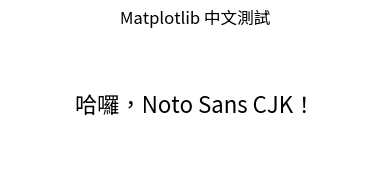

In [3]:
"""
跨平台載入 Noto Sans CJK 字型並驗證
在 VS Code + 本地 Python 環境執行
"""

import os
import sys
import platform
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager

# ---------- 1. 推斷各作業系統的預設字型路徑 ----------
def guess_noto_path() -> str | None:
    """回傳可能存在的 NotoSansCJK-Regular.ttc 路徑，找不到則回傳 None"""
    candidates = []

    match platform.system():
        case "Windows":
            candidates = [
                r"C:\Windows\Fonts\NotoSansCJK-Regular.ttc",
                r"C:\Windows\Fonts\NotoSansCJKtc-Regular.otf",
            ]
        case "Darwin":  # macOS
            candidates = [
                "/Library/Fonts/NotoSansCJK-Regular.ttc",
                "/System/Library/Fonts/NotoSansCJK.ttc",
            ]
        case "Linux":
            # 常見安裝位置；亦可加入 ~/.local/share/fonts
            candidates = [
                "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
                "/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc",
                str(Path.home() / ".local/share/fonts/NotoSansCJK-Regular.ttc"),
            ]

    for p in candidates:
        if Path(p).is_file():
            return p
    return None


# ---------- 2. 取得字型路徑（可改為專案內相對路徑） ----------
# font_path = guess_noto_path()
font_path = 'NotoSansTC-Regular.ttf'  # 若已下載字型檔，請確認路徑正確

if font_path is None:
    # 若系統沒安裝，可改成專案相對路徑，例如 Path("fonts/NotoSansCJK-Regular.ttc")
    font_path = "fonts/NotoSansCJK-Regular.ttc"  # 請確認實際檔案位置
    if not Path(font_path).is_file():
        sys.exit(
            f"❌ 找不到 Noto Sans CJK 字型！\n"
            f"  請先安裝字型或把字型檔放到 {font_path}"
        )

# ---------- 3. 動態註冊並設定為預設中文字型 ----------
font_manager.fontManager.addfont(font_path)
plt.rcParams["font.family"] = font_manager.FontProperties(fname=font_path).get_name()

# ---------- 4. 驗證 ----------
print("✅ 已載入字型：", plt.rcParams["font.family"])

# (可選) 畫個示範圖
plt.figure(figsize=(4, 2))
plt.title("Matplotlib 中文測試")
plt.text(0.5, 0.5, "哈囉，Noto Sans CJK！", ha="center", va="center", size=16)
plt.axis("off")
plt.tight_layout()
plt.show()


In [4]:
# Global variances for features preparation
target_month_start = 1 # 特徵月份起始
target_month_end = 9 # 特徵月份結束
target_start_date = f'2025-0{target_month_start}-01' # 2025-01-01
target_end_date = f'2025-0{target_month_end}-30'
alive = "20250831" # 預測月份起始
alive_final = "20250930" # 預測月份結束
ds_alive = pd.read_csv(f"alive_{alive}.csv", sep='^',encoding='big5')
ds_alive_final = pd.read_csv(f"alive_{alive_final}.csv", sep='^',encoding='big5')

## @ 分段讀取派工資料集並進行合併

In [133]:
def drop_columns_from_dataframe(df, columns_to_drop, df_name="DataFrame", show_preview=True):
    """
    從 DataFrame 中刪除指定的欄位
    
    Parameters:
    df: DataFrame - 要處理的資料框
    columns_to_drop: list - 要刪除的欄位名稱列表
    df_name: str - 資料框名稱（用於顯示訊息）
    show_preview: bool - 是否顯示刪除後的資料預覽
    
    Returns:
    DataFrame - 刪除欄位後的資料框
    """
    
    print(f"=== 刪除 {df_name} 指定欄位 ===")
    print()
    
    # 檢查原始形狀
    original_shape = df.shape
    print(f"刪除前 {df_name} 形狀: {original_shape}")
    print(f"刪除前欄位數: {original_shape[1]}")
    
    # 檢查哪些欄位存在於資料集中
    existing_columns = []
    missing_columns = []
    
    for col in columns_to_drop:
        if col in df.columns:
            existing_columns.append(col)
        else:
            missing_columns.append(col)
    
    print(f"\n存在的欄位 ({len(existing_columns)} 個):")
    for col in existing_columns:
        print(f"  ✓ {col}")
    
    if missing_columns:
        print(f"\n不存在的欄位 ({len(missing_columns)} 個):")
        for col in missing_columns:
            print(f"  ✗ {col}")
    
    # 只刪除存在的欄位
    if existing_columns:
        print(f"\n準備刪除 {len(existing_columns)} 個欄位...")
        df_result = df.drop(columns=existing_columns)
        print(f"✅ 已刪除欄位: {existing_columns}")
    else:
        print("\n⚠️ 沒有找到任何指定的欄位需要刪除")
        df_result = df.copy()
    
    # 檢查刪除後的形狀
    new_shape = df_result.shape
    print(f"\n刪除後 {df_name} 形狀: {new_shape}")
    print(f"刪除後欄位數: {new_shape[1]}")
    print(f"已刪除 {len(existing_columns)} 個欄位")
    
    # 顯示剩餘的欄位
    print(f"\n剩餘欄位列表 ({len(df_result.columns)} 個):")
    for i, col in enumerate(df_result.columns, 1):
        print(f"  {i:2d}. {col}")
    
    # 預覽刪除後的資料
    if show_preview:
        print(f"\n=== 刪除後資料預覽 ===")
        print(df_result.head())
    
    print("\n" + "="*60)
    print("欄位刪除作業完成")
    print()
    
    return df_result


In [12]:
# ds_test=pd.read_csv('寬頻維修資料明細表_佳光H1.csv', sep=',', encoding='utf-8')
# ds_test=pd.read_csv('寬頻維修資料明細表_北港H1.csv', sep=',', encoding='utf-8')
# service_T = pd.read_csv('寬頻維修資料明細表_大屯H1.csv', sep=',', encoding='utf-8')
# service_W = pd.read_csv('寬頻維修資料明細表_佳光H1.csv', sep=',', encoding='utf-8')
# service_N = pd.read_csv('寬頻維修資料明細表_中投H1.csv', sep=',', encoding='utf-8')
# service_L = pd.read_csv('寬頻維修資料明細表_佳聯H1.csv', sep=',', encoding='utf-8')
# service_P = pd.read_csv('寬頻維修資料明細表_北港H1.csv', sep=',', encoding='utf-8')
service_T = pd.read_csv('寬頻維修資料明細表_大屯_7_11.csv', sep=',', encoding='utf-8')
service_W = pd.read_csv('寬頻維修資料明細表_佳光_7_11.csv', sep=',', encoding='utf-8')
service_N = pd.read_csv('寬頻維修資料明細表_中投_7_11.csv', sep=',', encoding='utf-8')
service_L = pd.read_csv('寬頻維修資料明細表_佳聯_7_11.csv', sep=',', encoding='utf-8')
service_P = pd.read_csv('寬頻維修資料明細表_北港_7_11.csv', sep=',', encoding='utf-8')

In [13]:
# 合併 service_T、service_W、service_N、service_L、service_P 五個資料集
import pandas as pd

def merge_service_datasets(service_T, service_W, service_N, service_L, service_P):
    """
    合併五個系統台的維修資料
    
    Parameters:
    service_T: 大屯維修資料
    service_W: 佳光維修資料
    service_N: 中投維修資料
    service_L: 佳聯維修資料
    service_P: 北港維修資料
    
    Returns:
    DataFrame: 合併後的維修資料
    """
    print("🔄 開始合併五個系統台的維修資料...")
    print("="*80)
    
    # 檢查各資料集的形狀
    datasets = {
        '大屯 (T)': service_T,
        '佳光 (W)': service_W,
        '中投 (N)': service_N,
        '佳聯 (L)': service_L,
        '北港 (P)': service_P
    }
    
    print("📊 各系統台資料概況:")
    for name, df in datasets.items():
        print(f"  {name}: {df.shape[0]:,} 筆, {df.shape[1]} 欄")
    
    # 檢查欄位是否一致
    print("\n🔍 檢查欄位一致性:")
    base_cols = set(service_T.columns)
    all_consistent = True
    
    for name, df in datasets.items():
        current_cols = set(df.columns)
        if current_cols != base_cols:
            all_consistent = False
            missing = base_cols - current_cols
            extra = current_cols - base_cols
            if missing:
                print(f"  ⚠️  {name} 缺少欄位: {missing}")
            if extra:
                print(f"  ⚠️  {name} 多出欄位: {extra}")
    
    if all_consistent:
        print("  ✅ 所有資料集欄位一致")
    
    # 為每個資料集添加系統台標識
    print("\n🏷️  為各資料集添加系統台標識...")
    
    service_T_marked = service_T.copy()
    service_T_marked['系統台'] = '大屯'
    
    service_W_marked = service_W.copy()
    service_W_marked['系統台'] = '佳光'
    
    service_N_marked = service_N.copy()
    service_N_marked['系統台'] = '中投'
    
    service_L_marked = service_L.copy()
    service_L_marked['系統台'] = '佳聯'
    
    service_P_marked = service_P.copy()
    service_P_marked['系統台'] = '北港'
    
    # 合併所有資料集
    print("\n🔗 執行資料合併...")
    service_all = pd.concat([
        service_T_marked,
        service_W_marked,
        service_N_marked,
        service_L_marked,
        service_P_marked
    ], ignore_index=True)
    
    # 顯示合併結果
    print("\n✅ 合併完成！")
    print("="*80)
    print(f"📊 合併後資料:")
    print(f"  總筆數: {service_all.shape[0]:,}")
    print(f"  總欄位數: {service_all.shape[1]}")
    print(f"  新增 '系統台' 欄位")
    
    # 顯示各系統台的筆數分布
    print(f"\n📈 各系統台筆數分布:")
    system_counts = service_all['系統台'].value_counts()
    for system, count in system_counts.items():
        percentage = (count / len(service_all)) * 100
        print(f"  {system}: {count:,} 筆 ({percentage:.2f}%)")
    
    # 檢查客編分布
    if '客編' in service_all.columns:
        unique_customers = service_all['客編'].nunique()
        print(f"\n👥 唯一客編數: {unique_customers:,}")
        
        # 檢查是否有客編跨系統台
        customer_system_counts = service_all.groupby('客編')['系統台'].nunique()
        multi_system_customers = (customer_system_counts > 1).sum()
        if multi_system_customers > 0:
            print(f"  ⚠️  跨系統台的客編: {multi_system_customers:,} 個")
        else:
            print(f"  ✅ 無跨系統台的客編")
    
    # 檢查重複記錄
    duplicates = service_all.duplicated().sum()
    if duplicates > 0:
        print(f"\n⚠️  發現 {duplicates:,} 筆重複記錄")
    else:
        print(f"\n✅ 無重複記錄")
    
    # 檢查空值
    null_count = service_all.isnull().sum().sum()
    if null_count > 0:
        print(f"⚠️  總空值數: {null_count:,}")
        # 顯示有空值的欄位
        null_cols = service_all.isnull().sum()
        null_cols_with_nulls = null_cols[null_cols > 0]
        if len(null_cols_with_nulls) <= 5:
            for col, count in null_cols_with_nulls.items():
                print(f"  - {col}: {count:,} 個空值")
    else:
        print(f"✅ 無空值")
    
    # 顯示樣本資料
    print(f"\n📋 合併後資料樣本:")
    display_cols = ['客編', '系統台']
    # 添加其他重要欄位（如果存在）
    for col in ['派工單號', '報修日期', '完工日期', '故障原因', '處理結果']:
        if col in service_all.columns:
            display_cols.append(col)
    
    available_cols = [col for col in display_cols if col in service_all.columns]
    print(service_all[available_cols].head(10))
    
    return service_all

# 執行合併
service_all = merge_service_datasets(service_T, service_W, service_N, service_L, service_P)

print(f"\n🎯 合併完成！合併後的資料儲存在變數 'service_all' 中")
print(f"📊 最終形狀: {service_all.shape}")

🔄 開始合併五個系統台的維修資料...
📊 各系統台資料概況:
  大屯 (T): 3,884 筆, 12 欄
  佳光 (W): 5,291 筆, 12 欄
  中投 (N): 4,638 筆, 12 欄
  佳聯 (L): 4,930 筆, 12 欄
  北港 (P): 2,559 筆, 12 欄

🔍 檢查欄位一致性:
  ✅ 所有資料集欄位一致

🏷️  為各資料集添加系統台標識...

🔗 執行資料合併...

✅ 合併完成！
📊 合併後資料:
  總筆數: 21,302
  總欄位數: 12
  新增 '系統台' 欄位

📈 各系統台筆數分布:
  佳光: 5,291 筆 (24.84%)
  佳聯: 4,930 筆 (23.14%)
  中投: 4,638 筆 (21.77%)
  大屯: 3,884 筆 (18.23%)
  北港: 2,559 筆 (12.01%)

✅ 無重複記錄
⚠️  總空值數: 21,957
  - 申告原因: 640 個空值
  - 故障原因: 2 個空值
  - 故障原因(次): 21,301 個空值
  - 派工備註: 14 個空值

📋 合併後資料樣本:
  系統台         派工單號                 完工日期                    故障原因
0  大屯  T2507006371  2025-08-02 14:45:16                 其他_測試正常
1  大屯  T2510001136  2025-10-06 09:38:18  用戶端問題_IP分享(集線)器,無線AP問題
2  大屯  T2508006689  2025-08-31 18:49:49           用戶端問題_數據機故,更換
3  大屯  T2510004036  2025-10-23 11:45:43             RF線路問題_光點維護
4  大屯  T2507006838  2025-08-01 19:40:50           用戶端問題_數據機故,更換
5  大屯  T2508004886  2025-08-21 20:45:00                 其他_測試正常
6  大屯  T2508004740  2025-08-21 11:46:06   

In [14]:
service_all.head()

,系統台,派工單號,客戶編號,派工類別,受理日期,完工日期,申告原因,故障原因,故障原因(次),工程人員,產品包,派工備註
0,大屯,T2507006371,683192,維修,2025-08-02 08:00:00,2025-08-02 14:45:16,雙向網路問題,其他_測試正常,NaN,廖國良,FTTH-EPON-極速影音專案,"(系統紀錄),ISP出口為E-PON亞太寬頻,區派去電22780667 無法連線引導無效"
1,大屯,T2510001136,684076,維修,2025-10-06 08:00:00,2025-10-06 09:38:18,雙向網路問題,"用戶端問題_IP分享(集線)器,無線AP問題",NaN,張軒瑞,寬頻服務-三合一涼夏促銷方案,"(系統紀錄)用戶目前的cmts為10.0.2.26,ISP出口為速博,去電23953887，..."
2,大屯,T2508006689,684076,維修,2025-08-31 18:30:00,2025-08-31 18:49:49,雙向網路問題,"用戶端問題_數據機故,更換",NaN,廖國良,寬頻服務-三合一涼夏促銷方案,"(系統紀錄)用戶目前的cmts為速博,ISP出口為速博,去電23953887 版本3.0 ..."
3,大屯,T2510004036,683832,維修,2025-10-21 08:00:00,2025-10-23 11:45:43,雙向網路問題,RF線路問題_光點維護,NaN,許瑞益,寬頻服務,10/21 08:19 追蹤不在家(CM online)------(系統紀錄)用戶目前的c...
4,大屯,T2507006838,682495,維修,2025-08-01 08:00:00,2025-08-01 19:40:50,雙向網路問題,"用戶端問題_數據機故,更換",NaN,鄭浡絃,FTTH-EPON,"(系統紀錄),ISP出口為E-PON速博,客有新買分享器.請協助設定wifi.去電：2270..."


In [15]:
service_all.to_csv('寬頻維修資料明細表_五大系統台_7_11.csv', index=False, sep='^', encoding='utf-8-sig')

## @@ 維修資料集準備

In [422]:
service_1_6 = pd.read_csv('寬頻維修資料明細表_五大系統台_1_6.csv', sep='^')
service_7_11 = pd.read_csv('寬頻維修資料明細表_五大系統台_7_11.csv', sep='^')
service_all = pd.concat([
        service_1_6,
        service_7_11
    ], ignore_index=True)

In [423]:
service_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41610 entries, 0 to 41609
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   系統台      41610 non-null  object
 1   派工單號     41610 non-null  object
 2   客戶編號     41610 non-null  int64 
 3   派工類別     41610 non-null  object
 4   受理日期     41610 non-null  object
 5   完工日期     41610 non-null  object
 6   申告原因     40459 non-null  object
 7   故障原因     41608 non-null  object
 8   故障原因(次)  1 non-null      object
 9   工程人員     41610 non-null  object
 10  產品包      41610 non-null  object
 11  派工備註     41582 non-null  object
dtypes: int64(1), object(11)
memory usage: 3.8+ MB


## @@ dataset 準備

In [424]:
dataset=pd.read_csv('cleaned_dataset_fix_20251201.csv', sep='^')

C:\Users\user\AppData\Local\Temp\ipykernel_16680\634024797.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset=pd.read_csv('cleaned_dataset_fix_20251201.csv', sep='^')


In [425]:
dataset.head()

,客編,產品名稱,用戶種類,相關編號,起日,迄日,系統台,地區,繳別,使用狀態
0,4,EPON,一般收視戶,2434278,2021-10-29 19:10:30,NaN,大屯,太平區,1,使用中
1,35,EPON,一般收視戶,2623958,2023-09-13 11:53:01,NaN,大屯,大里區,1,使用中
2,47,EPON,一般收視戶,2486478,2022-06-08 11:10:05,NaN,大屯,大里區,12,使用中
3,96,EPON,一般收視戶,2215186,2019-06-21 10:56:15,NaN,大屯,大里區,6,停用
4,110,EPON,一般收視戶,2637783,2023-11-06 13:53:11,NaN,大屯,大里區,1,使用中


In [426]:
# (忽略)需要因日期調整才需要執行本段，安全刪除模式（含備份）
'''
print("🔒 安全模式：備份並刪除資料...")

# 備份
dataset_backup = dataset.copy()
print(f"✅ 已備份原始資料")

if '起日' in dataset.columns:
    # 轉換日期
    dataset['起日'] = pd.to_datetime(dataset['起日'], errors='coerce')
    
    # 篩選
    cutoff_date = pd.to_datetime('2025-06-30')
    before_count = len(dataset)
    
    # 保留 <= 2025-06-30 的資料（包含空值）
    dataset = dataset[(dataset['起日'] <= cutoff_date) | (dataset['起日'].isnull())].copy()
    
    after_count = len(dataset)
    removed = before_count - after_count
    
    print(f"✅ 刪除完成！")
    print(f"   刪除: {removed:,} 筆")
    print(f"   保留: {after_count:,} 筆")
    print(f"\n💡 如需還原，執行: dataset = dataset_backup.copy()")
else:
    print(f"❌ 找不到 '起日' 欄位")
'''

'\nprint("🔒 安全模式：備份並刪除資料...")\n\n# 備份\ndataset_backup = dataset.copy()\nprint(f"✅ 已備份原始資料")\n\nif \'起日\' in dataset.columns:\n    # 轉換日期\n    dataset[\'起日\'] = pd.to_datetime(dataset[\'起日\'], errors=\'coerce\')\n\n    # 篩選\n    cutoff_date = pd.to_datetime(\'2025-06-30\')\n    before_count = len(dataset)\n\n    # 保留 <= 2025-06-30 的資料（包含空值）\n    dataset = dataset[(dataset[\'起日\'] <= cutoff_date) | (dataset[\'起日\'].isnull())].copy()\n\n    after_count = len(dataset)\n    removed = before_count - after_count\n\n    print(f"✅ 刪除完成！")\n    print(f"   刪除: {removed:,} 筆")\n    print(f"   保留: {after_count:,} 筆")\n    print(f"\n💡 如需還原，執行: dataset = dataset_backup.copy()")\nelse:\n    print(f"❌ 找不到 \'起日\' 欄位")\n'

In [427]:
dataset.reset_index(drop=True, inplace=True)
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 329845 entries, 0 to 329844
Data columns (total 10 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   客編      329845 non-null  int64 
 1   產品名稱    329845 non-null  object
 2   用戶種類    329845 non-null  object
 3   相關編號    329845 non-null  int64 
 4   起日      329845 non-null  object
 5   迄日      180396 non-null  object
 6   系統台     329845 non-null  object
 7   地區      329836 non-null  object
 8   繳別      329845 non-null  int64 
 9   使用狀態    329845 non-null  object
dtypes: int64(3), object(7)
memory usage: 25.2+ MB


In [428]:
# 將 dataset 中的 CUST_NO 欄位改名為 '客編'
print("=== 重新命名 dataset 欄位 ===")

# 檢查重新命名前的狀況
print(f"重新命名前 dataset 形狀: {dataset.shape}")
print(f"重新命名前欄位: {list(dataset.columns)}")

# 檢查是否存在 'CUST_NO' 欄位
if 'CUST_NO' in dataset.columns:
    # 執行重新命名
    dataset = dataset.rename(columns={'CUST_NO': '客編'})
    
    print("✅ 已成功將 'CUST_NO' 欄位重新命名為 '客編'")
    
    # 檢查重新命名後的狀況
    print(f"重新命名後 dataset 形狀: {dataset.shape}")
    print(f"重新命名後欄位: {list(dataset.columns)}")
    
    # 驗證 客編 欄位
    print(f"\n客編 欄位驗證:")
    print(f"  客編 唯一值數量: {dataset['客編'].nunique()}")
    print(f"  客編 空值數量: {dataset['客編'].isnull().sum()}")
    print(f"  客編 資料型態: {dataset['客編'].dtype}")
    
    # 顯示前幾筆資料確認
    print(f"\n前5筆資料預覽:")
    print(dataset[['客編']].head())
    
elif '客編' in dataset.columns:
    print("✅ dataset 中已經存在 '客編' 欄位，無需重新命名")
    print(f"客編 唯一值數量: {dataset['客編'].nunique()}")
    
else:
    print("❌ dataset 中找不到 'CUST_NO' 欄位")
    print(f"可用欄位: {list(dataset.columns)}")
    
    # 檢查是否有類似的欄位
    similar_cols = [col for col in dataset.columns if '客' in col or 'cust' in col.lower()]
    if similar_cols:
        print(f"可能的客戶編號欄位: {similar_cols}")

print("\n" + "="*60)
print("dataset 欄位重新命名作業完成")

=== 重新命名 dataset 欄位 ===
重新命名前 dataset 形狀: (329845, 10)
重新命名前欄位: ['客編', '產品名稱', '用戶種類', '相關編號', '起日', '迄日', '系統台', '地區', '繳別', '使用狀態']
✅ dataset 中已經存在 '客編' 欄位，無需重新命名
客編 唯一值數量: 329845

dataset 欄位重新命名作業完成


In [429]:
dataset.head()

,客編,產品名稱,用戶種類,相關編號,起日,迄日,系統台,地區,繳別,使用狀態
0,4,EPON,一般收視戶,2434278,2021-10-29 19:10:30,NaN,大屯,太平區,1,使用中
1,35,EPON,一般收視戶,2623958,2023-09-13 11:53:01,NaN,大屯,大里區,1,使用中
2,47,EPON,一般收視戶,2486478,2022-06-08 11:10:05,NaN,大屯,大里區,12,使用中
3,96,EPON,一般收視戶,2215186,2019-06-21 10:56:15,NaN,大屯,大里區,6,停用
4,110,EPON,一般收視戶,2637783,2023-11-06 13:53:11,NaN,大屯,大里區,1,使用中


In [430]:
ds_doService = service_all.copy()

In [431]:
ds_doService.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41610 entries, 0 to 41609
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   系統台      41610 non-null  object
 1   派工單號     41610 non-null  object
 2   客戶編號     41610 non-null  int64 
 3   派工類別     41610 non-null  object
 4   受理日期     41610 non-null  object
 5   完工日期     41610 non-null  object
 6   申告原因     40459 non-null  object
 7   故障原因     41608 non-null  object
 8   故障原因(次)  1 non-null      object
 9   工程人員     41610 non-null  object
 10  產品包      41610 non-null  object
 11  派工備註     41582 non-null  object
dtypes: int64(1), object(11)
memory usage: 3.8+ MB


In [432]:
# Calculate the time difference in hours
ds_doService['等待時間'] = (pd.to_datetime(ds_doService['完工日期'], format='%Y-%m-%d %H:%M:%S', errors='coerce').astype('int64') // 10**9 - pd.to_datetime(ds_doService['受理日期'], format='%Y-%m-%d %H:%M:%S').astype('int64') // 10**9) / 3600
# Convert '等待時間' to days
ds_doService['等待天數'] = ds_doService['等待時間'] / 24  # Divide by 24 to convert hours to days
ds_doService['等待天數'] = ds_doService['等待天數'].round()

ds_doService.rename(columns={'客戶編號': '客編'}, inplace=True)

In [433]:
# 依據'客編'，將 dataset 中產品名稱為 'EPON' 或 'CM' 的產品名稱和使用狀態合併到 ds_doService

print("=== 合併產品名稱和使用狀態到 ds_doService (僅使用客編，限定產品名稱) ===")

# 1. 檢查兩個資料集的基本資訊
print(f"ds_doService 形狀: {ds_doService.shape}")
print(f"dataset 形狀: {dataset.shape}")

# 2. 檢查合併鍵的存在性
required_cols_ds = ['客編']
required_cols_dataset = ['客編', '產品名稱', '使用狀態']

print(f"\nds_doService 必要欄位檢查:")
for col in required_cols_ds:
    exists = col in ds_doService.columns
    print(f"  {col}: {'✓' if exists else '✗'}")
    if not exists:
        print(f"❌ ds_doService 缺少欄位: {col}")

print(f"\ndataset 必要欄位檢查:")
for col in required_cols_dataset:
    exists = col in dataset.columns
    print(f"  {col}: {'✓' if exists else '✗'}")
    if not exists:
        print(f"❌ dataset 缺少欄位: {col}")

# 3. 篩選 dataset 中產品名稱為 'EPON' 或 'CM' 的記錄
print(f"\n=== 篩選指定產品名稱 ===")
if '產品名稱' in dataset.columns:
    print(f"dataset 原始產品名稱分布:")
    original_product_counts = dataset['產品名稱'].value_counts()
    print(original_product_counts)
    
    # 篩選產品名稱為 'EPON' 或 'CM' 的記錄
    filtered_dataset = dataset[dataset['產品名稱'].isin(['EPON', 'CM'])].copy()
    print(f"\n篩選後的 dataset 形狀: {filtered_dataset.shape}")
    print(f"原始記錄數: {len(dataset)}")
    print(f"篩選後記錄數: {len(filtered_dataset)}")
    print(f"保留比例: {len(filtered_dataset) / len(dataset) * 100:.2f}%")
    
    print(f"\n篩選後產品名稱分布:")
    filtered_product_counts = filtered_dataset['產品名稱'].value_counts()
    print(filtered_product_counts)
    
    print(f"\n篩選後使用狀態分布:")
    filtered_status_counts = filtered_dataset['使用狀態'].value_counts()
    print(filtered_status_counts)
    
else:
    print("❌ dataset 中沒有產品名稱欄位")
    filtered_dataset = pd.DataFrame()  # 空的 DataFrame

# 如果篩選後沒有資料，提前結束
if filtered_dataset.empty:
    print("❌ 篩選後沒有符合條件的資料，無法進行合併")
    print("\n" + "="*60)
    print("合併作業終止")
else:
    # 4. 檢查合併鍵的重複情況
    print(f"\n=== 合併鍵重複檢查 ===")
    ds_duplicates = ds_doService.duplicated(subset=['客編']).sum()
    filtered_duplicates = filtered_dataset.duplicated(subset=['客編']).sum()
    print(f"ds_doService 中 客編 重複筆數: {ds_duplicates}")
    print(f"篩選後 dataset 中 客編 重複筆數: {filtered_duplicates}")

    # 5. 處理篩選後 dataset 中同一客編的多筆記錄
    print(f"\n=== 處理篩選後 dataset 中客編重複問題 ===")
    if filtered_duplicates > 0:
        print(f"篩選後 dataset 中有 {filtered_duplicates} 筆重複客編記錄")
        
        # 檢查重複客編的產品名稱分布
        duplicated_customers = filtered_dataset[filtered_dataset['客編'].duplicated(keep=False)].sort_values('客編')
        print(f"重複客編數量: {duplicated_customers['客編'].nunique()}")
        
        # 顯示重複客編的產品組合範例
        print("\n重複客編的產品組合範例 (前10組):")
        sample_duplicates = duplicated_customers.groupby('客編')[['產品名稱', '使用狀態']].apply(
            lambda x: f"產品: {list(x['產品名稱'].unique())}, 狀態: {list(x['使用狀態'].unique())}"
        ).head(10)
        print(sample_duplicates)
        
        # 策略選擇
        print("\n處理重複客編的策略選項:")
        print("1. 保留第一筆記錄")
        print("2. 優先保留 EPON 產品")
        print("3. 優先保留 CM 產品")
        
        # 這裡採用策略2：優先保留 EPON 產品，如果沒有 EPON 則保留 CM
        print("採用策略: 優先保留 EPON 產品，如果沒有 EPON 則保留 CM")
        
        def select_priority_product(group):
            # 優先選擇 EPON
            epon_records = group[group['產品名稱'] == 'EPON']
            if not epon_records.empty:
                return epon_records.iloc[0]
            # 如果沒有 EPON，選擇 CM
            cm_records = group[group['產品名稱'] == 'CM']
            if not cm_records.empty:
                return cm_records.iloc[0]
            # 如果都沒有（理論上不會發生，因為已經篩選過），返回第一筆
            return group.iloc[0]
        
        product_and_status_info = filtered_dataset.groupby('客編').apply(select_priority_product).reset_index(drop=True)
        product_and_status_info = product_and_status_info[['客編', '產品名稱', '使用狀態']].copy()
        
        removed_records = len(filtered_dataset) - len(product_and_status_info)
        print(f"移除重複記錄數: {removed_records}")
        print(f"保留記錄數: {len(product_and_status_info)}")
        
        print(f"\n去重後產品名稱分布:")
        dedup_product_counts = product_and_status_info['產品名稱'].value_counts()
        print(dedup_product_counts)
        
    else:
        print("篩選後 dataset 中沒有重複的客編")
        product_and_status_info = filtered_dataset[['客編', '產品名稱', '使用狀態']].copy()

    # 6. 檢查交集情況
    print(f"\n=== 合併匹配分析 ===")
    ds_customers = set(ds_doService['客編'])
    dataset_customers = set(product_and_status_info['客編'])

    common_customers = ds_customers.intersection(dataset_customers)
    ds_only = ds_customers - dataset_customers
    dataset_only = dataset_customers - ds_customers

    print(f"ds_doService 客編數: {len(ds_customers):,}")
    print(f"篩選後 dataset 客編數: {len(dataset_customers):,}")
    print(f"可匹配的客編數: {len(common_customers):,}")
    print(f"僅在 ds_doService 的客編數: {len(ds_only):,}")
    print(f"僅在篩選後 dataset 的客編數: {len(dataset_only):,}")
    print(f"匹配率: {len(common_customers)/len(ds_customers)*100:.2f}%")

    # 7. 執行合併
    print(f"\n=== 執行合併 ===")
    ds_doService_with_product_status = pd.merge(
        ds_doService, 
        product_and_status_info, 
        on='客編', 
        how='left'
    )

    print(f"合併前 ds_doService 形狀: {ds_doService.shape}")
    print(f"合併後形狀: {ds_doService_with_product_status.shape}")
    print(f"新增欄位數: {ds_doService_with_product_status.shape[1] - ds_doService.shape[1]}")

    # 8. 檢查合併結果
    print(f"\n=== 合併結果檢查 ===")

    # 檢查產品名稱合併結果
    if '產品名稱' in ds_doService_with_product_status.columns:
        product_null_count = ds_doService_with_product_status['產品名稱'].isnull().sum()
        product_not_null_count = ds_doService_with_product_status['產品名稱'].notnull().sum()
        
        print(f"產品名稱合併結果:")
        print(f"  成功匹配產品名稱的筆數: {product_not_null_count:,}")
        print(f"  未匹配到產品名稱的筆數: {product_null_count:,}")
        print(f"  匹配成功率: {product_not_null_count / len(ds_doService_with_product_status) * 100:.2f}%")
        
        # 顯示合併後的產品名稱分布
        print(f"\n合併後產品名稱分布:")
        merged_product_counts = ds_doService_with_product_status['產品名稱'].value_counts(dropna=False)
        print(merged_product_counts)
        
        # 特別統計 EPON 和 CM 的數量
        epon_count = (ds_doService_with_product_status['產品名稱'] == 'EPON').sum()
        cm_count = (ds_doService_with_product_status['產品名稱'] == 'CM').sum()
        print(f"\n特定產品統計:")
        print(f"  EPON 產品數量: {epon_count:,}")
        print(f"  CM 產品數量: {cm_count:,}")
        print(f"  EPON + CM 總數: {epon_count + cm_count:,}")
        
    else:
        print("❌ 產品名稱合併失敗")

    # 檢查使用狀態合併結果
    if '使用狀態' in ds_doService_with_product_status.columns:
        status_null_count = ds_doService_with_product_status['使用狀態'].isnull().sum()
        status_not_null_count = ds_doService_with_product_status['使用狀態'].notnull().sum()
        
        print(f"\n使用狀態合併結果:")
        print(f"  成功匹配使用狀態的筆數: {status_not_null_count:,}")
        print(f"  未匹配到使用狀態的筆數: {status_null_count:,}")
        print(f"  匹配成功率: {status_not_null_count / len(ds_doService_with_product_status) * 100:.2f}%")
        
        # 顯示合併後的使用狀態分布
        print(f"\n合併後使用狀態分布:")
        merged_status_counts = ds_doService_with_product_status['使用狀態'].value_counts(dropna=False)
        print(merged_status_counts)
    else:
        print("❌ 使用狀態合併失敗")

    # 9. 顯示合併結果預覽
    print(f"\n=== 合併結果預覽 ===")
    display_cols = ['客編', '產品名稱', '使用狀態', '受理日期', '工單原因']
    available_cols = [col for col in display_cols if col in ds_doService_with_product_status.columns]
    print("前10筆合併結果:")
    print(ds_doService_with_product_status[available_cols].head(10))
    
    # 特別顯示有產品名稱的記錄
    has_product = ds_doService_with_product_status[ds_doService_with_product_status['產品名稱'].notnull()]
    if not has_product.empty:
        print("\n前10筆有產品名稱的記錄:")
        print(has_product[available_cols].head(10))

    # 10. 交叉驗證產品名稱和使用狀態的一致性
    print(f"\n=== 產品名稱和使用狀態交叉驗證 ===")
    if '產品名稱' in ds_doService_with_product_status.columns and '使用狀態' in ds_doService_with_product_status.columns:
        # 檢查同時有產品名稱和使用狀態的記錄
        both_not_null = (
            ds_doService_with_product_status['產品名稱'].notnull() & 
            ds_doService_with_product_status['使用狀態'].notnull()
        ).sum()
        
        print(f"同時有產品名稱和使用狀態的記錄: {both_not_null:,}")
        print(f"佔總記錄比例: {both_not_null / len(ds_doService_with_product_status) * 100:.2f}%")
        
        # 顯示產品名稱和使用狀態的交叉表（僅針對 EPON 和 CM）
        if both_not_null > 0:
            # 只針對 EPON 和 CM 的記錄做交叉表
            valid_products = ds_doService_with_product_status[
                ds_doService_with_product_status['產品名稱'].isin(['EPON', 'CM'])
            ]
            if not valid_products.empty:
                cross_table = pd.crosstab(
                    valid_products['產品名稱'], 
                    valid_products['使用狀態'], 
                    margins=True, 
                    dropna=False
                )
                print(f"\n產品名稱 vs 使用狀態交叉表 (僅 EPON 和 CM):")
                print(cross_table)

    # 11. 檢查因為僅使用客編合併可能產生的資料膨脹
    print(f"\n=== 資料膨脹檢查 ===")
    original_customers = ds_doService['客編'].nunique()
    merged_customers = ds_doService_with_product_status['客編'].nunique()
    print(f"原始客編數: {original_customers:,}")
    print(f"合併後客編數: {merged_customers:,}")

    if len(ds_doService_with_product_status) > len(ds_doService):
        print(f"⚠️ 注意: 合併後記錄數增加了 {len(ds_doService_with_product_status) - len(ds_doService):,} 筆")
        print("這是因為使用客編合併而非客編+相關編號的結果")
    else:
        print("✅ 合併後記錄數未增加")

    # 12. 更新 ds_doService
    ds_doService = ds_doService_with_product_status.copy()
    print(f"\n✅ ds_doService 已更新，新形狀: {ds_doService.shape}")
    print(f"新增欄位: ['產品名稱', '使用狀態']")

    # 13. 最終驗證
    print(f"\n=== 最終驗證 ===")
    final_columns = list(ds_doService.columns)
    print(f"最終欄位數: {len(final_columns)}")
    print("是否包含目標欄位:")
    print(f"  產品名稱: {'✓' if '產品名稱' in final_columns else '✗'}")
    print(f"  使用狀態: {'✓' if '使用狀態' in final_columns else '✗'}")
    
    # 最終產品名稱統計
    if '產品名稱' in final_columns:
        final_epon = (ds_doService['產品名稱'] == 'EPON').sum()
        final_cm = (ds_doService['產品名稱'] == 'CM').sum()
        final_null = ds_doService['產品名稱'].isnull().sum()
        print(f"\n最終產品名稱統計:")
        print(f"  EPON: {final_epon:,} 筆")
        print(f"  CM: {final_cm:,} 筆")
        print(f"  空值: {final_null:,} 筆")

    print("\n" + "="*60)
    print("產品名稱和使用狀態合併作業完成 (僅使用客編，限定 EPON/CM 產品)")

=== 合併產品名稱和使用狀態到 ds_doService (僅使用客編，限定產品名稱) ===
ds_doService 形狀: (41610, 14)
dataset 形狀: (329845, 10)

ds_doService 必要欄位檢查:
  客編: ✓

dataset 必要欄位檢查:
  客編: ✓
  產品名稱: ✓
  使用狀態: ✓

=== 篩選指定產品名稱 ===
dataset 原始產品名稱分布:
產品名稱
CM      203410
EPON    126435
Name: count, dtype: int64

篩選後的 dataset 形狀: (329845, 10)
原始記錄數: 329845
篩選後記錄數: 329845
保留比例: 100.00%

篩選後產品名稱分布:
產品名稱
CM      203410
EPON    126435
Name: count, dtype: int64

篩選後使用狀態分布:
使用狀態
停用     208936
使用中    120909
Name: count, dtype: int64

=== 合併鍵重複檢查 ===
ds_doService 中 客編 重複筆數: 13564
篩選後 dataset 中 客編 重複筆數: 0

=== 處理篩選後 dataset 中客編重複問題 ===
篩選後 dataset 中沒有重複的客編

=== 合併匹配分析 ===
ds_doService 客編數: 28,046
篩選後 dataset 客編數: 329,845
可匹配的客編數: 24,479
僅在 ds_doService 的客編數: 3,567
僅在篩選後 dataset 的客編數: 305,366
匹配率: 87.28%

=== 執行合併 ===
合併前 ds_doService 形狀: (41610, 14)
合併後形狀: (41610, 16)
新增欄位數: 2

=== 合併結果檢查 ===
產品名稱合併結果:
  成功匹配產品名稱的筆數: 36,275
  未匹配到產品名稱的筆數: 5,335
  匹配成功率: 87.18%

合併後產品名稱分布:
產品名稱
EPON    18261
CM      18014
NaN      5335
Name: count, d

In [434]:
ds_doService.head()

,系統台,派工單號,客編,派工類別,受理日期,完工日期,申告原因,故障原因,故障原因(次),工程人員,產品包,派工備註,等待時間,等待天數,產品名稱,使用狀態
0,大屯,T2506002361,684035,維修,2025-06-11 18:30:00,2025-06-11 18:42:10,雙向網路問題,用戶端問題_客戶說明,NaN,許舒翔,FTTH-GPON 好視成雙,"(系統紀錄),ISP出口為E-PON速博,反映網路速度慢 去電24939974",0.202778,0.0,EPON,使用中
1,大屯,T2506000495,681942,維修,2025-06-03 12:00:00,2025-06-03 12:10:04,雙向網路問題,RF線路問題_光纖斷,NaN,林軒正,寬頻服務,11:45追蹤ok.上行port口：U2/4.0/0區派:下午盡早直接前往 無法連線 重啟無效,0.167778,0.0,CM,使用中
2,大屯,T2502004574,682681,維修,2025-02-20 18:30:00,2025-02-20 17:44:05,雙向網路問題,"用戶端問題_IP分享(集線)器,無線AP問題",NaN,張宜勤,寬頻服務,"(系統紀錄)用戶目前的cmts為10.0.2.50,ISP出口為速博,版本3.0，去電098...",-0.765278,-0.0,CM,停用
3,大屯,T2504004091,682879,維修,2025-04-20 18:30:00,2025-04-20 18:54:34,雙向網路問題,RF線路問題_放大器故障,NaN,廖國良,寬頻服務-聯網三合一,"(系統紀錄)用戶目前的cmts為10.0.2.11,ISP出口為速博,cm online w...",0.409444,0.0,EPON,使用中
4,大屯,T2504000890,682879,維修,2025-04-06 12:00:00,2025-04-09 07:59:34,雙向網路問題,RF線路問題_光點維護,NaN,許瑞益,寬頻服務-聯網三合一,"4/6 09:38 去電追蹤OK.(系統紀錄)用戶目前的cmts為10.0.2.11,ISP...",67.992778,3.0,EPON,使用中


In [435]:
# 安全模式：備份並刪除產品空值
print("🔒 安全模式：備份並處理...")

# 備份
ds_doService_backup = ds_doService.copy()
print(f"✅ 已備份原始資料 (形狀: {ds_doService_backup.shape})")

# 尋找產品欄位
product_col = None
for col in ['產品名稱']:
    if col in ds_doService.columns:
        product_col = col
        break

if product_col:
    before_count = len(ds_doService)
    null_count = ds_doService[product_col].isnull().sum()
    
    print(f"\n📊 產品欄位 '{product_col}':")
    print(f"   空值: {null_count:,} 筆")
    print(f"   非空值: {before_count - null_count:,} 筆")
    
    # 刪除空值
    ds_doService = ds_doService[ds_doService[product_col].notnull()].copy()
    
    print(f"\n✅ 刪除完成！")
    print(f"   刪除: {null_count:,} 筆")
    print(f"   保留: {len(ds_doService):,} 筆")
    print(f"   最終形狀: {ds_doService.shape}")
    
    print(f"\n💡 如需還原，執行: ds_doService = ds_doService_backup.copy()")
else:
    print(f"❌ 找不到產品欄位")

🔒 安全模式：備份並處理...
✅ 已備份原始資料 (形狀: (41610, 16))

📊 產品欄位 '產品名稱':
   空值: 5,335 筆
   非空值: 36,275 筆

✅ 刪除完成！
   刪除: 5,335 筆
   保留: 36,275 筆
   最終形狀: (36275, 16)

💡 如需還原，執行: ds_doService = ds_doService_backup.copy()


In [436]:
# 檢查使用狀態欄位的空值情況
if '使用狀態' in ds_doService.columns:
    null_count = ds_doService['使用狀態'].isnull().sum()
    total_count = len(ds_doService)
    
    print(f"=== ds_doService 使用狀態空值檢查 ===")
    print(f"總筆數: {total_count:,}")
    print(f"使用狀態空值筆數: {null_count:,}")
    print(f"空值比例: {null_count / total_count * 100:.2f}%")
    
    # 顯示使用狀態的分布
    print(f"\n使用狀態分布:")
    print(ds_doService['使用狀態'].value_counts(dropna=False))
else:
    print("❌ ds_doService 中找不到'使用狀態'欄位")

=== ds_doService 使用狀態空值檢查 ===
總筆數: 36,275
使用狀態空值筆數: 0
空值比例: 0.00%

使用狀態分布:
使用狀態
使用中    34547
停用      1728
Name: count, dtype: int64


In [437]:
# 檢查 ds_doService 中使用狀態為空值的客編，是否確實不存在於 dataset 中
print("=== 檢查使用狀態為空值的客編在 dataset 中的存在情況 ===")

# 首先確認 ds_doService 中使用狀態為空值的情況
if '使用狀態' in ds_doService.columns:
    null_usage_mask = ds_doService['使用狀態'].isnull()
    null_usage_count = null_usage_mask.sum()
    
    print(f"ds_doService 中使用狀態為空值的筆數: {null_usage_count}")
    
    if null_usage_count > 0:
        # 取得使用狀態為空值的客編
        null_usage_customers = ds_doService.loc[null_usage_mask, '客編'].unique()
        print(f"使用狀態為空值的不重複客編數: {len(null_usage_customers)}")
        
        # 檢查這些客編是否存在於 dataset 中
        dataset_customers = set(dataset['客編'].unique())
        
        # 分析存在情況
        null_customers_in_dataset = []
        null_customers_not_in_dataset = []
        
        for cust_id in null_usage_customers:
            if cust_id in dataset_customers:
                null_customers_in_dataset.append(cust_id)
            else:
                null_customers_not_in_dataset.append(cust_id)
        
        print(f"\n=== 分析結果 ===")
        print(f"在 dataset 中存在的空值客編數: {len(null_customers_in_dataset)}")
        print(f"在 dataset 中不存在的空值客編數: {len(null_customers_not_in_dataset)}")
        print(f"存在比例: {len(null_customers_in_dataset) / len(null_usage_customers) * 100:.2f}%")
        print(f"不存在比例: {len(null_customers_not_in_dataset) / len(null_usage_customers) * 100:.2f}%")
        
        # 如果有客編存在於 dataset 中，進一步檢查其在 dataset 中的狀態
        if len(null_customers_in_dataset) > 0:
            print(f"\n=== 存在於 dataset 中的空值客編詳細分析 ===")
            print(f"這些客編在 dataset 中的使用狀態分布:")
            
            # 篩選出這些客編在 dataset 中的記錄
            existing_in_dataset = dataset[dataset['客編'].isin(null_customers_in_dataset)]
            status_distribution = existing_in_dataset['使用狀態'].value_counts(dropna=False)
            print(status_distribution)
            
            # 檢查產品名稱分布
            if '產品名稱' in existing_in_dataset.columns:
                print(f"\n這些客編在 dataset 中的產品名稱分布:")
                product_distribution = existing_in_dataset['產品名稱'].value_counts(dropna=False)
                print(product_distribution)
            
            # 顯示前10個存在的客編範例
            print(f"\n存在於 dataset 中的空值客編範例(前10個):")
            sample_existing = existing_in_dataset[['客編', '產品名稱', '使用狀態']].head(10)
            print(sample_existing.to_string(index=False))
        
        # 如果有客編不存在於 dataset 中
        if len(null_customers_not_in_dataset) > 0:
            print(f"\n=== 不存在於 dataset 中的空值客編分析 ===")
            print(f"前10個不存在的客編範例:")
            print(null_customers_not_in_dataset[:10])
            
            # 檢查這些客編在 ds_doService 中的其他資訊
            not_existing_records = ds_doService[
                (ds_doService['客編'].isin(null_customers_not_in_dataset)) & 
                (ds_doService['使用狀態'].isnull())
            ]
            
            if len(not_existing_records) > 0:
                print(f"\n這些不存在客編在 ds_doService 中的其他欄位資訊(前5筆):")
                display_cols = ['客編', '使用狀態', '受理日期', '工單原因']
                available_cols = [col for col in display_cols if col in not_existing_records.columns]
                print(not_existing_records[available_cols].head().to_string(index=False))
        
        # 總結分析
        print(f"\n=== 總結 ===")
        if len(null_customers_in_dataset) == 0:
            print("✅ 確認：所有使用狀態為空值的客編都不存在於 dataset 中")
            print("這解釋了為什麼合併時這些客編的使用狀態會是空值")
        elif len(null_customers_not_in_dataset) == 0:
            print("⚠️ 注意：所有使用狀態為空值的客編都存在於 dataset 中")
            print("這表示合併過程可能存在問題，需要進一步檢查")
        else:
            print(f"📊 混合情況：")
            print(f"  - {len(null_customers_in_dataset)} 個空值客編存在於 dataset 中")
            print(f"  - {len(null_customers_not_in_dataset)} 個空值客編不存在於 dataset 中")
            print("需要分別處理這兩種情況")
            
    else:
        print("✅ ds_doService 中沒有使用狀態為空值的記錄")

else:
    print("❌ ds_doService 中找不到'使用狀態'欄位")
    print(f"可用欄位: {list(ds_doService.columns)}")

# 額外檢查：驗證 dataset 中是否有 EPON 或 CM 產品的客編沒有被合併到 ds_doService
print(f"\n=== 反向檢查：dataset 中 EPON/CM 產品的覆蓋情況 ===")
if '產品名稱' in dataset.columns:
    epon_cm_dataset = dataset[dataset['產品名稱'].isin(['EPON', 'CM'])]
    epon_cm_customers = set(epon_cm_dataset['客編'].unique())
    ds_doservice_customers = set(ds_doService['客編'].unique())
    
    dataset_not_in_doservice = epon_cm_customers - ds_doservice_customers
    print(f"dataset 中 EPON/CM 產品的客編數: {len(epon_cm_customers)}")
    print(f"ds_doService 中的客編數: {len(ds_doservice_customers)}")
    print(f"dataset 中有但 ds_doService 中沒有的 EPON/CM 客編數: {len(dataset_not_in_doservice)}")
    
    if len(dataset_not_in_doservice) > 0:
        print(f"覆蓋率: {(len(epon_cm_customers) - len(dataset_not_in_doservice)) / len(epon_cm_customers) * 100:.2f}%")
        print(f"未覆蓋的客編範例(前10個): {list(dataset_not_in_doservice)[:10]}")
    else:
        print("✅ dataset 中所有 EPON/CM 產品的客編都存在於 ds_doService 中")

=== 檢查使用狀態為空值的客編在 dataset 中的存在情況 ===
ds_doService 中使用狀態為空值的筆數: 0
✅ ds_doService 中沒有使用狀態為空值的記錄

=== 反向檢查：dataset 中 EPON/CM 產品的覆蓋情況 ===
dataset 中 EPON/CM 產品的客編數: 329845
ds_doService 中的客編數: 24479
dataset 中有但 ds_doService 中沒有的 EPON/CM 客編數: 305366
覆蓋率: 7.42%
未覆蓋的客編範例(前10個): [np.int64(1048579), np.int64(4), np.int64(1048583), np.int64(1048585), np.int64(1048587), np.int64(1048590), np.int64(1048593), np.int64(1048596), np.int64(1048608), np.int64(1048609)]


In [438]:
# ds_doService 刪除指定欄位

print("=== 刪除 ds_doService 指定欄位 ===")

# 定義要刪除的欄位
columns_to_drop = [
    # '系統台', 
    '派工單號', 
    '派工類別', 
    '申告原因',
    '故障原因(次)', 
    '工程人員', 
    '產品包', 
    '派工備註', 
    '等待時間'
]

# 檢查原始形狀
print(f"刪除前 ds_doService 形狀: {ds_doService.shape}")
print(f"刪除前欄位數: {ds_doService.shape[1]}")

# 檢查哪些欄位存在於資料集中
existing_columns = []
missing_columns = []

for col in columns_to_drop:
    if col in ds_doService.columns:
        existing_columns.append(col)
    else:
        missing_columns.append(col)

print(f"\n存在的欄位 ({len(existing_columns)} 個):")
for col in existing_columns:
    print(f"  ✓ {col}")

if missing_columns:
    print(f"\n不存在的欄位 ({len(missing_columns)} 個):")
    for col in missing_columns:
        print(f"  ✗ {col}")

# 只刪除存在的欄位
if existing_columns:
    print(f"\n準備刪除 {len(existing_columns)} 個欄位...")
    ds_doService = ds_doService.drop(columns=existing_columns)
    print(f"✅ 已刪除欄位: {existing_columns}")
else:
    print("\n⚠️ 沒有找到任何指定的欄位需要刪除")

# 檢查刪除後的形狀
print(f"\n刪除後 ds_doService 形狀: {ds_doService.shape}")
print(f"刪除後欄位數: {ds_doService.shape[1]}")
print(f"已刪除 {len(existing_columns)} 個欄位")

# 顯示剩餘的欄位
print(f"\n剩餘欄位列表:")
for i, col in enumerate(ds_doService.columns, 1):
    print(f"  {i:2d}. {col}")

# 預覽刪除後的資料
print(f"\n=== 刪除後資料預覽 ===")
print(ds_doService.head())

print("\n" + "="*60)
print("欄位刪除作業完成")

=== 刪除 ds_doService 指定欄位 ===
刪除前 ds_doService 形狀: (36275, 16)
刪除前欄位數: 16

存在的欄位 (8 個):
  ✓ 派工單號
  ✓ 派工類別
  ✓ 申告原因
  ✓ 故障原因(次)
  ✓ 工程人員
  ✓ 產品包
  ✓ 派工備註
  ✓ 等待時間

準備刪除 8 個欄位...
✅ 已刪除欄位: ['派工單號', '派工類別', '申告原因', '故障原因(次)', '工程人員', '產品包', '派工備註', '等待時間']

刪除後 ds_doService 形狀: (36275, 8)
刪除後欄位數: 8
已刪除 8 個欄位

剩餘欄位列表:
   1. 系統台
   2. 客編
   3. 受理日期
   4. 完工日期
   5. 故障原因
   6. 等待天數
   7. 產品名稱
   8. 使用狀態

=== 刪除後資料預覽 ===
  系統台      客編                 受理日期                 完工日期  \
0  大屯  684035  2025-06-11 18:30:00  2025-06-11 18:42:10   
1  大屯  681942  2025-06-03 12:00:00  2025-06-03 12:10:04   
2  大屯  682681  2025-02-20 18:30:00  2025-02-20 17:44:05   
3  大屯  682879  2025-04-20 18:30:00  2025-04-20 18:54:34   
4  大屯  682879  2025-04-06 12:00:00  2025-04-09 07:59:34   

                     故障原因  等待天數  產品名稱 使用狀態  
0              用戶端問題_客戶說明   0.0  EPON  使用中  
1              RF線路問題_光纖斷   0.0    CM  使用中  
2  用戶端問題_IP分享(集線)器,無線AP問題  -0.0    CM   停用  
3            RF線路問題_放大器故障   0.0  EPON  使用中  
4   

In [439]:
# 針對特定欄位的空值處理
print("=== 特定欄位空值處理 ===")

# 只刪除關鍵欄位為空的記錄
# key_columns = ['產品名稱', '使用狀態']  # 根據需要調整
# key_columns = ['產品名稱']  # 根據需要調整
# ds_doService = ds_doService.dropna(subset=key_columns)

print(f"處理後形狀: {ds_doService.shape}")
print("✅ 關鍵欄位空值處理完成")

=== 特定欄位空值處理 ===
處理後形狀: (36275, 8)
✅ 關鍵欄位空值處理完成


In [440]:
ds_doService.head()

,系統台,客編,受理日期,完工日期,故障原因,等待天數,產品名稱,使用狀態
0,大屯,684035,2025-06-11 18:30:00,2025-06-11 18:42:10,用戶端問題_客戶說明,0.0,EPON,使用中
1,大屯,681942,2025-06-03 12:00:00,2025-06-03 12:10:04,RF線路問題_光纖斷,0.0,CM,使用中
2,大屯,682681,2025-02-20 18:30:00,2025-02-20 17:44:05,"用戶端問題_IP分享(集線)器,無線AP問題",-0.0,CM,停用
3,大屯,682879,2025-04-20 18:30:00,2025-04-20 18:54:34,RF線路問題_放大器故障,0.0,EPON,使用中
4,大屯,682879,2025-04-06 12:00:00,2025-04-09 07:59:34,RF線路問題_光點維護,3.0,EPON,使用中


In [441]:
# 執行重新命名
ds_doService.rename(columns={'故障原因': '工單原因'}, inplace=True)


In [442]:
# 執行重新命名
ds_doService.rename(columns={'受理日期': '工單日期'}, inplace=True)

In [443]:
ds_doService.head()

,系統台,客編,工單日期,完工日期,工單原因,等待天數,產品名稱,使用狀態
0,大屯,684035,2025-06-11 18:30:00,2025-06-11 18:42:10,用戶端問題_客戶說明,0.0,EPON,使用中
1,大屯,681942,2025-06-03 12:00:00,2025-06-03 12:10:04,RF線路問題_光纖斷,0.0,CM,使用中
2,大屯,682681,2025-02-20 18:30:00,2025-02-20 17:44:05,"用戶端問題_IP分享(集線)器,無線AP問題",-0.0,CM,停用
3,大屯,682879,2025-04-20 18:30:00,2025-04-20 18:54:34,RF線路問題_放大器故障,0.0,EPON,使用中
4,大屯,682879,2025-04-06 12:00:00,2025-04-09 07:59:34,RF線路問題_光點維護,3.0,EPON,使用中


In [444]:
# 派工資料日期篩選函式 - 支持日期起迄範圍篩選
import pandas as pd
from datetime import datetime
from typing import Optional, Sequence

def filter_service_data_by_date_range(
    csv_path,
    date_column='完工日期',
    date_format='%Y/%m/%d %H:%M:%S',
    start_date=None,
    end_date=None,
    separator='^',
    encoding='utf-8',
    output_csv=None,
    verbose=True
):
    """
    根據日期起迄範圍篩選派工資料
    
    Parameters:
    -----------
    csv_path : str
        CSV檔案路徑
    date_column : str
        要篩選的日期欄位名稱（預設：'完工日期'）
    date_format : str
        日期格式字串（預設：'%Y/%m/%d %H:%M:%S'）
    start_date : str or datetime, optional
        起始日期 (格式: 'YYYY-MM-DD' 或 datetime物件)
        若為None，則不設下界
    end_date : str or datetime, optional
        結束日期 (格式: 'YYYY-MM-DD' 或 datetime物件)
        若為None，則不設上界
    separator : str
        CSV分隔符（預設：'^'）
    encoding : str
        檔案編碼（預設：'utf-8'）
    output_csv : str, optional
        是否輸出篩選結果到CSV檔案（若為None則不輸出）
    verbose : bool
        是否顯示詳細訊息（預設：True）
    
    Returns:
    --------
    pandas.DataFrame
        篩選後的資料框
    
    Examples:
    ---------
    # 篩選2024年以後的資料
    df_2024 = filter_service_data_by_date_range(
        'cleaned_ds_doService.csv',
        start_date='2024-01-01'
    )
    
    # 篩選2024年Q1的資料（2024-01-01 至 2024-03-31）
    df_2024_q1 = filter_service_data_by_date_range(
        'cleaned_ds_doService.csv',
        start_date='2024-01-01',
        end_date='2024-03-31'
    )
    
    # 篩選2023年的資料
    df_2023 = filter_service_data_by_date_range(
        'cleaned_ds_doService.csv',
        start_date='2023-01-01',
        end_date='2023-12-31'
    )
    """
    
    if verbose:
        print("=" * 80)
        print("📊 派工資料日期篩選")
        print("=" * 80)
        print(f"\n📂 輸入檔案: {csv_path}")
        print(f"📅 篩選欄位: {date_column}")
        print(f"📋 日期格式: {date_format}")
        print(f"🔍 篩選範圍: {start_date} 至 {end_date}")
    
    # === 1. 載入資料 ===
    try:
        df = pd.read_csv(csv_path, sep=separator, encoding=encoding)
        original_count = len(df)
        if verbose:
            print(f"\n✅ 成功載入資料")
            print(f"   原始筆數: {original_count:,}")
    except Exception as e:
        print(f"❌ 無法讀取檔案: {e}")
        return None
    
    # === 2. 檢查日期欄位是否存在 ===
    if date_column not in df.columns:
        print(f"❌ 找不到欄位 '{date_column}'")
        print(f"可用欄位: {list(df.columns)}")
        return None
    
    # === 3. 轉換日期格式 ===
    if verbose:
        print(f"\n🔄 轉換日期格式...")
    
    df[date_column] = pd.to_datetime(df[date_column], format=date_format, errors='coerce')
    
    # 檢查轉換結果
    null_count = df[date_column].isna().sum()
    valid_count = original_count - null_count
    
    if verbose:
        print(f"   有效日期: {valid_count:,} ({valid_count/original_count*100:.2f}%)")
        if null_count > 0:
            print(f"   無效日期: {null_count:,} ({null_count/original_count*100:.2f}%)")
    
    # 檢查日期範圍
    if valid_count > 0:
        min_date = df[date_column].min()
        max_date = df[date_column].max()
        if verbose:
            print(f"\n📅 日期範圍:")
            print(f"   最早: {min_date}")
            print(f"   最晚: {max_date}")
            print(f"   跨度: {(max_date - min_date).days} 天")
        
        # === 4. 年份分布 ===
        if verbose:
            year_counts = df[date_column].dt.year.value_counts().sort_index()
            print(f"\n📊 年份分布 (共 {len(year_counts)} 個年份):")
            for year, count in year_counts.items():
                pct = count / valid_count * 100
                print(f"   {int(year)}: {count:>7,} ({pct:>5.2f}%)")
    
    # === 5. 轉換起迄日期為datetime ===
    if isinstance(start_date, str):
        start_date = pd.to_datetime(start_date)
    if isinstance(end_date, str):
        end_date = pd.to_datetime(end_date)
    
    # === 6. 應用日期篩選 ===
    mask = pd.Series([True] * len(df), index=df.index)
    
    if start_date is not None:
        mask &= (df[date_column] >= start_date)
    
    if end_date is not None:
        # 包含結束日期的全天（至23:59:59）
        end_date_inclusive = pd.to_datetime(end_date + pd.Timedelta(days=1))
        mask &= (df[date_column] < end_date_inclusive)
    
    df_filtered = df[mask].copy()
    filtered_count = len(df_filtered)
    
    if verbose:
        print(f"\n🔍 篩選結果:")
        print(f"   篩選前筆數: {original_count:,}")
        print(f"   篩選後筆數: {filtered_count:,}")
        print(f"   刪除筆數: {original_count - filtered_count:,}")
        print(f"   保留比例: {filtered_count/original_count*100:.2f}%")
    
    # === 7. 檢查篩選後的結果 ===
    if filtered_count > 0:
        if verbose:
            print(f"\n✅ 篩選完成")
            print(f"   最早日期: {df_filtered[date_column].min()}")
            print(f"   最晚日期: {df_filtered[date_column].max()}")
            
            # 月份分布
            print(f"\n📊 各月份分布:")
            month_counts = df_filtered[date_column].dt.month.value_counts().sort_index()
            month_names = ['1月', '2月', '3月', '4月', '5月', '6月',
                          '7月', '8月', '9月', '10月', '11月', '12月']
            for month, count in month_counts.items():
                pct = count / filtered_count * 100
                print(f"   {month_names[month-1]:>3s}: {count:>7,} ({pct:>5.2f}%)")
    else:
        print(f"⚠️  警告：篩選後沒有符合條件的資料！")
    
    # === 8. 重設索引 ===
    df_filtered = df_filtered.reset_index(drop=True)
    
    # === 9. 輸出CSV（可選） ===
    if output_csv and filtered_count > 0:
        try:
            df_filtered.to_csv(output_csv, sep=separator, index=False, encoding=encoding)
            if verbose:
                print(f"\n💾 已儲存結果: {output_csv}")
        except Exception as e:
            if verbose:
                print(f"❌ 無法儲存檔案: {e}")
    
    if verbose:
        print("\n" + "=" * 80)
    
    return df_filtered

def filter_service_data_by_date_range_from_dataset(
    df: pd.DataFrame,
    start_date: Optional[str] = None,
    end_date: Optional[str] = None,
    date_col: str = "完工日期",
    accepted_formats: Sequence[str] = (
        "%Y-%m-%d %H:%M:%S",
        "%Y/%m/%d %H:%M:%S",
        "%Y-%m-%d",
        "%Y/%m/%d",
    ),
) -> pd.DataFrame:
    """
    依據原 `filter_service_data_by_date_range()` 函式邏輯，將 `csv_path` 檔案型態參數改為
    接受 `pandas.DataFrame` 型態的 `df`，其餘功能（日期解析與區間過濾）維持相同。

    參數:
    - df: 要篩選的資料集（需包含日期欄位）。
    - start_date: 起始日期（字串，可為 YYYY-MM-DD 或 YYYY/MM/DD 等常見格式）。
    - end_date: 結束日期（字串，可為 YYYY-MM-DD 或 YYYY/MM/DD 等常見格式）。
    - date_col: 日期欄位名稱（預設 "工單日期"）。
    - accepted_formats: 嘗試解析日期欄位的格式列表。

    回傳:
    - 篩選後的 DataFrame（依日期區間過濾，保留原其他欄位）。
    """
    if df is None or df.empty:
        print("Warning: 輸入的 DataFrame 為空，直接回傳空 DataFrame。")
        return pd.DataFrame()

    if date_col not in df.columns:
        print(f"Error: 找不到日期欄位 '{date_col}'，目前欄位: {df.columns.tolist()}")
        return pd.DataFrame()

    work = df.copy()

    def _to_datetime_safe(x: object) -> pd.Timestamp:
        if pd.isna(x):
            return pd.NaT
        s = str(x).strip()
        # 處理中文 AM/PM（上午/下午）
        if "上午" in s or "下午" in s:
            s2 = s.replace("上午", "AM").replace("下午", "PM")
            # 嘗試常見格式（含 AM/PM）
            try:
                return pd.to_datetime(s2, format="%Y/%m/%d %p %I:%M:%S")
            except Exception:
                pass
        # 依序嘗試常見格式
        for fmt in accepted_formats:
            try:
                return pd.to_datetime(s, format=fmt)
            except Exception:
                continue
        # 最後由 pandas 自動推斷
        try:
            return pd.to_datetime(s, infer_datetime_format=True)
        except Exception:
            return pd.NaT

    # 轉換日期欄位
    work[date_col] = work[date_col].apply(_to_datetime_safe)

    total = len(work)
    nulls = work[date_col].isna().sum()
    print(f"Date conversion completed. {nulls} / {total} 無法轉為日期。")

    # 移除無效日期列
    work = work.dropna(subset=[date_col])

    # 解析 start/end
    start_ts = pd.to_datetime(start_date) if start_date else None
    end_ts = pd.to_datetime(end_date) if end_date else None

    # 建立篩選條件
    mask = pd.Series([True] * len(work), index=work.index)
    if start_ts is not None:
        mask &= work[date_col] >= start_ts
    if end_ts is not None:
        mask &= work[date_col] <= end_ts

    filtered = work.loc[mask].copy()

    print(
        f"Filtered rows: {len(filtered)} / {len(work)}"
        + (f" (from {start_ts.date()}" if start_ts is not None else "")
        + (
            f" to {end_ts.date()})" if end_ts is not None else (")" if start_ts is not None else ""
        ))
    )

    # 依日期排序（可選）
    filtered = filtered.sort_values(by=date_col).reset_index(drop=True)
    return filtered


## @@ 取出目標區間派工資料

In [445]:
ds_doService_target = filter_service_data_by_date_range_from_dataset(
    ds_doService,
    start_date=target_start_date,
    end_date=target_end_date
)

Date conversion completed. 0 / 36275 無法轉為日期。
Filtered rows: 29775 / 36275 (from 2025-01-01 to 2025-09-30)


## 如果必要，納入2024年派工資料

In [35]:
# 載入 2024 以前派工資料，以 '完工日期' 內之日期為基礎

# 範例4：篩選2024年H2（下半年）的資料
ds_doService_2024 = filter_service_data_by_date_range(
    'cleaned_ds_doService.csv',
    start_date='2024-07-01',
    end_date='2024-12-31',
    output_csv='ds_doService_2024_H2.csv'
)

📊 派工資料日期篩選

📂 輸入檔案: cleaned_ds_doService.csv
📅 篩選欄位: 完工日期
📋 日期格式: %Y/%m/%d %H:%M:%S
🔍 篩選範圍: 2024-07-01 至 2024-12-31

✅ 成功載入資料
   原始筆數: 105,158

🔄 轉換日期格式...
   有效日期: 105,158 (100.00%)

📅 日期範圍:
   最早: 2022-02-01 00:23:00
   最晚: 2025-01-24 08:36:20
   跨度: 1088 天

📊 年份分布 (共 4 個年份):
   2022:  30,963 (29.44%)
   2023:  33,288 (31.66%)
   2024:  38,639 (36.74%)
   2025:   2,268 ( 2.16%)

🔍 篩選結果:
   篩選前筆數: 105,158
   篩選後筆數: 20,963
   刪除筆數: 84,195
   保留比例: 19.93%

✅ 篩選完成
   最早日期: 2024-07-01 08:13:00
   最晚日期: 2024-12-31 20:40:40

📊 各月份分布:
    7月:   3,865 (18.44%)
    8月:   3,810 (18.17%)
    9月:   3,478 (16.59%)
   10月:   3,201 (15.27%)
   11月:   3,572 (17.04%)
   12月:   3,037 (14.49%)

💾 已儲存結果: ds_doService_2024_H2.csv



In [36]:
ds_doService_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20963 entries, 0 to 20962
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   客編      20963 non-null  int64         
 1   相關編號    20963 non-null  int64         
 2   工單日期    20963 non-null  object        
 3   完工日期    20963 non-null  datetime64[ns]
 4   預約日期    20963 non-null  object        
 5   工單原因    20960 non-null  object        
 6   等待時間    20963 non-null  float64       
 7   等待天數    20963 non-null  float64       
 8   使用狀態    20963 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 1.4+ MB


In [ ]:
# 刪除指定欄位的通用函式
# 定義要刪除的欄位
columns_to_drop = [
    # '系統台', 
    '相關編號',
    '使用狀態_x',
    '使用狀態_y',
    '產品名稱',
    '預約日期',
    '派工單號', 
    '派工類別', 
    '申告原因',
    '故障原因(次)', 
    '工程人員', 
    '產品包', 
    '派工備註', 
    '等待時間'
]

# 方式1: 直接呼叫函式並更新原始變數
ds_doService_2024 = drop_columns_from_dataframe(ds_doService_2024, columns_to_drop, "ds_doService_2024")

# 方式2: 套用到其他資料集（不更新原始變數，存到新變數）
# ds_doService_cleaned = drop_columns_from_dataframe(ds_doService, columns_to_drop, "ds_doService")

# 方式3: 套用到不同資料集
# other_df = drop_columns_from_dataframe(some_other_dataframe, columns_to_drop, "some_other_dataframe")

=== 刪除 ds_doService_2024 指定欄位 ===

刪除前 ds_doService_2024 形狀: (20963, 9)
刪除前欄位數: 9

存在的欄位 (3 個):
  ✓ 相關編號
  ✓ 預約日期
  ✓ 等待時間

不存在的欄位 (10 個):
  ✗ 使用狀態_x
  ✗ 使用狀態_y
  ✗ 產品名稱
  ✗ 派工單號
  ✗ 派工類別
  ✗ 申告原因
  ✗ 故障原因(次)
  ✗ 工程人員
  ✗ 產品包
  ✗ 派工備註

準備刪除 3 個欄位...
✅ 已刪除欄位: ['相關編號', '預約日期', '等待時間']

刪除後 ds_doService_2024 形狀: (20963, 6)
刪除後欄位數: 6
已刪除 3 個欄位

剩餘欄位列表 (6 個):
   1. 客編
   2. 工單日期
   3. 完工日期
   4. 工單原因
   5. 等待天數
   6. 使用狀態

=== 刪除後資料預覽 ===
        客編                 工單日期                完工日期            工單原因  等待天數 使用狀態
0  1243790  2024/05/27 19:59:01 2024-07-02 19:34:33     RF線路問題_改良線路  36.0  使用中
1   626082  2024/06/09 17:18:46 2024-07-09 08:25:53    用戶端問題_用戶不善操作  30.0  使用中
2  1118068  2024/07/09 22:43:00 2024-07-11 14:36:08  Epon實體問題_ONU損壞   2.0  使用中
3  1218084  2024/07/10 00:08:20 2024-07-10 15:31:56   Epon實體問題_光纖斷裂   1.0  使用中
4   896697  2024/07/10 20:41:15 2024-07-11 11:22:21         其他_測試正常   1.0  使用中

欄位刪除作業完成



In [38]:
# 合併必要的欄位
def merge_product_status_by_customer(df_target, df_source, 
                                     target_name="ds_doService", 
                                     source_name="dataset",
                                     product_filter=['EPON', 'CM'],
                                     priority_product='EPON',
                                     merge_key='客編',
                                     columns_to_merge=None):
    """
    將來源資料集中的指定欄位合併到目標資料集
    
    Parameters:
    df_target: DataFrame - 目標資料集（如 ds_doService）
    df_source: DataFrame - 來源資料集（如 dataset）
    target_name: str - 目標資料集名稱（用於顯示）
    source_name: str - 來源資料集名稱（用於顯示）
    product_filter: list - 要篩選的產品名稱列表（如 ['EPON', 'CM']）
    priority_product: str - 優先保留的產品名稱（當有重複時）
    merge_key: str - 合併用的鍵值欄位名稱
    columns_to_merge: dict - 要合併的欄位字典，格式：
        {
            'product_col': '產品名稱',  # 用於篩選和優先判斷的產品欄位
            'merge_cols': ['產品名稱', '使用狀態', '其他欄位']  # 實際要合併的所有欄位
        }
        若為 None，則使用預設值 {'product_col': '產品名稱', 'merge_cols': ['產品名稱', '使用狀態']}
    
    Returns:
    DataFrame - 合併後的資料集
    """
    
    # 設定預設的合併欄位
    if columns_to_merge is None:
        columns_to_merge = {
            'product_col': '產品名稱',
            'merge_cols': ['產品名稱', '使用狀態']
        }
    
    product_col = columns_to_merge['product_col']
    merge_cols = columns_to_merge['merge_cols']
    
    print(f"=== 合併欄位到 {target_name} (僅使用{merge_key}，限定產品名稱) ===")
    print(f"📋 要合併的欄位: {merge_cols}")
    print()
    
    # 1. 檢查基本資訊
    print(f"📊 資料集基本資訊:")
    print(f"   {target_name} 形狀: {df_target.shape}")
    print(f"   {source_name} 形狀: {df_source.shape}")
    
    # 2. 檢查必要欄位
    required_cols_target = [merge_key]
    required_cols_source = [merge_key, product_col] + merge_cols
    # 去重（因為 product_col 可能已經在 merge_cols 中）
    required_cols_source = list(set(required_cols_source))
    
    print(f"\n🔍 {target_name} 必要欄位檢查:")
    missing_target = []
    for col in required_cols_target:
        exists = col in df_target.columns
        print(f"   {col}: {'✓' if exists else '✗'}")
        if not exists:
            missing_target.append(col)
    
    print(f"\n🔍 {source_name} 必要欄位檢查:")
    missing_source = []
    for col in required_cols_source:
        exists = col in df_source.columns
        print(f"   {col}: {'✓' if exists else '✗'}")
        if not exists:
            missing_source.append(col)
    
    if missing_target or missing_source:
        error_msg = []
        if missing_target:
            error_msg.append(f"{target_name} 缺少欄位: {missing_target}")
        if missing_source:
            error_msg.append(f"{source_name} 缺少欄位: {missing_source}")
        raise ValueError("; ".join(error_msg))
    
    # 3. 篩選指定產品
    print(f"\n🔧 篩選產品: {product_filter}")
    if product_col in df_source.columns:
        print(f"\n{source_name} 原始產品分布:")
        print(df_source[product_col].value_counts())
        
        filtered_dataset = df_source[df_source[product_col].isin(product_filter)].copy()
        print(f"\n篩選後形狀: {filtered_dataset.shape}")
        print(f"   原始記錄數: {len(df_source):,}")
        print(f"   篩選後記錄數: {len(filtered_dataset):,}")
        print(f"   保留比例: {len(filtered_dataset) / len(df_source) * 100:.2f}%")
        
        print(f"\n篩選後產品分布:")
        print(filtered_dataset[product_col].value_counts())
        
        # 顯示所有要合併欄位的分布
        for col in merge_cols:
            if col != product_col and col in filtered_dataset.columns:
                print(f"\n篩選後 {col} 分布:")
                print(filtered_dataset[col].value_counts().head(10))
    else:
        raise ValueError(f"{source_name} 中沒有 {product_col} 欄位")
    
    if filtered_dataset.empty:
        raise ValueError("篩選後沒有符合條件的資料，無法進行合併")
    
    # 4. 檢查重複情況
    print(f"\n🔍 合併鍵重複檢查:")
    target_duplicates = df_target.duplicated(subset=[merge_key]).sum()
    filtered_duplicates = filtered_dataset.duplicated(subset=[merge_key]).sum()
    print(f"   {target_name} 中 {merge_key} 重複筆數: {target_duplicates:,}")
    print(f"   篩選後 {source_name} 中 {merge_key} 重複筆數: {filtered_duplicates:,}")
    
    # 5. 處理重複客編
    print(f"\n🔧 處理 {source_name} 中 {merge_key} 重複問題:")
    if filtered_duplicates > 0:
        print(f"   發現 {filtered_duplicates:,} 筆重複記錄")
        
        duplicated_customers = filtered_dataset[
            filtered_dataset[merge_key].duplicated(keep=False)
        ].sort_values(merge_key)
        print(f"   重複 {merge_key} 數量: {duplicated_customers[merge_key].nunique():,}")
        
        # 優先選擇策略
        print(f"\n   處理策略: 優先保留 {priority_product} 產品")
        
        def select_priority_product(group):
            # 優先選擇指定產品
            priority_records = group[group[product_col] == priority_product]
            if not priority_records.empty:
                return priority_records.iloc[0]
            # 否則選擇其他產品
            for product in product_filter:
                if product != priority_product:
                    other_records = group[group[product_col] == product]
                    if not other_records.empty:
                        return other_records.iloc[0]
            # 如果都沒有，返回第一筆
            return group.iloc[0]
        
        merged_info = filtered_dataset.groupby(merge_key).apply(
            select_priority_product
        ).reset_index(drop=True)
        
        # 只保留合併鍵和要合併的欄位
        columns_to_keep = [merge_key] + merge_cols
        merged_info = merged_info[columns_to_keep].copy()
        
        removed_records = len(filtered_dataset) - len(merged_info)
        print(f"   移除重複記錄數: {removed_records:,}")
        print(f"   保留記錄數: {len(merged_info):,}")
        
        print(f"\n   去重後產品分布:")
        print(merged_info[product_col].value_counts())
    else:
        print(f"   無重複 {merge_key}")
        columns_to_keep = [merge_key] + merge_cols
        merged_info = filtered_dataset[columns_to_keep].copy()
    
    # 6. 匹配分析
    print(f"\n📊 合併匹配分析:")
    target_customers = set(df_target[merge_key])
    source_customers = set(merged_info[merge_key])
    common_customers = target_customers.intersection(source_customers)
    
    print(f"   {target_name} {merge_key}數: {len(target_customers):,}")
    print(f"   {source_name} {merge_key}數: {len(source_customers):,}")
    print(f"   可匹配 {merge_key}數: {len(common_customers):,}")
    print(f"   匹配率: {len(common_customers)/len(target_customers)*100:.2f}%")
    
    # 7. 執行合併
    print(f"\n🔗 執行合併...")
    df_result = pd.merge(
        df_target, 
        merged_info, 
        on=merge_key, 
        how='left',
        suffixes=('', '_merged')  # 如果有重複欄位，加上後綴
    )
    
    print(f"   合併前形狀: {df_target.shape}")
    print(f"   合併後形狀: {df_result.shape}")
    print(f"   新增欄位數: {df_result.shape[1] - df_target.shape[1]}")
    
    # 8. 檢查每個合併欄位的結果
    print(f"\n✅ 合併結果檢查:")
    
    for col in merge_cols:
        # 檢查原欄位或帶後綴的欄位
        col_name = col if col in df_result.columns else f"{col}_merged"
        
        if col_name in df_result.columns:
            not_null_count = df_result[col_name].notnull().sum()
            null_count = df_result[col_name].isnull().sum()
            
            print(f"\n   {col} 合併結果:")
            print(f"      成功匹配: {not_null_count:,} ({not_null_count/len(df_result)*100:.2f}%)")
            print(f"      未匹配: {null_count:,} ({null_count/len(df_result)*100:.2f}%)")
            
            # 顯示值分布（前10個）
            print(f"      值分布 (前10):")
            value_counts = df_result[col_name].value_counts(dropna=False).head(10)
            for value, count in value_counts.items():
                print(f"         {value}: {count:,}")
    
    # 9. 交叉驗證（如果有多個欄位）
    if len(merge_cols) >= 2:
        print(f"\n🔍 交叉驗證:")
        
        # 檢查所有合併欄位都不為空的記錄數
        all_not_null_mask = True
        for col in merge_cols:
            col_name = col if col in df_result.columns else f"{col}_merged"
            if col_name in df_result.columns:
                all_not_null_mask = all_not_null_mask & df_result[col_name].notnull()
        
        all_not_null_count = all_not_null_mask.sum()
        print(f"   所有合併欄位均不為空: {all_not_null_count:,} ({all_not_null_count/len(df_result)*100:.2f}%)")
        
        # 如果有產品欄位，顯示交叉表
        if len(merge_cols) >= 2 and product_col in merge_cols:
            product_col_name = product_col if product_col in df_result.columns else f"{product_col}_merged"
            other_cols = [c for c in merge_cols if c != product_col]
            
            if other_cols and product_col_name in df_result.columns:
                other_col = other_cols[0]
                other_col_name = other_col if other_col in df_result.columns else f"{other_col}_merged"
                
                if other_col_name in df_result.columns:
                    valid_products = df_result[df_result[product_col_name].isin(product_filter)]
                    if not valid_products.empty:
                        try:
                            cross_table = pd.crosstab(
                                valid_products[product_col_name], 
                                valid_products[other_col_name], 
                                margins=True, 
                                dropna=False
                            )
                            print(f"\n   {product_col} vs {other_col} 交叉表:")
                            print(cross_table)
                        except:
                            print(f"\n   無法生成交叉表")
    
    # 10. 資料膨脹檢查
    print(f"\n⚠️  資料膨脹檢查:")
    if len(df_result) > len(df_target):
        increase = len(df_result) - len(df_target)
        print(f"   記錄數增加: {increase:,} 筆 ({increase/len(df_target)*100:.2f}%)")
    else:
        print(f"   ✅ 記錄數未增加")
    
    # 11. 顯示新增的欄位
    new_cols = [col for col in df_result.columns if col not in df_target.columns]
    if new_cols:
        print(f"\n📋 新增的欄位 ({len(new_cols)} 個):")
        for col in new_cols:
            print(f"   - {col}")
    
    print("\n" + "="*80)
    print(f"✅ 欄位合併完成")
    print()
    
    return df_result

# ============== 使用範例 ==============
'''
# 範例1: 基本用法（使用預設欄位：產品名稱、使用狀態）
ds_doService = merge_product_status_by_customer(
    df_target=ds_doService,
    df_source=dataset,
    target_name="ds_doService",
    source_name="dataset"
)
'''

# 範例2: 自訂要合併的欄位
columns_config = {
    'product_col': '產品名稱',  # 用於篩選和優先判斷
    'merge_cols': ['產品名稱', '使用狀態', '系統台']  # 要合併的所有欄位
}

ds_doService_2024 = merge_product_status_by_customer(
    df_target=ds_doService_2024,
    df_source=dataset,
    target_name="ds_doService_2024",
    source_name="dataset",
    columns_to_merge=columns_config
)


=== 合併欄位到 ds_doService_2024 (僅使用客編，限定產品名稱) ===
📋 要合併的欄位: ['產品名稱', '使用狀態', '系統台']

📊 資料集基本資訊:
   ds_doService_2024 形狀: (20963, 6)
   dataset 形狀: (323342, 10)

🔍 ds_doService_2024 必要欄位檢查:
   客編: ✓

🔍 dataset 必要欄位檢查:
   使用狀態: ✓
   客編: ✓
   系統台: ✓
   產品名稱: ✓

🔧 篩選產品: ['EPON', 'CM']

dataset 原始產品分布:
產品名稱
CM      201458
EPON    121884
Name: count, dtype: int64

篩選後形狀: (323342, 10)
   原始記錄數: 323,342
   篩選後記錄數: 323,342
   保留比例: 100.00%

篩選後產品分布:
產品名稱
CM      201458
EPON    121884
Name: count, dtype: int64

篩選後 使用狀態 分布:
使用狀態
停用     208829
使用中    114513
Name: count, dtype: int64

篩選後 系統台 分布:
系統台
大屯       82582
佳聯       72089
中投       64180
台灣佳光     60754
北港       28013
台灣佳光二    14604
台基科二      1088
台灣佳光三       27
台灣佳光六        2
台灣佳光五        2
Name: count, dtype: int64

🔍 合併鍵重複檢查:
   ds_doService_2024 中 客編 重複筆數: 4,880
   篩選後 dataset 中 客編 重複筆數: 0

🔧 處理 dataset 中 客編 重複問題:
   無重複 客編

📊 合併匹配分析:
   ds_doService_2024 客編數: 16,083
   dataset 客編數: 323,342
   可匹配 客編數: 15,938
   匹配率: 99.10%

🔗 執行合併...
   合併

In [40]:
ds_doService.head()

,系統台,客編,工單日期,完工日期,工單原因,等待天數,產品名稱,使用狀態
0,大屯,684035,2025-06-11 18:30:00,2025-06-11 18:42:10,用戶端問題_客戶說明,0.0,EPON,使用中
1,大屯,681942,2025-06-03 12:00:00,2025-06-03 12:10:04,RF線路問題_光纖斷,0.0,CM,使用中
2,大屯,682681,2025-02-20 18:30:00,2025-02-20 17:44:05,"用戶端問題_IP分享(集線)器,無線AP問題",-0.0,CM,停用
3,大屯,682879,2025-04-20 18:30:00,2025-04-20 18:54:34,RF線路問題_放大器故障,0.0,EPON,使用中
4,大屯,682879,2025-04-06 12:00:00,2025-04-09 07:59:34,RF線路問題_光點維護,3.0,EPON,使用中


In [39]:
ds_doService_2024.head()

,客編,工單日期,完工日期,工單原因,等待天數,使用狀態,產品名稱,使用狀態_merged,系統台
0,1243790,2024/05/27 19:59:01,2024-07-02 19:34:33,RF線路問題_改良線路,36.0,使用中,EPON,使用中,北港
1,626082,2024/06/09 17:18:46,2024-07-09 08:25:53,用戶端問題_用戶不善操作,30.0,使用中,CM,使用中,中投
2,1118068,2024/07/09 22:43:00,2024-07-11 14:36:08,Epon實體問題_ONU損壞,2.0,使用中,EPON,使用中,大屯
3,1218084,2024/07/10 00:08:20,2024-07-10 15:31:56,Epon實體問題_光纖斷裂,1.0,使用中,EPON,使用中,台灣佳光二
4,896697,2024/07/10 20:41:15,2024-07-11 11:22:21,其他_測試正常,1.0,使用中,CM,使用中,佳聯


In [41]:
ds_doService_2024.drop(columns=['使用狀態_merged'], inplace=True)

In [42]:
ds_doService_2024.head()

,客編,工單日期,完工日期,工單原因,等待天數,使用狀態,產品名稱,系統台
0,1243790,2024/05/27 19:59:01,2024-07-02 19:34:33,RF線路問題_改良線路,36.0,使用中,EPON,北港
1,626082,2024/06/09 17:18:46,2024-07-09 08:25:53,用戶端問題_用戶不善操作,30.0,使用中,CM,中投
2,1118068,2024/07/09 22:43:00,2024-07-11 14:36:08,Epon實體問題_ONU損壞,2.0,使用中,EPON,大屯
3,1218084,2024/07/10 00:08:20,2024-07-10 15:31:56,Epon實體問題_光纖斷裂,1.0,使用中,EPON,台灣佳光二
4,896697,2024/07/10 20:41:15,2024-07-11 11:22:21,其他_測試正常,1.0,使用中,CM,佳聯


In [43]:
# 合併 ds_doService_2024 和 ds_doService
import pandas as pd

print("=== 合併 ds_doService_2024 和 ds_doService ===")
print("="*80)

# 1. 檢查兩個資料集的基本資訊
print("📊 資料集基本資訊:")
print(f"   ds_doService_2024 形狀: {ds_doService_2024.shape}")
print(f"   ds_doService 形狀: {ds_doService.shape}")

# 2. 檢查欄位一致性
print("\n🔍 欄位一致性檢查:")
cols_2024 = set(ds_doService_2024.columns)
cols_current = set(ds_doService.columns)

common_cols = cols_2024.intersection(cols_current)
only_2024 = cols_2024 - cols_current
only_current = cols_current - cols_2024

print(f"   共同欄位數: {len(common_cols)}")
print(f"   ds_doService_2024 獨有欄位數: {len(only_2024)}")
print(f"   ds_doService 獨有欄位數: {len(only_current)}")

if only_2024:
    print(f"\n   ds_doService_2024 獨有欄位:")
    for col in sorted(only_2024):
        print(f"      - {col}")

if only_current:
    print(f"\n   ds_doService 獨有欄位:")
    for col in sorted(only_current):
        print(f"      - {col}")

# 3. 檢查資料重複性
print(f"\n🔍 資料重複性檢查:")
if '客編' in ds_doService_2024.columns and '客編' in ds_doService.columns:
    customers_2024 = set(ds_doService_2024['客編'].unique())
    customers_current = set(ds_doService['客編'].unique())
    
    common_customers = customers_2024.intersection(customers_current)
    
    print(f"   ds_doService_2024 唯一客編數: {len(customers_2024):,}")
    print(f"   ds_doService 唯一客編數: {len(customers_current):,}")
    print(f"   共同客編數: {len(common_customers):,}")
    
    if len(common_customers) > 0:
        overlap_pct = len(common_customers) / len(customers_2024) * 100
        print(f"   重疊比例: {overlap_pct:.2f}%")

# 4. 執行合併
print(f"\n🔗 執行合併 (垂直堆疊)...")

# 選擇合併方式
if len(common_cols) == len(cols_2024) == len(cols_current):
    # 欄位完全一致，直接合併
    print("   ✅ 欄位完全一致，使用 concat 直接合併")
    ds_doService_combined = pd.concat([ds_doService_2024, ds_doService], 
                                      ignore_index=True)
else:
    # 欄位不完全一致
    print("   ⚠️  欄位不完全一致，使用 concat 合併（保留所有欄位）")
    ds_doService_combined = pd.concat([ds_doService_2024, ds_doService], 
                                      ignore_index=True, 
                                      sort=False)
    
    # 顯示合併後新增的空值
    print(f"\n   合併後欄位處理:")
    for col in ds_doService_combined.columns:
        null_count = ds_doService_combined[col].isnull().sum()
        if null_count > 0:
            null_pct = null_count / len(ds_doService_combined) * 100
            if null_pct > 0.1:  # 只顯示空值比例 > 0.1% 的欄位
                print(f"      {col}: {null_count:,} 空值 ({null_pct:.2f}%)")

# 5. 合併結果統計
print(f"\n✅ 合併完成！")
print("="*80)
print(f"📊 合併結果:")
print(f"   ds_doService_2024 筆數: {len(ds_doService_2024):,}")
print(f"   ds_doService 筆數: {len(ds_doService):,}")
print(f"   合併後總筆數: {len(ds_doService_combined):,}")
print(f"   合併後欄位數: {ds_doService_combined.shape[1]}")

# 6. 檢查重複記錄
print(f"\n🔍 重複記錄檢查:")
duplicate_count = ds_doService_combined.duplicated().sum()
if duplicate_count > 0:
    print(f"   ⚠️  發現 {duplicate_count:,} 筆完全重複的記錄")
    print(f"   建議執行去重操作")
else:
    print(f"   ✅ 無完全重複記錄")

# 7. 按照關鍵欄位檢查重複（如果有的話）
if '客編' in ds_doService_combined.columns and '受理日期' in ds_doService_combined.columns:
    key_duplicates = ds_doService_combined.duplicated(subset=['客編', '受理日期']).sum()
    if key_duplicates > 0:
        print(f"   ⚠️  基於 [客編, 受理日期] 的重複記錄: {key_duplicates:,}")

# 8. 顯示合併後的資料分布
print(f"\n📋 合併後資料概覽:")

# 如果有系統台欄位，顯示分布
if '系統台' in ds_doService_combined.columns:
    print(f"\n   系統台分布:")
    system_counts = ds_doService_combined['系統台'].value_counts()
    for system, count in system_counts.items():
        pct = count / len(ds_doService_combined) * 100
        print(f"      {system}: {count:,} ({pct:.2f}%)")

# 如果有產品名稱欄位，顯示分布
if '產品名稱' in ds_doService_combined.columns:
    print(f"\n   產品名稱分布:")
    product_counts = ds_doService_combined['產品名稱'].value_counts(dropna=False).head(5)
    for product, count in product_counts.items():
        pct = count / len(ds_doService_combined) * 100
        print(f"      {product}: {count:,} ({pct:.2f}%)")

# 9. 顯示樣本資料
print(f"\n📋 合併後資料樣本 (前5筆):")
display_cols = ['客編', '系統台', '受理日期', '產品名稱', '使用狀態']
available_cols = [col for col in display_cols if col in ds_doService_combined.columns]
if available_cols:
    print(ds_doService_combined[available_cols].head())
else:
    print(ds_doService_combined.head())

print("\n" + "="*80)
print("合併作業完成")
print()

# 提示：是否要更新變數
print("💡 如要更新 ds_doService 變數，請執行:")
print("   ds_doService = ds_doService_combined.copy()")

=== 合併 ds_doService_2024 和 ds_doService ===
📊 資料集基本資訊:
   ds_doService_2024 形狀: (20963, 8)
   ds_doService 形狀: (17625, 8)

🔍 欄位一致性檢查:
   共同欄位數: 8
   ds_doService_2024 獨有欄位數: 0
   ds_doService 獨有欄位數: 0

🔍 資料重複性檢查:
   ds_doService_2024 唯一客編數: 16,083
   ds_doService 唯一客編數: 13,451
   共同客編數: 3,443
   重疊比例: 21.41%

🔗 執行合併 (垂直堆疊)...
   ✅ 欄位完全一致，使用 concat 直接合併

✅ 合併完成！
📊 合併結果:
   ds_doService_2024 筆數: 20,963
   ds_doService 筆數: 17,625
   合併後總筆數: 38,588
   合併後欄位數: 8

🔍 重複記錄檢查:
   ⚠️  發現 1 筆完全重複的記錄
   建議執行去重操作

📋 合併後資料概覽:

   系統台分布:
      中投: 9,255 (23.98%)
      佳聯: 8,219 (21.30%)
      大屯: 6,661 (17.26%)
      北港: 4,378 (11.35%)
      台灣佳光: 4,275 (11.08%)
      佳光: 4,100 (10.63%)
      台灣佳光二: 1,316 (3.41%)
      台基科二: 167 (0.43%)
      台灣佳光三: 3 (0.01%)

   產品名稱分布:
      EPON: 20,579 (53.33%)
      CM: 17,795 (46.12%)
      nan: 214 (0.55%)

📋 合併後資料樣本 (前5筆):
        客編    系統台  產品名稱 使用狀態
0  1243790     北港  EPON  使用中
1   626082     中投    CM  使用中
2  1118068     大屯  EPON  使用中
3  1218084  台灣佳光二  EPO

In [44]:
# 去除完全重複的記錄
print("🔧 去除重複記錄...")
print("="*80)

# 檢查去重前的狀態
before_count = len(ds_doService_combined)
duplicate_count = ds_doService_combined.duplicated().sum()

print(f"去重前狀態:")
print(f"   總筆數: {before_count:,}")
print(f"   重複筆數: {duplicate_count:,}")

# 執行去重
ds_doService_combined = ds_doService_combined.drop_duplicates()

# 檢查去重後的狀態
after_count = len(ds_doService_combined)
removed_count = before_count - after_count

print(f"\n✅ 去重完成！")
print(f"   去重後筆數: {after_count:,}")
print(f"   移除筆數: {removed_count:,}")
print(f"   保留筆數百分比: {after_count/before_count*100:.2f}%")

# 驗證沒有重複
remaining_duplicates = ds_doService_combined.duplicated().sum()
if remaining_duplicates == 0:
    print(f"\n✅ 驗證通過：已無重複記錄")
else:
    print(f"\n⚠️  警告：仍有 {remaining_duplicates} 筆重複")

# 更新 ds_doService
ds_doService = ds_doService_combined.copy()
print(f"\n🎯 ds_doService 已更新")
print(f"📊 最終形狀: {ds_doService.shape}")

print("\n" + "="*80)
print("去重作業完成")

🔧 去除重複記錄...
去重前狀態:
   總筆數: 38,588
   重複筆數: 1

✅ 去重完成！
   去重後筆數: 38,587
   移除筆數: 1
   保留筆數百分比: 100.00%

✅ 驗證通過：已無重複記錄

🎯 ds_doService 已更新
📊 最終形狀: (38587, 8)

去重作業完成


In [45]:
ds_doService = ds_doService_combined.copy()

## @@ 整理目標區間服務工單完畢，開始進行工單原因整理

In [446]:
def process_service_reasons(ds_doService):
    """
    針對同一客編的多筆工單原因進行收斂處理
    """
    import pandas as pd
    from collections import Counter
    
    # Check if required columns exist
    required_cols = ['客編', '工單原因']
    missing_cols = [col for col in required_cols if col not in ds_doService.columns]
    
    if missing_cols:
        print(f"Missing required columns: {missing_cols}")
        print(f"Available columns: {ds_doService.columns.tolist()}")
        return pd.DataFrame()
    
    # 按客編分組處理工單原因 (instead of 相關編號)
    result_list = []
    
    for customer_id, group in ds_doService.groupby('客編'):
        reasons = group['工單原因'].dropna().tolist()
        
        if not reasons:  # 如果沒有有效的工單原因
            result_dict = {
                '客編': customer_id,
                '工單原因_主要': None,
                '工單原因_次要': None,
                '工單原因_種類數': 0,
                '工單原因_最新': None,
                '工單原因_最舊': None,
                '工單原因_重複率': 0
            }
        else:
            # 1. 最常見的工單原因 (主要原因)
            reason_counts = Counter(reasons)
            most_common_reason = reason_counts.most_common(1)[0][0]
            
            # 2. 第二常見的工單原因 (次要原因)
            second_common_reason = None
            if len(reason_counts) > 1:
                second_common_reason = reason_counts.most_common(2)[1][0]
            
            # 3. 工單原因種類數
            unique_reasons_count = len(reason_counts)
            
            # 4. 按時間排序獲取最新和最舊的工單原因
            # Check if date column exists
            date_col = None
            possible_date_cols = ['工單日期', '受理日期', '完工日期']
            for col in possible_date_cols:
                if col in group.columns:
                    date_col = col
                    break
            
            if date_col:
                group_sorted = group.sort_values(date_col)
                latest_reason = group_sorted['工單原因'].iloc[-1] if pd.notna(group_sorted['工單原因'].iloc[-1]) else None
                oldest_reason = group_sorted['工單原因'].iloc[0] if pd.notna(group_sorted['工單原因'].iloc[0]) else None
            else:
                # If no date column, use the first and last entries
                latest_reason = group['工單原因'].iloc[-1] if pd.notna(group['工單原因'].iloc[-1]) else None
                oldest_reason = group['工單原因'].iloc[0] if pd.notna(group['工單原因'].iloc[0]) else None
            
            # 5. 計算工單原因重複率 (重複工單數 / 總工單數)
            total_orders = len(reasons)
            repeated_orders = sum(count for count in reason_counts.values() if count > 1)
            repeat_rate = repeated_orders / total_orders if total_orders > 0 else 0
            
            result_dict = {
                '客編': customer_id,
                '工單原因_主要': most_common_reason,
                '工單原因_次要': second_common_reason,
                '工單原因_種類數': unique_reasons_count,
                '工單原因_最新': latest_reason,
                '工單原因_最舊': oldest_reason,
                '工單原因_重複率': round(repeat_rate, 3)
            }
        
        result_list.append(result_dict)
    
    return pd.DataFrame(result_list)

def create_advanced_reason_features(ds_doService):
    """
    建立進階的工單原因特徵
    """
    # 定義工單原因的嚴重程度 (可根據實際業務調整)
    severity_mapping = {
        '網路故障': 5,
        '設備故障': 4,
        '信號問題': 3,
        '安裝': 2,
        '諮詢': 1,
        '其他': 2
    }
    
    result_list = []
    
    # 改為按 '客編' 分組 (instead of '相關編號')
    for customer_id, group in ds_doService.groupby('客編'):
        reasons = group['工單原因'].dropna().tolist()
        
        if not reasons:
            result_dict = {
                '客編': customer_id,
                '工單嚴重程度_平均': 0,
                '工單嚴重程度_最高': 0,
                '工單升級趨勢': 0,  # 問題是否越來越嚴重
                '工單原因_文字特徵': ''
            }
        else:
            # 計算嚴重程度
            severities = [severity_mapping.get(reason, 2) for reason in reasons]
            avg_severity = sum(severities) / len(severities)
            max_severity = max(severities)
            
            # 計算升級趨勢 (後期工單嚴重程度是否高於前期)
            # 檢查可用的日期欄位
            date_col = None
            possible_date_cols = ['工單日期', '受理日期', '完工日期']
            for col in possible_date_cols:
                if col in group.columns:
                    date_col = col
                    break
            
            if date_col and len(group) > 1:
                group_sorted = group.sort_values(date_col)
                valid_reasons = group_sorted['工單原因'].dropna()
                
                if len(valid_reasons) > 1:
                    early_severities = [severity_mapping.get(r, 2) for r in valid_reasons.iloc[:len(valid_reasons)//2]]
                    late_severities = [severity_mapping.get(r, 2) for r in valid_reasons.iloc[len(valid_reasons)//2:]]
                    
                    early_avg = sum(early_severities) / len(early_severities)
                    late_avg = sum(late_severities) / len(late_severities)
                    escalation_trend = late_avg - early_avg
                else:
                    escalation_trend = 0
            else:
                escalation_trend = 0
            
            # 建立工單原因的文字特徵 (用於後續文字分析)
            reason_text = ' | '.join(reasons)
            
            result_dict = {
                '客編': customer_id,
                '工單嚴重程度_平均': round(avg_severity, 3),
                '工單嚴重程度_最高': max_severity,
                '工單升級趨勢': round(escalation_trend, 3),
                '工單原因_文字特徵': reason_text
            }
        
        result_list.append(result_dict)
    
    return pd.DataFrame(result_list)

def create_reason_onehot_features(ds_doService, top_n=10):
    """
    為最常見的工單原因建立 One-Hot 編碼特徵
    """
    # 找出最常見的工單原因
    top_reasons = ds_doService['工單原因'].value_counts().head(top_n).index.tolist()
    
    result_list = []
    
    # 改為按 '客編' 分組 (instead of '相關編號')
    for customer_id, group in ds_doService.groupby('客編'):
        reasons = group['工單原因'].dropna().tolist()
        
        # 基本資訊
        result_dict = {
            '客編': customer_id
        }
        
        # 為每個主要工單原因建立特徵
        for reason in top_reasons:
            # 該原因出現次數
            count = reasons.count(reason)
            # 該原因是否出現過
            has_reason = 1 if count > 0 else 0
            # 該原因佔比
            ratio = count / len(reasons) if len(reasons) > 0 else 0
            
            result_dict[f'工單原因_{reason}_次數'] = count
            result_dict[f'工單原因_{reason}_是否發生'] = has_reason
            result_dict[f'工單原因_{reason}_佔比'] = round(ratio, 3)
        
        result_list.append(result_dict)
    
    return pd.DataFrame(result_list)

In [447]:
# 執行所有特徵工程
print("=== 開始處理工單原因特徵 ===")
ds_doService = ds_doService_target.copy()

# 1. 基本收斂特徵
reason_basic_features = process_service_reasons(ds_doService)
print(f"✅ 基本特徵處理完成，形狀: {reason_basic_features.shape}")

# 2. 進階特徵
reason_advanced_features = create_advanced_reason_features(ds_doService)
print(f"✅ 進階特徵處理完成，形狀: {reason_advanced_features.shape}")

# 3. One-Hot 編碼特徵
reason_onehot_features = create_reason_onehot_features(ds_doService, top_n=8)
print(f"✅ One-Hot 特徵處理完成，形狀: {reason_onehot_features.shape}")

# 4. 合併所有工單原因特徵 (現在都使用 '客編' 進行合併)
reason_all_features = pd.merge(reason_basic_features, reason_advanced_features, on='客編', how='outer')
reason_all_features = pd.merge(reason_all_features, reason_onehot_features, on='客編', how='outer')

print(f"✅ 所有工單原因特徵合併完成，形狀: {reason_all_features.shape}")
print(f"新增特徵欄位: {reason_all_features.columns.tolist()}")

=== 開始處理工單原因特徵 ===
✅ 基本特徵處理完成，形狀: (20894, 7)
✅ 進階特徵處理完成，形狀: (20894, 5)
✅ One-Hot 特徵處理完成，形狀: (20894, 25)
✅ 所有工單原因特徵合併完成，形狀: (20894, 35)
新增特徵欄位: ['客編', '工單原因_主要', '工單原因_次要', '工單原因_種類數', '工單原因_最新', '工單原因_最舊', '工單原因_重複率', '工單嚴重程度_平均', '工單嚴重程度_最高', '工單升級趨勢', '工單原因_文字特徵', '工單原因_其他_測試正常_次數', '工單原因_其他_測試正常_是否發生', '工單原因_其他_測試正常_佔比', '工單原因_用戶端問題_IP分享(集線)器,無線AP問題_次數', '工單原因_用戶端問題_IP分享(集線)器,無線AP問題_是否發生', '工單原因_用戶端問題_IP分享(集線)器,無線AP問題_佔比', '工單原因_Epon實體問題_光纖斷裂_次數', '工單原因_Epon實體問題_光纖斷裂_是否發生', '工單原因_Epon實體問題_光纖斷裂_佔比', '工單原因_用戶端問題_數據機故,更換_次數', '工單原因_用戶端問題_數據機故,更換_是否發生', '工單原因_用戶端問題_數據機故,更換_佔比', '工單原因_tinp_CMTS問題_次數', '工單原因_tinp_CMTS問題_是否發生', '工單原因_tinp_CMTS問題_佔比', '工單原因_用戶端問題_用戶不善操作_次數', '工單原因_用戶端問題_用戶不善操作_是否發生', '工單原因_用戶端問題_用戶不善操作_佔比', '工單原因_RF線路問題_調整訊號_次數', '工單原因_RF線路問題_調整訊號_是否發生', '工單原因_RF線路問題_調整訊號_佔比', '工單原因_RF線路問題_改良線路_次數', '工單原因_RF線路問題_改良線路_是否發生', '工單原因_RF線路問題_改良線路_佔比']


In [448]:
reason_all_features_enhanced=reason_all_features.copy()

In [449]:
reason_all_features_enhanced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20894 entries, 0 to 20893
Data columns (total 35 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   客編                                20894 non-null  int64  
 1   工單原因_主要                           20894 non-null  object 
 2   工單原因_次要                           5134 non-null   object 
 3   工單原因_種類數                          20894 non-null  int64  
 4   工單原因_最新                           20894 non-null  object 
 5   工單原因_最舊                           20893 non-null  object 
 6   工單原因_重複率                          20894 non-null  float64
 7   工單嚴重程度_平均                         20894 non-null  float64
 8   工單嚴重程度_最高                         20894 non-null  int64  
 9   工單升級趨勢                            20894 non-null  float64
 10  工單原因_文字特徵                         20894 non-null  object 
 11  工單原因_其他_測試正常_次數                   20894 non-null  int64  
 12  工單原因

In [450]:
ds_doService.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29775 entries, 0 to 29774
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   系統台     29775 non-null  object        
 1   客編      29775 non-null  int64         
 2   工單日期    29775 non-null  object        
 3   完工日期    29775 non-null  datetime64[ns]
 4   工單原因    29774 non-null  object        
 5   等待天數    29775 non-null  float64       
 6   產品名稱    29775 non-null  object        
 7   使用狀態    29775 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 1.8+ MB


In [451]:
def calculate_service_day_diff(ds_doService):
    """
    Calculates the number of service orders within different time ranges for each '客編',
    accumulating counts based on where time_diffs fall within intervals.

    Args:
        ds_doService (pd.DataFrame): The service order dataset.

    Returns:
        pd.DataFrame: A DataFrame with '客編' and service order counts within time ranges.
    """
    import pandas as pd
    
    # Check if required columns exist
    if '客編' not in ds_doService.columns:
        print("Error: '客編' column not found")
        return pd.DataFrame()
    
    if '工單日期' not in ds_doService.columns:
        print("Error: '工單日期' column not found")
        print(f"Available columns: {ds_doService.columns.tolist()}")
        return pd.DataFrame()
    
    # Create a copy to avoid modifying the original DataFrame
    df_work = ds_doService.copy()
    
    # Convert '工單日期' to datetime objects with error handling
    print("Converting '工單日期' to datetime...")
    
    # Try different datetime formats
    def convert_to_datetime(date_str):
        if pd.isna(date_str):
            return pd.NaT
        
        date_str = str(date_str).strip()
        
        # Handle Chinese AM/PM format
        if '上午' in date_str or '下午' in date_str:
            date_str = date_str.replace('上午', 'AM').replace('下午', 'PM')
            try:
                return pd.to_datetime(date_str, format='%Y/%m/%d %p %I:%M:%S')
            except:
                pass
        
        # Try common formats
        formats_to_try = [
            '%Y-%m-%d %H:%M:%S',
            '%Y/%m/%d %H:%M:%S',
            '%Y-%m-%d',
            '%Y/%m/%d'
        ]
        
        for fmt in formats_to_try:
            try:
                return pd.to_datetime(date_str, format=fmt)
            except:
                continue
        
        # Last resort: let pandas infer
        try:
            return pd.to_datetime(date_str, infer_datetime_format=True)
        except:
            return pd.NaT
    
    # Apply the conversion
    df_work['工單日期'] = df_work['工單日期'].apply(convert_to_datetime)
    
    # Check conversion results
    null_count = df_work['工單日期'].isna().sum()
    total_count = len(df_work)
    print(f"Date conversion completed. {null_count} out of {total_count} dates could not be converted.")
    
    if null_count == total_count:
        print("Error: All dates failed to convert. Please check the date format.")
        print("Sample dates:")
        print(ds_doService['工單日期'].head().tolist())
        return pd.DataFrame()
    
    # Remove rows with invalid dates
    df_work = df_work.dropna(subset=['工單日期'])
    
    # Group by '客編' and get the latest '工單日期' for each group
    latest_dates = df_work.groupby('客編')['工單日期'].max()
    
    # Create an empty dictionary to store the results
    service_day_diff = {}
    
    # Iterate through each unique '客編'
    for customer_id, latest_date in latest_dates.items():
        # Get all service orders for the current customer
        customer_orders = df_work[df_work['客編'] == customer_id]
        
        # Calculate the time difference between each order date and the latest date
        time_diffs = (latest_date - customer_orders['工單日期']).dt.days
        
        # Initialize counts for each range
        within_30_days = 0
        within_60_days = 0
        within_90_days = 0
        over_90_days = 0
        
        # Accumulate counts based on where time_diffs fall
        for diff in time_diffs:
            if pd.isna(diff):  # Skip NaT values
                continue
            elif diff <= 30:
                within_30_days += 1
            elif diff <= 60:
                within_60_days += 1
            elif diff <= 90:
                within_90_days += 1
            else:
                over_90_days += 1
        
        # Store the counts in the dictionary
        service_day_diff[customer_id] = {
            '工單日期': latest_date,
            '30天內': within_30_days,
            '60天內': within_60_days,
            '90天內': within_90_days,
            '90天以上': over_90_days
        }
    
    # Convert the dictionary to a DataFrame
    service_day_diff_df = pd.DataFrame.from_dict(service_day_diff, orient='index')
    service_day_diff_df.index.name = '客編'
    service_day_diff_df = service_day_diff_df.reset_index()
    
    print(f"Successfully processed {len(service_day_diff_df)} customers.")
    
    return service_day_diff_df

In [452]:
# Assuming ds_doService is your DataFrame:
serviceDay_diff = calculate_service_day_diff(ds_doService)

# ds_doService 為工單資料集，計算同一 '相關編號' 所對應 '等待天數'，計算'等待天數'的平均值，並隨同 '相關編號' 存入 aveWaittingDay
# Group data by '相關編號' and calculate the mean of '等待天數'
aveWaittingDay = ds_doService.groupby('客編')['等待天數'].mean()

# Reset the index to make '相關編號' a regular column
aveWaittingDay = aveWaittingDay.reset_index()

# Rename the column (optional) for better readability
aveWaittingDay = aveWaittingDay.rename(columns={'等待天數': '平均等待天數'})



Converting '工單日期' to datetime...
Date conversion completed. 0 out of 29775 dates could not be converted.
Successfully processed 20894 customers.


In [453]:
print(f'reason_all_features_enhanced: {reason_all_features_enhanced.shape}')
print(f'serviceDay_diff: {serviceDay_diff.shape}')
print(f'aveWaittingDay: {aveWaittingDay.shape}')


reason_all_features_enhanced: (20894, 35)
serviceDay_diff: (20894, 6)
aveWaittingDay: (20894, 2)


In [454]:
# 依 '相關編號' 合併 serviceDay_diff 、aveWaittingDay，並加入ds_doService中同一 相關編號所屬 客編、相關編號，存入 ds_doService_combo 資料集
# Merge serviceDay_diff and aveWaittingDay
merged_df = pd.merge(serviceDay_diff, aveWaittingDay, on='客編', how='left')

# Get 客編 and 使用狀態 from ds_doService
# customer_info = ds_doService[['客編', '相關編號']].drop_duplicates(subset=['相關編號'])

# Merge with the previous result
ds_doService_combo = pd.merge(reason_all_features_enhanced, merged_df, on=['客編'], how='left')


In [455]:
ds_doService_combo.shape

(20894, 41)

In [456]:
# 檢查篩選後的資料
print("=== 篩選後資料檢查 ===")
print(f"資料形狀: {ds_doService_combo.shape}")
print(f"資料筆數: {len(ds_doService_combo)}")

# 檢查關鍵欄位
key_columns = ['客編', '最新使用狀態']
for col in key_columns:
    if col in ds_doService_combo.columns:
        print(f"{col}: {ds_doService_combo[col].nunique()} 個唯一值")
    else:
        print(f"❌ 缺少欄位: {col}")

# 顯示前幾行資料
print("\n=== 資料預覽 ===")
print(ds_doService_combo.head())

# 儲存篩選後的資料
# ds_doService_combo.to_csv('ds_doService_combo_enhanced.csv', index=False, sep='^')
# print("✅ 派工資料已儲存為 ds_doService_combo_enhanced.csv")

=== 篩選後資料檢查 ===
資料形狀: (20894, 41)
資料筆數: 20894
客編: 20894 個唯一值
❌ 缺少欄位: 最新使用狀態

=== 資料預覽 ===
     客編        工單原因_主要           工單原因_次要  工單原因_種類數        工單原因_最新  \
0   110   用戶端問題_客戶設備問題              None         1   用戶端問題_客戶設備問題   
1   415          故障已排除              None         1          故障已排除   
2   844  Epon實體問題_光纖斷裂              None         1  Epon實體問題_光纖斷裂   
3  1705  用戶端問題_數據機故,更換  Epon實體問題_光功率超過範圍         3        其他_測試正常   
4  1712  Epon實體問題_光纖斷裂              None         1  Epon實體問題_光纖斷裂   

         工單原因_最舊  工單原因_重複率  工單嚴重程度_平均  工單嚴重程度_最高  工單升級趨勢  ...  \
0   用戶端問題_客戶設備問題       0.0        2.0          2     0.0  ...   
1          故障已排除       0.0        2.0          2     0.0  ...   
2  Epon實體問題_光纖斷裂       0.0        2.0          2     0.0  ...   
3  用戶端問題_數據機故,更換       0.0        2.0          2     0.0  ...   
4  Epon實體問題_光纖斷裂       0.0        2.0          2     0.0  ...   

  工單原因_RF線路問題_調整訊號_佔比  工單原因_RF線路問題_改良線路_次數  工單原因_RF線路問題_改良線路_是否發生  \
0                 0.0              

In [457]:
# 將工單原因特徵加入到 ds_doService_combo
ds_doService_combo_enhanced = ds_doService_combo.copy()

print(f"=== 增強後的 ds_doService_combo 資訊 ===")
print(f"原始形狀: {ds_doService_combo.shape}")
print(f"增強後形狀: {ds_doService_combo_enhanced.shape}")
print(f"新增欄位數: {ds_doService_combo_enhanced.shape[1] - ds_doService_combo.shape[1]}")

# 檢查結果
print("\n=== 工單原因特徵預覽 ===")
reason_cols = [col for col in ds_doService_combo_enhanced.columns if '工單原因' in col]
print(f"工單原因相關欄位: {reason_cols}")
display(ds_doService_combo_enhanced[['客編'] + reason_cols[:5]].head())

=== 增強後的 ds_doService_combo 資訊 ===
原始形狀: (20894, 41)
增強後形狀: (20894, 41)
新增欄位數: 0

=== 工單原因特徵預覽 ===
工單原因相關欄位: ['工單原因_主要', '工單原因_次要', '工單原因_種類數', '工單原因_最新', '工單原因_最舊', '工單原因_重複率', '工單原因_文字特徵', '工單原因_其他_測試正常_次數', '工單原因_其他_測試正常_是否發生', '工單原因_其他_測試正常_佔比', '工單原因_用戶端問題_IP分享(集線)器,無線AP問題_次數', '工單原因_用戶端問題_IP分享(集線)器,無線AP問題_是否發生', '工單原因_用戶端問題_IP分享(集線)器,無線AP問題_佔比', '工單原因_Epon實體問題_光纖斷裂_次數', '工單原因_Epon實體問題_光纖斷裂_是否發生', '工單原因_Epon實體問題_光纖斷裂_佔比', '工單原因_用戶端問題_數據機故,更換_次數', '工單原因_用戶端問題_數據機故,更換_是否發生', '工單原因_用戶端問題_數據機故,更換_佔比', '工單原因_tinp_CMTS問題_次數', '工單原因_tinp_CMTS問題_是否發生', '工單原因_tinp_CMTS問題_佔比', '工單原因_用戶端問題_用戶不善操作_次數', '工單原因_用戶端問題_用戶不善操作_是否發生', '工單原因_用戶端問題_用戶不善操作_佔比', '工單原因_RF線路問題_調整訊號_次數', '工單原因_RF線路問題_調整訊號_是否發生', '工單原因_RF線路問題_調整訊號_佔比', '工單原因_RF線路問題_改良線路_次數', '工單原因_RF線路問題_改良線路_是否發生', '工單原因_RF線路問題_改良線路_佔比']


,客編,工單原因_主要,工單原因_次要,工單原因_種類數,工單原因_最新,工單原因_最舊
0,110,用戶端問題_客戶設備問題,None,1,用戶端問題_客戶設備問題,用戶端問題_客戶設備問題
1,415,故障已排除,None,1,故障已排除,故障已排除
2,844,Epon實體問題_光纖斷裂,None,1,Epon實體問題_光纖斷裂,Epon實體問題_光纖斷裂
3,1705,"用戶端問題_數據機故,更換",Epon實體問題_光功率超過範圍,3,其他_測試正常,"用戶端問題_數據機故,更換"
4,1712,Epon實體問題_光纖斷裂,None,1,Epon實體問題_光纖斷裂,Epon實體問題_光纖斷裂


In [458]:
# 簡單列表
print("📋 ds_doService_combo_enhanced 欄位:")
print(list(ds_doService_combo_enhanced.columns))

# 或者每行一個
print("\n欄位列表 (每行一個):")
for col in ds_doService_combo_enhanced.columns:
    print(f"  - {col}")

📋 ds_doService_combo_enhanced 欄位:
['客編', '工單原因_主要', '工單原因_次要', '工單原因_種類數', '工單原因_最新', '工單原因_最舊', '工單原因_重複率', '工單嚴重程度_平均', '工單嚴重程度_最高', '工單升級趨勢', '工單原因_文字特徵', '工單原因_其他_測試正常_次數', '工單原因_其他_測試正常_是否發生', '工單原因_其他_測試正常_佔比', '工單原因_用戶端問題_IP分享(集線)器,無線AP問題_次數', '工單原因_用戶端問題_IP分享(集線)器,無線AP問題_是否發生', '工單原因_用戶端問題_IP分享(集線)器,無線AP問題_佔比', '工單原因_Epon實體問題_光纖斷裂_次數', '工單原因_Epon實體問題_光纖斷裂_是否發生', '工單原因_Epon實體問題_光纖斷裂_佔比', '工單原因_用戶端問題_數據機故,更換_次數', '工單原因_用戶端問題_數據機故,更換_是否發生', '工單原因_用戶端問題_數據機故,更換_佔比', '工單原因_tinp_CMTS問題_次數', '工單原因_tinp_CMTS問題_是否發生', '工單原因_tinp_CMTS問題_佔比', '工單原因_用戶端問題_用戶不善操作_次數', '工單原因_用戶端問題_用戶不善操作_是否發生', '工單原因_用戶端問題_用戶不善操作_佔比', '工單原因_RF線路問題_調整訊號_次數', '工單原因_RF線路問題_調整訊號_是否發生', '工單原因_RF線路問題_調整訊號_佔比', '工單原因_RF線路問題_改良線路_次數', '工單原因_RF線路問題_改良線路_是否發生', '工單原因_RF線路問題_改良線路_佔比', '工單日期', '30天內', '60天內', '90天內', '90天以上', '平均等待天數']

欄位列表 (每行一個):
  - 客編
  - 工單原因_主要
  - 工單原因_次要
  - 工單原因_種類數
  - 工單原因_最新
  - 工單原因_最舊
  - 工單原因_重複率
  - 工單嚴重程度_平均
  - 工單嚴重程度_最高
  - 工單升級趨勢
  - 工單原因_文字特徵
  - 工單原因_其他_測試正常_次數
  - 工單原因_其他_測試正常_是否

In [459]:
# 重新命名欄位
ds_doService_combo_enhanced = ds_doService_combo_enhanced.rename(columns={'最新使用狀態': '使用狀態'})

In [460]:
def advanced_null_cleaning(df, strategy='selective'):
    """
    進階的空值清理函數
    
    Parameters:
    df: DataFrame to clean
    strategy: 'strict', 'selective', 'threshold', or 'custom'
    """
    print("=== 進階空值清理分析 ===")
    original_shape = df.shape
    
    # 分析空值模式
    null_analysis = df.isnull().sum().sort_values(ascending=False)
    print(f"原始資料: {original_shape}")
    print(f"有空值的欄位: {(null_analysis > 0).sum()}")
    
    if strategy == 'strict':
        # 完全刪除有空值的列
        cleaned_df = df.dropna()
        print(f"嚴格模式: 刪除任何有空值的列")
        
    elif strategy == 'selective':
        # 只針對重要欄位清理
        critical_cols = ['客編']
        important_cols = ['工單日期', '平均等待天數', '30天內', '60天內', '90天內']
        
        # 先清理關鍵欄位
        cleaned_df = df.dropna(subset=critical_cols)
        print(f"選擇性模式: 清理關鍵欄位 {critical_cols}")
        
        # 再清理重要欄位
        cleaned_df = cleaned_df.dropna(subset=important_cols)
        print(f"選擇性模式: 清理重要欄位 {important_cols}")
        
    elif strategy == 'threshold':
        # 根據空值比例清理
        threshold = 0.5  # 如果某列超過50%的欄位為空，則刪除
        null_ratio = df.isnull().sum(axis=1) / len(df.columns)
        cleaned_df = df[null_ratio <= threshold]
        print(f"閾值模式: 刪除空值比例 > {threshold*100}% 的列")
        
    elif strategy == 'custom':
        # 自定義清理規則
        cleaned_df = df.copy()
        
        # 1. 刪除關鍵欄位為空的列
        key_cols = ['客編']
        cleaned_df = cleaned_df.dropna(subset=key_cols)
        
        # 2. 對於工單原因相關欄位，允許部分空值
        reason_cols = [col for col in cleaned_df.columns if '工單原因' in col]
        
        # 3. 如果所有工單原因欄位都是空值，則刪除該列
        if reason_cols:
            reason_all_null = cleaned_df[reason_cols].isnull().all(axis=1)
            cleaned_df = cleaned_df[~reason_all_null]
            
        print(f"自定義模式: 保留有效工單原因資料")
    
    # 結果統計
    final_shape = cleaned_df.shape
    removed_rows = original_shape[0] - final_shape[0]
    retention_rate = final_shape[0] / original_shape[0] * 100
    
    print(f"\n清理結果:")
    print(f"  原始: {original_shape}")
    print(f"  清理後: {final_shape}")
    print(f"  刪除列數: {removed_rows}")
    print(f"  保留率: {retention_rate:.1f}%")
    
    # 檢查清理後的空值情況
    remaining_nulls = cleaned_df.isnull().sum().sum()
    print(f"  剩餘空值總數: {remaining_nulls}")
    
    return cleaned_df

# 執行清理 (建議使用 'selective' 策略)
ds_doService_combo_enhanced = advanced_null_cleaning(ds_doService_combo_enhanced, strategy='selective')

=== 進階空值清理分析 ===
原始資料: (20894, 41)
有空值的欄位: 2
選擇性模式: 清理關鍵欄位 ['客編']
選擇性模式: 清理重要欄位 ['工單日期', '平均等待天數', '30天內', '60天內', '90天內']

清理結果:
  原始: (20894, 41)
  清理後: (20894, 41)
  刪除列數: 0
  保留率: 100.0%
  剩餘空值總數: 15761


=== 保留的工單原因特徵 ===
 1. 工單原因_Epon實體問題_光纖斷裂_是否發生
 2. 工單原因_RF線路問題_調整訊號_次數
 3. 工單原因_RF線路問題_調整訊號_佔比
 4. 工單原因_RF線路問題_調整訊號_是否發生
 5. 工單原因_Epon實體問題_光纖斷裂_佔比
 6. 工單原因_Epon實體問題_光纖斷裂_次數
 7. 工單原因_其他_次數
 8. 工單原因_其他_是否發生
 9. 工單原因_用戶端問題_數據機故,更換_次數
10. 工單原因_用戶端問題_數據機故,更換_是否發生

In [461]:
ds_doService_combo_enhanced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20894 entries, 0 to 20893
Data columns (total 41 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   客編                                20894 non-null  int64         
 1   工單原因_主要                           20894 non-null  object        
 2   工單原因_次要                           5134 non-null   object        
 3   工單原因_種類數                          20894 non-null  int64         
 4   工單原因_最新                           20894 non-null  object        
 5   工單原因_最舊                           20893 non-null  object        
 6   工單原因_重複率                          20894 non-null  float64       
 7   工單嚴重程度_平均                         20894 non-null  float64       
 8   工單嚴重程度_最高                         20894 non-null  int64         
 9   工單升級趨勢                            20894 non-null  float64       
 10  工單原因_文字特徵                         20894 non-nu

In [462]:
filepath=f'forPredict_ds_doService_2025_{target_month_start}_{target_month_end}_all.csv'
ds_doService_combo_enhanced.to_csv(filepath, index=False, sep='^')
print(f"✅ 資料已儲存至 {filepath}")

✅ 資料已儲存至 forPredict_ds_doService_2025_1_9_all.csv


In [463]:
ds_doService_combo_enhanced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20894 entries, 0 to 20893
Data columns (total 41 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   客編                                20894 non-null  int64         
 1   工單原因_主要                           20894 non-null  object        
 2   工單原因_次要                           5134 non-null   object        
 3   工單原因_種類數                          20894 non-null  int64         
 4   工單原因_最新                           20894 non-null  object        
 5   工單原因_最舊                           20893 non-null  object        
 6   工單原因_重複率                          20894 non-null  float64       
 7   工單嚴重程度_平均                         20894 non-null  float64       
 8   工單嚴重程度_最高                         20894 non-null  int64         
 9   工單升級趨勢                            20894 non-null  float64       
 10  工單原因_文字特徵                         20894 non-nu

## 忽略這個區塊，因為後續改透過SFSS篩選特徵欄位

In [ ]:
# 忽略這個區塊，因為後續改透過SFSS篩選特徵欄位

# 篩選 ds_doService_combo_enhanced 中的工單原因特徵欄位

print("=== 篩選工單原因特徵欄位 ===")

# 定義要保留的工單原因特徵欄位
keep_reason_features = [
    '工單原因_Epon實體問題_光纖斷裂_是否發生',
    '工單原因_RF線路問題_調整訊號_次數',
    '工單原因_RF線路問題_調整訊號_佔比',
    '工單原因_RF線路問題_調整訊號_是否發生',
    '工單原因_Epon實體問題_光纖斷裂_佔比',
    '工單原因_Epon實體問題_光纖斷裂_次數',
    '工單原因_其他_次數',
    '工單原因_其他_是否發生',
    '工單原因_用戶端問題_數據機故,更換_次數',
    '工單原因_用戶端問題_數據機故,更換_是否發生'
]

# 檢查原始資料狀況
print(f"篩選前 ds_doService_combo_enhanced 形狀: {ds_doService_combo_enhanced.shape}")

# 找出所有工單原因相關欄位
all_reason_cols = [col for col in ds_doService_combo_enhanced.columns if '工單原因_' in col]
print(f"原始工單原因相關欄位總數: {len(all_reason_cols)}")

# 檢查要保留的欄位是否存在
existing_keep_cols = []
missing_keep_cols = []

for col in keep_reason_features:
    if col in ds_doService_combo_enhanced.columns:
        existing_keep_cols.append(col)
    else:
        missing_keep_cols.append(col)

print(f"\n存在且要保留的工單原因欄位 ({len(existing_keep_cols)} 個):")
for i, col in enumerate(existing_keep_cols, 1):
    print(f"  {i:2d}. {col}")

if missing_keep_cols:
    print(f"\n不存在的工單原因欄位 ({len(missing_keep_cols)} 個):")
    for i, col in enumerate(missing_keep_cols, 1):
        print(f"  {i:2d}. {col}")

# 找出要刪除的工單原因欄位
cols_to_remove = [col for col in all_reason_cols if col not in keep_reason_features]
print(f"\n要刪除的工單原因欄位 ({len(cols_to_remove)} 個):")
for i, col in enumerate(cols_to_remove, 1):
    print(f"  {i:2d}. {col}")

# 找出非工單原因的欄位（這些要保留）
non_reason_cols = [col for col in ds_doService_combo_enhanced.columns if '工單原因_' not in col]
print(f"\n非工單原因欄位 ({len(non_reason_cols)} 個): 全部保留")

# 建立最終要保留的欄位列表
final_cols_to_keep = non_reason_cols + existing_keep_cols

# 執行篩選
print(f"\n=== 執行篩選 ===")
ds_doService_combo_filtered = ds_doService_combo_enhanced[final_cols_to_keep].copy()

print(f"篩選前形狀: {ds_doService_combo_enhanced.shape}")
print(f"篩選後形狀: {ds_doService_combo_filtered.shape}")
print(f"刪除欄位數: {ds_doService_combo_enhanced.shape[1] - ds_doService_combo_filtered.shape[1]}")
print(f"保留欄位數: {ds_doService_combo_filtered.shape[1]}")

# 驗證結果
print(f"\n=== 驗證篩選結果 ===")
filtered_reason_cols = [col for col in ds_doService_combo_filtered.columns if '工單原因_' in col]
print(f"篩選後工單原因欄位數: {len(filtered_reason_cols)}")

print("\n篩選後保留的工單原因欄位:")
for i, col in enumerate(filtered_reason_cols, 1):
    print(f"  {i:2d}. {col}")

# 檢查是否與預期一致
expected_count = len(existing_keep_cols)
actual_count = len(filtered_reason_cols)

if actual_count == expected_count:
    print(f"\n✅ 篩選成功！保留的工單原因欄位數與預期一致 ({actual_count} 個)")
else:
    print(f"\n⚠️ 警告：保留的工單原因欄位數 ({actual_count}) 與預期 ({expected_count}) 不一致")

# 顯示篩選後的資料預覽
print(f"\n=== 篩選後資料預覽 ===")
# 只顯示工單原因相關欄位和幾個關鍵欄位
preview_cols = ['客編', '使用狀態'] + filtered_reason_cols[:5]  # 顯示前5個工單原因欄位
available_preview_cols = [col for col in preview_cols if col in ds_doService_combo_filtered.columns]
print("前5筆資料 (關鍵欄位 + 前5個工單原因欄位):")
print(ds_doService_combo_filtered[available_preview_cols].head())

# 更新資料集
ds_doService_combo_enhanced = ds_doService_combo_filtered.copy()
print(f"\n✅ ds_doService_combo_enhanced 已更新，新形狀: {ds_doService_combo_enhanced.shape}")

# 最終統計
print(f"\n=== 最終統計 ===")
print(f"總欄位數: {ds_doService_combo_enhanced.shape[1]}")
print(f"工單原因欄位數: {len([col for col in ds_doService_combo_enhanced.columns if '工單原因_' in col])}")
print(f"非工單原因欄位數: {len([col for col in ds_doService_combo_enhanced.columns if '工單原因_' not in col])}")

print("\n" + "="*80)
print("工單原因特徵欄位篩選完成")

=== 篩選工單原因特徵欄位 ===
篩選前 ds_doService_combo_enhanced 形狀: (1092, 44)
原始工單原因相關欄位總數: 31

存在且要保留的工單原因欄位 (7 個):
   1. 工單原因_Epon實體問題_光纖斷裂_是否發生
   2. 工單原因_Epon實體問題_光纖斷裂_佔比
   3. 工單原因_Epon實體問題_光纖斷裂_次數
   4. 工單原因_其他_次數
   5. 工單原因_其他_是否發生
   6. 工單原因_用戶端問題_數據機故,更換_次數
   7. 工單原因_用戶端問題_數據機故,更換_是否發生

不存在的工單原因欄位 (3 個):
   1. 工單原因_RF線路問題_調整訊號_次數
   2. 工單原因_RF線路問題_調整訊號_佔比
   3. 工單原因_RF線路問題_調整訊號_是否發生

要刪除的工單原因欄位 (24 個):
   1. 工單原因_主要
   2. 工單原因_次要
   3. 工單原因_種類數
   4. 工單原因_最新
   5. 工單原因_最舊
   6. 工單原因_重複率
   7. 工單原因_文字特徵
   8. 工單原因_用戶端問題_IP分享(集線)器,無線AP問題_次數
   9. 工單原因_用戶端問題_IP分享(集線)器,無線AP問題_是否發生
  10. 工單原因_用戶端問題_IP分享(集線)器,無線AP問題_佔比
  11. 工單原因_其他_測試正常_次數
  12. 工單原因_其他_測試正常_是否發生
  13. 工單原因_其他_測試正常_佔比
  14. 工單原因_用戶端問題_數據機故,更換_佔比
  15. 工單原因_其他_佔比
  16. 工單原因_RF線路問題_改良線路_次數
  17. 工單原因_RF線路問題_改良線路_是否發生
  18. 工單原因_RF線路問題_改良線路_佔比
  19. 工單原因_用戶端問題_客戶端PC問題_次數
  20. 工單原因_用戶端問題_客戶端PC問題_是否發生
  21. 工單原因_用戶端問題_客戶端PC問題_佔比
  22. 工單原因_用戶端問題_PC線路故障_次數
  23. 工單原因_用戶端問題_PC線路故障_是否發生
  24. 工單原因_用戶端問題_PC線路故障_佔比

非工單原因欄位 (13 個): 全部

In [ ]:
# 忽略這個區塊，因為後續改透過SFSS篩選特徵欄位

# 篩選並新增缺失的工單原因特徵欄位

print("=== 篩選工單原因特徵欄位並新增缺失欄位 ===")

# 定義要保留的工單原因特徵欄位
keep_reason_features = [
    '工單原因_Epon實體問題_光纖斷裂_是否發生',
    '工單原因_RF線路問題_調整訊號_次數',
    '工單原因_RF線路問題_調整訊號_佔比',
    '工單原因_RF線路問題_調整訊號_是否發生',
    '工單原因_Epon實體問題_光纖斷裂_佔比',
    '工單原因_Epon實體問題_光纖斷裂_次數',
    '工單原因_其他_次數',
    '工單原因_其他_是否發生',
    '工單原因_用戶端問題_數據機故,更換_次數',
    '工單原因_用戶端問題_數據機故,更換_是否發生'
]

# 檢查原始資料狀況
print(f"篩選前 ds_doService_combo_enhanced 形狀: {ds_doService_combo_enhanced.shape}")

# 找出所有工單原因相關欄位
all_reason_cols = [col for col in ds_doService_combo_enhanced.columns if '工單原因_' in col]
print(f"原始工單原因相關欄位總數: {len(all_reason_cols)}")

# 檢查要保留的欄位是否存在
existing_keep_cols = []
missing_keep_cols = []

for col in keep_reason_features:
    if col in ds_doService_combo_enhanced.columns:
        existing_keep_cols.append(col)
    else:
        missing_keep_cols.append(col)

print(f"\n存在且要保留的工單原因欄位 ({len(existing_keep_cols)} 個):")
for i, col in enumerate(existing_keep_cols, 1):
    print(f"  {i:2d}. {col}")

print(f"\n不存在的工單原因欄位 ({len(missing_keep_cols)} 個):")
for i, col in enumerate(missing_keep_cols, 1):
    print(f"  {i:2d}. {col}")

# 找出要刪除的工單原因欄位
cols_to_remove = [col for col in all_reason_cols if col not in keep_reason_features]
print(f"\n要刪除的工單原因欄位 ({len(cols_to_remove)} 個):")
for i, col in enumerate(cols_to_remove, 1):
    print(f"  {i:2d}. {col}")

# 找出非工單原因的欄位（這些要保留）
non_reason_cols = [col for col in ds_doService_combo_enhanced.columns if '工單原因_' not in col]
print(f"\n非工單原因欄位 ({len(non_reason_cols)} 個): 全部保留")

# 執行篩選 - 先移除不要的工單原因欄位
print(f"\n=== 執行篩選與新增 ===")
if cols_to_remove:
    ds_doService_combo_filtered = ds_doService_combo_enhanced.drop(columns=cols_to_remove)
    print(f"已刪除 {len(cols_to_remove)} 個不需要的工單原因欄位")
else:
    ds_doService_combo_filtered = ds_doService_combo_enhanced.copy()

# 新增缺失的工單原因欄位並填入0
if missing_keep_cols:
    print(f"\n=== 新增缺失的工單原因欄位 ===")
    for col in missing_keep_cols:
        ds_doService_combo_filtered[col] = 0
        print(f"已新增欄位: {col} (值填入0)")
else:
    print("\n✅ 所有要保留的工單原因欄位都已存在，無需新增")

print(f"\n篩選前形狀: {ds_doService_combo_enhanced.shape}")
print(f"篩選後形狀: {ds_doService_combo_filtered.shape}")
print(f"刪除欄位數: {len(cols_to_remove)}")
print(f"新增欄位數: {len(missing_keep_cols)}")

# 驗證結果
print(f"\n=== 驗證篩選結果 ===")
filtered_reason_cols = [col for col in ds_doService_combo_filtered.columns if '工單原因_' in col]
print(f"篩選後工單原因欄位數: {len(filtered_reason_cols)}")

print("\n篩選後保留的工單原因欄位:")
for i, col in enumerate(filtered_reason_cols, 1):
    print(f"  {i:2d}. {col}")

# 檢查是否與預期一致
expected_count = len(keep_reason_features)
actual_count = len(filtered_reason_cols)

if actual_count == expected_count:
    print(f"\n✅ 篩選成功！保留的工單原因欄位數與預期一致 ({actual_count} 個)")
else:
    print(f"\n⚠️ 警告：保留的工單原因欄位數 ({actual_count}) 與預期 ({expected_count}) 不一致")

# 檢查新增欄位的值
if missing_keep_cols:
    print(f"\n=== 檢查新增欄位的值 ===")
    for col in missing_keep_cols:
        unique_values = ds_doService_combo_filtered[col].unique()
        print(f"{col}: {unique_values}")

# 顯示篩選後的資料預覽
print(f"\n=== 篩選後資料預覽 ===")
# 只顯示工單原因相關欄位和幾個關鍵欄位
preview_cols = ['客編'] + filtered_reason_cols[:5]  # 顯示前5個工單原因欄位
available_preview_cols = [col for col in preview_cols if col in ds_doService_combo_filtered.columns]
print("前5筆資料 (關鍵欄位 + 前5個工單原因欄位):")
print(ds_doService_combo_filtered[available_preview_cols].head())

# 更新資料集
ds_doService_combo_enhanced = ds_doService_combo_filtered.copy()
print(f"\n✅ ds_doService_combo_enhanced 已更新，新形狀: {ds_doService_combo_enhanced.shape}")

# 最終統計
print(f"\n=== 最終統計 ===")
print(f"總欄位數: {ds_doService_combo_enhanced.shape[1]}")
print(f"工單原因欄位數: {len([col for col in ds_doService_combo_enhanced.columns if '工單原因_' in col])}")
print(f"非工單原因欄位數: {len([col for col in ds_doService_combo_enhanced.columns if '工單原因_' not in col])}")

# 確保所有要保留的工單原因欄位都存在
final_reason_cols = [col for col in ds_doService_combo_enhanced.columns if '工單原因_' in col]
all_target_cols_exist = all(col in final_reason_cols for col in keep_reason_features)
print(f"所有目標工單原因欄位都存在: {'✅' if all_target_cols_exist else '❌'}")

print("\n" + "="*80)
print("工單原因特徵欄位篩選與新增完成")

=== 篩選工單原因特徵欄位並新增缺失欄位 ===
篩選前 ds_doService_combo_enhanced 形狀: (1092, 20)
原始工單原因相關欄位總數: 7

存在且要保留的工單原因欄位 (7 個):
   1. 工單原因_Epon實體問題_光纖斷裂_是否發生
   2. 工單原因_Epon實體問題_光纖斷裂_佔比
   3. 工單原因_Epon實體問題_光纖斷裂_次數
   4. 工單原因_其他_次數
   5. 工單原因_其他_是否發生
   6. 工單原因_用戶端問題_數據機故,更換_次數
   7. 工單原因_用戶端問題_數據機故,更換_是否發生

不存在的工單原因欄位 (3 個):
   1. 工單原因_RF線路問題_調整訊號_次數
   2. 工單原因_RF線路問題_調整訊號_佔比
   3. 工單原因_RF線路問題_調整訊號_是否發生

要刪除的工單原因欄位 (0 個):

非工單原因欄位 (13 個): 全部保留

=== 執行篩選與新增 ===

=== 新增缺失的工單原因欄位 ===
已新增欄位: 工單原因_RF線路問題_調整訊號_次數 (值填入0)
已新增欄位: 工單原因_RF線路問題_調整訊號_佔比 (值填入0)
已新增欄位: 工單原因_RF線路問題_調整訊號_是否發生 (值填入0)

篩選前形狀: (1092, 20)
篩選後形狀: (1092, 23)
刪除欄位數: 0
新增欄位數: 3

=== 驗證篩選結果 ===
篩選後工單原因欄位數: 10

篩選後保留的工單原因欄位:
   1. 工單原因_Epon實體問題_光纖斷裂_是否發生
   2. 工單原因_Epon實體問題_光纖斷裂_佔比
   3. 工單原因_Epon實體問題_光纖斷裂_次數
   4. 工單原因_其他_次數
   5. 工單原因_其他_是否發生
   6. 工單原因_用戶端問題_數據機故,更換_次數
   7. 工單原因_用戶端問題_數據機故,更換_是否發生
   8. 工單原因_RF線路問題_調整訊號_次數
   9. 工單原因_RF線路問題_調整訊號_佔比
  10. 工單原因_RF線路問題_調整訊號_是否發生

✅ 篩選成功！保留的工單原因欄位數與預期一致 (10 個)

=== 檢查新增欄位的值 ===
工單原因_RF線路問題_調整訊號_

In [ ]:
# 忽略不必要的重新載入
# ds_doService_combo_enhanced.to_csv('forPredict_ds_doService_2025_1_7_all.csv', index=False, sep='^')

## @ Bill dataset 準備

In [61]:
# 使用 pd.concat 進行垂直合併
# ds_bill = pd.concat([ds_bill_q1, ds_bill_q2], ignore_index=True)
# ds_bill = ds_bill_q1.copy()
ds_bill_T = pd.read_csv('bill_2025h1_EndDate_T.csv', sep=',', encoding='big5')
ds_bill_W = pd.read_csv('bill_2025h1_EndDate_W.csv', sep=',', encoding='big5')
ds_bill_N = pd.read_csv('bill_2025h1_EndDate_N.csv', sep='^', encoding='big5')
ds_bill_L = pd.read_csv('bill_2025h1_EndDate_L.csv', sep='^', encoding='big5')
ds_bill_P = pd.read_csv('bill_2025h1_EndDate_P.csv', sep='^', encoding='big5')
ds_bill_2025m7_11 = pd.read_csv('bill_2025m7_11_EndDate.csv', sep='^', encoding='big5')

In [62]:
ds_bill_P.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27314 entries, 0 to 27313
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CUST_NO        27314 non-null  int64 
 1   CCI_NO         27314 non-null  int64 
 2   BILL_SDATE     27314 non-null  object
 3   BILL_EDATE     27314 non-null  object
 4   FEES           27314 non-null  int64 
 5   ACT_DATE       27314 non-null  object
 6   UNIT           27314 non-null  int64 
 7   PAY_TYPE_NAME  27314 non-null  object
 8   SYS_NAME       27314 non-null  object
 9   SYS_NO         27314 non-null  object
dtypes: int64(4), object(6)
memory usage: 2.1+ MB


In [63]:
ds_bill_2025m7_11.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277368 entries, 0 to 277367
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   CUST_NO        277368 non-null  int64 
 1   CCI_NO         277368 non-null  int64 
 2   BILL_SDATE     277368 non-null  object
 3   BILL_EDATE     277368 non-null  object
 4   FEES           277368 non-null  int64 
 5   ACT_DATE       277368 non-null  object
 6   UNIT           277368 non-null  int64 
 7   PAY_TYPE_NAME  277368 non-null  object
 8   SYS_NAME       277368 non-null  object
 9   SYS_NO         277368 non-null  object
dtypes: int64(4), object(6)
memory usage: 21.2+ MB


In [64]:
ds_bill = pd.concat([ds_bill_T, ds_bill_W, ds_bill_N, ds_bill_L, ds_bill_P,ds_bill_2025m7_11], ignore_index=True)

In [65]:
ds_bill.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 597912 entries, 0 to 597911
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   CUST_NO        597912 non-null  int64 
 1   CCI_NO         597912 non-null  int64 
 2   BILL_SDATE     597912 non-null  object
 3   BILL_EDATE     597912 non-null  object
 4   FEES           597912 non-null  int64 
 5   ACT_DATE       597912 non-null  object
 6   UNIT           597912 non-null  int64 
 7   PAY_TYPE_NAME  597912 non-null  object
 8   SYS_NAME       597912 non-null  object
 9   SYS_NO         597912 non-null  object
dtypes: int64(4), object(6)
memory usage: 45.6+ MB


In [66]:
# 查看 ds_bill 中 FEES = 0 的资料
fees_zero = ds_bill[ds_bill['FEES'] == 0]
print(f"FEES = 0 的记录数: {len(fees_zero)}")
print(f"总记录数: {len(ds_bill)}")
print(f"FEES = 0 占比: {len(fees_zero)/len(ds_bill)*100:.2f}%")
print(f"\n\nFEES = 0 的资料统计:")
print(fees_zero.describe())
print(f"\n\nFEES = 0 的资料样本 (前10行):")
print(fees_zero.head(10))

FEES = 0 的记录数: 25179
总记录数: 597912
FEES = 0 占比: 4.21%


FEES = 0 的资料统计:
            CUST_NO        CCI_NO     FEES          UNIT
count  2.517900e+04  2.517900e+04  25179.0  25179.000000
mean   7.078143e+05  1.554050e+06      0.0      3.633504
std    3.155542e+05  6.474263e+05      0.0      4.165770
min    1.241000e+03  7.542350e+05      0.0      1.000000
25%    4.423345e+05  1.136103e+06      0.0      1.000000
50%    5.951070e+05  1.168216e+06      0.0      1.000000
75%    9.672325e+05  2.358568e+06      0.0      6.000000
max    1.293780e+06  2.799557e+06      0.0     39.000000


FEES = 0 的资料样本 (前10行):
   CUST_NO   CCI_NO             BILL_SDATE             BILL_EDATE  FEES  \
0   902416  1083532  2018/10/1 上午 12:00:00  2025/2/16 上午 12:00:00     0   
1   902417  1083523  2018/10/1 上午 12:00:00  2025/2/16 上午 12:00:00     0   
2   902425  1083521  2018/10/1 上午 12:00:00  2025/2/16 上午 12:00:00     0   
3   689353   763577  2018/11/2 上午 12:00:00  2025/1/20 上午 12:00:00     0   
4  1006986  2123

In [67]:
# 更详细的分析
print("=== FEES = 0 的数据分析 ===\n")
print(f"FEES = 0 的记录数: {len(fees_zero):,}")
print(f"总记录数: {len(ds_bill):,}")
print(f"FEES = 0 占比: {len(fees_zero)/len(ds_bill)*100:.2f}%")

# 按 SYS_NAME (系统) 统计
print(f"\n按 SYS_NAME (系统) 的分布:")
print(fees_zero['SYS_NAME'].value_counts())

# 按 PAY_TYPE_NAME (支付方式) 统计
print(f"\n按 PAY_TYPE_NAME (支付方式) 的分布:")
print(fees_zero['PAY_TYPE_NAME'].value_counts())

# 按 UNIT (单位) 统计
print(f"\n按 UNIT (单位) 的分布:")
print(fees_zero['UNIT'].value_counts().head(10))

=== FEES = 0 的数据分析 ===

FEES = 0 的记录数: 25,179
总记录数: 597,912
FEES = 0 占比: 4.21%

按 SYS_NAME (系统) 的分布:
SYS_NAME
佳聯       11280
中投        5413
北港        4092
大屯        2258
台灣佳光      1957
台灣佳光二      178
台基科二         1
Name: count, dtype: int64

按 PAY_TYPE_NAME (支付方式) 的分布:
PAY_TYPE_NAME
大樓集收              6760
CVS臨櫃代收(7-11)     6091
當月繳帳單             6049
簡訊帳單臨櫃代收(7-11)    3992
金融機構轉帳            1736
信用卡扣款              357
廠商代收                75
APP自動扣款             34
個月繳帳單               28
專案收款                20
劃撥繳款                12
客戶自行繳款               7
人工收費單                6
其他方式繳款               5
APP臨櫃代收(7-11)        4
稽核收款                 2
金融機構繳款               1
Name: count, dtype: int64

按 UNIT (单位) 的分布:
UNIT
1     13916
6      4457
12     2993
3      2687
2       894
15      107
39       48
28       42
18       13
7        10
Name: count, dtype: int64


In [68]:
# 查看具体的零收费记录样本
print("=== FEES = 0 的记录样本 ===\n")
print(fees_zero.sample(min(5, len(fees_zero))).to_string())
print("\n\n=== 按系统和支付方式交叉分析 ===\n")
pivot_table = pd.crosstab(fees_zero['SYS_NAME'], fees_zero['PAY_TYPE_NAME'])
print(pivot_table)

=== FEES = 0 的记录样本 ===

        CUST_NO   CCI_NO              BILL_SDATE              BILL_EDATE  FEES                ACT_DATE  UNIT   PAY_TYPE_NAME SYS_NAME SYS_NO
52737    884695  1027034    2025/4/1 上午 12:00:00    2025/4/2 上午 12:00:00     0    2024/12/2 下午 4:16:25    15            大樓集收       大屯      T
565932   448474  1179458   2025/10/1 上午 12:00:00  2025/10/31 上午 12:00:00     0   2025/10/8 上午 12:00:00     1  簡訊帳單臨櫃代收(7-11)       佳聯      L
279507   458899  1147792    2025/4/1 上午 12:00:00   2025/4/30 上午 12:00:00     0   2025/4/17 上午 12:00:00     1           當月繳帳單       佳聯      L
564933   514225  1133915   2025/10/1 上午 12:00:00  2025/10/31 上午 12:00:00     0  2025/10/23 上午 12:00:00     1           當月繳帳單       佳聯      L
456365  1009420  2165201  2025/11/24 上午 12:00:00  2025/11/24 上午 12:00:00     0     2025/4/1 上午 8:45:54    12            大樓集收       大屯      T


=== 按系统和支付方式交叉分析 ===

PAY_TYPE_NAME  APP臨櫃代收(7-11)  APP自動扣款  CVS臨櫃代收(7-11)  人工收費單  信用卡扣款  個月繳帳單  \
SYS_NAME                     

In [69]:
# 删除 ds_bill 中 FEES = 0 的数据
print(f"删除前 ds_bill 的形状: {ds_bill.shape}")
ds_bill = ds_bill[ds_bill['FEES'] != 0]
print(f"删除后 ds_bill 的形状: {ds_bill.shape}")
print(f"删除的记录数: {14275}")  # 之前统计的零收费记录数

删除前 ds_bill 的形状: (597912, 10)
删除后 ds_bill 的形状: (572733, 10)
删除的记录数: 14275


In [70]:
ds_bill['PAY_TYPE_NAME'].value_counts()

PAY_TYPE_NAME
廠商代收              335938
CVS臨櫃代收(7-11)      83819
大樓集收               72163
簡訊帳單臨櫃代收(7-11)     62064
金融機構轉帳              7166
當月繳帳單               6300
信用卡扣款               3191
APP自動扣款              808
需先請款                 494
劃撥繳款                 411
其他方式繳款               156
客戶自行繳款                81
個月繳帳單                 61
APP臨櫃代收(7-11)         52
人工收費單                 12
指定到府收費                10
金融機構繳款                 5
專案收款                   1
稽核收款                   1
Name: count, dtype: int64

In [71]:
# 刪除 ds_bill 中 PAY_TYPE_NAME 為 '大樓集收' 的資料
print("=== 刪除 ds_bill 中 PAY_TYPE_NAME 為 '大樓集收' 的資料 ===")

# 檢查刪除前的狀況
print(f"刪除前 ds_bill 形狀: {ds_bill.shape}")

# 檢查 PAY_TYPE_NAME 欄位是否存在
if 'PAY_TYPE_NAME' in ds_bill.columns:
    print(f"刪除前 PAY_TYPE_NAME 分佈:")
    print(ds_bill['PAY_TYPE_NAME'].value_counts())
    
    # 統計要刪除的記錄數
    to_delete_count = (ds_bill['PAY_TYPE_NAME'] == '大樓集收').sum()
    print(f"\n要刪除的 '大樓集收' 記錄數: {to_delete_count}")
    
    if to_delete_count > 0:
        # 執行刪除操作
        ds_bill_filtered = ds_bill[ds_bill['PAY_TYPE_NAME'] != '大樓集收'].copy()
        
        print(f"\n=== 刪除結果 ===")
        print(f"刪除前筆數: {len(ds_bill)}")
        print(f"刪除後筆數: {len(ds_bill_filtered)}")
        print(f"已刪除筆數: {to_delete_count}")
        print(f"刪除比例: {to_delete_count / len(ds_bill) * 100:.2f}%")
        print(f"保留比例: {len(ds_bill_filtered) / len(ds_bill) * 100:.2f}%")
        
        # 驗證刪除結果
        remaining_count = (ds_bill_filtered['PAY_TYPE_NAME'] == '大樓集收').sum()
        print(f"\n刪除後 '大樓集收' 剩餘筆數: {remaining_count}")
        
        if remaining_count == 0:
            print("✅ 成功刪除所有 PAY_TYPE_NAME 為 '大樓集收' 的記錄")
        else:
            print("❌ 刪除不完全，仍有 '大樓集收' 記錄")
        
        # 顯示刪除後 PAY_TYPE_NAME 的分佈
        print(f"\n刪除後 PAY_TYPE_NAME 分佈:")
        print(ds_bill_filtered['PAY_TYPE_NAME'].value_counts())
        
        # 檢查客戶數量變化
        if 'CUST_NO' in ds_bill.columns:
            original_customers = ds_bill['CUST_NO'].nunique()
            remaining_customers = ds_bill_filtered['CUST_NO'].nunique()
            lost_customers = original_customers - remaining_customers
            
            print(f"\n=== 客戶數量影響分析 ===")
            print(f"刪除前客戶數: {original_customers}")
            print(f"刪除後客戶數: {remaining_customers}")
            print(f"流失客戶數: {lost_customers}")
            print(f"客戶保留率: {remaining_customers / original_customers * 100:.2f}%")
        
        # 更新 ds_bill
        ds_bill = ds_bill_filtered.copy()
        
        print(f"\n✅ 已成功刪除 PAY_TYPE_NAME 為 '大樓集收' 的記錄")
        print(f"更新後 ds_bill 形狀: {ds_bill.shape}")
        
    else:
        print("✅ 沒有找到 PAY_TYPE_NAME 為 '大樓集收' 的記錄需要刪除")
        
else:
    print("❌ ds_bill 中找不到 'PAY_TYPE_NAME' 欄位")
    print(f"可用欄位: {list(ds_bill.columns)}")
    
    # 檢查是否有類似的欄位
    similar_cols = [col for col in ds_bill.columns if 'pay' in col.lower() or 'type' in col.lower()]
    if similar_cols:
        print(f"可能的繳費類型欄位: {similar_cols}")

print("\n" + "="*60)
print("PAY_TYPE_NAME 為 '大樓集收' 的記錄刪除作業完成")

=== 刪除 ds_bill 中 PAY_TYPE_NAME 為 '大樓集收' 的資料 ===
刪除前 ds_bill 形狀: (572733, 10)
刪除前 PAY_TYPE_NAME 分佈:
PAY_TYPE_NAME
廠商代收              335938
CVS臨櫃代收(7-11)      83819
大樓集收               72163
簡訊帳單臨櫃代收(7-11)     62064
金融機構轉帳              7166
當月繳帳單               6300
信用卡扣款               3191
APP自動扣款              808
需先請款                 494
劃撥繳款                 411
其他方式繳款               156
客戶自行繳款                81
個月繳帳單                 61
APP臨櫃代收(7-11)         52
人工收費單                 12
指定到府收費                10
金融機構繳款                 5
專案收款                   1
稽核收款                   1
Name: count, dtype: int64

要刪除的 '大樓集收' 記錄數: 72163

=== 刪除結果 ===
刪除前筆數: 572733
刪除後筆數: 500570
已刪除筆數: 72163
刪除比例: 12.60%
保留比例: 87.40%

刪除後 '大樓集收' 剩餘筆數: 0
✅ 成功刪除所有 PAY_TYPE_NAME 為 '大樓集收' 的記錄

刪除後 PAY_TYPE_NAME 分佈:
PAY_TYPE_NAME
廠商代收              335938
CVS臨櫃代收(7-11)      83819
簡訊帳單臨櫃代收(7-11)     62064
金融機構轉帳              7166
當月繳帳單               6300
信用卡扣款               3191
APP自動扣款              808
需先請款         

In [72]:
ds_bill.head()

,CUST_NO,CCI_NO,BILL_SDATE,BILL_EDATE,FEES,ACT_DATE,UNIT,PAY_TYPE_NAME,SYS_NAME,SYS_NO
12,1069161,2170340,2019/10/3 上午 12:00:00,2025/6/25 上午 12:00:00,3300,2025/2/4 上午 12:00:00,6,CVS臨櫃代收(7-11),大屯,T
131,1174583,2513449,2022/9/20 上午 12:00:00,2025/3/31 上午 12:00:00,2400,2022/9/28 上午 12:00:00,12,CVS臨櫃代收(7-11),大屯,T
193,1187040,2547211,2023/2/6 上午 12:00:00,2025/2/5 上午 12:00:00,1200,2023/2/20 上午 12:00:00,24,CVS臨櫃代收(7-11),大屯,T
194,1187041,2549290,2023/2/6 上午 12:00:00,2025/2/5 上午 12:00:00,1200,2023/2/20 上午 12:00:00,24,CVS臨櫃代收(7-11),大屯,T
195,1187042,2549291,2023/2/6 上午 12:00:00,2025/2/5 上午 12:00:00,1200,2023/2/20 上午 12:00:00,24,CVS臨櫃代收(7-11),大屯,T


In [73]:
# 檢查ACT_DATE欄位的空值情況
print("=== 檢查ACT_DATE欄位空值情況 ===")

# 檢查各個可能包含ACT_DATE的資料集
datasets_to_check = []

# 檢查主要資料集變數是否存在
if 'ds_bill' in locals():
    datasets_to_check.append(('ds_bill', ds_bill))

# 檢查每個資料集中的ACT_DATE欄位
for dataset_name, df in datasets_to_check:
    print(f"\n=== {dataset_name} ===")
    print(f"資料集形狀: {df.shape}")
    
    # 檢查是否有ACT_DATE欄位
    if 'ACT_DATE' in df.columns:
        print(f"✅ 找到ACT_DATE欄位")
        
        # 檢查空值
        null_count = df['ACT_DATE'].isnull().sum()
        total_count = len(df)
        null_percentage = (null_count / total_count) * 100
        
        print(f"ACT_DATE空值統計:")
        print(f"  總記錄數: {total_count:,}")
        print(f"  空值數量: {null_count:,}")
        print(f"  空值比例: {null_percentage:.2f}%")
        
        # 檢查資料型態
        print(f"  資料型態: {df['ACT_DATE'].dtype}")
        
        # 顯示非空值的統計
        if null_count < total_count:
            non_null_count = total_count - null_count
            print(f"  非空值數量: {non_null_count:,}")
            print(f"  非空值比例: {(non_null_count / total_count) * 100:.2f}%")
            
            # 顯示前幾個非空值範例
            non_null_samples = df['ACT_DATE'].dropna().head(5)
            print(f"  非空值範例: {list(non_null_samples)}")
            
            # 如果資料不是datetime格式，嘗試分析格式
            if df['ACT_DATE'].dtype == 'object':
                unique_formats = df['ACT_DATE'].dropna().apply(lambda x: type(x).__name__).value_counts()
                print(f"  資料格式類型: {dict(unique_formats)}")
        
    else:
        print(f"❌ 未找到ACT_DATE欄位")
        
        # 尋找類似的日期相關欄位
        date_related_cols = [col for col in df.columns if any(keyword in col.upper() for keyword in ['DATE', 'TIME', '日期', '時間'])]
        if date_related_cols:
            print(f"  找到其他日期相關欄位: {date_related_cols}")
        else:
            print(f"  沒有找到其他日期相關欄位")

# 如果沒有找到任何資料集，顯示提示
if not datasets_to_check:
    print("❌ 沒有找到可用的資料集變數")


=== 檢查ACT_DATE欄位空值情況 ===

=== ds_bill ===
資料集形狀: (500570, 10)
✅ 找到ACT_DATE欄位
ACT_DATE空值統計:
  總記錄數: 500,570
  空值數量: 0
  空值比例: 0.00%
  資料型態: object
  非空值數量: 500,570
  非空值比例: 100.00%
  非空值範例: ['2025/2/4 上午 12:00:00', '2022/9/28 上午 12:00:00', '2023/2/20 上午 12:00:00', '2023/2/20 上午 12:00:00', '2023/2/20 上午 12:00:00']
  資料格式類型: {'str': np.int64(500570)}


In [74]:
# 刪除 ds_bill 中的 SYS_NO 欄位
print("=== 刪除 ds_bill 的 SYS_NO 欄位 ===")

# 檢查刪除前的狀況
print(f"刪除前 ds_bill 形狀: {ds_bill.shape}")
print(f"刪除前欄位: {list(ds_bill.columns)}")

# 檢查 SYS_NO 欄位是否存在
if 'SYS_NO' in ds_bill.columns:
    # 方法1: 使用 drop() 方法
    ds_bill = ds_bill.drop(columns=['SYS_NO'])
    
    # 或者方法2: 使用 del 語句
    # del ds_bill['SYS_NO']
    
    print("✅ 已成功刪除 SYS_NO 欄位")
else:
    print("⚠️ SYS_NO 欄位不存在於 ds_bill 中")
# 檢查刪除後的狀況
print(f"刪除後 ds_bill 形狀: {ds_bill.shape}")
print(f"刪除後欄位: {list(ds_bill.columns)}")

# 驗證 SYS_NO 是否已被刪除
if 'SYS_NO' not in ds_bill.columns:
    print("✅ 驗證成功：SYS_NO 欄位已被完全移除")
else:
    print("❌ 驗證失敗：SYS_NO 欄位仍然存在")

=== 刪除 ds_bill 的 SYS_NO 欄位 ===
刪除前 ds_bill 形狀: (500570, 10)
刪除前欄位: ['CUST_NO', 'CCI_NO', 'BILL_SDATE', 'BILL_EDATE', 'FEES', 'ACT_DATE', 'UNIT', 'PAY_TYPE_NAME', 'SYS_NAME', 'SYS_NO']
✅ 已成功刪除 SYS_NO 欄位
刪除後 ds_bill 形狀: (500570, 9)
刪除後欄位: ['CUST_NO', 'CCI_NO', 'BILL_SDATE', 'BILL_EDATE', 'FEES', 'ACT_DATE', 'UNIT', 'PAY_TYPE_NAME', 'SYS_NAME']
✅ 驗證成功：SYS_NO 欄位已被完全移除


In [75]:
# 重新命名 ds_bill 欄位名稱
ds_bill.columns = [
    '客編', '相關編號', '帳單起日', '帳單迄日', '金額', '銷帳日期', '繳別', '繳費方式', '系統台'
]
ds_bill.head()


,客編,相關編號,帳單起日,帳單迄日,金額,銷帳日期,繳別,繳費方式,系統台
12,1069161,2170340,2019/10/3 上午 12:00:00,2025/6/25 上午 12:00:00,3300,2025/2/4 上午 12:00:00,6,CVS臨櫃代收(7-11),大屯
131,1174583,2513449,2022/9/20 上午 12:00:00,2025/3/31 上午 12:00:00,2400,2022/9/28 上午 12:00:00,12,CVS臨櫃代收(7-11),大屯
193,1187040,2547211,2023/2/6 上午 12:00:00,2025/2/5 上午 12:00:00,1200,2023/2/20 上午 12:00:00,24,CVS臨櫃代收(7-11),大屯
194,1187041,2549290,2023/2/6 上午 12:00:00,2025/2/5 上午 12:00:00,1200,2023/2/20 上午 12:00:00,24,CVS臨櫃代收(7-11),大屯
195,1187042,2549291,2023/2/6 上午 12:00:00,2025/2/5 上午 12:00:00,1200,2023/2/20 上午 12:00:00,24,CVS臨櫃代收(7-11),大屯


In [76]:
ds_bill.reset_index(drop=True, inplace=True)
ds_bill.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500570 entries, 0 to 500569
Data columns (total 9 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   客編      500570 non-null  int64 
 1   相關編號    500570 non-null  int64 
 2   帳單起日    500570 non-null  object
 3   帳單迄日    500570 non-null  object
 4   金額      500570 non-null  int64 
 5   銷帳日期    500570 non-null  object
 6   繳別      500570 non-null  int64 
 7   繳費方式    500570 non-null  object
 8   系統台     500570 non-null  object
dtypes: int64(4), object(5)
memory usage: 34.4+ MB


In [77]:
def tw_to_24h(dt_str):
    """
    將台灣時間格式（含上午/下午）轉換為24小時制
    """
    if pd.isna(dt_str) or dt_str is None:
        return pd.NaT
    
    # 確保輸入是字串
    dt_str = str(dt_str).strip()
    
    # 如果已經是標準格式，直接返回
    if '上午' not in dt_str and '下午' not in dt_str:
        try:
            # 嘗試直接解析
            return pd.to_datetime(dt_str).strftime('%Y-%m-%d %H:%M:%S')
        except:
            return None
    
    try:
        # 替換中文時間標示
        dt_str = dt_str.replace('上午', 'AM').replace('下午', 'PM')
        
        # 解析日期時間
        dt = pd.to_datetime(dt_str, format='%Y/%m/%d %p %I:%M:%S', errors='coerce')
        
        # 如果解析失敗，嘗試其他格式
        if pd.isna(dt):
            # 嘗試不同的格式
            formats = [
                '%Y/%m/%d %p %I:%M:%S',
                '%Y-%m-%d %p %I:%M:%S',
                '%Y/%m/%d %p %H:%M:%S',
                '%Y-%m-%d %p %H:%M:%S'
            ]
            
            for fmt in formats:
                try:
                    dt = pd.to_datetime(dt_str, format=fmt)
                    break
                except:
                    continue
        
        # 轉換為24小時制字串
        if not pd.isna(dt):
            return dt.strftime('%Y-%m-%d %H:%M:%S')
        else:
            return None
            
    except Exception as e:
        print(f"轉換錯誤: {dt_str} -> {e}")
        return None

In [78]:
# 批量轉換日期欄位
def convert_date_columns(df, date_columns):
    """
    批量轉換日期欄位
    """
    df_converted = df.copy()
    
    for col in date_columns:
        if col in df_converted.columns:
            print(f"正在轉換欄位: {col}")
            
            # 顯示轉換前的範例
            print(f"轉換前範例: {df_converted[col].dropna().head(3).tolist()}")
            
            # 執行轉換
            df_converted[col] = df_converted[col].apply(tw_to_24h)
            
            # 檢查轉換結果
            success_count = df_converted[col].notna().sum()
            total_count = df_converted[col].shape[0]
            null_count = df_converted[col].isna().sum()
            
            print(f"轉換結果: 成功 {success_count}, 失敗 {null_count}, 總計 {total_count}")
            print(f"轉換後範例: {df_converted[col].dropna().head(3).tolist()}")
            print()
    
    return df_converted

# 使用範例
date_columns_to_convert = ['帳單起日', '帳單迄日', '銷帳日期']
ds_bill_converted = convert_date_columns(ds_bill, date_columns_to_convert)

正在轉換欄位: 帳單起日
轉換前範例: ['2019/10/3 上午 12:00:00', '2022/9/20 上午 12:00:00', '2023/2/6 上午 12:00:00']
轉換結果: 成功 500570, 失敗 0, 總計 500570
轉換後範例: ['2019-10-03 00:00:00', '2022-09-20 00:00:00', '2023-02-06 00:00:00']

正在轉換欄位: 帳單迄日
轉換前範例: ['2025/6/25 上午 12:00:00', '2025/3/31 上午 12:00:00', '2025/2/5 上午 12:00:00']
轉換結果: 成功 500570, 失敗 0, 總計 500570
轉換後範例: ['2025-06-25 00:00:00', '2025-03-31 00:00:00', '2025-02-05 00:00:00']

正在轉換欄位: 銷帳日期
轉換前範例: ['2025/2/4 上午 12:00:00', '2022/9/28 上午 12:00:00', '2023/2/20 上午 12:00:00']
轉換結果: 成功 500570, 失敗 0, 總計 500570
轉換後範例: ['2025-02-04 00:00:00', '2022-09-28 00:00:00', '2023-02-20 00:00:00']



In [79]:
ds_bill_converted.head()

,客編,相關編號,帳單起日,帳單迄日,金額,銷帳日期,繳別,繳費方式,系統台
0,1069161,2170340,2019-10-03 00:00:00,2025-06-25 00:00:00,3300,2025-02-04 00:00:00,6,CVS臨櫃代收(7-11),大屯
1,1174583,2513449,2022-09-20 00:00:00,2025-03-31 00:00:00,2400,2022-09-28 00:00:00,12,CVS臨櫃代收(7-11),大屯
2,1187040,2547211,2023-02-06 00:00:00,2025-02-05 00:00:00,1200,2023-02-20 00:00:00,24,CVS臨櫃代收(7-11),大屯
3,1187041,2549290,2023-02-06 00:00:00,2025-02-05 00:00:00,1200,2023-02-20 00:00:00,24,CVS臨櫃代收(7-11),大屯
4,1187042,2549291,2023-02-06 00:00:00,2025-02-05 00:00:00,1200,2023-02-20 00:00:00,24,CVS臨櫃代收(7-11),大屯


In [80]:
ds_bill_converted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500570 entries, 0 to 500569
Data columns (total 9 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   客編      500570 non-null  int64 
 1   相關編號    500570 non-null  int64 
 2   帳單起日    500570 non-null  object
 3   帳單迄日    500570 non-null  object
 4   金額      500570 non-null  int64 
 5   銷帳日期    500570 non-null  object
 6   繳別      500570 non-null  int64 
 7   繳費方式    500570 non-null  object
 8   系統台     500570 non-null  object
dtypes: int64(4), object(5)
memory usage: 34.4+ MB


In [81]:
ds_bill = ds_bill_converted.copy()

In [82]:
ds_bill.head()

,客編,相關編號,帳單起日,帳單迄日,金額,銷帳日期,繳別,繳費方式,系統台
0,1069161,2170340,2019-10-03 00:00:00,2025-06-25 00:00:00,3300,2025-02-04 00:00:00,6,CVS臨櫃代收(7-11),大屯
1,1174583,2513449,2022-09-20 00:00:00,2025-03-31 00:00:00,2400,2022-09-28 00:00:00,12,CVS臨櫃代收(7-11),大屯
2,1187040,2547211,2023-02-06 00:00:00,2025-02-05 00:00:00,1200,2023-02-20 00:00:00,24,CVS臨櫃代收(7-11),大屯
3,1187041,2549290,2023-02-06 00:00:00,2025-02-05 00:00:00,1200,2023-02-20 00:00:00,24,CVS臨櫃代收(7-11),大屯
4,1187042,2549291,2023-02-06 00:00:00,2025-02-05 00:00:00,1200,2023-02-20 00:00:00,24,CVS臨櫃代收(7-11),大屯


## 忽略日期錯值修正

In [ ]:
# (忽略)處理 ds_bill 資料集中的日期錯植問題
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# 假設 ds_bill 是您的資料集
# ds_bill = pd.read_csv('your_file.csv')  # 請根據實際情況載入資料

def correct_bill_dates(df):
    """
    修正帳單起日及銷帳日期的錯植問題
    """
    # 建立副本避免修改原資料
    df_corrected = df.copy()
    
    # 確保日期欄位為 datetime 格式
    date_columns = ['帳單起日', '帳單迄日', '銷帳日期']
    for col in date_columns:
        if col in df_corrected.columns:
            df_corrected[col] = pd.to_datetime(df_corrected[col], errors='coerce')
    
    # 記錄修正的筆數
    bill_start_corrections = 0
    writeoff_corrections = 0
    
    for idx in df_corrected.index:
        # 取得當前記錄的值
        bill_start = df_corrected.loc[idx, '帳單起日']
        bill_end = df_corrected.loc[idx, '帳單迄日']
        payment_type = df_corrected.loc[idx, '繳別']
        writeoff_date = df_corrected.loc[idx, '銷帳日期']
        
        # 跳過有空值的記錄
        if pd.isna(bill_start) or pd.isna(bill_end) or pd.isna(payment_type):
            continue
        
        # 步驟1: 修正帳單起日
        # 計算繳別代表的天數（繳別 * 30天）
        # 🔧 修正：轉換為 Python 原生 int 類型
        payment_days = int(payment_type) * 30
        
        # 從帳單迄日減去繳別代表的天數，得到預期的帳單起日
        expected_bill_start = bill_end - timedelta(days=payment_days)
        
        # 計算與實際帳單起日的誤差
        date_diff = abs((bill_start - expected_bill_start).days)
        
        # 如果誤差超過10天，則修正帳單起日
        if date_diff > 10:
            new_bill_start = bill_end - timedelta(days=payment_days)
            df_corrected.loc[idx, '帳單起日'] = new_bill_start
            bill_start_corrections += 1
            print(f"第 {idx} 筆記錄：帳單起日已修正")
            print(f"  原帳單起日: {bill_start.date()}")
            print(f"  新帳單起日: {new_bill_start.date()}")
            print(f"  帳單迄日: {bill_end.date()}")
            print(f"  繳別: {payment_type} 個月")
            
            # 更新帳單起日變數以供後續銷帳日期修正使用
            bill_start = new_bill_start
        
        # 步驟2: 修正銷帳日期
        if not pd.isna(writeoff_date):
            # 銷帳日期與帳單起日比較
            if writeoff_date < bill_start:
                days_diff = (bill_start - writeoff_date).days
                
                # 如果早於帳單起日且差距>60天，則修正銷帳日期
                if days_diff > 60:
                    df_corrected.loc[idx, '銷帳日期'] = bill_start
                    writeoff_corrections += 1
                    print(f"第 {idx} 筆記錄：銷帳日期已修正")
                    print(f"  原銷帳日期: {writeoff_date.date()}")
                    print(f"  新銷帳日期: {bill_start.date()}")
                    print(f"  差距天數: {days_diff} 天")
    
    print(f"\n修正摘要:")
    print(f"帳單起日修正筆數: {bill_start_corrections}")
    print(f"銷帳日期修正筆數: {writeoff_corrections}")
    
    return df_corrected
# 執行修正
ds_bill_corrected = correct_bill_dates(ds_bill)



第 0 筆記錄：帳單起日已修正
  原帳單起日: 2018-11-02
  新帳單起日: 2024-12-21
  帳單迄日: 2025-01-20
  繳別: 1 個月
第 1 筆記錄：帳單起日已修正
  原帳單起日: 2019-10-03
  新帳單起日: 2024-12-27
  帳單迄日: 2025-06-25
  繳別: 6 個月
第 2 筆記錄：帳單起日已修正
  原帳單起日: 2020-04-21
  新帳單起日: 2023-11-24
  帳單迄日: 2025-03-18
  繳別: 16 個月
第 3 筆記錄：帳單起日已修正
  原帳單起日: 2020-11-01
  新帳單起日: 2024-11-16
  帳單迄日: 2025-05-15
  繳別: 6 個月
第 4 筆記錄：帳單起日已修正
  原帳單起日: 2021-09-01
  新帳單起日: 2025-01-28
  帳單迄日: 2025-02-27
  繳別: 1 個月
第 5 筆記錄：帳單起日已修正
  原帳單起日: 2021-12-01
  新帳單起日: 2024-11-17
  帳單迄日: 2025-05-16
  繳別: 6 個月
第 6 筆記錄：帳單起日已修正
  原帳單起日: 2022-09-20
  新帳單起日: 2024-04-05
  帳單迄日: 2025-03-31
  繳別: 12 個月
第 6 筆記錄：銷帳日期已修正
  原銷帳日期: 2022-09-28
  新銷帳日期: 2024-04-05
  差距天數: 555 天
第 7 筆記錄：帳單起日已修正
  原帳單起日: 2022-12-01
  新帳單起日: 2024-02-04
  帳單迄日: 2025-04-29
  繳別: 15 個月
第 24 筆記錄：帳單起日已修正
  原帳單起日: 2023-03-22
  新帳單起日: 2024-03-26
  帳單迄日: 2025-03-21
  繳別: 12 個月
第 24 筆記錄：銷帳日期已修正
  原銷帳日期: 2023-04-06
  新銷帳日期: 2024-03-26
  差距天數: 355 天
第 33 筆記錄：帳單起日已修正
  原帳單起日: 2023-04-01
  新帳單起日: 2024-04-05
  帳單迄日: 2025-03-31
  繳別

In [ ]:
# (忽略)檢視修正前後的比較
def compare_corrections(original_df, corrected_df):
    """
    比較修正前後的差異
    """
    print("\n=== 修正前後比較 ===")
    
    # 🔧 確保兩個 DataFrame 的日期欄位都是 datetime 格式
    date_columns = ['帳單起日', '帳單迄日', '銷帳日期']
    
    # 建立副本以避免修改原始資料
    orig_copy = original_df.copy()
    corr_copy = corrected_df.copy()
    
    # 轉換日期格式
    for col in date_columns:
        if col in orig_copy.columns:
            orig_copy[col] = pd.to_datetime(orig_copy[col], errors='coerce')
        if col in corr_copy.columns:
            corr_copy[col] = pd.to_datetime(corr_copy[col], errors='coerce')
    
    # 找出帳單起日有變更的記錄
    bill_start_changed = orig_copy['帳單起日'] != corr_copy['帳單起日']
    if bill_start_changed.any():
        print(f"\n帳單起日修正的記錄 ({bill_start_changed.sum()} 筆):")
        changed_indices = orig_copy[bill_start_changed].index
        for idx in changed_indices:
            orig_date = orig_copy.loc[idx, '帳單起日']
            corr_date = corr_copy.loc[idx, '帳單起日']
            
            print(f"索引 {idx}:")
            # 🔧 安全的日期顯示處理
            if pd.notna(orig_date):
                print(f"  修正前: {orig_date.date()}")
            else:
                print(f"  修正前: {original_df.loc[idx, '帳單起日']}")
            
            if pd.notna(corr_date):
                print(f"  修正後: {corr_date.date()}")
            else:
                print(f"  修正後: {corrected_df.loc[idx, '帳單起日']}")
    
    # 找出銷帳日期有變更的記錄
    writeoff_changed = orig_copy['銷帳日期'] != corr_copy['銷帳日期']
    if writeoff_changed.any():
        print(f"\n銷帳日期修正的記錄 ({writeoff_changed.sum()} 筆):")
        changed_indices = orig_copy[writeoff_changed].index
        for idx in changed_indices:
            orig_date = orig_copy.loc[idx, '銷帳日期']
            corr_date = corr_copy.loc[idx, '銷帳日期']
            
            print(f"索引 {idx}:")
            # 🔧 安全的日期顯示處理
            if pd.notna(orig_date):
                print(f"  修正前: {orig_date.date()}")
            else:
                print(f"  修正前: {original_df.loc[idx, '銷帳日期']}")
            
            if pd.notna(corr_date):
                print(f"  修正後: {corr_date.date()}")
            else:
                print(f"  修正後: {corrected_df.loc[idx, '銷帳日期']}")
    
    # 🔧 新增：顯示沒有修正的記錄統計
    if not bill_start_changed.any() and not writeoff_changed.any():
        print("\n✅ 沒有發現需要修正的記錄")
    
    # 🔧 新增：顯示修正統計摘要
    print(f"\n📊 修正統計摘要:")
    print(f"   總記錄數: {len(original_df)}")
    print(f"   帳單起日修正: {bill_start_changed.sum()} 筆")
    print(f"   銷帳日期修正: {writeoff_changed.sum()} 筆")

# 執行比較
compare_corrections(ds_bill_converted, ds_bill_corrected)

# 驗證修正結果的函數
def validate_corrections(df):
    """
    驗證修正後的資料品質
    """
    print("\n=== 修正結果驗證 ===")
    
    validation_issues = 0
    
    for idx in df.index:
        bill_start = df.loc[idx, '帳單起日']
        bill_end = df.loc[idx, '帳單迄日']
        payment_type = df.loc[idx, '繳別']
        writeoff_date = df.loc[idx, '銷帳日期']
        
        if pd.isna(bill_start) or pd.isna(bill_end) or pd.isna(payment_type):
            continue
        
        # 🔧 轉換 numpy.int64 為 Python int
        try:
            payment_type_int = int(payment_type)
        except (ValueError, TypeError):
            print(f"警告：第 {idx} 筆記錄的繳別值無效: {payment_type}")
            validation_issues += 1
            continue
        
        # 檢查帳單起日是否合理
        try:
            expected_bill_start = bill_end - timedelta(days=payment_type_int * 30)
            date_diff = abs((bill_start - expected_bill_start).days)
            
            if date_diff > 10:
                print(f"警告：第 {idx} 筆記錄的帳單起日仍有問題，誤差 {date_diff} 天")
                validation_issues += 1
        except Exception as e:
            print(f"警告：第 {idx} 筆記錄的日期計算出錯: {e}")
            validation_issues += 1
            continue
        
        # 檢查銷帳日期是否合理
        try:
            if not pd.isna(writeoff_date) and writeoff_date < bill_start:
                days_diff = (bill_start - writeoff_date).days
                if days_diff > 60:
                    print(f"警告：第 {idx} 筆記錄的銷帳日期仍有問題，早於帳單起日 {days_diff} 天")
                    validation_issues += 1
        except Exception as e:
            print(f"警告：第 {idx} 筆記錄的銷帳日期檢查出錯: {e}")
            validation_issues += 1
    
    if validation_issues == 0:
        print("✅ 所有記錄都已正確修正")
    else:
        print(f"⚠️ 仍有 {validation_issues} 個問題需要進一步檢查")
    
    # 🔧 新增：顯示驗證統計
    print(f"\n📊 驗證統計:")
    print(f"   檢查記錄數: {len(df)}")
    print(f"   問題記錄數: {validation_issues}")
    print(f"   通過率: {((len(df) - validation_issues) / len(df) * 100):.1f}%")

# 執行驗證
validate_corrections(ds_bill_corrected)

# 儲存修正後的資料
# ds_bill_corrected.to_csv('ds_bill_corrected.csv', index=False, encoding='utf-8-sig')
print(f"\n修正完成！修正後的資料集包含 {len(ds_bill_corrected)} 筆記錄。")


=== 修正前後比較 ===

帳單起日修正的記錄 (17074 筆):
索引 0:
  修正前: 2018-11-02
  修正後: 2024-12-21
索引 1:
  修正前: 2019-10-03
  修正後: 2024-12-27
索引 2:
  修正前: 2020-04-21
  修正後: 2023-11-24
索引 3:
  修正前: 2020-11-01
  修正後: 2024-11-16
索引 4:
  修正前: 2021-09-01
  修正後: 2025-01-28
索引 5:
  修正前: 2021-12-01
  修正後: 2024-11-17
索引 6:
  修正前: 2022-09-20
  修正後: 2024-04-05
索引 7:
  修正前: 2022-12-01
  修正後: 2024-02-04
索引 24:
  修正前: 2023-03-22
  修正後: 2024-03-26
索引 33:
  修正前: 2023-04-01
  修正後: 2024-04-05
索引 35:
  修正前: 2023-08-06
  修正後: 2024-02-11
索引 37:
  修正前: 2023-09-24
  修正後: 2024-07-18
索引 38:
  修正前: 2023-09-26
  修正後: 2023-10-10
索引 40:
  修正前: 2023-09-07
  修正後: 2024-04-18
索引 42:
  修正前: 2023-10-01
  修正後: 2024-06-08
索引 64:
  修正前: 2023-11-01
  修正後: 2024-02-06
索引 100:
  修正前: 2023-12-16
  修正後: 2024-08-25
索引 117:
  修正前: 2023-12-27
  修正後: 2024-03-31
索引 127:
  修正前: 2023-12-12
  修正後: 2024-06-16
索引 128:
  修正前: 2023-12-14
  修正後: 2024-06-18
索引 130:
  修正前: 2023-12-02
  修正後: 2024-03-05
索引 132:
  修正前: 2024-01-14
  修正後: 2024-07-17
索引 133:
  修正前: 202

In [ ]:
# (忽略)檢查並刪除 ds_bill_corrected 與 ds_bill_converted 中帳單起日或銷帳日期不同的記錄

print("=== 比較 ds_bill_corrected 與 ds_bill_converted 的日期差異 ===")

# 1. 檢查兩個資料集的基本狀態
print("資料集基本資訊:")
print(f"ds_bill_corrected 筆數: {len(ds_bill_corrected):,}")
print(f"ds_bill_converted 筆數: {len(ds_bill_converted):,}")

# 2. 確保兩個資料集有相同的索引和筆數
if len(ds_bill_corrected) != len(ds_bill_converted):
    print("⚠️ 兩個資料集筆數不同，需要先對齊")
    # 如果筆數不同，可能需要重新對齊或使用其他比對方式
else:
    print("✅ 兩個資料集筆數相同，可進行比對")

# 3. 轉換日期欄位為相同格式以便比較
print("\n轉換日期格式以便比較...")

# 確保兩個資料集的日期都是 datetime 格式
for df_name, df in [("ds_bill_corrected", ds_bill_corrected), ("ds_bill_converted", ds_bill_converted)]:
    if '帳單起日' in df.columns:
        if not pd.api.types.is_datetime64_any_dtype(df['帳單起日']):
            df['帳單起日'] = pd.to_datetime(df['帳單起日'], errors='coerce')
    
    if '銷帳日期' in df.columns:
        if not pd.api.types.is_datetime64_any_dtype(df['銷帳日期']):
            df['銷帳日期'] = pd.to_datetime(df['銷帳日期'], errors='coerce')

print(f"ds_bill_corrected 帳單起日格式: {ds_bill_corrected['帳單起日'].dtype}")
print(f"ds_bill_corrected 銷帳日期格式: {ds_bill_corrected['銷帳日期'].dtype}")
print(f"ds_bill_converted 帳單起日格式: {ds_bill_converted['帳單起日'].dtype}")
print(f"ds_bill_converted 銷帳日期格式: {ds_bill_converted['銷帳日期'].dtype}")

# 4. 比較帳單起日
print("\n=== 比較帳單起日 ===")

# 處理空值比較
bill_start_different = []

for i in range(len(ds_bill_corrected)):
    start_corrected = ds_bill_corrected.iloc[i]['帳單起日']
    start_converted = ds_bill_converted.iloc[i]['帳單起日']
    
    # 處理 NaT 和空值的比較
    if pd.isna(start_corrected) and pd.isna(start_converted):
        # 兩者都是空值，視為相同
        different = False
    elif pd.isna(start_corrected) or pd.isna(start_converted):
        # 一個是空值，一個不是，視為不同
        different = True
    else:
        # 兩者都有值，比較日期
        different = start_corrected != start_converted
    
    bill_start_different.append(different)

bill_start_diff_count = sum(bill_start_different)
print(f"帳單起日不同的記錄數: {bill_start_diff_count:,}")

# 5. 比較銷帳日期
print("\n=== 比較銷帳日期 ===")

writeoff_different = []

for i in range(len(ds_bill_corrected)):
    writeoff_corrected = ds_bill_corrected.iloc[i]['銷帳日期']
    writeoff_converted = ds_bill_converted.iloc[i]['銷帳日期']
    
    # 處理 NaT 和空值的比較
    if pd.isna(writeoff_corrected) and pd.isna(writeoff_converted):
        # 兩者都是空值，視為相同
        different = False
    elif pd.isna(writeoff_corrected) or pd.isna(writeoff_converted):
        # 一個是空值，一個不是，視為不同
        different = True
    else:
        # 兩者都有值，比較日期
        different = writeoff_corrected != writeoff_converted
    
    writeoff_different.append(different)

writeoff_diff_count = sum(writeoff_different)
print(f"銷帳日期不同的記錄數: {writeoff_diff_count:,}")

# 6. 找出任一日期不同的記錄
print("\n=== 找出需要刪除的記錄 ===")

# 建立布林遮罩：帳單起日不同 OR 銷帳日期不同
any_date_different = [bill_start_different[i] or writeoff_different[i] 
                     for i in range(len(ds_bill_corrected))]

records_to_delete = sum(any_date_different)
print(f"任一日期不同的記錄數（需刪除）: {records_to_delete:,}")
print(f"刪除比例: {records_to_delete/len(ds_bill_corrected)*100:.2f}%")

# 7. 顯示差異記錄樣本
if records_to_delete > 0:
    print(f"\n=== 差異記錄樣本 (前10筆) ===")
    
    # 建立差異記錄的 DataFrame 進行比較
    diff_indices = [i for i, diff in enumerate(any_date_different) if diff][:10]
    
    print("索引\t客編\t帳單起日(corrected)\t帳單起日(converted)\t銷帳日期(corrected)\t銷帳日期(converted)")
    print("-" * 100)
    
    for idx in diff_indices:
        cust_id = ds_bill_corrected.iloc[idx]['客編']
        start_corr = ds_bill_corrected.iloc[idx]['帳單起日']
        start_conv = ds_bill_converted.iloc[idx]['帳單起日']
        writeoff_corr = ds_bill_corrected.iloc[idx]['銷帳日期']
        writeoff_conv = ds_bill_converted.iloc[idx]['銷帳日期']
        
        print(f"{idx}\t{cust_id}\t{start_corr}\t{start_conv}\t{writeoff_corr}\t{writeoff_conv}")

# 8. 執行刪除操作
if records_to_delete > 0:
    print(f"\n=== 執行刪除操作 ===")
    
    # 建立保留記錄的遮罩（與刪除遮罩相反）
    keep_mask = [not diff for diff in any_date_different]
    
    # 從兩個資料集中都刪除相同的記錄
    ds_bill_corrected_cleaned = ds_bill_corrected[keep_mask].copy()
    ds_bill_converted_cleaned = ds_bill_converted[keep_mask].copy()
    
    # 重設索引
    ds_bill_corrected_cleaned.reset_index(drop=True, inplace=True)
    ds_bill_converted_cleaned.reset_index(drop=True, inplace=True)
    
    print(f"刪除前 ds_bill_corrected 筆數: {len(ds_bill_corrected):,}")
    print(f"刪除後 ds_bill_corrected 筆數: {len(ds_bill_corrected_cleaned):,}")
    print(f"刪除前 ds_bill_converted 筆數: {len(ds_bill_converted):,}")
    print(f"刪除後 ds_bill_converted 筆數: {len(ds_bill_converted_cleaned):,}")
    print(f"實際刪除筆數: {records_to_delete:,}")
    
    # 9. 驗證刪除結果
    print(f"\n=== 驗證刪除結果 ===")
    
    # 重新比較清理後的資料
    verification_diffs = 0
    for i in range(len(ds_bill_corrected_cleaned)):
        start_corr = ds_bill_corrected_cleaned.iloc[i]['帳單起日']
        start_conv = ds_bill_converted_cleaned.iloc[i]['帳單起日']
        writeoff_corr = ds_bill_corrected_cleaned.iloc[i]['銷帳日期']
        writeoff_conv = ds_bill_converted_cleaned.iloc[i]['銷帳日期']
        
        # 檢查帳單起日
        start_diff = False
        if pd.isna(start_corr) and pd.isna(start_conv):
            start_diff = False
        elif pd.isna(start_corr) or pd.isna(start_conv):
            start_diff = True
        else:
            start_diff = start_corr != start_conv
        
        # 檢查銷帳日期
        writeoff_diff = False
        if pd.isna(writeoff_corr) and pd.isna(writeoff_conv):
            writeoff_diff = False
        elif pd.isna(writeoff_corr) or pd.isna(writeoff_conv):
            writeoff_diff = True
        else:
            writeoff_diff = writeoff_corr != writeoff_conv
        
        if start_diff or writeoff_diff:
            verification_diffs += 1
    
    print(f"清理後仍有日期差異的記錄數: {verification_diffs:,}")
    
    if verification_diffs == 0:
        print("✅ 所有日期差異記錄已成功刪除，兩個資料集現在完全一致")
    else:
        print("⚠️ 仍有部分記錄存在差異，可能需要進一步檢查")
    
    # 10. 更新原始變數
    print(f"\n=== 更新原始變數 ===")
    ds_bill_corrected = ds_bill_corrected_cleaned.copy()
    ds_bill_converted = ds_bill_converted_cleaned.copy()
    
    print("✅ ds_bill_corrected 和 ds_bill_converted 已更新為清理後的版本")

else:
    print("✅ 兩個資料集的日期完全一致，無需刪除任何記錄")

# 12. 最終摘要
print(f"\n=== 最終摘要 ===")
print(f"處理完成")
print(f"最終 ds_bill_corrected 筆數: {len(ds_bill_corrected):,}")
print(f"最終 ds_bill_converted 筆數: {len(ds_bill_converted):,}")

if records_to_delete > 0:
    print(f"已刪除 {records_to_delete:,} 筆日期不一致的記錄")
    print(f"兩個資料集現在的日期資料完全一致")
else:
    print("原始資料集的日期已經完全一致")

print(f"\n🎯 日期差異記錄清理作業完成！")

=== 比較 ds_bill_corrected 與 ds_bill_converted 的日期差異 ===
資料集基本資訊:
ds_bill_corrected 筆數: 281,969
ds_bill_converted 筆數: 281,969
✅ 兩個資料集筆數相同，可進行比對

轉換日期格式以便比較...
ds_bill_corrected 帳單起日格式: datetime64[ns]
ds_bill_corrected 銷帳日期格式: datetime64[ns]
ds_bill_converted 帳單起日格式: datetime64[ns]
ds_bill_converted 銷帳日期格式: datetime64[ns]

=== 比較帳單起日 ===
帳單起日不同的記錄數: 17,074

=== 比較銷帳日期 ===
銷帳日期不同的記錄數: 1,678

=== 找出需要刪除的記錄 ===
任一日期不同的記錄數（需刪除）: 17,429
刪除比例: 6.18%

=== 差異記錄樣本 (前10筆) ===
索引	客編	帳單起日(corrected)	帳單起日(converted)	銷帳日期(corrected)	銷帳日期(converted)
----------------------------------------------------------------------------------------------------
0	689353	2024-12-21 00:00:00	2018-11-02 00:00:00	2025-01-21 00:00:00	2025-01-21 00:00:00
1	1069161	2024-12-27 00:00:00	2019-10-03 00:00:00	2025-02-04 00:00:00	2025-02-04 00:00:00
2	701407	2023-11-24 00:00:00	2020-04-21 00:00:00	2023-12-09 15:14:07	2023-12-09 15:14:07
3	55874	2024-11-16 00:00:00	2020-11-01 00:00:00	2025-05-19 00:00:00	2025-05-19 00:00:00
4	889

In [ ]:
# (忽略)將修正後的 ds_bill_corrected 賦值回 ds_bill
ds_bill = ds_bill_corrected.copy()

## @ 針對迄日所在月份做分佈統計

=== ds_bill '帳單迄日' 月份分佈統計 ===
ds_bill 資料形狀: (500570, 9)
ds_bill 欄位: ['客編', '相關編號', '帳單起日', '帳單迄日', '金額', '銷帳日期', '繳別', '繳費方式', '系統台']

=== '帳單迄日' 欄位基本資訊 ===
總筆數: 500570
空值數量: 0
非空值數量: 500570
資料型態: object

'帳單迄日' 前5筆資料範例:
['2025-06-25 00:00:00', '2025-03-31 00:00:00', '2025-02-05 00:00:00', '2025-02-05 00:00:00', '2025-02-05 00:00:00']

正在轉換 '帳單迄日' 為日期格式...
日期轉換結果:
  成功轉換: 500570 筆
  轉換失敗: 0 筆

=== '帳單迄日' 月份分佈統計 ===
月份分佈:
   1月 (  January): 48,333 筆 (  9.7%)
   2月 ( February): 42,468 筆 (  8.5%)
   3月 (    March): 43,147 筆 (  8.6%)
   4月 (    April): 48,183 筆 (  9.6%)
   5月 (      May): 43,857 筆 (  8.8%)
   6月 (     June): 45,673 筆 (  9.1%)
   7月 (     July): 45,899 筆 (  9.2%)
   8月 (   August): 45,822 筆 (  9.2%)
   9月 (September): 46,381 筆 (  9.3%)
  10月 (  October): 46,316 筆 (  9.3%)
  11月 ( November): 44,491 筆 (  8.9%)

總計: 500,570 筆

=== 年月組合詳細分佈 ===
年月組合分佈:
  2025-01: 48,333 筆 (  9.7%)
  2025-02: 42,468 筆 (  8.5%)
  2025-03: 43,147 筆 (  8.6%)
  2025-04: 48,183 筆 (  9.6%)
  2025-05: 

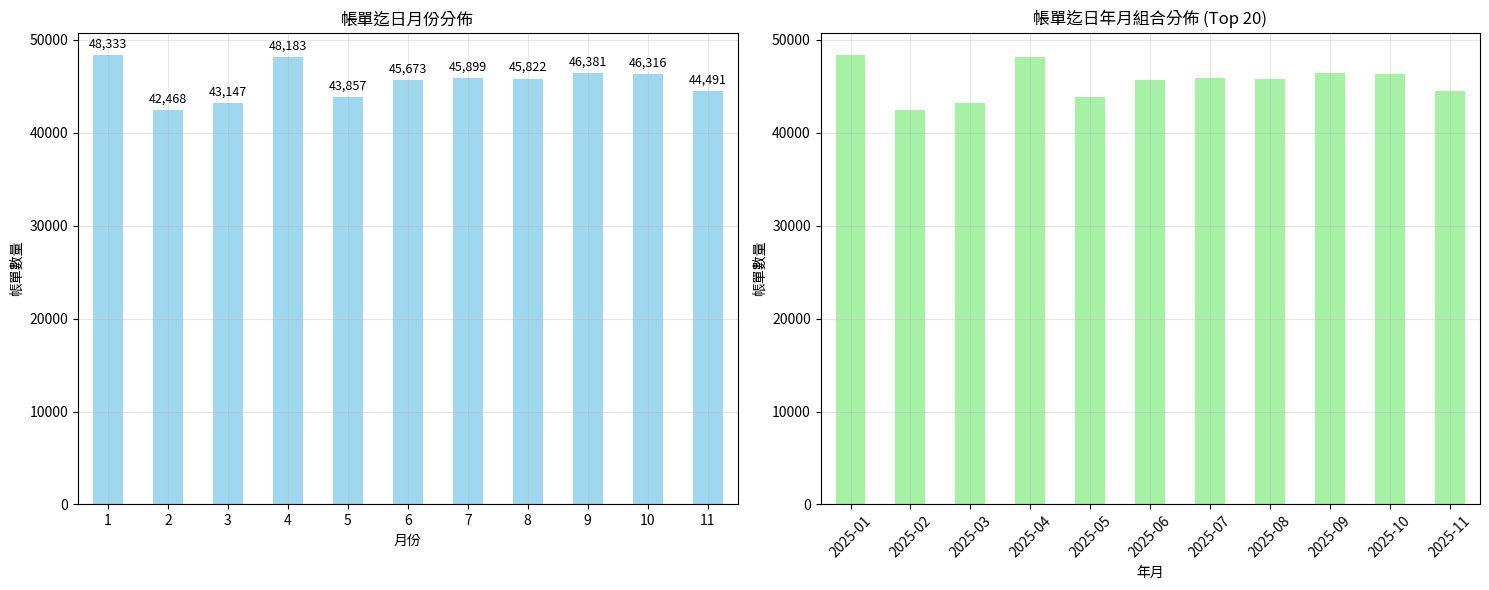


=== 保存統計結果 ===
✅ 月份分佈已保存至: ds_bill_帳單迄日_月份分佈.csv
✅ 年月分佈已保存至: ds_bill_帳單迄日_年月分佈.csv

=== 摘要統計 ===
資料期間: 2025-01-01 00:00:00 ~ 2025-11-30 00:00:00
涵蓋月份數: 11 個月
涵蓋年份數: 1 年
平均每月帳單數: 45506 筆
最高月份帳單數: 48333 筆 (第 1 月)
最低月份帳單數: 42468 筆 (第 2 月)

帳單迄日月份分佈統計完成


In [83]:
# 針對 ds_bill 中的 '帳單迄日' 所在月份進行數量分佈統計

print("=== ds_bill '帳單迄日' 月份分佈統計 ===")

# 檢查 ds_bill 是否存在且有 '帳單迄日' 欄位
if 'ds_bill' not in locals():
    print("❌ ds_bill 資料集不存在，請先載入資料")
else:
    print(f"ds_bill 資料形狀: {ds_bill.shape}")
    print(f"ds_bill 欄位: {list(ds_bill.columns)}")
    
    if '帳單迄日' not in ds_bill.columns:
        print("❌ ds_bill 中找不到 '帳單迄日' 欄位")
        print(f"可用欄位: {list(ds_bill.columns)}")
    else:
        # 檢查 '帳單迄日' 欄位的基本資訊
        print(f"\n=== '帳單迄日' 欄位基本資訊 ===")
        print(f"總筆數: {len(ds_bill)}")
        print(f"空值數量: {ds_bill['帳單迄日'].isnull().sum()}")
        print(f"非空值數量: {ds_bill['帳單迄日'].notnull().sum()}")
        print(f"資料型態: {ds_bill['帳單迄日'].dtype}")
        
        # 顯示前幾筆資料範例
        print(f"\n'帳單迄日' 前5筆資料範例:")
        print(ds_bill['帳單迄日'].head().tolist())
        
        # 嘗試轉換為日期格式並提取月份
        try:
            # 如果還不是 datetime 格式，先轉換
            if ds_bill['帳單迄日'].dtype == 'object':
                print(f"\n正在轉換 '帳單迄日' 為日期格式...")
                ds_bill_copy = ds_bill.copy()
                ds_bill_copy['帳單迄日'] = pd.to_datetime(ds_bill_copy['帳單迄日'], errors='coerce')
            else:
                ds_bill_copy = ds_bill.copy()
            
            # 檢查轉換結果
            conversion_success = ds_bill_copy['帳單迄日'].notnull().sum()
            conversion_failed = ds_bill_copy['帳單迄日'].isnull().sum()
            
            print(f"日期轉換結果:")
            print(f"  成功轉換: {conversion_success} 筆")
            print(f"  轉換失敗: {conversion_failed} 筆")
            
            if conversion_success > 0:
                # 提取月份
                ds_bill_copy['帳單迄日_月份'] = ds_bill_copy['帳單迄日'].dt.month
                
                # 統計月份分佈
                print(f"\n=== '帳單迄日' 月份分佈統計 ===")
                month_distribution = ds_bill_copy['帳單迄日_月份'].value_counts().sort_index()
                
                print("月份分佈:")
                for month, count in month_distribution.items():
                    if pd.notna(month):
                        month_name = pd.to_datetime(f"2024-{int(month):02d}-01").strftime('%B')
                        percentage = count / conversion_success * 100
                        print(f"  {int(month):2d}月 ({month_name:>9}): {count:>6,} 筆 ({percentage:>5.1f}%)")
                
                print(f"\n總計: {month_distribution.sum():,} 筆")
                
                # 顯示年月組合的詳細分佈
                print(f"\n=== 年月組合詳細分佈 ===")
                ds_bill_copy['帳單迄日_年月'] = ds_bill_copy['帳單迄日'].dt.to_period('M')
                year_month_distribution = ds_bill_copy['帳單迄日_年月'].value_counts().sort_index()
                
                print("年月組合分佈:")
                for year_month, count in year_month_distribution.items():
                    if pd.notna(year_month):
                        percentage = count / conversion_success * 100
                        print(f"  {year_month}: {count:>6,} 筆 ({percentage:>5.1f}%)")
                
                # 統計年份分佈
                print(f"\n=== 年份分佈統計 ===")
                ds_bill_copy['帳單迄日_年份'] = ds_bill_copy['帳單迄日'].dt.year
                year_distribution = ds_bill_copy['帳單迄日_年份'].value_counts().sort_index()
                
                print("年份分佈:")
                for year, count in year_distribution.items():
                    if pd.notna(year):
                        percentage = count / conversion_success * 100
                        print(f"  {int(year)}年: {count:>6,} 筆 ({percentage:>5.1f}%)")
                
                # 視覺化月份分佈
                import matplotlib.pyplot as plt
                
                fig, axes = plt.subplots(1, 2, figsize=(15, 6))
                
                # 月份分佈長條圖
                ax1 = axes[0]
                month_distribution.plot(kind='bar', ax=ax1, color='skyblue', alpha=0.8)
                ax1.set_title('帳單迄日月份分佈')
                ax1.set_xlabel('月份')
                ax1.set_ylabel('帳單數量')
                ax1.tick_params(axis='x', rotation=0)
                ax1.grid(True, alpha=0.3)
                
                # 在長條圖上顯示數值
                for i, (month, count) in enumerate(month_distribution.items()):
                    if pd.notna(month):
                        ax1.text(i, count + max(month_distribution) * 0.01, 
                                f'{count:,}', ha='center', va='bottom', fontsize=9)
                
                # 年月組合分佈（只顯示前20個）
                ax2 = axes[1]
                top_year_months = year_month_distribution.head(20)
                top_year_months.plot(kind='bar', ax=ax2, color='lightgreen', alpha=0.8)
                ax2.set_title('帳單迄日年月組合分佈 (Top 20)')
                ax2.set_xlabel('年月')
                ax2.set_ylabel('帳單數量')
                ax2.tick_params(axis='x', rotation=45)
                ax2.grid(True, alpha=0.3)
                
                plt.tight_layout()
                plt.show()
                
                # 保存統計結果
                print(f"\n=== 保存統計結果 ===")
                
                # 保存月份分佈
                month_dist_df = pd.DataFrame({
                    '月份': month_distribution.index,
                    '帳單數量': month_distribution.values,
                    '百分比': (month_distribution.values / conversion_success * 100).round(2)
                })
                month_dist_df['月份名稱'] = month_dist_df['月份'].apply(
                    lambda x: pd.to_datetime(f"2024-{int(x):02d}-01").strftime('%B') if pd.notna(x) else ''
                )
                month_dist_df.to_csv('ds_bill_帳單迄日_月份分佈.csv', index=False, encoding='utf-8-sig')
                print("✅ 月份分佈已保存至: ds_bill_帳單迄日_月份分佈.csv")
                
                # 保存年月組合分佈
                year_month_dist_df = pd.DataFrame({
                    '年月': year_month_distribution.index.astype(str),
                    '帳單數量': year_month_distribution.values,
                    '百分比': (year_month_distribution.values / conversion_success * 100).round(2)
                })
                year_month_dist_df.to_csv('ds_bill_帳單迄日_年月分佈.csv', index=False, encoding='utf-8-sig')
                print("✅ 年月分佈已保存至: ds_bill_帳單迄日_年月分佈.csv")
                
                # 摘要統計
                print(f"\n=== 摘要統計 ===")
                print(f"資料期間: {ds_bill_copy['帳單迄日'].min()} ~ {ds_bill_copy['帳單迄日'].max()}")
                print(f"涵蓋月份數: {len(month_distribution)} 個月")
                print(f"涵蓋年份數: {len(year_distribution)} 年")
                print(f"平均每月帳單數: {month_distribution.mean():.0f} 筆")
                print(f"最高月份帳單數: {month_distribution.max()} 筆 (第 {month_distribution.idxmax()} 月)")
                print(f"最低月份帳單數: {month_distribution.min()} 筆 (第 {month_distribution.idxmin()} 月)")
                
            else:
                print("❌ 所有日期轉換都失敗，無法進行月份統計")
                print("請檢查 '帳單迄日' 欄位的資料格式")
                
        except Exception as e:
            print(f"❌ 處理 '帳單迄日' 時發生錯誤: {e}")
            print("請檢查資料格式是否正確")

print("\n" + "="*60)
print("帳單迄日月份分佈統計完成")

In [84]:
ds_bill.to_csv('forPredict_ds_bill_2025_1_11_withEndDate.csv', index=False)

## @@ 整理目標區間帳單

In [464]:
ds_bill = pd.read_csv('forPredict_ds_bill_2025_1_11_withEndDate.csv')
output_target_filepath = f"forPredict_ds_billing_onehot_2025_{target_month_start}_{target_month_end}_all.csv"

In [465]:
# 日期區間過濾函式 - 針對帳單資料集 (ds_bill)
import pandas as pd
from typing import Optional


def filter_bill_data_by_date_range(
    df: pd.DataFrame,
    start_date: Optional[str] = None,
    end_date: Optional[str] = None,
    date_col: str = "帳單迄日",
    accepted_formats: tuple = (
        "%Y-%m-%d %H:%M:%S",
        "%Y/%m/%d %H:%M:%S",
        "%Y-%m-%d",
        "%Y/%m/%d",
    ),
) -> pd.DataFrame:
    """
    針對帳單資料集中的 '帳單迄日' 欄位，按指定日期區間篩選資料。
    
    參數:
    - df: 帳單資料集 DataFrame（通常為 ds_bill）
    - start_date: 起始日期（字串，格式如 '2025-01-01' 或 '2025/01/01'）
    - end_date: 結束日期（字串，格式如 '2025-12-31' 或 '2025/12/31'）
    - date_col: 日期欄位名稱（預設 '帳單迄日'）
    - accepted_formats: 日期格式列表，用於解析日期字串
    
    回傳:
    - 篩選後的 DataFrame（依日期區間過濾）
    
    使用範例:
    ```python
    # 篩選2025年1月至6月的帳單
    filtered = filter_bill_data_by_date_range(ds_bill, '2025-01-01', '2025-06-30')
    
    # 只篩選2025年7月後的帳單
    filtered = filter_bill_data_by_date_range(ds_bill, start_date='2025-07-01')
    
    # 篩選2024年全年帳單
    filtered = filter_bill_data_by_date_range(ds_bill, '2024-01-01', '2024-12-31')
    ```
    """
    
    if df is None or df.empty:
        print("⚠️ 輸入的 DataFrame 為空，回傳空 DataFrame")
        return pd.DataFrame()
    
    if date_col not in df.columns:
        print(f"❌ 找不到日期欄位 '{date_col}'")
        print(f"   可用欄位: {df.columns.tolist()}")
        return pd.DataFrame()
    
    # 複製資料以避免修改原始 DataFrame
    work_df = df.copy()
    
    def _safe_to_datetime(date_str):
        """安全地轉換日期字串"""
        if pd.isna(date_str):
            return pd.NaT
        
        s = str(date_str).strip()
        
        # 嘗試各種格式
        for fmt in accepted_formats:
            try:
                return pd.to_datetime(s, format=fmt)
            except Exception:
                continue
        
        # 最後由 pandas 自動推斷
        try:
            return pd.to_datetime(s, infer_datetime_format=True)
        except Exception:
            return pd.NaT
    
    # 進行日期轉換
    print(f"正在轉換 '{date_col}' 欄位...")
    work_df[date_col] = work_df[date_col].apply(_safe_to_datetime)
    
    # 統計轉換結果
    success_count = work_df[date_col].notna().sum()
    failed_count = work_df[date_col].isna().sum()
    total_count = len(work_df)
    
    print(f"日期轉換結果:")
    print(f"  成功: {success_count} 筆")
    print(f"  失敗: {failed_count} 筆")
    print(f"  總計: {total_count} 筆")
    
    # 移除無效日期
    work_df = work_df.dropna(subset=[date_col])
    
    if len(work_df) == 0:
        print("❌ 所有日期都無法轉換，無法進行篩選")
        return pd.DataFrame()
    
    # 解析開始與結束日期
    start_ts = pd.to_datetime(start_date) if start_date else None
    end_ts = pd.to_datetime(end_date) if end_date else None
    
    # 建立篩選條件
    mask = pd.Series([True] * len(work_df), index=work_df.index)
    
    if start_ts is not None:
        mask &= work_df[date_col] >= start_ts
        print(f"起始日期: {start_ts.date()}")
    
    if end_ts is not None:
        mask &= work_df[date_col] <= end_ts
        print(f"結束日期: {end_ts.date()}")
    
    # 應用篩選
    filtered_df = work_df.loc[mask].copy()
    
    # 統計篩選結果
    print(f"\n篩選結果:")
    print(f"  篩選前: {len(work_df):,} 筆")
    print(f"  篩選後: {len(filtered_df):,} 筆")
    print(f"  刪除: {len(work_df) - len(filtered_df):,} 筆")
    
    if len(work_df) > 0:
        retention_rate = len(filtered_df) / len(work_df) * 100
        print(f"  保留比例: {retention_rate:.2f}%")
    
    # 顯示篩選後的日期範圍
    if len(filtered_df) > 0:
        print(f"\n篩選後日期範圍:")
        print(f"  最早: {filtered_df[date_col].min()}")
        print(f"  最晚: {filtered_df[date_col].max()}")
        
        # 年月分佈統計
        period_counts = filtered_df[date_col].dt.to_period('M').value_counts().sort_index()
        print(f"\n年月分佈 (共 {len(period_counts)} 個月份):")
        for period, count in period_counts.items():
            print(f"  {period}: {count:,} 筆")
    
    # 按日期排序
    filtered_df = filtered_df.sort_values(by=date_col).reset_index(drop=True)
    
    return filtered_df


In [466]:
# 篩選迄日於2025年特定區間帳單
ds_bill_target = filter_bill_data_by_date_range(ds_bill, target_start_date, target_end_date)

正在轉換 '帳單迄日' 欄位...
日期轉換結果:
  成功: 500570 筆
  失敗: 0 筆
  總計: 500570 筆
起始日期: 2025-01-01
結束日期: 2025-09-30

篩選結果:
  篩選前: 500,570 筆
  篩選後: 409,762 筆
  刪除: 90,808 筆
  保留比例: 81.86%

篩選後日期範圍:
  最早: 2025-01-01 00:00:00
  最晚: 2025-09-30 00:00:00

年月分佈 (共 9 個月份):
  2025-01: 48,333 筆
  2025-02: 42,468 筆
  2025-03: 43,147 筆
  2025-04: 48,183 筆
  2025-05: 43,857 筆
  2025-06: 45,673 筆
  2025-07: 45,899 筆
  2025-08: 45,822 筆
  2025-09: 46,380 筆


In [467]:
ds_bill = ds_bill_target.copy()
ds_bill.head()

,客編,相關編號,帳單起日,帳單迄日,金額,銷帳日期,繳別,繳費方式,系統台
0,1197358,2573690,2024-12-02 00:00:00,2025-01-01,454,2025-02-20 00:00:00,1,廠商代收,台灣佳光
1,740251,814726,2024-12-02 00:00:00,2025-01-01,700,2024-11-25 00:00:00,1,CVS臨櫃代收(7-11),佳聯
2,1255951,2722131,2024-12-02 00:00:00,2025-01-01,300,2025-02-20 00:00:00,1,廠商代收,佳聯
3,1204151,2593678,2024-12-02 00:00:00,2025-01-01,694,2025-02-20 00:00:00,1,廠商代收,中投
4,1204024,2597847,2024-12-02 00:00:00,2025-01-01,454,2025-02-20 00:00:00,1,廠商代收,中投


In [468]:
# 計算平均繳款延遲日數
ds_bill['銷帳日期'] = pd.to_datetime(ds_bill['銷帳日期'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

# 解析 '帳單迄日'
ds_bill['帳單起日'] = pd.to_datetime(ds_bill['帳單起日'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

# 計算延遲日數
ds_bill['繳款延遲日數'] = (ds_bill['銷帳日期'] - ds_bill['帳單起日']).dt.days

# 移除無效記錄以計算平均
valid_bills = ds_bill.dropna(subset=['繳款延遲日數'])
avg_global = round(valid_bills['繳款延遲日數'].mean(), 2)

# 平均延遲日數
delay_avg = ds_bill.groupby('客編')['繳款延遲日數'].mean().reset_index()
delay_avg.columns = ['客編', '平均繳款延遲日數']

# 將全體平均補進 NaN 的客戶
all_customers = ds_bill[['客編']].drop_duplicates()
delay_filled = pd.merge(all_customers, delay_avg, on='客編', how='left')
delay_filled['平均繳款延遲日數'] = delay_filled['平均繳款延遲日數'].fillna(avg_global)

# 最常見繳費方式
payment_mode = ds_bill.groupby('客編')['繳費方式'] \
                   .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else '未知') \
                   .reset_index()
payment_mode.columns = ['客編', '最常見繳費方式']

# 取得每位客戶最常見的繳別
paytype_mode = ds_bill.groupby('客編')['繳別'] \
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else '未知') \
    .reset_index()
paytype_mode.columns = ['客編', '繳別']

# 將 '最常見繳別' 合併到 payment_mode
payment_mode = pd.merge(payment_mode, paytype_mode, on='客編', how='left')

# 合併帳單特徵
# bill_features = pd.merge(delay_avg, payment_mode, on='客編', how='outer')
bill_features = pd.merge(delay_filled, payment_mode, on='客編', how='left')

# 合併系統台資訊
bill_features = bill_features.merge(
    ds_bill[['客編', '系統台']].drop_duplicates(subset='客編'), 
    on='客編', 
    how='left'
)


In [469]:
print(bill_features.head())
bill_features['平均繳款延遲日數'].value_counts(dropna=False)

        客編   平均繳款延遲日數        最常見繳費方式  繳別   系統台
0  1197358  75.000000           廠商代收   1  台灣佳光
1   740251  -7.666667  CVS臨櫃代收(7-11)   1    佳聯
2  1255951  74.444444           廠商代收   1    佳聯
3  1204151  74.444444           廠商代收   1    中投
4  1204024  75.000000           廠商代收   1    中投


平均繳款延遲日數
 1.000000      2109
 75.111111     1687
-16.000000     1468
 2.000000      1415
 74.444444     1411
               ... 
-163.000000       1
 199.000000       1
 138.000000       1
-389.000000       1
 349.000000       1
Name: count, Length: 2701, dtype: int64

In [470]:
import pandas as pd

df = bill_features.copy()
# 假設您的資料集已載入為 df
# df = pd.read_csv('bill_features.csv')  # 或其他載入方式

# 假設平均繳款延遲日數的欄位名稱為 'avg_delay_days'
# 您需要根據實際欄位名稱調整

# 篩選平均繳款延遲日數 > 100天的記錄
delay_over_100 = df[df['平均繳款延遲日數'] > 100]

# 篩選平均繳款延遲日數 < 100天的記錄  
delay_under_minus100 = df[df['平均繳款延遲日數'] < -100]

# 顯示結果
print("平均繳款延遲日數 > 100天的記錄:")
print(delay_over_100)
print(f"共有 {len(delay_over_100)} 筆記錄")

print("\n平均繳款延遲日數 < -100天的記錄:")
print(delay_under_minus100)
print(f"共有 {len(delay_under_minus100)} 筆記錄")

平均繳款延遲日數 > 100天的記錄:
             客編  平均繳款延遲日數         最常見繳費方式  繳別    系統台
2521     782604     142.0   CVS臨櫃代收(7-11)   6     中投
3950    1079497     176.0   CVS臨櫃代收(7-11)   6   台灣佳光
7555     530927     105.0   CVS臨櫃代收(7-11)   1     中投
8342    1091529     150.5  簡訊帳單臨櫃代收(7-11)   6   台灣佳光
9637    1204935     193.0  簡訊帳單臨櫃代收(7-11)   1     大屯
...         ...       ...             ...  ..    ...
101265  1216010     150.0   CVS臨櫃代收(7-11)  12  台灣佳光二
101266  1216028     150.0   CVS臨櫃代收(7-11)  12  台灣佳光二
101309   935437     278.0  簡訊帳單臨櫃代收(7-11)  12     佳聯
101406   930747     125.0  簡訊帳單臨櫃代收(7-11)  12     佳聯
101999  1098907     135.0            稽核收款   6     大屯

[400 rows x 5 columns]
共有 400 筆記錄

平均繳款延遲日數 < -100天的記錄:
             客編  平均繳款延遲日數        最常見繳費方式  繳別 系統台
1043     977193  -109.375  CVS臨櫃代收(7-11)  12  佳聯
12919    383551  -158.000  CVS臨櫃代收(7-11)   6  佳聯
14316   1230633  -111.000  CVS臨櫃代收(7-11)   1  中投
14866   1215796  -308.000  CVS臨櫃代收(7-11)   1  中投
24151    831957  -182.000  CVS臨櫃代收(7-11)  

In [471]:
'''
# 查詢並列印 ds_bill 中特定客編的資料
def print_customer_data(dataframe, customer_id, id_column='客編', verbose=True):
    """
    查詢並列印 DataFrame 中特定客編的完整資料
    
    Parameters:
    -----------
    dataframe : pandas.DataFrame
        要查詢的資料框
    customer_id : str or int
        客編
    id_column : str
        客編欄位名稱（預設：'客編'）
    verbose : bool
        是否顯示詳細訊息
    
    Returns:
    --------
    pandas.DataFrame or None
        符合條件的資料，若無則返回 None
    """
    
    # 確保客編為字串型態
    customer_id = str(customer_id)
    
    # 查詢資料
    customer_data = dataframe[dataframe[id_column].astype(str) == customer_id]
    
    if customer_data.empty:
        print(f"❌ 找不到客編 {customer_id} 的資料")
        return None
    
    num_records = len(customer_data)
    
    if verbose:
        print("=" * 80)
        print(f"📊 客編 {customer_id} 的資料")
        print("=" * 80)
        print(f"\n📋 找到 {num_records} 筆記錄\n")
    
    if num_records == 1:
        # 單筆記錄 - 詳細顯示
        record = customer_data.iloc[0]
        print("✅ 詳細資訊:")
        print("-" * 80)
        for i, (column, value) in enumerate(record.items(), 1):
            # 判斷值的型態，適當格式化顯示
            if pd.isna(value):
                display_value = "⚠️  [NULL/NaN]"
            elif isinstance(value, (int, float)):
                if isinstance(value, float) and value == int(value):
                    display_value = int(value)
                else:
                    display_value = value
            else:
                display_value = str(value)
            
            print(f"{i:2d}. {column:30s}: {display_value}")
    else:
        # 多筆記錄 - 表格顯示
        print("✅ 資料表格 (共 {} 筆):\n".format(num_records))
        pd.set_option('display.max_columns', None)
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', None)
        pd.set_option('display.max_colwidth', None)
        print(customer_data.to_string())
        pd.reset_option('display.max_columns', 'display.max_rows', 'display.width', 'display.max_colwidth')
    
    if verbose:
        print("\n" + "=" * 80)
        print(f"📊 資料統計:")
        print(f"   欄位數量: {len(customer_data.columns)}")
        print(f"   記錄筆數: {num_records}")
        
        # 統計空值
        null_counts = customer_data.isnull().sum()
        null_fields = null_counts[null_counts > 0]
        if len(null_fields) > 0:
            print(f"   空值欄位: {len(null_fields)} 個")
            for field, count in null_fields.items():
                print(f"      - {field}: {count}")
        else:
            print(f"   空值欄位: 0 個")
        print("=" * 80)
    
    return customer_data


# === 執行查詢 ===
customer_id = 143886
customer_info = print_customer_data(ds_bill, customer_id)

# 如果需要進一步分析，可以使用返回的 DataFrame
if customer_info is not None:
    print("\n💡 若需要額外分析:")
    print("   - 可以使用 customer_info.describe() 查看數值統計")
    print("   - 可以使用 customer_info.info() 查看欄位型態")
    print("   - 可以使用 customer_info.to_csv('customer_1099407.csv', index=False) 儲存資料")
'''

'\n# 查詢並列印 ds_bill 中特定客編的資料\ndef print_customer_data(dataframe, customer_id, id_column=\'客編\', verbose=True):\n    """\n    查詢並列印 DataFrame 中特定客編的完整資料\n\n    Parameters:\n    -----------\n    dataframe : pandas.DataFrame\n        要查詢的資料框\n    customer_id : str or int\n        客編\n    id_column : str\n        客編欄位名稱（預設：\'客編\'）\n    verbose : bool\n        是否顯示詳細訊息\n\n    Returns:\n    --------\n    pandas.DataFrame or None\n        符合條件的資料，若無則返回 None\n    """\n\n    # 確保客編為字串型態\n    customer_id = str(customer_id)\n\n    # 查詢資料\n    customer_data = dataframe[dataframe[id_column].astype(str) == customer_id]\n\n    if customer_data.empty:\n        print(f"❌ 找不到客編 {customer_id} 的資料")\n        return None\n\n    num_records = len(customer_data)\n\n    if verbose:\n        print("=" * 80)\n        print(f"📊 客編 {customer_id} 的資料")\n        print("=" * 80)\n        print(f"\n📋 找到 {num_records} 筆記錄\n")\n\n    if num_records == 1:\n        # 單筆記錄 - 詳細顯示\n        record = customer_data.iloc[0]\n  

In [472]:
ds_bill.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 409762 entries, 0 to 409761
Data columns (total 10 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   客編      409762 non-null  int64         
 1   相關編號    409762 non-null  int64         
 2   帳單起日    409762 non-null  datetime64[ns]
 3   帳單迄日    409762 non-null  datetime64[ns]
 4   金額      409762 non-null  int64         
 5   銷帳日期    409762 non-null  datetime64[ns]
 6   繳別      409762 non-null  int64         
 7   繳費方式    409762 non-null  object        
 8   系統台     409762 non-null  object        
 9   繳款延遲日數  409762 non-null  int64         
dtypes: datetime64[ns](3), int64(5), object(2)
memory usage: 31.3+ MB


In [473]:
bill_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102085 entries, 0 to 102084
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   客編        102085 non-null  int64  
 1   平均繳款延遲日數  102085 non-null  float64
 2   最常見繳費方式   102085 non-null  object 
 3   繳別        102085 non-null  int64  
 4   系統台       102085 non-null  object 
dtypes: float64(1), int64(2), object(2)
memory usage: 3.9+ MB


In [474]:
ds_bill = bill_features.copy()

In [475]:
ds_bill.head()

,客編,平均繳款延遲日數,最常見繳費方式,繳別,系統台
0,1197358,75.000000,廠商代收,1,台灣佳光
1,740251,-7.666667,CVS臨櫃代收(7-11),1,佳聯
2,1255951,74.444444,廠商代收,1,佳聯
3,1204151,74.444444,廠商代收,1,中投
4,1204024,75.000000,廠商代收,1,中投


In [476]:
# 刪除 ds_bill 中平均繳款延遲日數 > 100 的資料，改為同時刪掉平均繳款延遲日數 >100及<-100資料
def filter_payment_delay(df, column_name='平均繳款延遲日數', upper_threshold=100, lower_threshold=-100, verbose=True):
    """
    刪除 DataFrame 中指定欄位超過閾值的資料
    
    Parameters:
    -----------
    df : pd.DataFrame
        要處理的 DataFrame
    column_name : str
        要過濾的欄位名稱，預設為 '平均繳款延遲日數'
    upper_threshold : float
        上限閾值，預設為 100（刪除大於此值的記錄）
    lower_threshold : float
        下限閾值，預設為 -100（刪除小於此值的記錄）
    verbose : bool
        是否顯示詳細資訊，預設為 True
    
    Returns:
    --------
    pd.DataFrame
        過濾後的 DataFrame
    """
    
    if verbose:
        print("=" * 80)
        print(f"🗑️ 刪除 {column_name} 超出範圍 [{lower_threshold}, {upper_threshold}] 的資料")
        print("=" * 80)
    
    # 檢查欄位是否存在
    if column_name not in df.columns:
        print(f"❌ 找不到欄位 '{column_name}'")
        print(f"可用欄位: {list(df.columns)}")
        return df.copy()
    
    # 顯示刪除前的統計
    if verbose:
        print(f"\n📊 刪除前統計:")
        print(f"   總筆數: {len(df):,}")
        if '客編' in df.columns:
            print(f"   總客戶數: {df['客編'].nunique():,}")
        
        # 檢查欄位的分布
        print(f"\n📈 {column_name} 統計:")
        print(f"   最小值: {df[column_name].min():.2f}")
        print(f"   最大值: {df[column_name].max():.2f}")
        print(f"   平均值: {df[column_name].mean():.2f}")
        print(f"   中位數: {df[column_name].median():.2f}")
    
    # 計算待刪除的記錄數
    rows_to_delete_upper = df[df[column_name] > upper_threshold]
    rows_to_delete_lower = df[df[column_name] < lower_threshold]
    num_to_delete_upper = len(rows_to_delete_upper)
    num_to_delete_lower = len(rows_to_delete_lower)
    num_to_delete_total = num_to_delete_upper + num_to_delete_lower
    
    if verbose:
        print(f"\n🔍 待刪除記錄:")
        print(f"   {column_name} > {upper_threshold} 的筆數: {num_to_delete_upper:,}")
        print(f"   {column_name} < {lower_threshold} 的筆數: {num_to_delete_lower:,}")
        print(f"   總待刪除筆數: {num_to_delete_total:,}")
        print(f"   刪除比例: {num_to_delete_total / len(df) * 100:.2f}%")
        
        if num_to_delete_upper > 0:
            print(f"\n📊 待刪除資料 (> {upper_threshold}) 的 {column_name} 分布 (前10):")
            delete_dist = rows_to_delete_upper[column_name].value_counts().sort_index(ascending=False).head(10)
            for value, count in delete_dist.items():
                print(f"   {value:>8.2f}: {count:>5,} 筆")
        
        if num_to_delete_lower > 0:
            print(f"\n📊 待刪除資料 (< {lower_threshold}) 的 {column_name} 分布 (前10):")
            delete_dist = rows_to_delete_lower[column_name].value_counts().sort_index().head(10)
            for value, count in delete_dist.items():
                print(f"   {value:>8.2f}: {count:>5,} 筆")
    
    # 執行過濾操作
    if verbose:
        print(f"\n🔄 執行過濾操作...")
    
    df_before = len(df)
    df_filtered = df[(df[column_name] >= lower_threshold) & (df[column_name] <= upper_threshold)].copy()
    df_filtered = df_filtered.reset_index(drop=True)
    df_after = len(df_filtered)
    
    # 顯示過濾後的統計
    if verbose:
        print(f"\n✅ 過濾完成!")
        print(f"\n📊 過濾後統計:")
        print(f"   總筆數: {df_after:,} (原本: {df_before:,})")
        print(f"   刪除筆數: {df_before - df_after:,}")
        print(f"   保留比例: {df_after / df_before * 100:.2f}%")
        if '客編' in df_filtered.columns:
            print(f"   總客戶數: {df_filtered['客編'].nunique():,}")
        
        # 檢查過濾後的統計
        print(f"\n📈 過濾後 {column_name} 統計:")
        print(f"   最小值: {df_filtered[column_name].min():.2f}")
        print(f"   最大值: {df_filtered[column_name].max():.2f}")
        print(f"   平均值: {df_filtered[column_name].mean():.2f}")
        print(f"   中位數: {df_filtered[column_name].median():.2f}")
        
        print("\n" + "=" * 80)
    
    return df_filtered


# 應用函數到 ds_bill
ds_bill = filter_payment_delay(
    ds_bill, 
    column_name='平均繳款延遲日數', 
    upper_threshold=100, 
    lower_threshold=-100,
    verbose=True
)

🗑️ 刪除 平均繳款延遲日數 超出範圍 [-100, 100] 的資料

📊 刪除前統計:
   總筆數: 102,085
   總客戶數: 102,085

📈 平均繳款延遲日數 統計:
   最小值: -1592.00
   最大值: 2488.00
   平均值: 17.60
   中位數: 5.00

🔍 待刪除記錄:
   平均繳款延遲日數 > 100 的筆數: 400
   平均繳款延遲日數 < -100 的筆數: 74
   總待刪除筆數: 474
   刪除比例: 0.46%

📊 待刪除資料 (> 100) 的 平均繳款延遲日數 分布 (前10):
    2488.00:     1 筆
    2217.00:     1 筆
    2099.00:     1 筆
    2055.00:     1 筆
    1951.00:     1 筆
    1686.00:     1 筆
    1344.00:     1 筆
    1340.00:     1 筆
    1157.00:     1 筆
    1143.00:     1 筆

📊 待刪除資料 (< -100) 的 平均繳款延遲日數 分布 (前10):
   -1592.00:     1 筆
    -449.00:     1 筆
    -389.00:     1 筆
    -374.00:     1 筆
    -368.00:     1 筆
    -364.00:     1 筆
    -362.00:     1 筆
    -359.00:     1 筆
    -355.00:     1 筆
    -353.00:     1 筆

🔄 執行過濾操作...

✅ 過濾完成!

📊 過濾後統計:
   總筆數: 101,611 (原本: 102,085)
   刪除筆數: 474
   保留比例: 99.54%
   總客戶數: 101,611

📈 過濾後 平均繳款延遲日數 統計:
   最小值: -100.00
   最大值: 100.00
   平均值: 16.91
   中位數: 5.00



In [477]:
ds_bill.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101611 entries, 0 to 101610
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   客編        101611 non-null  int64  
 1   平均繳款延遲日數  101611 non-null  float64
 2   最常見繳費方式   101611 non-null  object 
 3   繳別        101611 non-null  int64  
 4   系統台       101611 non-null  object 
dtypes: float64(1), int64(2), object(2)
memory usage: 3.9+ MB


In [478]:
# ds_bill 資料集中的 '繳別' 欄位，保留其數值為1、3、6、12、15，其餘數值改為 99 , 意指其他週期繳別
# import pandas as pd

# Assuming ds_bill is already loaded
# ds_bill = pd.read_csv('/content/drive/Othercomputers/我的筆記型電腦/ExpertBook/2025/用戶資料集/TrainData/ds_numService_with_billing.csv', sep=',')

# Replace values in '繳別' column not in [1, 3, 6, 12, 15] with 99
ds_bill['繳別'] = ds_bill['繳別'].apply(lambda x: x if x in [1, 3, 6, 12, 15] else 99)

# Display the modified DataFrame (optional)
print(ds_bill.head())
print(ds_bill['繳別'].value_counts())

        客編   平均繳款延遲日數        最常見繳費方式  繳別   系統台
0  1197358  75.000000           廠商代收   1  台灣佳光
1   740251  -7.666667  CVS臨櫃代收(7-11)   1    佳聯
2  1255951  74.444444           廠商代收   1    佳聯
3  1204151  74.444444           廠商代收   1    中投
4  1204024  75.000000           廠商代收   1    中投
繳別
1     38961
6     35346
12    21821
3      2404
15     2235
99      844
Name: count, dtype: int64


In [479]:
# 最常見繳費方式計算，Assuming ds_bill is already loaded
# ds_bill = pd.read_csv('/content/drive/Othercomputers/我的筆記型電腦/ExpertBook/2025/用戶資料集/TrainData/ds_numService_with_billing.csv', sep=',')

# List of payment methods to keep
allowed_payment_methods = [
    "CVS臨櫃代收(7-11)",
    "廠商代收",
    "簡訊帳單臨櫃代收(7-11)",
    "金融機構轉帳",
    "當月繳帳單",
    "信用卡扣款",
    "APP臨櫃代收(7-11)"
]

# Replace other payment methods with '其他繳款方式'
ds_bill['最常見繳費方式'] = ds_bill['最常見繳費方式'].apply(lambda x: x if x in allowed_payment_methods else '其他繳款方式')

# Display the modified DataFrame (optional)
print(ds_bill.head())
print(ds_bill['最常見繳費方式'].value_counts())

        客編   平均繳款延遲日數        最常見繳費方式  繳別   系統台
0  1197358  75.000000           廠商代收   1  台灣佳光
1   740251  -7.666667  CVS臨櫃代收(7-11)   1    佳聯
2  1255951  74.444444           廠商代收   1    佳聯
3  1204151  74.444444           廠商代收   1    中投
4  1204024  75.000000           廠商代收   1    中投
最常見繳費方式
CVS臨櫃代收(7-11)     40863
廠商代收              32695
簡訊帳單臨櫃代收(7-11)    23527
金融機構轉帳             1816
當月繳帳單              1048
信用卡扣款              1011
其他繳款方式              628
APP臨櫃代收(7-11)        23
Name: count, dtype: int64


In [480]:
# ⬜ One-Hot Encoding 
# 1. 安裝／載入必要套件（Colab 已內建 pandas，通常不必另外安裝）
# import pandas as pd

# ⬜ 2. 讀取來源檔案
# ▸ 方式 A：直接從「檔案」側邊欄手動上傳 csv，再用下列路徑讀取
# file_path = "/content/ds_numService_with_billing.csv"   # ← 上傳後 Colab 的預設路徑

# ▸ 方式 B：若檔案在 Google Drive，先掛載 Drive
# from google.colab import drive
# drive.mount('/content/drive')
# file_path = "/content/drive/MyDrive/your_folder/ds_numService_with_billing.csv"

# df = pd.read_csv(file_path)
df = ds_bill.copy()

print("原始資料筆數：", df.shape)

# ⬜ 3. 指定要做 one‑hot 的欄位
one_hot_cols = ["繳別", "最常見繳費方式"]

# 自訂各欄位的前綴（prefix）以便辨識
prefix_map = {
    "繳別": "paytype",
    "最常見繳費方式": "paymethod"
}

# ⬜ 4. 進行 one‑hot
df_encoded = pd.get_dummies(
    df,
    columns=one_hot_cols,
    prefix=[prefix_map[col] for col in one_hot_cols],
    dtype=int               # 產生 0/1 的 int 欄位
)



原始資料筆數： (101611, 5)


In [481]:
# ⬜ 5. 儲存處理後檔案
output_path = output_target_filepath
df_encoded.to_csv(output_path, index=False, encoding="utf-8-sig")
print("完成 one‑hot 編碼，輸出檔案路徑:", output_path)

# ⬜ 6. 快速預覽前 5 列
df_encoded.head()

完成 one‑hot 編碼，輸出檔案路徑: forPredict_ds_billing_onehot_2025_1_9_all.csv


,客編,平均繳款延遲日數,系統台,paytype_1,paytype_3,paytype_6,paytype_12,paytype_15,paytype_99,paymethod_APP臨櫃代收(7-11),paymethod_CVS臨櫃代收(7-11),paymethod_信用卡扣款,paymethod_其他繳款方式,paymethod_廠商代收,paymethod_當月繳帳單,paymethod_簡訊帳單臨櫃代收(7-11),paymethod_金融機構轉帳
0,1197358,75.000000,台灣佳光,1,0,0,0,0,0,0,0,0,0,1,0,0,0
1,740251,-7.666667,佳聯,1,0,0,0,0,0,0,1,0,0,0,0,0,0
2,1255951,74.444444,佳聯,1,0,0,0,0,0,0,0,0,0,1,0,0,0
3,1204151,74.444444,中投,1,0,0,0,0,0,0,0,0,0,1,0,0,0
4,1204024,75.000000,中投,1,0,0,0,0,0,0,0,0,0,1,0,0,0


In [482]:
# <<<Avoid redundant reloading for H1 and by EndDate Billing datasets>>> 
ds_bill=pd.read_csv(output_target_filepath)
# ds_service = pd.read_csv('forPredict_service_enhanced.csv', sep='^')
# ds_service = pd.read_csv('forPredict_ds_doService_2025h1_all.csv', sep='^')

In [483]:
ds_bill.head()

,客編,平均繳款延遲日數,系統台,paytype_1,paytype_3,paytype_6,paytype_12,paytype_15,paytype_99,paymethod_APP臨櫃代收(7-11),paymethod_CVS臨櫃代收(7-11),paymethod_信用卡扣款,paymethod_其他繳款方式,paymethod_廠商代收,paymethod_當月繳帳單,paymethod_簡訊帳單臨櫃代收(7-11),paymethod_金融機構轉帳
0,1197358,75.000000,台灣佳光,1,0,0,0,0,0,0,0,0,0,1,0,0,0
1,740251,-7.666667,佳聯,1,0,0,0,0,0,0,1,0,0,0,0,0,0
2,1255951,74.444444,佳聯,1,0,0,0,0,0,0,0,0,0,1,0,0,0
3,1204151,74.444444,中投,1,0,0,0,0,0,0,0,0,0,1,0,0,0
4,1204024,75.000000,中投,1,0,0,0,0,0,0,0,0,0,1,0,0,0


In [484]:
ds_bill['系統台'].value_counts()

系統台
大屯       25392
台灣佳光     23143
中投       22411
佳聯       20414
北港        7361
台灣佳光二     2661
台基科二       218
台灣佳光三       11
Name: count, dtype: int64

In [485]:
# 依系統台名稱過濾 ds_bill，僅保留指定系統台的帳單資料
import pandas as pd
from typing import Iterable, Optional


def filter_bill_by_system(
    df: pd.DataFrame,
    systems: Optional[Iterable[str]] = None,
    system_col: str = "系統台",
) -> pd.DataFrame:
    """
    過濾 ds_bill，只保留指定系統台的資料。

    參數:
    - df: 帳單資料集（如 ds_bill）
    - systems: 要保留的系統台清單或集合，例如 ['大屯', '佳光']。
      若為 None 或空集合，則直接回傳原資料。
    - system_col: 系統台欄位名稱，預設 '系統台'。

    回傳:
    - 篩選後的 DataFrame（若欄位不存在或輸入為空，回傳空 DataFrame）。
    """
    if df is None or df.empty:
        print("⚠️ 輸入的帳單資料為空，回傳空 DataFrame")
        return pd.DataFrame()

    if not systems:
        print("⚠️ 未指定系統台清單，直接回傳原資料")
        return df.copy()

    if system_col not in df.columns:
        print(f"❌ 找不到系統台欄位 '{system_col}'，可用欄位: {df.columns.tolist()}")
        return pd.DataFrame()

    # 標準化系統台清單並過濾
    target = {str(s).strip() for s in systems if pd.notna(s)}
    if not target:
        print("⚠️ 系統台清單為空，直接回傳原資料")
        return df.copy()

    mask = df[system_col].astype(str).str.strip().isin(target)
    filtered = df.loc[mask].copy()

    print("系統台篩選結果:")
    print(f"  輸入筆數: {len(df):,}")
    print(f"  保留筆數: {len(filtered):,}")
    print(f"  刪除筆數: {len(df) - len(filtered):,}")

    if len(filtered) > 0:
        dist = filtered[system_col].value_counts()
        print("  保留系統台分布:")
        for name, cnt in dist.items():
            print(f"    {name}: {cnt:,} 筆")

    return filtered


In [486]:
# 保留特定系統台
ds_bill_filtered = filter_bill_by_system(ds_bill, ["大屯", "台灣佳光", "中投", "佳聯", "北港"])

系統台篩選結果:
  輸入筆數: 101,611
  保留筆數: 98,721
  刪除筆數: 2,890
  保留系統台分布:
    大屯: 25,392 筆
    台灣佳光: 23,143 筆
    中投: 22,411 筆
    佳聯: 20,414 筆
    北港: 7,361 筆


In [487]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 329845 entries, 0 to 329844
Data columns (total 10 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   客編      329845 non-null  int64 
 1   產品名稱    329845 non-null  object
 2   用戶種類    329845 non-null  object
 3   相關編號    329845 non-null  int64 
 4   起日      329845 non-null  object
 5   迄日      180396 non-null  object
 6   系統台     329845 non-null  object
 7   地區      329836 non-null  object
 8   繳別      329845 non-null  int64 
 9   使用狀態    329845 non-null  object
dtypes: int64(3), object(7)
memory usage: 25.2+ MB


In [488]:
# 分析 dataset 中起日於 2025 年的分佈情形
'''
import pandas as pd
import matplotlib.pyplot as plt

print("=== dataset 中起日於 2025 年的分佈情形 ===")
print("="*80)

# 1. 檢查起日欄位
if '起日' not in dataset.columns:
    print("❌ 錯誤: 找不到 '起日' 欄位")
    print(f"可用欄位: {list(dataset.columns)}")
else:
    # 2. 確保起日為日期格式
    if dataset['起日'].dtype != 'datetime64[ns]':
        print("🔄 轉換起日為日期格式...")
        dataset['起日'] = pd.to_datetime(dataset['起日'], errors='coerce')
    
    # 3. 基本統計
    print(f"\n📊 起日基本統計:")
    print(f"   總記錄數: {len(dataset):,}")
    print(f"   起日空值: {dataset['起日'].isnull().sum():,}")
    print(f"   起日最早: {dataset['起日'].min()}")
    print(f"   起日最晚: {dataset['起日'].max()}")
    
    # 4. 篩選 2025 年的資料
    print(f"\n🔍 篩選 2025 年的資料...")
    dataset_2025 = dataset[
        (dataset['起日'].dt.year == 2025) & (dataset['起日'].notnull())
    ].copy()
    
    print(f"   2025 年記錄數: {len(dataset_2025):,}")
    print(f"   佔總比例: {len(dataset_2025)/len(dataset)*100:.2f}%")
    
    # 5. 2025 年的日期範圍
    if len(dataset_2025) > 0:
        print(f"\n📅 2025 年日期範圍:")
        print(f"   最早日期: {dataset_2025['起日'].min()}")
        print(f"   最晚日期: {dataset_2025['起日'].max()}")
        
        # 6. 按月份分佈
        print(f"\n📈 2025 年按月份分佈:")
        dataset_2025['月份'] = dataset_2025['起日'].dt.month
        monthly_dist = dataset_2025['月份'].value_counts().sort_index()
        
        month_names = {
            1: '1月', 2: '2月', 3: '3月', 4: '4月', 5: '5月', 6: '6月',
            7: '7月', 8: '8月', 9: '9月', 10: '10月', 11: '11月', 12: '12月'
        }
        
        total_2025 = len(dataset_2025)
        for month, count in monthly_dist.items():
            pct = count / total_2025 * 100
            month_name = month_names.get(month, f'{month}月')
            bar = '█' * int(pct / 2)  # 視覺化條形
            print(f"   {month_name}: {count:>5,} 筆 ({pct:>5.2f}%) {bar}")
        
        # 7. 按日期分佈（每日記錄數）
        print(f"\n📆 2025 年按日期分佈 (前20天):")
        daily_dist = dataset_2025['起日'].value_counts().sort_index().head(20)
        
        for date, count in daily_dist.items():
            pct = count / total_2025 * 100
            print(f"   {date.strftime('%Y-%m-%d')}: {count:>4,} 筆 ({pct:>5.2f}%)")
        
        if len(daily_dist) < len(dataset_2025['起日'].unique()):
            remaining_days = len(dataset_2025['起日'].unique()) - 20
            print(f"   ... 還有 {remaining_days} 天")
        
        # 8. 按週分佈
        print(f"\n📊 2025 年按週分佈:")
        dataset_2025['週'] = dataset_2025['起日'].dt.isocalendar().week
        weekly_dist = dataset_2025['週'].value_counts().sort_index()
        
        for week, count in weekly_dist.head(10).items():
            pct = count / total_2025 * 100
            print(f"   第 {week:2d} 週: {count:>5,} 筆 ({pct:>5.2f}%)")
        
        if len(weekly_dist) > 10:
            print(f"   ... 還有 {len(weekly_dist)-10} 週")
        
        # 9. 按季度分佈
        print(f"\n📈 2025 年按季度分佈:")
        dataset_2025['季度'] = dataset_2025['起日'].dt.quarter
        quarterly_dist = dataset_2025['季度'].value_counts().sort_index()
        
        for quarter, count in quarterly_dist.items():
            pct = count / total_2025 * 100
            print(f"   第 {quarter} 季: {count:>6,} 筆 ({pct:>5.2f}%)")
        
        # 10. 統計摘要
        print(f"\n📊 統計摘要:")
        print(f"   平均每月: {total_2025/len(monthly_dist):.0f} 筆")
        print(f"   平均每週: {total_2025/len(weekly_dist):.0f} 筆")
        print(f"   平均每天: {total_2025/len(dataset_2025['起日'].unique()):.1f} 筆")
        print(f"   最多的月份: {month_names[monthly_dist.idxmax()]} ({monthly_dist.max():,} 筆)")
        print(f"   最少的月份: {month_names[monthly_dist.idxmin()]} ({monthly_dist.min():,} 筆)")
        
        # 11. 產品分佈（如果有的話）
        if '產品名稱' in dataset_2025.columns:
            print(f"\n🏷️  2025 年產品分佈:")
            product_dist = dataset_2025['產品名稱'].value_counts()
            for product, count in product_dist.items():
                pct = count / total_2025 * 100
                print(f"   {product}: {count:>6,} 筆 ({pct:>5.2f}%)")
        
        # 12. 月份-日期熱力圖資料
        print(f"\n📌 2025 年月份詳細統計:")
        for month, count in monthly_dist.items():
            month_name = month_names.get(month, f'{month}月')
            month_data = dataset_2025[dataset_2025['月份'] == month]
            
            # 該月的日期統計
            days_with_data = month_data['起日'].dt.day.nunique()
            avg_per_day = count / days_with_data if days_with_data > 0 else 0
            
            print(f"   {month_name}: {count:>5,} 筆 | {days_with_data:>2d} 天 | 平均每天: {avg_per_day:.1f} 筆")
    
    else:
        print("❌ 沒有發現 2025 年的資料")
    
    # 13. 2025 年與其他年份的比較
    print(f"\n📊 各年份資料分佈對比:")
    dataset['年份'] = dataset['起日'].dt.year
    yearly_dist = dataset['年份'].value_counts().sort_index()
    
    for year, count in yearly_dist.items():
        pct = count / len(dataset) * 100
        year_label = f'{int(year)}年' if pd.notna(year) else '空值'
        print(f"   {year_label}: {count:>6,} 筆 ({pct:>5.2f}%)")

print("\n" + "="*80)
'''

'\nimport pandas as pd\nimport matplotlib.pyplot as plt\n\nprint("=== dataset 中起日於 2025 年的分佈情形 ===")\nprint("="*80)\n\n# 1. 檢查起日欄位\nif \'起日\' not in dataset.columns:\n    print("❌ 錯誤: 找不到 \'起日\' 欄位")\n    print(f"可用欄位: {list(dataset.columns)}")\nelse:\n    # 2. 確保起日為日期格式\n    if dataset[\'起日\'].dtype != \'datetime64[ns]\':\n        print("🔄 轉換起日為日期格式...")\n        dataset[\'起日\'] = pd.to_datetime(dataset[\'起日\'], errors=\'coerce\')\n\n    # 3. 基本統計\n    print(f"\n📊 起日基本統計:")\n    print(f"   總記錄數: {len(dataset):,}")\n    print(f"   起日空值: {dataset[\'起日\'].isnull().sum():,}")\n    print(f"   起日最早: {dataset[\'起日\'].min()}")\n    print(f"   起日最晚: {dataset[\'起日\'].max()}")\n\n    # 4. 篩選 2025 年的資料\n    print(f"\n🔍 篩選 2025 年的資料...")\n    dataset_2025 = dataset[\n        (dataset[\'起日\'].dt.year == 2025) & (dataset[\'起日\'].notnull())\n    ].copy()\n\n    print(f"   2025 年記錄數: {len(dataset_2025):,}")\n    print(f"   佔總比例: {len(dataset_2025)/len(dataset)*100:.2f}%")\n\n    # 5. 2025 年的日期範圍\n    

In [489]:
# 分析 dataset 中迄日於 2025 年的分佈情形
'''
import pandas as pd
import matplotlib.pyplot as plt

print("=== dataset 中迄日於 2025 年的分佈情形 ===")
print("="*80)

# 1. 檢查迄日欄位
if '迄日' not in dataset.columns:
    print("❌ 錯誤: 找不到 '迄日' 欄位")
    print(f"可用欄位: {list(dataset.columns)}")
else:
    # 2. 確保迄日為日期格式
    if dataset['迄日'].dtype != 'datetime64[ns]':
        print("🔄 轉換迄日為日期格式...")
        dataset['迄日'] = pd.to_datetime(dataset['迄日'], errors='coerce')
    
    # 3. 基本統計
    print(f"\n📊 迄日基本統計:")
    print(f"   總記錄數: {len(dataset):,}")
    print(f"   迄日空值: {dataset['迄日'].isnull().sum():,}")
    print(f"   迄日最早: {dataset['迄日'].min()}")
    print(f"   迄日最晚: {dataset['迄日'].max()}")
    
    # 4. 篩選 2025 年的資料
    print(f"\n🔍 篩選 2025 年的資料...")
    dataset_2025_end = dataset[
        (dataset['迄日'].dt.year == 2025) & (dataset['迄日'].notnull())
    ].copy()
    
    print(f"   迄日於 2025 年的記錄數: {len(dataset_2025_end):,}")
    print(f"   佔總比例: {len(dataset_2025_end)/len(dataset)*100:.2f}%")
    
    # 5. 2025 年的日期範圍
    if len(dataset_2025_end) > 0:
        print(f"\n📅 2025 年迄日日期範圍:")
        print(f"   最早日期: {dataset_2025_end['迄日'].min()}")
        print(f"   最晚日期: {dataset_2025_end['迄日'].max()}")
        
        # 6. 按月份分佈
        print(f"\n📈 2025 年按月份分佈:")
        dataset_2025_end['月份'] = dataset_2025_end['迄日'].dt.month
        monthly_dist = dataset_2025_end['月份'].value_counts().sort_index()
        
        month_names = {
            1: '1月', 2: '2月', 3: '3月', 4: '4月', 5: '5月', 6: '6月',
            7: '7月', 8: '8月', 9: '9月', 10: '10月', 11: '11月', 12: '12月'
        }
        
        total_2025 = len(dataset_2025_end)
        for month, count in monthly_dist.items():
            pct = count / total_2025 * 100
            month_name = month_names.get(month, f'{month}月')
            bar = '█' * int(pct / 2)  # 視覺化條形
            print(f"   {month_name}: {count:>5,} 筆 ({pct:>5.2f}%) {bar}")
        
        # 7. 按日期分佈（每日記錄數）
        print(f"\n📆 2025 年按日期分佈 (前20天):")
        daily_dist = dataset_2025_end['迄日'].value_counts().sort_index().head(20)
        
        for date, count in daily_dist.items():
            pct = count / total_2025 * 100
            print(f"   {date.strftime('%Y-%m-%d')}: {count:>4,} 筆 ({pct:>5.2f}%)")
        
        if len(daily_dist) < len(dataset_2025_end['迄日'].unique()):
            remaining_days = len(dataset_2025_end['迄日'].unique()) - 20
            print(f"   ... 還有 {remaining_days} 天")
        
        # 8. 按週分佈
        print(f"\n📊 2025 年按週分佈:")
        dataset_2025_end['週'] = dataset_2025_end['迄日'].dt.isocalendar().week
        weekly_dist = dataset_2025_end['週'].value_counts().sort_index()
        
        for week, count in weekly_dist.head(10).items():
            pct = count / total_2025 * 100
            print(f"   第 {week:2d} 週: {count:>5,} 筆 ({pct:>5.2f}%)")
        
        if len(weekly_dist) > 10:
            print(f"   ... 還有 {len(weekly_dist)-10} 週")
        
        # 9. 按季度分佈
        print(f"\n📈 2025 年按季度分佈:")
        dataset_2025_end['季度'] = dataset_2025_end['迄日'].dt.quarter
        quarterly_dist = dataset_2025_end['季度'].value_counts().sort_index()
        
        for quarter, count in quarterly_dist.items():
            pct = count / total_2025 * 100
            print(f"   第 {quarter} 季: {count:>6,} 筆 ({pct:>5.2f}%)")
        
        # 10. 統計摘要
        print(f"\n📊 統計摘要:")
        print(f"   平均每月: {total_2025/len(monthly_dist):.0f} 筆")
        print(f"   平均每週: {total_2025/len(weekly_dist):.0f} 筆")
        print(f"   平均每天: {total_2025/len(dataset_2025_end['迄日'].unique()):.1f} 筆")
        print(f"   最多的月份: {month_names[monthly_dist.idxmax()]} ({monthly_dist.max():,} 筆)")
        print(f"   最少的月份: {month_names[monthly_dist.idxmin()]} ({monthly_dist.min():,} 筆)")
        
        # 11. 產品分佈（如果有的話）
        if '產品名稱' in dataset_2025_end.columns:
            print(f"\n🏷️  2025 年產品分佈:")
            product_dist = dataset_2025_end['產品名稱'].value_counts()
            for product, count in product_dist.items():
                pct = count / total_2025 * 100
                print(f"   {product}: {count:>6,} 筆 ({pct:>5.2f}%)")
        
        # 12. 月份詳細統計
        print(f"\n📌 2025 年月份詳細統計:")
        for month, count in monthly_dist.items():
            month_name = month_names.get(month, f'{month}月')
            month_data = dataset_2025_end[dataset_2025_end['月份'] == month]
            
            # 該月的日期統計
            days_with_data = month_data['迄日'].dt.day.nunique()
            avg_per_day = count / days_with_data if days_with_data > 0 else 0
            
            print(f"   {month_name}: {count:>5,} 筆 | {days_with_data:>2d} 天 | 平均每天: {avg_per_day:.1f} 筆")
        
        # 13. 起日與迄日的比較（如果有起日的話）
        if '起日' in dataset.columns:
            print(f"\n📊 起日與迄日 2025 年資料比較:")
            dataset['起日_dt'] = pd.to_datetime(dataset['起日'], errors='coerce')
            dataset_2025_start = dataset[
                (dataset['起日_dt'].dt.year == 2025) & (dataset['起日_dt'].notnull())
            ]
            
            print(f"   起日於 2025 年: {len(dataset_2025_start):,} 筆 ({len(dataset_2025_start)/len(dataset)*100:.2f}%)")
            print(f"   迄日於 2025 年: {len(dataset_2025_end):,} 筆 ({len(dataset_2025_end)/len(dataset)*100:.2f}%)")
            
            # 同時在 2025 年的
            both_2025 = dataset[
                (dataset['起日_dt'].dt.year == 2025) & 
                (dataset['迄日'].dt.year == 2025) &
                (dataset['起日_dt'].notnull()) &
                (dataset['迄日'].notnull())
            ]
            print(f"   起日與迄日均於 2025 年: {len(both_2025):,} 筆 ({len(both_2025)/len(dataset)*100:.2f}%)")
    
    else:
        print("❌ 沒有發現迄日於 2025 年的資料")
    
    # 14. 2025 年與其他年份的比較
    print(f"\n📊 各年份迄日分佈對比:")
    dataset['迄日_年份'] = dataset['迄日'].dt.year
    yearly_dist = dataset['迄日_年份'].value_counts().sort_index()
    
    for year, count in yearly_dist.items():
        pct = count / len(dataset) * 100
        year_label = f'{int(year)}年' if pd.notna(year) else '空值'
        print(f"   {year_label}: {count:>6,} 筆 ({pct:>5.2f}%)")

print("\n" + "="*80)
'''

'\nimport pandas as pd\nimport matplotlib.pyplot as plt\n\nprint("=== dataset 中迄日於 2025 年的分佈情形 ===")\nprint("="*80)\n\n# 1. 檢查迄日欄位\nif \'迄日\' not in dataset.columns:\n    print("❌ 錯誤: 找不到 \'迄日\' 欄位")\n    print(f"可用欄位: {list(dataset.columns)}")\nelse:\n    # 2. 確保迄日為日期格式\n    if dataset[\'迄日\'].dtype != \'datetime64[ns]\':\n        print("🔄 轉換迄日為日期格式...")\n        dataset[\'迄日\'] = pd.to_datetime(dataset[\'迄日\'], errors=\'coerce\')\n\n    # 3. 基本統計\n    print(f"\n📊 迄日基本統計:")\n    print(f"   總記錄數: {len(dataset):,}")\n    print(f"   迄日空值: {dataset[\'迄日\'].isnull().sum():,}")\n    print(f"   迄日最早: {dataset[\'迄日\'].min()}")\n    print(f"   迄日最晚: {dataset[\'迄日\'].max()}")\n\n    # 4. 篩選 2025 年的資料\n    print(f"\n🔍 篩選 2025 年的資料...")\n    dataset_2025_end = dataset[\n        (dataset[\'迄日\'].dt.year == 2025) & (dataset[\'迄日\'].notnull())\n    ].copy()\n\n    print(f"   迄日於 2025 年的記錄數: {len(dataset_2025_end):,}")\n    print(f"   佔總比例: {len(dataset_2025_end)/len(dataset)*100:.2f}%")\n\n    # 5. 

In [490]:
dataset = dataset.rename(columns={'客編': 'CUST_NO'})

In [491]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 329845 entries, 0 to 329844
Data columns (total 10 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   CUST_NO  329845 non-null  int64 
 1   產品名稱     329845 non-null  object
 2   用戶種類     329845 non-null  object
 3   相關編號     329845 non-null  int64 
 4   起日       329845 non-null  object
 5   迄日       180396 non-null  object
 6   系統台      329845 non-null  object
 7   地區       329836 non-null  object
 8   繳別       329845 non-null  int64 
 9   使用狀態     329845 non-null  object
dtypes: int64(3), object(7)
memory usage: 25.2+ MB


In [492]:
ds_bill = ds_bill_filtered.copy()
ds_bill.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98721 entries, 0 to 101610
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   客編                        98721 non-null  int64  
 1   平均繳款延遲日數                  98721 non-null  float64
 2   系統台                       98721 non-null  object 
 3   paytype_1                 98721 non-null  int64  
 4   paytype_3                 98721 non-null  int64  
 5   paytype_6                 98721 non-null  int64  
 6   paytype_12                98721 non-null  int64  
 7   paytype_15                98721 non-null  int64  
 8   paytype_99                98721 non-null  int64  
 9   paymethod_APP臨櫃代收(7-11)   98721 non-null  int64  
 10  paymethod_CVS臨櫃代收(7-11)   98721 non-null  int64  
 11  paymethod_信用卡扣款           98721 non-null  int64  
 12  paymethod_其他繳款方式          98721 non-null  int64  
 13  paymethod_廠商代收            98721 non-null  int64  
 14  paymethod_

In [493]:
# 將 ds_bill 的客編欄位改名為 CUST_NO
print("=== 重新命名 ds_bill 欄位 ===")

# 檢查重新命名前的狀況
print(f"重新命名前 ds_bill 形狀: {ds_bill.shape}")
print(f"重新命名前欄位: {list(ds_bill.columns)}")

# 檢查是否存在 '客編' 欄位
if '客編' in ds_bill.columns:
    # 執行重新命名
    ds_bill = ds_bill.rename(columns={'客編': 'CUST_NO'})
    
    print("✅ 已成功將 '客編' 欄位重新命名為 'CUST_NO'")
    
    # 檢查重新命名後的狀況
    print(f"重新命名後 ds_bill 形狀: {ds_bill.shape}")
    print(f"重新命名後欄位: {list(ds_bill.columns)}")
    
    # 驗證 CUST_NO 欄位
    print(f"\nCUST_NO 欄位驗證:")
    print(f"  CUST_NO 唯一值數量: {ds_bill['CUST_NO'].nunique()}")
    print(f"  CUST_NO 空值數量: {ds_bill['CUST_NO'].isnull().sum()}")
    print(f"  CUST_NO 資料型態: {ds_bill['CUST_NO'].dtype}")
    
    # 顯示前幾筆資料確認
    print(f"\n前5筆資料預覽:")
    print(ds_bill[['CUST_NO']].head())
    
elif 'CUST_NO' in ds_bill.columns:
    print("✅ ds_bill 中已經存在 'CUST_NO' 欄位，無需重新命名")
    print(f"CUST_NO 唯一值數量: {ds_bill['CUST_NO'].nunique()}")
    
else:
    print("❌ ds_bill 中找不到 '客編' 欄位")
    print(f"可用欄位: {list(ds_bill.columns)}")
    
    # 檢查是否有類似的欄位
    similar_cols = [col for col in ds_bill.columns if '客' in col or 'cust' in col.lower()]
    if similar_cols:
        print(f"可能的客戶編號欄位: {similar_cols}")

print("\n" + "="*60)
print("ds_bill 欄位重新命名作業完成")

=== 重新命名 ds_bill 欄位 ===
重新命名前 ds_bill 形狀: (98721, 17)
重新命名前欄位: ['客編', '平均繳款延遲日數', '系統台', 'paytype_1', 'paytype_3', 'paytype_6', 'paytype_12', 'paytype_15', 'paytype_99', 'paymethod_APP臨櫃代收(7-11)', 'paymethod_CVS臨櫃代收(7-11)', 'paymethod_信用卡扣款', 'paymethod_其他繳款方式', 'paymethod_廠商代收', 'paymethod_當月繳帳單', 'paymethod_簡訊帳單臨櫃代收(7-11)', 'paymethod_金融機構轉帳']
✅ 已成功將 '客編' 欄位重新命名為 'CUST_NO'
重新命名後 ds_bill 形狀: (98721, 17)
重新命名後欄位: ['CUST_NO', '平均繳款延遲日數', '系統台', 'paytype_1', 'paytype_3', 'paytype_6', 'paytype_12', 'paytype_15', 'paytype_99', 'paymethod_APP臨櫃代收(7-11)', 'paymethod_CVS臨櫃代收(7-11)', 'paymethod_信用卡扣款', 'paymethod_其他繳款方式', 'paymethod_廠商代收', 'paymethod_當月繳帳單', 'paymethod_簡訊帳單臨櫃代收(7-11)', 'paymethod_金融機構轉帳']

CUST_NO 欄位驗證:
  CUST_NO 唯一值數量: 98721
  CUST_NO 空值數量: 0
  CUST_NO 資料型態: int64

前5筆資料預覽:
   CUST_NO
0  1197358
1   740251
2  1255951
3  1204151
4  1204024

ds_bill 欄位重新命名作業完成


In [494]:
# 檢查 ds_bill 和 dataset 的 CUST_NO 交集狀況
def check_custno_intersection(ds_bill, dataset):
    """
    檢查 ds_bill 和 dataset 的 CUST_NO 交集狀況
    """
    print("=== ds_bill 與 dataset 的 CUST_NO 交集分析 ===")
    
    # 檢查基本資訊
    print(f"ds_bill 形狀: {ds_bill.shape}")
    print(f"dataset 形狀: {dataset.shape}")
    
    # 檢查 CUST_NO 欄位是否存在
    ds_bill_has_custno = 'CUST_NO' in ds_bill.columns
    dataset_has_custno = 'CUST_NO' in dataset.columns
    
    print(f"\nCUST_NO 欄位檢查:")
    print(f"ds_bill 有 CUST_NO 欄位: {'✓' if ds_bill_has_custno else '✗'}")
    print(f"dataset 有 CUST_NO 欄位: {'✓' if dataset_has_custno else '✗'}")
    
    if not ds_bill_has_custno:
        print("ds_bill 欄位:", list(ds_bill.columns))
        # 檢查是否有類似的欄位
        similar_cols = [col for col in ds_bill.columns if 'cust' in col.lower() or '客' in col]
        if similar_cols:
            print(f"ds_bill 中可能的客戶編號欄位: {similar_cols}")
    
    if not dataset_has_custno:
        print("dataset 欄位:", list(dataset.columns))
        # 檢查是否有類似的欄位
        similar_cols = [col for col in dataset.columns if 'cust' in col.lower() or '客' in col]
        if similar_cols:
            print(f"dataset 中可能的客戶編號欄位: {similar_cols}")
    
    # 如果兩個資料集都有 CUST_NO 欄位，進行交集分析
    if ds_bill_has_custno and dataset_has_custno:
        # 取得各資料集的客戶編號集合
        ds_bill_customers = set(ds_bill['CUST_NO'].dropna().unique())
        dataset_customers = set(dataset['CUST_NO'].dropna().unique())
        
        print(f"\n=== 客戶數量統計 ===")
        print(f"ds_bill 唯一客戶數: {len(ds_bill_customers):,}")
        print(f"dataset 唯一客戶數: {len(dataset_customers):,}")
        
        # 計算交集
        intersection = ds_bill_customers & dataset_customers
        ds_bill_only = ds_bill_customers - dataset_customers
        dataset_only = dataset_customers - ds_bill_customers
        
        print(f"\n=== 交集分析 ===")
        print(f"共同客戶數 (交集): {len(intersection):,}")
        print(f"僅在 ds_bill 中的客戶數: {len(ds_bill_only):,}")
        print(f"僅在 dataset 中的客戶數: {len(dataset_only):,}")
        
        # 計算百分比
        print(f"\n=== 覆蓋率分析 ===")
        ds_bill_coverage = len(intersection) / len(ds_bill_customers) * 100 if len(ds_bill_customers) > 0 else 0
        dataset_coverage = len(intersection) / len(dataset_customers) * 100 if len(dataset_customers) > 0 else 0
        
        print(f"ds_bill 客戶在 dataset 中的覆蓋率: {ds_bill_coverage:.2f}%")
        print(f"dataset 客戶在 ds_bill 中的覆蓋率: {dataset_coverage:.2f}%")
        
        # 聯集統計
        union = ds_bill_customers | dataset_customers
        jaccard_similarity = len(intersection) / len(union) * 100 if len(union) > 0 else 0
        
        print(f"\n=== 相似度分析 ===")
        print(f"聯集客戶數: {len(union):,}")
        print(f"Jaccard 相似度: {jaccard_similarity:.2f}%")
        
        # 檢查客戶編號的格式
        print(f"\n=== 客戶編號格式檢查 ===")
        
        # ds_bill 客戶編號範例
        ds_bill_sample = list(ds_bill_customers)[:5]
        print(f"ds_bill 客戶編號範例: {ds_bill_sample}")
        
        # dataset 客戶編號範例  
        dataset_sample = list(dataset_customers)[:5]
        print(f"dataset 客戶編號範例: {dataset_sample}")
        
        # 交集客戶編號範例
        if len(intersection) > 0:
            intersection_sample = list(intersection)[:5]
            print(f"交集客戶編號範例: {intersection_sample}")
        
        # 檢查客戶編號的資料類型
        ds_bill_dtype = ds_bill['CUST_NO'].dtype
        dataset_dtype = dataset['CUST_NO'].dtype
        
        print(f"\n=== 資料類型檢查 ===")
        print(f"ds_bill CUST_NO 資料類型: {ds_bill_dtype}")
        print(f"dataset CUST_NO 資料類型: {dataset_dtype}")
        
        if ds_bill_dtype != dataset_dtype:
            print("⚠️ 警告: 兩個資料集的 CUST_NO 資料類型不同")
        
        # 檢查空值情況
        ds_bill_nulls = ds_bill['CUST_NO'].isnull().sum()
        dataset_nulls = dataset['CUST_NO'].isnull().sum()
        
        print(f"\n=== 空值檢查 ===")
        print(f"ds_bill CUST_NO 空值數: {ds_bill_nulls}")
        print(f"dataset CUST_NO 空值數: {dataset_nulls}")
        
        # 建立交集分析結果表格
        analysis_summary = pd.DataFrame({
            '項目': [
                'ds_bill 總客戶數',
                'dataset 總客戶數', 
                '共同客戶數',
                '僅在 ds_bill',
                '僅在 dataset',
                '聯集客戶數',
                'ds_bill 覆蓋率 (%)',
                'dataset 覆蓋率 (%)',
                'Jaccard 相似度 (%)'
            ],
            '數值': [
                f"{len(ds_bill_customers):,}",
                f"{len(dataset_customers):,}",
                f"{len(intersection):,}",
                f"{len(ds_bill_only):,}",
                f"{len(dataset_only):,}",
                f"{len(union):,}",
                f"{ds_bill_coverage:.2f}",
                f"{dataset_coverage:.2f}",
                f"{jaccard_similarity:.2f}"
            ]
        })
        
        print(f"\n=== 交集分析摘要表 ===")
        print(analysis_summary.to_string(index=False))
        
        # 評估交集狀況
        print(f"\n=== 交集狀況評估 ===")
        if jaccard_similarity >= 80:
            print("✅ 兩資料集客戶重疊度很高")
        elif jaccard_similarity >= 60:
            print("🟡 兩資料集客戶重疊度中等")
        elif jaccard_similarity >= 40:
            print("🟠 兩資料集客戶重疊度較低")
        else:
            print("🔴 兩資料集客戶重疊度很低")
            
        if ds_bill_coverage >= 90:
            print("✅ ds_bill 的客戶幾乎都能在 dataset 中找到")
        elif ds_bill_coverage >= 70:
            print("🟡 ds_bill 大部分客戶能在 dataset 中找到")
        else:
            print("🔴 ds_bill 大部分客戶無法在 dataset 中找到")
            
        if dataset_coverage >= 90:
            print("✅ dataset 的客戶幾乎都能在 ds_bill 中找到")
        elif dataset_coverage >= 70:
            print("🟡 dataset 大部分客戶能在 ds_bill 中找到")
        else:
            print("🔴 dataset 大部分客戶無法在 ds_bill 中找到")
        
        return {
            'ds_bill_customers': len(ds_bill_customers),
            'dataset_customers': len(dataset_customers),
            'intersection': len(intersection),
            'ds_bill_only': len(ds_bill_only),
            'dataset_only': len(dataset_only),
            'union': len(union),
            'ds_bill_coverage': ds_bill_coverage,
            'dataset_coverage': dataset_coverage,
            'jaccard_similarity': jaccard_similarity,
            'intersection_set': intersection
        }
    
    else:
        print("\n❌ 無法進行交集分析，因為缺少 CUST_NO 欄位")
        return None

# 執行交集檢查
intersection_result = check_custno_intersection(ds_bill, dataset)

=== ds_bill 與 dataset 的 CUST_NO 交集分析 ===
ds_bill 形狀: (98721, 17)
dataset 形狀: (329845, 10)

CUST_NO 欄位檢查:
ds_bill 有 CUST_NO 欄位: ✓
dataset 有 CUST_NO 欄位: ✓

=== 客戶數量統計 ===
ds_bill 唯一客戶數: 98,721
dataset 唯一客戶數: 329,845

=== 交集分析 ===
共同客戶數 (交集): 96,133
僅在 ds_bill 中的客戶數: 2,588
僅在 dataset 中的客戶數: 233,712

=== 覆蓋率分析 ===
ds_bill 客戶在 dataset 中的覆蓋率: 97.38%
dataset 客戶在 ds_bill 中的覆蓋率: 29.14%

=== 相似度分析 ===
聯集客戶數: 332,433
Jaccard 相似度: 28.92%

=== 客戶編號格式檢查 ===
ds_bill 客戶編號範例: [np.int64(4), np.int64(262153), np.int64(524298), np.int64(786446), np.int64(1048593)]
dataset 客戶編號範例: [np.int64(1048579), np.int64(4), np.int64(1048583), np.int64(1048585), np.int64(1048587)]
交集客戶編號範例: [np.int64(4), np.int64(262153), np.int64(524298), np.int64(786446), np.int64(1048593)]

=== 資料類型檢查 ===
ds_bill CUST_NO 資料類型: int64
dataset CUST_NO 資料類型: int64

=== 空值檢查 ===
ds_bill CUST_NO 空值數: 0
dataset CUST_NO 空值數: 0

=== 交集分析摘要表 ===
             項目      數值
   ds_bill 總客戶數  98,721
   dataset 總客戶數 329,845
          共同客戶數  96,133
 

In [495]:
# ds_bill 刪掉與 dataset 交集分析中僅在 ds_bill 存在之戶數
import pandas as pd

print("=== ds_bill 與 dataset 交集分析及清理 ===")
print("="*80)

# 1. 檢查必要欄位
print("📋 檢查必要欄位:")
merge_key = 'CUST_NO'

if merge_key not in ds_bill.columns:
    print(f"❌ ds_bill 中找不到 '{merge_key}' 欄位")
    print(f"   可用欄位: {list(ds_bill.columns)}")
else:
    print(f"   ✓ ds_bill 有 '{merge_key}' 欄位")

if merge_key not in dataset.columns:
    print(f"❌ dataset 中找不到 '{merge_key}' 欄位")
    print(f"   可用欄位: {list(dataset.columns)}")
else:
    print(f"   ✓ dataset 有 '{merge_key}' 欄位")

if merge_key in ds_bill.columns and merge_key in dataset.columns:
    # 2. 基本資訊
    print(f"\n📊 基本資訊:")
    print(f"   ds_bill 總筆數: {len(ds_bill):,}")
    print(f"   dataset 總筆數: {len(dataset):,}")
    
    # 3. 客編分析
    print(f"\n🔍 客編分析:")
    bill_customers = set(ds_bill[merge_key].dropna().unique())
    dataset_customers = set(dataset[merge_key].dropna().unique())
    
    bill_count = len(bill_customers)
    dataset_count = len(dataset_customers)
    
    print(f"   ds_bill 唯一客編數: {bill_count:,}")
    print(f"   dataset 唯一客編數: {dataset_count:,}")
    
    # 4. 交集分析
    print(f"\n📊 交集分析:")
    
    common_customers = bill_customers.intersection(dataset_customers)
    only_bill = bill_customers - dataset_customers
    only_dataset = dataset_customers - bill_customers
    
    common_count = len(common_customers)
    only_bill_count = len(only_bill)
    only_dataset_count = len(only_dataset)
    
    print(f"   兩個資料集都有的客編數: {common_count:,} ({common_count/bill_count*100:.2f}%)")
    print(f"   僅在 ds_bill 存在的客編數: {only_bill_count:,} ({only_bill_count/bill_count*100:.2f}%)")
    print(f"   僅在 dataset 存在的客編數: {only_dataset_count:,} ({only_dataset_count/dataset_count*100:.2f}%)")
    
    # 5. 詳細顯示僅在 ds_bill 存在的客編
    if only_bill_count > 0:
        print(f"\n📋 僅在 ds_bill 存在的客編詳情:")
        only_bill_list = sorted(list(only_bill))
        
        # 顯示前20個
        display_count = min(20, len(only_bill_list))
        print(f"   前 {display_count} 個客編:")
        for i, cust in enumerate(only_bill_list[:display_count], 1):
            record_count = (ds_bill[merge_key] == cust).sum()
            print(f"      {i:2d}. {cust}: {record_count:,} 筆記錄")
        
        if len(only_bill_list) > 20:
            print(f"   ... 還有 {len(only_bill_list)-20} 個客編")
        
        # 僅在 ds_bill 存在的客編的記錄統計
        only_bill_records = ds_bill[ds_bill[merge_key].isin(only_bill)]
        print(f"\n   僅在 ds_bill 存在的客編的記錄統計:")
        print(f"      總記錄數: {len(only_bill_records):,}")
        print(f"      平均每戶記錄數: {len(only_bill_records)/only_bill_count:.1f}")
        print(f"      最多記錄數: {only_bill_records[merge_key].value_counts().max():,}")
        print(f"      最少記錄數: {only_bill_records[merge_key].value_counts().min():,}")
    
    # 6. 執行刪除
    print(f"\n🗑️  執行刪除操作...")
    
    if only_bill_count > 0:
        before_shape = ds_bill.shape
        before_count = len(ds_bill)
        
        # 保留在 dataset 中存在的客編
        ds_bill_filtered = ds_bill[ds_bill[merge_key].isin(common_customers)].copy()
        
        after_shape = ds_bill_filtered.shape
        after_count = len(ds_bill_filtered)
        
        removed_records = before_count - after_count
        removed_customers = before_shape[0] - after_shape[0]  # 注意：這裡不對，應該計算 unique
        
        print(f"\n✅ 刪除完成！")
        print("="*80)
        print(f"📊 刪除結果:")
        print(f"   原始 ds_bill 筆數: {before_count:,}")
        print(f"   刪除後筆數: {after_count:,}")
        print(f"   移除筆數: {removed_records:,} ({removed_records/before_count*100:.2f}%)")
        print(f"\n   原始客編數: {bill_count:,}")
        print(f"   刪除後客編數: {len(set(ds_bill_filtered[merge_key].dropna().unique())):,}")
        print(f"   移除客編數: {only_bill_count:,}")
        
        # 驗證
        remaining_customers = set(ds_bill_filtered[merge_key].dropna().unique())
        if remaining_customers == common_customers:
            print(f"\n✅ 驗證通過：只保留了與 dataset 交集的客編")
        else:
            print(f"\n⚠️  警告：驗證失敗，保留的客編不完全匹配")
        
        # 更新 ds_bill
        ds_bill = ds_bill_filtered.copy()
        print(f"\n🎯 ds_bill 已更新")
        print(f"📊 最終形狀: {ds_bill.shape}")
        
    else:
        print(f"✅ ds_bill 中所有客編都存在於 dataset，無需刪除")
        print(f"📊 ds_bill 形狀: {ds_bill.shape}")

print("\n" + "="*80)
print("交集清理作業完成")

=== ds_bill 與 dataset 交集分析及清理 ===
📋 檢查必要欄位:
   ✓ ds_bill 有 'CUST_NO' 欄位
   ✓ dataset 有 'CUST_NO' 欄位

📊 基本資訊:
   ds_bill 總筆數: 98,721
   dataset 總筆數: 329,845

🔍 客編分析:
   ds_bill 唯一客編數: 98,721
   dataset 唯一客編數: 329,845

📊 交集分析:
   兩個資料集都有的客編數: 96,133 (97.38%)
   僅在 ds_bill 存在的客編數: 2,588 (2.62%)
   僅在 dataset 存在的客編數: 233,712 (70.86%)

📋 僅在 ds_bill 存在的客編詳情:
   前 20 個客編:
       1. 1466: 1 筆記錄
       2. 1638: 1 筆記錄
       3. 1821: 1 筆記錄
       4. 2259: 1 筆記錄
       5. 2415: 1 筆記錄
       6. 3233: 1 筆記錄
       7. 3667: 1 筆記錄
       8. 6330: 1 筆記錄
       9. 7044: 1 筆記錄
      10. 7435: 1 筆記錄
      11. 7966: 1 筆記錄
      12. 8664: 1 筆記錄
      13. 9564: 1 筆記錄
      14. 10344: 1 筆記錄
      15. 11595: 1 筆記錄
      16. 14202: 1 筆記錄
      17. 15604: 1 筆記錄
      18. 16611: 1 筆記錄
      19. 17481: 1 筆記錄
      20. 18779: 1 筆記錄
   ... 還有 2568 個客編

   僅在 ds_bill 存在的客編的記錄統計:
      總記錄數: 2,588
      平均每戶記錄數: 1.0
      最多記錄數: 1
      最少記錄數: 1

🗑️  執行刪除操作...

✅ 刪除完成！
📊 刪除結果:
   原始 ds_bill 筆數: 98,721
   刪除後筆數: 96,13

## @@ Bill 目標帳單整理完畢

In [496]:
ds_bill.to_csv(output_target_filepath, index=False)
print(f"✅ {output_target_filepath} 已儲存完成")

✅ forPredict_ds_billing_onehot_2025_1_9_all.csv 已儲存完成


## @@ csr dataset 準備

In [497]:
encodings_to_try = ["utf-8", "big5", "cp950", "gbk"]
file_path = 'csr_2025_7_11_sentiment.csv'
csr_LLM_sentiment = None
for enc in encodings_to_try:
    try:
        csr_LLM_sentiment_extra = pd.read_csv(file_path, sep=",", encoding=enc)
        print(f"✅ 成功以編碼「{enc}」載入資料。")
        break
    except UnicodeDecodeError:
        print(f"❌ 編碼「{enc}」失敗，嘗試下一個…")
    except Exception as e:
        print(f"🚨 其他錯誤（{enc}）：{e}")
        df = None
        break

✅ 成功以編碼「utf-8」載入資料。


In [498]:
csr_LLM_sentiment_extra.head()

,客編,ED_SERVCLASSNAME,ED_SERVCLASS2NAME,CUST_RECORD_DATE,CUST_RECORD,SYS_NAME,score,explanation
0,1245116,網路連線問題,網路品質,2025-11-29 14:23:00,"(系統紀錄)用戶目前的olt為10.9.10.179,ISP出口為E-PON台灣固網,電09...",台灣佳光,-0.6,The input text describes a technical issue whe...
1,1130184,帳務相關,拆機挽回,2025-10-16 09:49:00,"(系統紀錄)用戶目前的olt為10.9.10.172,ISP出口為E-PON速博,客臨櫃告知...",台灣佳光,-0.7,The input indicates a customer is canceling th...
2,1250985,帳務問題,帳單金額/帳單週期問題,2025-10-16 09:56:00,"(系統紀錄)用戶目前的cmts為10.0.1.50,ISP出口為速博,改月繳",台灣佳光,-0.3,The input text appears to be a factual note re...
3,238706,網路連線問題,無法上網,2025-11-29 09:20:00,"(系統紀錄),ISP出口為E-PON速博,網路斷訊.0909097419陳先生",台灣佳光,-0.6,The input text indicates a network connectivit...
4,103615,網路連線問題,無法上網,2025-11-29 09:38:00,"(系統紀錄)用戶目前的olt為10.9.0.204,ISP出口為E-PON速博,去電0925...",大屯,-0.5,The input text is a record of a customer conta...


In [499]:
# 使用範例
csr_LLM_sentiment_extra_convert = ['CUST_RECORD_DATE']
csr_LLM_sentiment_extra_converted = convert_date_columns(csr_LLM_sentiment_extra, csr_LLM_sentiment_extra_convert)

正在轉換欄位: CUST_RECORD_DATE
轉換前範例: ['2025-11-29 14:23:00', '2025-10-16 09:49:00', '2025-10-16 09:56:00']
轉換結果: 成功 37800, 失敗 0, 總計 37800
轉換後範例: ['2025-11-29 14:23:00', '2025-10-16 09:49:00', '2025-10-16 09:56:00']



In [500]:
csr_LLM_sentiment_extra = csr_LLM_sentiment_extra_converted.copy()

In [501]:
csr_LLM_sentiment_extra.rename(columns={'客編': 'CUST_NO'}, inplace=True)

In [502]:
# 分析 csr_LLM_sentiment_extra 中 CUST_RECORD_DATE 的月份分佈
import pandas as pd
import numpy as np

print("=" * 80)
print("📊 分析 csr_LLM_sentiment_extra 中 CUST_RECORD_DATE 的月份分佈")
print("=" * 80)

# 檢查資料集基本資訊
print(f"\n📋 資料集基本資訊:")
print(f"  總筆數: {len(csr_LLM_sentiment_extra):,}")
print(f"  總客戶數: {csr_LLM_sentiment_extra['CUST_NO'].nunique():,}")

# 檢查 CUST_RECORD_DATE 欄位
if 'CUST_RECORD_DATE' in csr_LLM_sentiment_extra.columns:
    print(f"\n✅ 找到「CUST_RECORD_DATE」欄位")
    
    # 檢查欄位型態
    print(f"   欄位型態: {csr_LLM_sentiment_extra['CUST_RECORD_DATE'].dtype}")
    print(f"   缺失值: {csr_LLM_sentiment_extra['CUST_RECORD_DATE'].isnull().sum():,}")
    
    # 轉換為 datetime 格式
    print(f"\n🔄 轉換日期格式...")
    df_temp = csr_LLM_sentiment_extra.copy()
    
    # 嘗試自動推斷日期格式
    df_temp['CUST_RECORD_DATE_dt'] = pd.to_datetime(
        df_temp['CUST_RECORD_DATE'], 
        errors='coerce'
    )
    
    # 檢查轉換結果
    null_dates = df_temp['CUST_RECORD_DATE_dt'].isna().sum()
    valid_dates = len(df_temp) - null_dates
    
    print(f"   有效日期: {valid_dates:,} ({valid_dates/len(df_temp)*100:.2f}%)")
    if null_dates > 0:
        print(f"   無效日期: {null_dates:,} ({null_dates/len(df_temp)*100:.2f}%)")
    
    if valid_dates > 0:
        # 提取月份資訊
        df_temp['年份'] = df_temp['CUST_RECORD_DATE_dt'].dt.year
        df_temp['月份'] = df_temp['CUST_RECORD_DATE_dt'].dt.month
        df_temp['年月'] = df_temp['CUST_RECORD_DATE_dt'].dt.to_period('M')
        
        # 過濾有效日期的記錄
        df_valid = df_temp[df_temp['CUST_RECORD_DATE_dt'].notna()].copy()
        
        # 日期範圍
        print(f"\n📅 日期範圍:")
        print(f"  最早日期: {df_valid['CUST_RECORD_DATE_dt'].min()}")
        print(f"  最晚日期: {df_valid['CUST_RECORD_DATE_dt'].max()}")
        print(f"  時間跨度: {(df_valid['CUST_RECORD_DATE_dt'].max() - df_valid['CUST_RECORD_DATE_dt'].min()).days} 天")
        
        # === 年份分佈 ===
        print("\n" + "=" * 80)
        print("📊 年份分佈")
        print("=" * 80)
        year_dist = df_valid['年份'].value_counts().sort_index()
        print(f"\n年份統計 (共 {len(year_dist)} 個年份):")
        print("-" * 60)
        for year, count in year_dist.items():
            pct = count / len(df_valid) * 100
            bar = "█" * int(pct / 2)
            print(f"  {int(year)}: {count:>7,} ({pct:>5.2f}%) {bar}")
        
        # === 月份分佈 ===
        print("\n" + "=" * 80)
        print("📊 月份分佈 (1-12月)")
        print("=" * 80)
        month_dist = df_valid['月份'].value_counts().sort_index()
        month_names = {
            1:'1月', 2:'2月', 3:'3月', 4:'4月', 5:'5月', 6:'6月',
            7:'7月', 8:'8月', 9:'9月', 10:'10月', 11:'11月', 12:'12月'
        }
        print(f"\n月份統計:")
        print("-" * 60)
        
        total_valid = len(df_valid)
        for month in range(1, 13):
            count = month_dist.get(month, 0)
            if count > 0:
                pct = count / total_valid * 100
                bar = "█" * int(pct / 2)
                print(f"  {month_names[month]:>3s}: {count:>7,} ({pct:>5.2f}%) {bar}")
            else:
                print(f"  {month_names[month]:>3s}: {0:>7,} (  0.00%)")
        
        # === 每月平均通話數 ===
        print("\n" + "=" * 80)
        print("📊 每月平均通話數")
        print("=" * 80)
        avg_per_month = total_valid / len(month_dist) if len(month_dist) > 0 else 0
        print(f"\n平均每月通話筆數: {avg_per_month:.0f} 筆")
        print(f"有記錄的月份: {len(month_dist)} 個")
        
        # === 年月組合分佈 (Top 20) ===
        print("\n" + "=" * 80)
        print("📊 年月組合分佈 (Top 20 最近期)")
        print("=" * 80)
        year_month_dist = df_valid['年月'].value_counts().sort_index(ascending=False).head(20)
        print(f"\n顯示最近的20個年月:")
        print("-" * 60)
        for ym, count in year_month_dist.items():
            pct = count / total_valid * 100
            bar = "█" * int(pct / 2)
            print(f"  {ym}: {count:>7,} ({pct:>5.2f}%) {bar}")
        
        # === 年份 x 月份交叉統計 ===
        print("\n" + "=" * 80)
        print("📊 年份 x 月份 交叉統計表")
        print("=" * 80)
        cross_tab = pd.crosstab(df_valid['年份'], df_valid['月份'], margins=True)
        print("\n" + str(cross_tab))
        
        # === 儲存結果 ===
        print("\n" + "=" * 80)
        print("💾 儲存分析結果")
        print("=" * 80)
        
        # 月份分佈
        month_df = pd.DataFrame({
            '月份': month_dist.index.astype(int),
            '筆數': month_dist.values,
            '百分比': (month_dist.values / total_valid * 100).round(2),
            '月份名稱': [month_names.get(m, '') for m in month_dist.index]
        })
        month_file = 'csr_LLM_sentiment_extra_月份分佈.csv'
        month_df.to_csv(month_file, index=False, encoding='utf-8-sig')
        print(f"✅ 已儲存: {month_file}")
        
        # 年月組合
        year_month_df = pd.DataFrame({
            '年月': year_month_dist.index.astype(str),
            '筆數': year_month_dist.values,
            '百分比': (year_month_dist.values / total_valid * 100).round(2)
        })
        year_month_file = 'csr_LLM_sentiment_extra_年月分佈.csv'
        year_month_df.to_csv(year_month_file, index=False, encoding='utf-8-sig')
        print(f"✅ 已儲存: {year_month_file}")
        
        # 交叉統計表
        cross_file = 'csr_LLM_sentiment_extra_年月交叉表.csv'
        cross_tab.to_csv(cross_file, encoding='utf-8-sig')
        print(f"✅ 已儲存: {cross_file}")
        
    else:
        print("❌ 所有日期都無法轉換為有效日期格式")
        print(f"   請檢查日期格式，範例值: {csr_LLM_sentiment_extra['CUST_RECORD_DATE'].head()}")
else:
    print("❌ 找不到「CUST_RECORD_DATE」欄位")
    print(f"可用欄位: {list(csr_LLM_sentiment_extra.columns)}")

print("\n" + "=" * 80)

📊 分析 csr_LLM_sentiment_extra 中 CUST_RECORD_DATE 的月份分佈

📋 資料集基本資訊:
  總筆數: 37,800
  總客戶數: 24,977

✅ 找到「CUST_RECORD_DATE」欄位
   欄位型態: object
   缺失值: 0

🔄 轉換日期格式...
   有效日期: 37,800 (100.00%)

📅 日期範圍:
  最早日期: 2025-07-01 00:34:00
  最晚日期: 2025-11-30 22:37:00
  時間跨度: 152 天

📊 年份分佈

年份統計 (共 1 個年份):
------------------------------------------------------------
  2025:  37,800 (100.00%) ██████████████████████████████████████████████████

📊 月份分佈 (1-12月)

月份統計:
------------------------------------------------------------
   1月:       0 (  0.00%)
   2月:       0 (  0.00%)
   3月:       0 (  0.00%)
   4月:       0 (  0.00%)
   5月:       0 (  0.00%)
   6月:       0 (  0.00%)
   7月:   8,340 (22.06%) ███████████
   8月:   7,682 (20.32%) ██████████
   9月:   7,866 (20.81%) ██████████
  10月:   6,781 (17.94%) ████████
  11月:   7,131 (18.87%) █████████
  12月:       0 (  0.00%)

📊 每月平均通話數

平均每月通話筆數: 7560 筆
有記錄的月份: 5 個

📊 年月組合分佈 (Top 20 最近期)

顯示最近的20個年月:
------------------------------------------------------------
  

In [503]:
# 通用日期範圍篩選函式 - 支持按月份範圍篩選
import pandas as pd
from datetime import datetime

def filter_by_date_range(
    dataframe,
    date_column='CUST_RECORD_DATE',
    start_date=None,
    end_date=None,
    start_month=None,
    end_month=None,
    year=None,
    date_format=None,
    output_csv=None,
    verbose=True
):
    """
    根據日期範圍篩選資料，支持多種篩選方式
    
    Parameters:
    -----------
    dataframe : pandas.DataFrame
        要篩選的資料框
    date_column : str
        日期欄位名稱（預設：'CUST_RECORD_DATE'）
    start_date : str or datetime, optional
        起始日期 (格式: 'YYYY-MM-DD')
    end_date : str or datetime, optional
        結束日期 (格式: 'YYYY-MM-DD')
    start_month : int, optional
        起始月份 (1-12)，與 year 搭配使用
    end_month : int, optional
        結束月份 (1-12)，與 year 搭配使用
    year : int, optional
        年份，與 start_month/end_month 搭配使用
    date_format : str, optional
        日期格式字串
    output_csv : str, optional
        是否輸出篩選結果到CSV檔案
    verbose : bool
        是否顯示詳細訊息（預設：True）
    
    Returns:
    --------
    pandas.DataFrame
        篩選後的資料框
    
    Examples:
    ---------
    # 方法1：按具體日期範圍篩選 (2024/7/1 至 2024/12/31)
    df_h2_2024 = filter_by_date_range(
        csr_LLM_sentiment_2024,
        start_date='2024-07-01',
        end_date='2024-12-31'
    )
    
    # 方法2：按月份範圍篩選 (7月到12月)
    df_h2 = filter_by_date_range(
        csr_LLM_sentiment_2024,
        start_month=7,
        end_month=12
    )
    
    # 方法3：按年度和月份篩選 (2024年7月到12月)
    df_2024_h2 = filter_by_date_range(
        csr_LLM_sentiment_2024,
        year=2024,
        start_month=7,
        end_month=12,
        output_csv='csr_2024_H2.csv'
    )
    
    # 方法4：按年份篩選 (2024年全年)
    df_2024 = filter_by_date_range(
        csr_LLM_sentiment_2024,
        year=2024
    )
    """
    
    if verbose:
        print("=" * 80)
        print("📊 日期範圍篩選")
        print("=" * 80)
        print(f"\n📂 資料集資訊:")
        print(f"   總筆數: {len(dataframe):,}")
        print(f"   日期欄位: {date_column}")
    
    # === 1. 檢查欄位是否存在 ===
    if date_column not in dataframe.columns:
        print(f"❌ 找不到欄位 '{date_column}'")
        print(f"可用欄位: {list(dataframe.columns)}")
        return None
    
    # === 2. 複製資料框並轉換日期 ===
    df = dataframe.copy()
    
    # 轉換日期格式
    if verbose:
        print(f"\n🔄 轉換日期格式...")
    
    df[date_column] = pd.to_datetime(df[date_column], format=date_format, errors='coerce')
    
    # 檢查轉換結果
    null_count = df[date_column].isna().sum()
    valid_count = len(df) - null_count
    
    if verbose:
        print(f"   有效日期: {valid_count:,} ({valid_count/len(df)*100:.2f}%)")
        if null_count > 0:
            print(f"   無效日期: {null_count:,} ({null_count/len(df)*100:.2f}%)")
    
    # 過濾掉無效日期的記錄
    df_valid = df[df[date_column].notna()].copy()
    
    if valid_count == 0:
        print("❌ 沒有有效的日期記錄")
        return None
    
    # === 3. 顯示日期範圍 ===
    if verbose:
        min_date = df_valid[date_column].min()
        max_date = df_valid[date_column].max()
        print(f"\n📅 原始日期範圍:")
        print(f"   最早: {min_date}")
        print(f"   最晚: {max_date}")
        print(f"   跨度: {(max_date - min_date).days} 天")
    
    # === 4. 構建篩選條件 ===
    mask = pd.Series([True] * len(df_valid), index=df_valid.index)
    filter_description = []
    
    # 方法A：按具體日期範圍篩選
    if start_date is not None or end_date is not None:
        if isinstance(start_date, str):
            start_date = pd.to_datetime(start_date)
        if isinstance(end_date, str):
            end_date = pd.to_datetime(end_date)
        
        if start_date is not None:
            mask &= (df_valid[date_column] >= start_date)
            filter_description.append(f"起始日期: {start_date.date()}")
        
        if end_date is not None:
            end_date_inclusive = pd.to_datetime(end_date + pd.Timedelta(days=1))
            mask &= (df_valid[date_column] < end_date_inclusive)
            filter_description.append(f"結束日期: {end_date.date()}")
    
    # 方法B：按月份範圍篩選
    elif start_month is not None or end_month is not None:
        df_valid['month'] = df_valid[date_column].dt.month
        
        if year is not None:
            df_valid['year'] = df_valid[date_column].dt.year
            mask &= (df_valid['year'] == year)
            filter_description.append(f"年份: {year}")
        
        if start_month is not None and end_month is not None:
            # 月份範圍
            mask &= (df_valid['month'] >= start_month) & (df_valid['month'] <= end_month)
            filter_description.append(f"月份範圍: {start_month}月 至 {end_month}月")
        elif start_month is not None:
            mask &= (df_valid['month'] >= start_month)
            filter_description.append(f"起始月份: {start_month}月")
        elif end_month is not None:
            mask &= (df_valid['month'] <= end_month)
            filter_description.append(f"結束月份: {end_month}月")
        
        df_valid = df_valid.drop('month', axis=1)
        if 'year' in df_valid.columns:
            df_valid = df_valid.drop('year', axis=1)
    
    # 方法C：按年份篩選
    elif year is not None:
        df_valid['year'] = df_valid[date_column].dt.year
        mask &= (df_valid['year'] == year)
        df_valid = df_valid.drop('year', axis=1)
        filter_description.append(f"年份: {year}")
    
    # === 5. 應用篩選 ===
    df_filtered = df_valid[mask].copy()
    filtered_count = len(df_filtered)
    
    if verbose:
        print(f"\n🔍 篩選條件:")
        if filter_description:
            for desc in filter_description:
                print(f"   - {desc}")
        else:
            print(f"   - 無特定篩選條件")
        
        print(f"\n✅ 篩選結果:")
        print(f"   原始筆數: {len(df_valid):,}")
        print(f"   篩選後筆數: {filtered_count:,}")
        print(f"   刪除筆數: {len(df_valid) - filtered_count:,}")
        print(f"   保留比例: {filtered_count/len(df_valid)*100:.2f}%")
    
    # === 6. 顯示篩選後的日期範圍 ===
    if filtered_count > 0:
        if verbose:
            print(f"\n📅 篩選後日期範圍:")
            print(f"   最早: {df_filtered[date_column].min()}")
            print(f"   最晚: {df_filtered[date_column].max()}")
            
            # 月份分布
            print(f"\n📊 篩選後月份分布:")
            month_dist = df_filtered[date_column].dt.month.value_counts().sort_index()
            month_names = {
                1:'1月', 2:'2月', 3:'3月', 4:'4月', 5:'5月', 6:'6月',
                7:'7月', 8:'8月', 9:'9月', 10:'10月', 11:'11月', 12:'12月'
            }
            for month, count in month_dist.items():
                pct = count / filtered_count * 100
                print(f"   {month_names[month]:>3s}: {count:>7,} ({pct:>5.2f}%)")
    else:
        if verbose:
            print(f"\n⚠️  警告：篩選後沒有符合條件的資料！")
    
    # === 7. 重設索引 ===
    df_filtered = df_filtered.reset_index(drop=True)
    
    # === 8. 輸出CSV（可選） ===
    if output_csv and filtered_count > 0:
        try:
            df_filtered.to_csv(output_csv, index=False, encoding='utf-8-sig')
            if verbose:
                print(f"\n💾 已儲存結果: {output_csv}")
        except Exception as e:
            if verbose:
                print(f"❌ 無法儲存檔案: {e}")
    
    if verbose:
        print("\n" + "=" * 80)
    
    return df_filtered


# === 使用範例 ===
start_month = 7
end_month = target_month_end
print(f"\n🔹 按月份範圍篩選 ({start_month}月到{end_month}月)")
csr_LLM_sentiment_extra_target = filter_by_date_range(
    csr_LLM_sentiment_extra,
    date_column='CUST_RECORD_DATE',
    start_month=start_month,
    end_month=end_month,
    output_csv=f'csr_LLM_sentiment_extra_{start_month}_{end_month}.csv'
)

# 如需其他篩選方式，可參考以下範例：

# print("\n🔹 範例2：按具體日期範圍篩選")
# csr_filtered = filter_by_date_range(
#     csr_LLM_sentiment_2024,
#     start_date='2024-07-01',
#     end_date='2024-12-31',
#     output_csv='csr_LLM_sentiment_2024_specific_range.csv'
# )

# print("\n🔹 範例3：按年度篩選 (2024年全年)")
# csr_2024_full = filter_by_date_range(
#     csr_LLM_sentiment_2024,
#     year=2024
# )

# print("\n🔹 範例4：應用到其他資料集 (例如 csr_LLM_sentiment)")
# csr_h2 = filter_by_date_range(
#     csr_LLM_sentiment,
#     date_column='CUST_RECORD_DATE',
#     start_month=7,
#     end_month=12,
#     output_csv='csr_LLM_sentiment_H2.csv'
# )


🔹 按月份範圍篩選 (7月到9月)
📊 日期範圍篩選

📂 資料集資訊:
   總筆數: 37,800
   日期欄位: CUST_RECORD_DATE

🔄 轉換日期格式...
   有效日期: 37,800 (100.00%)

📅 原始日期範圍:
   最早: 2025-07-01 00:34:00
   最晚: 2025-11-30 22:37:00
   跨度: 152 天

🔍 篩選條件:
   - 月份範圍: 7月 至 9月

✅ 篩選結果:
   原始筆數: 37,800
   篩選後筆數: 23,888
   刪除筆數: 13,912
   保留比例: 63.20%

📅 篩選後日期範圍:
   最早: 2025-07-01 00:34:00
   最晚: 2025-09-30 23:00:00

📊 篩選後月份分布:
    7月:   8,340 (34.91%)
    8月:   7,682 (32.16%)
    9月:   7,866 (32.93%)

💾 已儲存結果: csr_LLM_sentiment_extra_7_9.csv



In [504]:
#need LLM sentiment back from Ian
csr_LLM_sentiment = pd.read_csv('csr_with_sentiment_2025h1.csv', sep='^')

In [505]:
csr_LLM_sentiment.head()

,CUST_NO,ED_SERVCLASSNAME,ED_SERVCLASS2NAME,CUST_RECORD_DATE,CUST_RECORD,SYS_NAME,score,explanation
0,770352,非連線問題,用戶服務抱怨,2025/2/19 下午 2:56:00,1,北港,NaN,The input provided is simply the number '1' wi...
1,1269168,非連線問題,用戶軟／硬體設備問題,2025/2/19 下午 3:02:00,5c925e4d3f41原註冊在客編:1116349&nbsp; 工程回報剔除要註冊在此客編.,佳聯,-0.6,The input text mentions the original registrat...
2,1216090,網路連線問題,無法上網,2025/2/19 下午 4:02:00,"(系統紀錄),ISP出口為E-PON速博,ONU上線/WIFI不通 重啟無效 去電0921-...",佳聯,-0.6,The input text describes a technical issue whe...
3,342132,經銷商問題,遠傳電信-電訪約裝,2025/2/19 下午 4:10:00,遠傳拆機.2/19 16:02 電0900-000587 約2/20下午.已留紙條給mini組長,北港,-0.3,The input text indicates a customer's request ...
4,1192564,網路連線問題,網路品質,2025/2/19 下午 4:15:00,"(系統紀錄)用戶目前的cmts為10.0.1.47,ISP出口為台灣固網,去電0928-32...",台灣佳光,-0.6,The input text describes a customer complaint ...


In [506]:
# 使用通用函式
'''
csr_LLM_sentiment = drop_columns_from_dataframe(
    csr_LLM_sentiment, 
    ['SYS_NAME'], 
    "csr_LLM_sentiment",
    show_preview=False
)
'''
def filter_dataset_by_system(
    df: pd.DataFrame,
    systems: Optional[Iterable[str]] = None,
    system_col: str = "SYS_NAME",
) -> pd.DataFrame:
    """
    過濾 ds_bill，只保留指定系統台的資料。

    參數:
    - df: 帳單資料集（如 ds_bill）
    - systems: 要保留的系統台清單或集合，例如 ['大屯', '佳光']。
      若為 None 或空集合，則直接回傳原資料。
    - system_col: 系統台欄位名稱，預設 'SYS_NAME'.
    回傳:
    - 篩選後的 DataFrame（若欄位不存在或輸入為空，回傳空 DataFrame）。
    """
    if df is None or df.empty:
        print("⚠️ 輸入的帳單資料為空，回傳空 DataFrame")
        return pd.DataFrame()

    if not systems:
        print("⚠️ 未指定系統台清單，直接回傳原資料")
        return df.copy()

    if system_col not in df.columns:
        print(f"❌ 找不到系統台欄位 '{system_col}'，可用欄位: {df.columns.tolist()}")
        return pd.DataFrame()

    # 標準化系統台清單並過濾
    target = {str(s).strip() for s in systems if pd.notna(s)}
    if not target:
        print("⚠️ 系統台清單為空，直接回傳原資料")
        return df.copy()

    mask = df[system_col].astype(str).str.strip().isin(target)
    filtered = df.loc[mask].copy()

    print("系統台篩選結果:")
    print(f"  輸入筆數: {len(df):,}")
    print(f"  保留筆數: {len(filtered):,}")
    print(f"  刪除筆數: {len(df) - len(filtered):,}")

    if len(filtered) > 0:
        dist = filtered[system_col].value_counts()
        print("  保留系統台分布:")
        for name, cnt in dist.items():
            print(f"    {name}: {cnt:,} 筆")

    return filtered


In [507]:
csr_LLM_sentiment_extra.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37800 entries, 0 to 37799
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CUST_NO            37800 non-null  int64  
 1   ED_SERVCLASSNAME   37800 non-null  object 
 2   ED_SERVCLASS2NAME  37800 non-null  object 
 3   CUST_RECORD_DATE   37800 non-null  object 
 4   CUST_RECORD        37800 non-null  object 
 5   SYS_NAME           37800 non-null  object 
 6   score              37292 non-null  float64
 7   explanation        37800 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 2.3+ MB


In [508]:
csr_LLM_sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39907 entries, 0 to 39906
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CUST_NO            39907 non-null  int64  
 1   ED_SERVCLASSNAME   39907 non-null  object 
 2   ED_SERVCLASS2NAME  39907 non-null  object 
 3   CUST_RECORD_DATE   39907 non-null  object 
 4   CUST_RECORD        39907 non-null  object 
 5   SYS_NAME           39907 non-null  object 
 6   score              39445 non-null  float64
 7   explanation        39907 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 2.4+ MB


In [509]:
csr_LLM_sentiment_extra= csr_LLM_sentiment_extra_target.copy()

In [510]:
# 合併 csr_LLM_sentiment 和 csr_LLM_sentiment_extra
import pandas as pd

print("=== 合併 csr_LLM_sentiment 和 csr_LLM_sentiment_extra ===")
print("="*80)

# 1. 檢查兩個資料集的基本資訊
print("📊 資料集基本資訊:")
print(f"   csr_LLM_sentiment 形狀: {csr_LLM_sentiment.shape}")
print(f"   csr_LLM_sentiment_extra 形狀: {csr_LLM_sentiment_extra.shape}")

# 2. 檢查欄位一致性
print("\n🔍 欄位一致性檢查:")
cols_sentiment = set(csr_LLM_sentiment.columns)
cols_sentiment_extra = set(csr_LLM_sentiment_extra.columns)

common_cols = cols_sentiment.intersection(cols_sentiment_extra)
only_sentiment = cols_sentiment - cols_sentiment_extra
only_sentiment_extra = cols_sentiment_extra - cols_sentiment
print(f"   共同欄位數: {len(common_cols)}")
print(f"   csr_LLM_sentiment 獨有欄位數: {len(only_sentiment)}")
print(f"   csr_LLM_sentiment_extra 獨有欄位數: {len(only_sentiment_extra)}")

if only_sentiment:
    print(f"\n   csr_LLM_sentiment 獨有欄位:")
    for col in sorted(only_sentiment):
        print(f"      - {col}")

if only_sentiment_extra:
    print(f"\n   csr_LLM_sentiment_extra 獨有欄位:")
    for col in sorted(only_sentiment_extra):
        print(f"      - {col}")

# 3. 檢查資料重複性
print(f"\n🔍 資料重複性檢查:")
if '客編' in csr_LLM_sentiment.columns and '客編' in csr_LLM_sentiment_extra.columns:
    customers_sentiment = set(csr_LLM_sentiment['客編'].unique())
    customers_sentiment_extra = set(csr_LLM_sentiment_extra['客編'].unique())
    
    common_customers = customers_sentiment.intersection(customers_sentiment_extra)
    
    print(f"   csr_LLM_sentiment 唯一客編數: {len(customers_sentiment):,}")
    print(f"   csr_LLM_sentiment_2024 唯一客編數: {len(customers_sentiment_extra):,}")
    print(f"   共同客編數: {len(common_customers):,}")
    
    if len(common_customers) > 0:
        overlap_pct = len(common_customers) / len(customers_sentiment) * 100
        print(f"   重疊比例: {overlap_pct:.2f}%")

# 4. 執行合併
print(f"\n🔗 執行合併 (垂直堆疊)...")

# 選擇合併方式
if len(common_cols) == len(cols_sentiment) == len(cols_sentiment_extra):
    # 欄位完全一致，直接合併
    print("   ✅ 欄位完全一致，使用 concat 直接合併")
    csr_LLM_sentiment_combined = pd.concat([csr_LLM_sentiment, csr_LLM_sentiment_extra], 
                                           ignore_index=True)
else:
    # 欄位不完全一致
    print("   ⚠️  欄位不完全一致，使用 concat 合併（保留所有欄位）")
    csr_LLM_sentiment_combined = pd.concat([csr_LLM_sentiment, csr_LLM_sentiment_extra], 
                                           ignore_index=True, 
                                           sort=False)
    
    # 顯示合併後新增的空值
    print(f"\n   合併後欄位處理:")
    for col in csr_LLM_sentiment_combined.columns:
        null_count = csr_LLM_sentiment_combined[col].isnull().sum()
        if null_count > 0:
            null_pct = null_count / len(csr_LLM_sentiment_combined) * 100
            if null_pct > 0.1:  # 只顯示空值比例 > 0.1% 的欄位
                print(f"      {col}: {null_count:,} 空值 ({null_pct:.2f}%)")

# 5. 合併結果統計
print(f"\n✅ 合併完成！")
print("="*80)
print(f"📊 合併結果:")
print(f"   csr_LLM_sentiment 筆數: {len(csr_LLM_sentiment):,}")
print(f"   csr_LLM_sentiment_extra 筆數: {len(csr_LLM_sentiment_extra):,}")
print(f"   合併後總筆數: {len(csr_LLM_sentiment_combined):,}")
print(f"   合併後欄位數: {csr_LLM_sentiment_combined.shape[1]}")

# 6. 檢查重複記錄
print(f"\n🔍 重複記錄檢查:")
duplicate_count = csr_LLM_sentiment_combined.duplicated().sum()
if duplicate_count > 0:
    print(f"   ⚠️  發現 {duplicate_count:,} 筆完全重複的記錄")
    print(f"   建議執行去重操作")
else:
    print(f"   ✅ 無完全重複記錄")

# 7. 按照關鍵欄位檢查重複（如果有的話）
if '客編' in csr_LLM_sentiment_combined.columns and '溝通記錄ID' in csr_LLM_sentiment_combined.columns:
    key_duplicates = csr_LLM_sentiment_combined.duplicated(subset=['客編', '溝通記錄ID']).sum()
    if key_duplicates > 0:
        print(f"   ⚠️  基於 [客編, 溝通記錄ID] 的重複記錄: {key_duplicates:,}")

# 8. 顯示合併後的資料分布
print(f"\n📋 合併後資料概覽:")

# 顯示情感分析結果分布
if 'Sentiment' in csr_LLM_sentiment_combined.columns:
    print(f"\n   Sentiment 分布:")
    sentiment_counts = csr_LLM_sentiment_combined['Sentiment'].value_counts(dropna=False)
    for sentiment, count in sentiment_counts.items():
        pct = count / len(csr_LLM_sentiment_combined) * 100
        print(f"      {sentiment}: {count:,} ({pct:.2f}%)")

if 'LLM_Sentiment' in csr_LLM_sentiment_combined.columns:
    print(f"\n   LLM_Sentiment 分布:")
    llm_sentiment_counts = csr_LLM_sentiment_combined['LLM_Sentiment'].value_counts(dropna=False)
    for sentiment, count in llm_sentiment_counts.items():
        pct = count / len(csr_LLM_sentiment_combined) * 100
        print(f"      {sentiment}: {count:,} ({pct:.2f}%)")

# 9. 顯示樣本資料
print(f"\n📋 合併後資料樣本 (前5筆):")
display_cols = ['客編', 'Sentiment', 'LLM_Sentiment', '溝通內容']
available_cols = [col for col in display_cols if col in csr_LLM_sentiment_combined.columns]
if available_cols:
    print(csr_LLM_sentiment_combined[available_cols].head())
else:
    print(csr_LLM_sentiment_combined.head())

print("\n" + "="*80)
print("合併作業完成")
print()

# 提示：是否要更新變數
print("💡 如要更新 csr_LLM_sentiment 變數，請執行:")
print("   csr_LLM_sentiment = csr_LLM_sentiment_combined.copy()")

=== 合併 csr_LLM_sentiment 和 csr_LLM_sentiment_extra ===
📊 資料集基本資訊:
   csr_LLM_sentiment 形狀: (39907, 8)
   csr_LLM_sentiment_extra 形狀: (23888, 8)

🔍 欄位一致性檢查:
   共同欄位數: 8
   csr_LLM_sentiment 獨有欄位數: 0
   csr_LLM_sentiment_extra 獨有欄位數: 0

🔍 資料重複性檢查:

🔗 執行合併 (垂直堆疊)...
   ✅ 欄位完全一致，使用 concat 直接合併

✅ 合併完成！
📊 合併結果:
   csr_LLM_sentiment 筆數: 39,907
   csr_LLM_sentiment_extra 筆數: 23,888
   合併後總筆數: 63,795
   合併後欄位數: 8

🔍 重複記錄檢查:
   ✅ 無完全重複記錄

📋 合併後資料概覽:

📋 合併後資料樣本 (前5筆):
   CUST_NO ED_SERVCLASSNAME ED_SERVCLASS2NAME      CUST_RECORD_DATE  \
0   770352            非連線問題            用戶服務抱怨  2025/2/19 下午 2:56:00   
1  1269168            非連線問題        用戶軟／硬體設備問題  2025/2/19 下午 3:02:00   
2  1216090           網路連線問題              無法上網  2025/2/19 下午 4:02:00   
3   342132            經銷商問題         遠傳電信-電訪約裝  2025/2/19 下午 4:10:00   
4  1192564           網路連線問題              網路品質  2025/2/19 下午 4:15:00   

                                         CUST_RECORD SYS_NAME  score  \
0                                     

In [511]:
csr_LLM_sentiment = csr_LLM_sentiment_combined.copy()

In [512]:
csr_LLM_sentiment_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63795 entries, 0 to 63794
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CUST_NO            63795 non-null  int64  
 1   ED_SERVCLASSNAME   63795 non-null  object 
 2   ED_SERVCLASS2NAME  63795 non-null  object 
 3   CUST_RECORD_DATE   63795 non-null  object 
 4   CUST_RECORD        63795 non-null  object 
 5   SYS_NAME           63795 non-null  object 
 6   score              63023 non-null  float64
 7   explanation        63795 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 3.9+ MB


In [513]:
csr_LLM_sentiment = filter_dataset_by_system(
    csr_LLM_sentiment_combined,
    ["大屯", "台灣佳光", "中投", "佳聯", "北港"]
)


系統台篩選結果:
  輸入筆數: 63,795
  保留筆數: 58,957
  刪除筆數: 4,838
  保留系統台分布:
    大屯: 15,685 筆
    台灣佳光: 12,896 筆
    中投: 12,502 筆
    佳聯: 12,240 筆
    北港: 5,634 筆


In [514]:
# !pip install jieba -q

In [515]:
#import pandas as pd
#import numpy as np
#import matplotlib.pyplot as plt
#import seaborn as sns
import os
import zipfile
import jieba # 確保 jieba 被匯入
# from google.colab import files # 用於 Colab 中的檔案上傳/下載

# 設定 Matplotlib 參數以正確顯示中文和負號
# 以下是常用的中文字型，Colab 環境通常支援 WenQuanYi Micro Hei
# plt.rcParams['font.family'] = ['Noto Sans CJK TC', 'WenQuanYi Micro Hei', 'SimHei', 'sans-serif']
# plt.rcParams['axes.unicode_minus'] = False  # 解決負號顯示問題

# 設定 Seaborn 樣式
# sns.set_theme(style="whitegrid", font=['Noto Sans CJK TC', 'WenQuanYi Micro Hei', 'SimHei', 'sans-serif'])

# 建立輸出目錄
output_main_dir = 'csr_analysis'
output_final_dir = os.path.join(output_main_dir, 'final_output')

os.makedirs(output_main_dir, exist_ok=True)
os.makedirs(output_final_dir, exist_ok=True)

print("環境設定完成。")
print(f"必要的 Python 函式庫已匯入。")
print(f"Matplotlib 中文字型和 Seaborn 樣式已設定。")
print(f"輸出目錄 '{output_main_dir}' 和 '{output_final_dir}' 已建立或確認存在。")

# 測試 jieba 分詞 (可選)
try:
    test_words = jieba.lcut("測試中文分詞功能")
    print(f"Jieba 分詞測試: {test_words}")
except Exception as e:
    print(f"Jieba 初始化或測試時發生錯誤: {e}")
    print("請確保 jieba 已正確安裝並可使用。如果是在 Colab 環境外，您可能需要手動安裝。")



環境設定完成。
必要的 Python 函式庫已匯入。
Matplotlib 中文字型和 Seaborn 樣式已設定。
輸出目錄 'csr_analysis' 和 'csr_analysis\final_output' 已建立或確認存在。
Jieba 分詞測試: ['測試', '中文', '分詞', '功能']


開始計算客戶來電次數...
--- 客戶來電次數 (call_counts) (前 5 筆) ---


,CUST_NO,CALL_COUNT
0,1262873,20
1,1268633,16
2,1280011,16
3,1162244,16
4,1276439,15


--- 資料框已加入來電次數 (df_with_counts) (前 5 筆) ---


,CUST_NO,CALL_COUNT,ED_SERVCLASSNAME,ED_SERVCLASS2NAME
0,770352,1,非連線問題,用戶服務抱怨
1,1269168,1,非連線問題,用戶軟／硬體設備問題
2,1216090,1,網路連線問題,無法上網
3,342132,1,經銷商問題,遠傳電信-電訪約裝
4,1192564,3,網路連線問題,網路品質


--- 來電次數 (CALL_COUNT) 描述性統計 ---


count    58957.000000
mean         2.563784
std          2.061612
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         20.000000
Name: CALL_COUNT, dtype: float64

--- 視覺化客戶來電次數分佈 ---


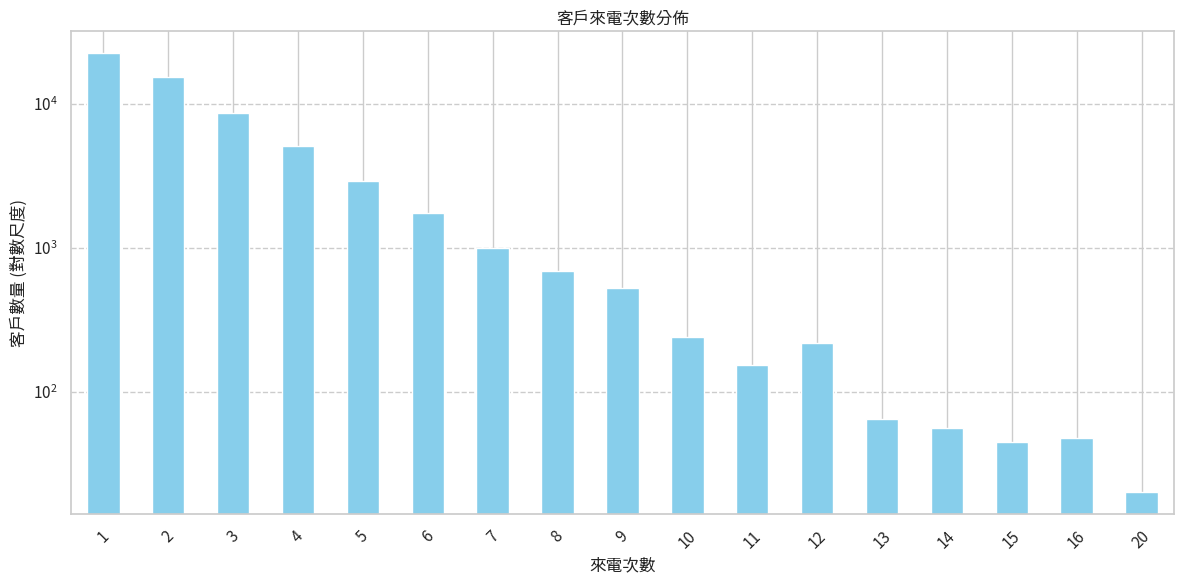

客戶來電次數分析完成。


In [516]:
# 步驟 3：客戶來電次數統計與分析

# 初始化將在此步驟中創建的 DataFrame
df = csr_LLM_sentiment.copy()  # 假設 ds_csr 是包含客戶資料的 DataFrame
call_counts = None
df_with_counts = None

if 'df' in locals() and df is not None and not df.empty:
    if 'CUST_NO' in df.columns:
        print("開始計算客戶來電次數...")
        
        # 1. 計算來電次數
        call_counts_series = df['CUST_NO'].value_counts()
        
        # 2. 建立來電次數資料框
        call_counts = call_counts_series.reset_index()
        call_counts.columns = ['CUST_NO', 'CALL_COUNT']
        
        print("--- 客戶來電次數 (call_counts) (前 5 筆) ---")
        try:
            display(call_counts.head())
        except NameError:
            print(call_counts.head().to_string())

        # 3. 合併回主資料框
        # 先複製一份 df，避免直接修改原始 df (如果後續還需要原始 df 的話)
        df_with_counts = df.copy()
        df_with_counts = pd.merge(df_with_counts, call_counts, on='CUST_NO', how='left')
        
        print("--- 資料框已加入來電次數 (df_with_counts) (前 5 筆) ---")
        try:
            # 顯示包含 CUST_NO 和 CALL_COUNT 的欄位，以及原始資料中的一些欄位以便核對
            display_cols = ['CUST_NO', 'CALL_COUNT'] + [col for col in df.columns if col not in ['CUST_NO', 'CALL_COUNT']][:2]
            display(df_with_counts[display_cols].head())
        except NameError:
            print(df_with_counts[display_cols].head().to_string())
        except KeyError as e:
            print(f"顯示 df_with_counts 時發生欄位錯誤: {e}. 可能原始 df 欄位不足。顯示 CUST_NO 和 CALL_COUNT:")
            try:
                display(df_with_counts[['CUST_NO', 'CALL_COUNT']].head())
            except NameError:
                print(df_with_counts[['CUST_NO', 'CALL_COUNT']].head().to_string())

        # 4. 顯示 CALL_COUNT 欄位的描述性統計
        print("--- 來電次數 (CALL_COUNT) 描述性統計 ---")
        try:
            display(df_with_counts['CALL_COUNT'].describe())
        except NameError:
            print(df_with_counts['CALL_COUNT'].describe().to_string())

        # 5. 視覺化來電次數分佈
        print("--- 視覺化客戶來電次數分佈 ---")
        plt.figure(figsize=(12, 6))
        
        # 為了更清晰的視覺化，如果來電次數種類過多，可以考慮對高次數進行分組或限制顯示範圍
        # 例如，只顯示來電次數 <= 10 的分佈
        # plot_data = df_with_counts['CALL_COUNT'][df_with_counts['CALL_COUNT'] <= 10]
        # sns.histplot(plot_data, discrete=True, shrink=0.8) # discrete for integer counts
        
        # 或者，使用 value_counts 繪製長條圖，更適合離散的計數
        call_count_distribution = df_with_counts['CALL_COUNT'].value_counts().sort_index()
        # 如果種類太多，只取前 N 個或一定範圍內的
        if len(call_count_distribution) > 20: # Example threshold
            call_count_distribution_plot = call_count_distribution[call_count_distribution.index <= 10] # Show up to 10 calls
            if call_count_distribution[call_count_distribution.index > 10].sum() > 0:
                 call_count_distribution_plot['>10'] = call_count_distribution[call_count_distribution.index > 10].sum()
        else:
            call_count_distribution_plot = call_count_distribution

        call_count_distribution_plot.plot(kind='bar', color='skyblue')
        plt.title('客戶來電次數分佈')
        plt.xlabel('來電次數')
        plt.ylabel('客戶數量 (對數尺度)' if call_count_distribution_plot.max() > 1000 else '客戶數量')
        plt.xticks(rotation=45)
        if call_count_distribution_plot.max() > 1000: # Apply log scale if counts are very high
            plt.yscale('log')
        plt.grid(axis='y', linestyle='--')
        plt.tight_layout()
        plt.savefig(os.path.join(output_main_dir, 'call_count_distribution.png')) # output_main_dir from Step 1
        plt.show()
        
        print("客戶來電次數分析完成。")

    else:
        print("錯誤: DataFrame 'df' 中缺少 'CUST_NO' 欄位，無法計算來電次數。")
else:
    print("錯誤: DataFrame 'df' 未定義、為空或在先前步驟中載入失敗。請先執行資料載入步驟。")



開始提取客戶主要問題分類 (大分類: ED_SERVCLASSNAME, 小分類: ED_SERVCLASS2NAME)...
計算客戶主要大分類...
計算客戶主要小分類...
--- 客戶主要問題分類 (customer_categories) (前 5 筆) ---


,CUST_NO,MAIN_CATEGORY,SUB_CATEGORY
0,4,經銷商問題,台哥大-人員進電
1,110,網路連線問題,無法上網
2,302,帳務問題,繳費相關問題
3,415,網路連線問題,無法上網
4,495,新產品,高頻寬


--- 主要問題大分類 (MAIN_CATEGORY) 分佈 ---


MAIN_CATEGORY
網路連線問題    20241
經銷商問題      8034
帳務相關       2817
帳務問題       1951
新產品        1844
非連線問題       396
註冊問題         69
搬家問題          7
E Mail        2
Name: count, dtype: int64

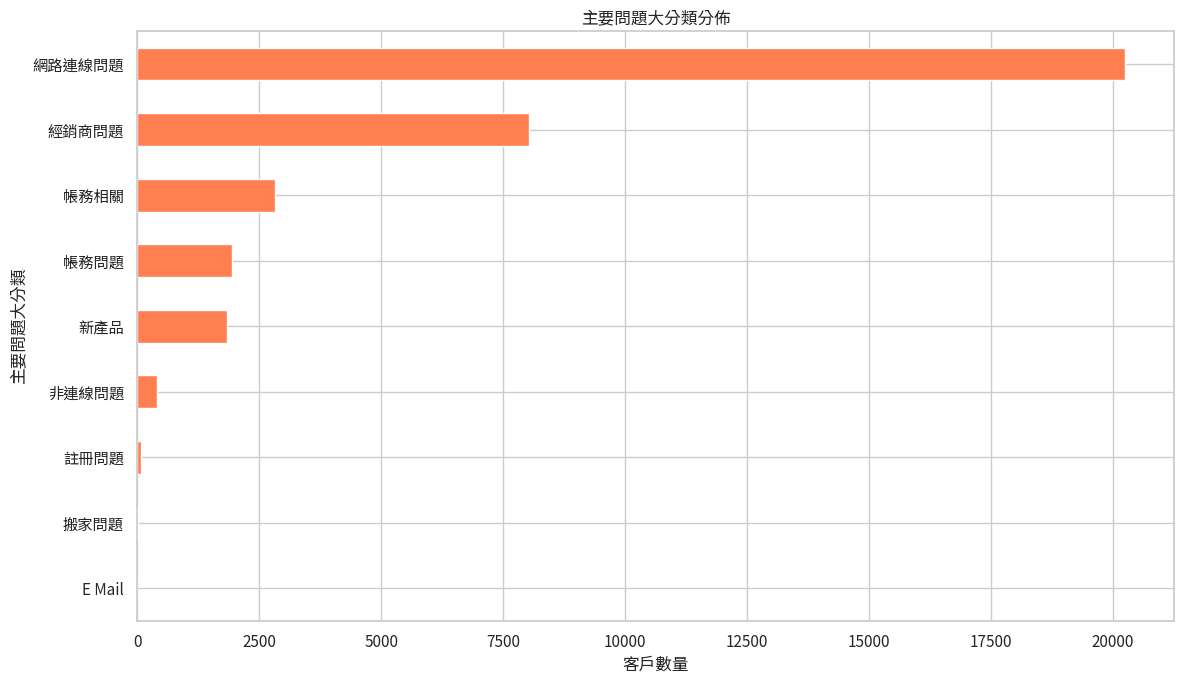

--- 主要問題小分類 (SUB_CATEGORY) 分佈 (Top 15) ---


SUB_CATEGORY
無法上網             13595
台哥大-電訪約裝          4358
Cable modem連線     3443
拆機挽回              2946
網路品質              2940
遠傳電信-電訪約裝         2310
高頻寬               1788
台哥大-人員進電           739
連線其他相關問題           548
繳費相關問題             458
頻寬方案費率             425
遠傳電信-人員進電          372
服務異動               235
固定Ip問題             217
用戶軟／硬體設備問題         127
Name: count, dtype: int64

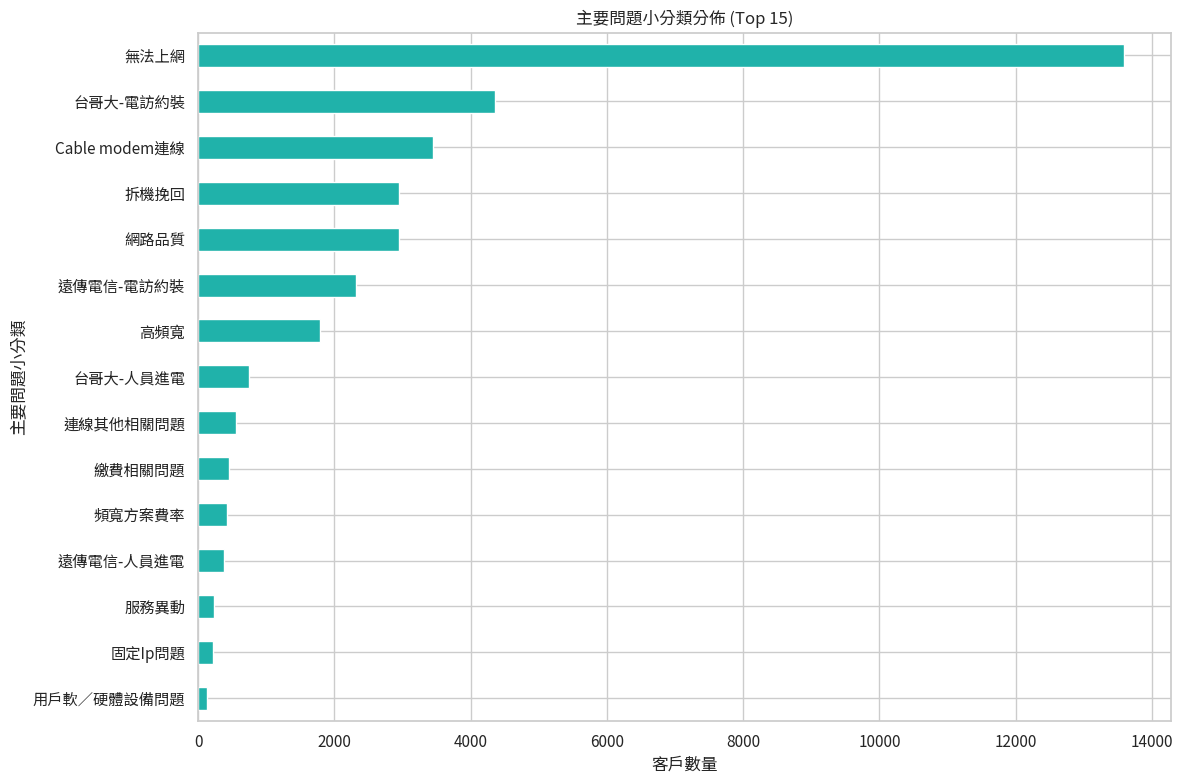

客戶主要問題類別提取完成。


In [517]:
# 步驟 4：主要問題類別提取與分析

# 初始化將在此步驟中創建的 DataFrame
customer_categories = None
# df_with_categories = None # This will be created in a later step when merging all features

if 'df_with_counts' in locals() and df_with_counts is not None and not df_with_counts.empty:
    # 1. 識別分類欄位
    main_category_col = 'ED_SERVCLASSNAME'
    sub_category_col = 'ED_SERVCLASS2NAME'

    if main_category_col in df_with_counts.columns and sub_category_col in df_with_counts.columns:
        print(f"開始提取客戶主要問題分類 (大分類: {main_category_col}, 小分類: {sub_category_col})...")
        
        # 處理分類欄位中的 NaN 值，替換為 '未知' 或其他標記
        df_categories_processed = df_with_counts.copy()
        df_categories_processed[main_category_col] = df_categories_processed[main_category_col].fillna('未知').astype(str)
        df_categories_processed[sub_category_col] = df_categories_processed[sub_category_col].fillna('未知').astype(str)

        # 2. 確定客戶主要分類 (使用 mode)
        # Group by CUST_NO and find the mode for main and sub categories
        # mode() can return multiple values if ties exist, so we take the first one ([0])
        # We need a robust way to handle cases where mode might be empty or cause issues.
        
        def get_mode_or_unknown(series):
            mode_val = series.mode()
            if not mode_val.empty:
                return mode_val[0]
            return '未知' # Fallback if mode is empty for some reason

        print("計算客戶主要大分類...")
        main_categories = df_categories_processed.groupby('CUST_NO')[main_category_col].apply(get_mode_or_unknown).reset_index()
        main_categories.columns = ['CUST_NO', 'MAIN_CATEGORY']

        print("計算客戶主要小分類...")
        sub_categories = df_categories_processed.groupby('CUST_NO')[sub_category_col].apply(get_mode_or_unknown).reset_index()
        sub_categories.columns = ['CUST_NO', 'SUB_CATEGORY']

        # 3. 建立客戶分類資料框
        customer_categories = pd.merge(main_categories, sub_categories, on='CUST_NO', how='outer')
        # Ensure CUST_NO type consistency if merging with other dataframes later
        if 'CUST_NO' in df_with_counts.columns:
             customer_categories['CUST_NO'] = customer_categories['CUST_NO'].astype(df_with_counts['CUST_NO'].dtype)

        print("--- 客戶主要問題分類 (customer_categories) (前 5 筆) ---")
        try:
            display(customer_categories.head())
        except NameError:
            print(customer_categories.head().to_string())

        # 4. 顯示結果與統計
        print("--- 主要問題大分類 (MAIN_CATEGORY) 分佈 ---")
        main_category_dist = customer_categories['MAIN_CATEGORY'].value_counts()
        try:
            display(main_category_dist)
        except NameError:
            print(main_category_dist.to_string())
        
        plt.figure(figsize=(12, 7))
        # Limit to top N categories if too many, for better visualization
        top_n_main = 15
        if len(main_category_dist) > top_n_main:
            main_category_dist.head(top_n_main).plot(kind='barh', color='coral')
            plt.title(f'主要問題大分類分佈 (Top {top_n_main})')
        else:
            main_category_dist.plot(kind='barh', color='coral')
            plt.title('主要問題大分類分佈')
        plt.xlabel('客戶數量')
        plt.ylabel('主要問題大分類')
        plt.gca().invert_yaxis() # To show the most frequent on top
        plt.tight_layout()
        plt.savefig(os.path.join(output_main_dir, 'main_category_distribution.png'))
        plt.show()

        print("--- 主要問題小分類 (SUB_CATEGORY) 分佈 (Top 15) ---")
        sub_category_dist = customer_categories['SUB_CATEGORY'].value_counts()
        try:
            display(sub_category_dist.head(15))
        except NameError:
            print(sub_category_dist.head(15).to_string())

        plt.figure(figsize=(12, 8))
        top_n_sub = 15
        sub_category_dist.head(top_n_sub).plot(kind='barh', color='lightseagreen')
        plt.title(f'主要問題小分類分佈 (Top {top_n_sub})')
        plt.xlabel('客戶數量')
        plt.ylabel('主要問題小分類')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.savefig(os.path.join(output_main_dir, 'sub_category_distribution.png'))
        plt.show()
        
        print("客戶主要問題類別提取完成。")

    else:
        missing_cols_cat = []
        if main_category_col not in df_with_counts.columns: missing_cols_cat.append(main_category_col)
        if sub_category_col not in df_with_counts.columns: missing_cols_cat.append(sub_category_col)
        print(f"錯誤: DataFrame 'df_with_counts' 中缺少必要的分類欄位: {', '.join(missing_cols_cat)}。無法提取問題類別。")
else:
    print("錯誤: DataFrame 'df_with_counts' 未定義、為空或在先前步驟中處理失敗。請先執行前面的步驟。")



開始進行客戶服務紀錄的離退語意分析...
服務紀錄離退傾向分數計算完成 (部分預覽):


,CUST_NO,CUST_RECORD_CLEAN,RECORD_SENTIMENT_SCORE
0,770352,1,0
1,1269168,5c925e4d3f41原註冊在客編:1116349&nbsp; 工程回報剔除要註冊在此客編.,0
2,1216090,"(系統紀錄),ISP出口為E-PON速博,ONU上線/WIFI不通 重啟無效 去電0921-...",-1
3,342132,遠傳拆機.2/19 16:02 電0900-000587 約2/20下午.已留紙條給mini組長,0
4,1192564,"(系統紀錄)用戶目前的cmts為10.0.1.47,ISP出口為台灣固網,去電0928-32...",0


客戶平均離退傾向分數 (customer_avg_sentiment) 計算完成 (前 5 筆):


,CUST_NO,AVG_SENTIMENT_SCORE
0,4,0.25
1,110,0.00
2,302,-1.00
3,415,0.50
4,495,0.00


--- 平均離退傾向分數 (AVG_SENTIMENT_SCORE) 描述性統計 ---


count    35361.000000
mean        -0.134047
std          0.496809
min         -5.000000
25%         -0.125000
50%          0.000000
75%          0.000000
max          6.000000
Name: AVG_SENTIMENT_SCORE, dtype: float64

--- 視覺化客戶平均離退傾向分數分佈 ---


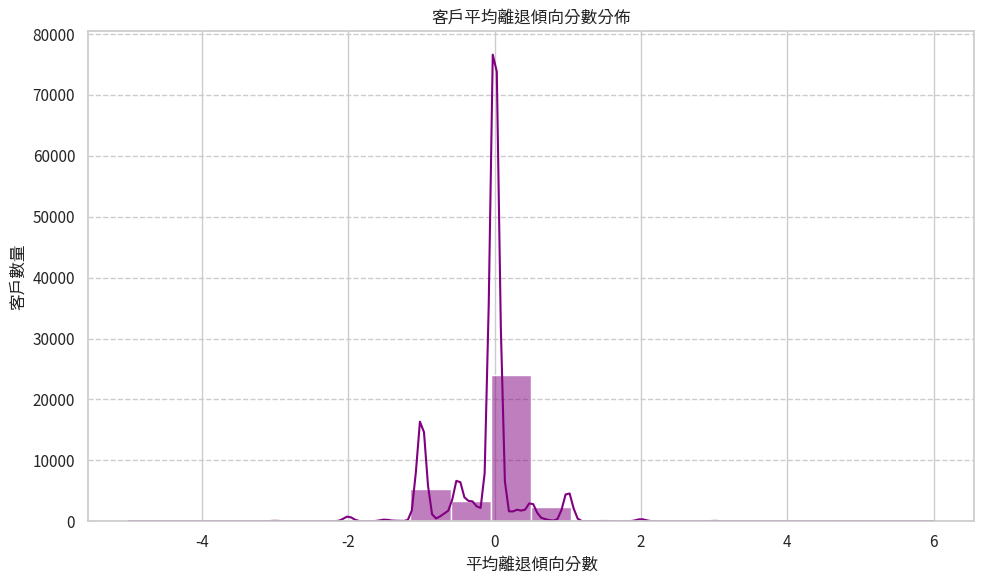

客戶服務紀錄的離退語意分析完成。


In [518]:
# 步驟 5：客戶服務紀錄的離退語意分析

# 初始化將在此步驟中創建的 DataFrame
customer_avg_sentiment = None
# df_with_sentiment will be created when merging this with previous step's result (customer_categories)

if 'df_with_counts' in locals() and df_with_counts is not None and not df_with_counts.empty:
    if 'CUST_NO' in df_with_counts.columns and 'CUST_RECORD' in df_with_counts.columns:
        print("開始進行客戶服務紀錄的離退語意分析...")

        # 1. 定義離退相關關鍵詞
        # 正面詞彙 (低離退風險, e.g., 滿意, 解決, 感謝, 續約)
        positive_churn_keywords = ['滿意', '解決', '感謝', '續約', '推薦', '穩定', '正常', '清楚', '明白', '願意', '好', '快', '順利', '沒問題', 'OK', 'ok', '搞定']
        # 負面詞彙 (高離退風險, e.g., 不滿, 解約, 抱怨, 問題, 斷線)
        negative_churn_keywords = ['不滿', '解約', '取消', '抱怨', '問題', '故障', '斷線', '龜速', '不穩', '困難', '複雜', '聽不懂', '考慮', '慢', '差', '爛', '不行', '無效', '火大', '生氣']

        # 2. 計算單筆紀錄離退傾向分數
        def get_churn_sentiment_score(text):
            if pd.isna(text) or not isinstance(text, str) or not text.strip():
                return 0  # 中性分數或無效文本
            
            score = 0
            try:
                # 確保 jieba 已經被匯入 (通常在筆記本開頭的設定儲存格中)
                # import jieba # 如果沒有在開頭導入，可以在這裡導入或確保它在作用域內
                words = jieba.lcut(str(text).lower())  # 分詞並轉小寫
                for word in words:
                    if word in positive_churn_keywords:
                        score += 1
                    elif word in negative_churn_keywords:
                        score -= 1
            except Exception as e:
                # print(f"Jieba分詞時發生錯誤: {e}，文本: {text[:50]}...") # 可選的錯誤日誌
                return 0  # 分詞錯誤也視為中性
            return score

        # 對每條服務紀錄計算離退傾向分數
        # 確保 CUST_RECORD 是字串類型，並處理 NaN
        df_sentiment_analysis = df_with_counts.copy() # Work on a copy
        df_sentiment_analysis['CUST_RECORD_CLEAN'] = df_sentiment_analysis['CUST_RECORD'].fillna('').astype(str)
        df_sentiment_analysis['RECORD_SENTIMENT_SCORE'] = df_sentiment_analysis['CUST_RECORD_CLEAN'].apply(get_churn_sentiment_score)

        print("服務紀錄離退傾向分數計算完成 (部分預覽):")
        try:
            display(df_sentiment_analysis[['CUST_NO', 'CUST_RECORD_CLEAN', 'RECORD_SENTIMENT_SCORE']].head())
        except NameError:
            print(df_sentiment_analysis[['CUST_NO', 'CUST_RECORD_CLEAN', 'RECORD_SENTIMENT_SCORE']].head().to_string())

        # 3. 計算每位客戶的平均離退傾向分數
        customer_avg_sentiment = df_sentiment_analysis.groupby('CUST_NO')['RECORD_SENTIMENT_SCORE'].mean().reset_index()
        customer_avg_sentiment.columns = ['CUST_NO', 'AVG_SENTIMENT_SCORE']
        
        # 確保 CUST_NO 型別一致性，以便後續合併
        if 'CUST_NO' in df_with_counts.columns:
            customer_avg_sentiment['CUST_NO'] = customer_avg_sentiment['CUST_NO'].astype(df_with_counts['CUST_NO'].dtype)

        print("客戶平均離退傾向分數 (customer_avg_sentiment) 計算完成 (前 5 筆):")
        try:
            display(customer_avg_sentiment.head())
        except NameError:
            print(customer_avg_sentiment.head().to_string())

        # 4. 顯示 AVG_SENTIMENT_SCORE 欄位的描述性統計
        print("--- 平均離退傾向分數 (AVG_SENTIMENT_SCORE) 描述性統計 ---")
        try:
            display(customer_avg_sentiment['AVG_SENTIMENT_SCORE'].describe())
        except NameError:
            print(customer_avg_sentiment['AVG_SENTIMENT_SCORE'].describe().to_string())

        # 5. 視覺化平均離退傾向分數分佈
        print("--- 視覺化客戶平均離退傾向分數分佈 ---")
        plt.figure(figsize=(10, 6))
        sns.histplot(customer_avg_sentiment['AVG_SENTIMENT_SCORE'], bins=20, kde=True, color='purple')
        plt.title('客戶平均離退傾向分數分佈')
        plt.xlabel('平均離退傾向分數')
        plt.ylabel('客戶數量')
        plt.grid(axis='y', linestyle='--')
        plt.tight_layout()
        plt.savefig(os.path.join(output_main_dir, 'avg_sentiment_score_distribution.png')) # output_main_dir from Step 1
        plt.show()
        
        print("客戶服務紀錄的離退語意分析完成。")

    else:
        missing_cols_sent = []
        if 'CUST_NO' not in df_with_counts.columns: missing_cols_sent.append('CUST_NO')
        if 'CUST_RECORD' not in df_with_counts.columns: missing_cols_sent.append('CUST_RECORD')
        print(f"錯誤: DataFrame 'df_with_counts' 中缺少必要的欄位: {', '.join(missing_cols_sent)}。無法進行離退語意分析。")
elif 'df' in locals() and df is not None and not df.empty:
    print("警告: 'df_with_counts' 未定義或為空，但 'df' 存在。可能是上一步驟未成功執行。請檢查。")
    print("將嘗試直接從 'df' 進行語意分析 (如果必要欄位存在)。")
    # Fallback to df if df_with_counts is not available but df is
    if 'CUST_NO' in df.columns and 'CUST_RECORD' in df.columns:
        # Repeat the logic from above using 'df' instead of 'df_with_counts'
        # This is a simplified fallback, ideally previous steps should be verified
        df_sentiment_analysis = df.copy()
        df_sentiment_analysis['CUST_RECORD_CLEAN'] = df_sentiment_analysis['CUST_RECORD'].fillna('').astype(str)
        df_sentiment_analysis['RECORD_SENTIMENT_SCORE'] = df_sentiment_analysis['CUST_RECORD_CLEAN'].apply(get_churn_sentiment_score)
        customer_avg_sentiment = df_sentiment_analysis.groupby('CUST_NO')['RECORD_SENTIMENT_SCORE'].mean().reset_index()
        customer_avg_sentiment.columns = ['CUST_NO', 'AVG_SENTIMENT_SCORE']
        customer_avg_sentiment['CUST_NO'] = customer_avg_sentiment['CUST_NO'].astype(df['CUST_NO'].dtype)
        print("已使用原始 'df' 完成離退語意分析 (部分功能)。建議檢查 'df_with_counts' 的生成。")
        try: display(customer_avg_sentiment.head()) 
        except: print(customer_avg_sentiment.head().to_string())
    else:
        print("錯誤: 原始 'df' 也缺少 'CUST_NO' 或 'CUST_RECORD'。無法進行語意分析。")
else:
    print("錯誤: DataFrame 'df_with_counts' (或 'df') 未定義、為空或在先前步驟中處理失敗。請先執行前面的步驟。")



In [519]:
# 步驟 6：整合特徵並建立最終客戶級別資料集

# 初始化將在此步驟中創建的 DataFrame
df_final_features = None

print("開始整合客戶級別特徵...")

# 確保所有必要的客戶級別 DataFrames (call_counts, customer_categories, customer_avg_sentiment)
# 以及原始的 df (用於獲取所有 CUST_NO) 都已在之前的步驟中成功創建且可用。

if 'df' in locals() and df is not None and not df.empty and 'CUST_NO' in df.columns:
    # 1. 建立一個包含所有不重複客戶編號的基礎 DataFrame
    unique_customers = pd.DataFrame(df['CUST_NO'].unique(), columns=['CUST_NO'])
    print(f"找到 {len(unique_customers)} 位不重複的客戶作為基礎。")
    
    df_final_features = unique_customers.copy()
    # Ensure CUST_NO in df_final_features has a consistent type, preferably from original df
    df_final_features['CUST_NO'] = df_final_features['CUST_NO'].astype(df['CUST_NO'].dtype)

    # 2. 合併來電次數 (來自步驟 3 的 call_counts)
    if 'call_counts' in locals() and call_counts is not None and not call_counts.empty and 'CUST_NO' in call_counts.columns:
        # Ensure CUST_NO type consistency before merging
        call_counts_to_merge = call_counts.astype({'CUST_NO': df_final_features['CUST_NO'].dtype})
        df_final_features = pd.merge(df_final_features, call_counts_to_merge[['CUST_NO', 'CALL_COUNT']], on='CUST_NO', how='left')
        print("已合併客戶來電次數。")
    else:
        print("警告: 'call_counts' DataFrame 未定義、為空或缺少 CUST_NO。CALL_COUNT 將填充 NaN。")
        df_final_features['CALL_COUNT'] = np.nan # Add column if merge fails

    # 3. 合併問題分類 (來自步驟 4 的 customer_categories)
    if 'customer_categories' in locals() and customer_categories is not None and not customer_categories.empty and 'CUST_NO' in customer_categories.columns:
        customer_categories_to_merge = customer_categories.astype({'CUST_NO': df_final_features['CUST_NO'].dtype})
        df_final_features = pd.merge(df_final_features, customer_categories_to_merge[['CUST_NO', 'MAIN_CATEGORY', 'SUB_CATEGORY']], on='CUST_NO', how='left')
        print("已合併客戶主要問題分類。")
    else:
        print("警告: 'customer_categories' DataFrame 未定義、為空或缺少 CUST_NO。MAIN_CATEGORY 和 SUB_CATEGORY 將填充 NaN/NA。")
        df_final_features['MAIN_CATEGORY'] = pd.NA
        df_final_features['SUB_CATEGORY'] = pd.NA

    # 4. 合併平均離退語意分數 (來自步驟 5 的 customer_avg_sentiment)
    if 'customer_avg_sentiment' in locals() and customer_avg_sentiment is not None and not customer_avg_sentiment.empty and 'CUST_NO' in customer_avg_sentiment.columns:
        customer_avg_sentiment_to_merge = customer_avg_sentiment.astype({'CUST_NO': df_final_features['CUST_NO'].dtype})
        df_final_features = pd.merge(df_final_features, customer_avg_sentiment_to_merge[['CUST_NO', 'AVG_SENTIMENT_SCORE']], on='CUST_NO', how='left')
        print("已合併客戶平均離退語意分數。")
    else:
        print("警告: 'customer_avg_sentiment' DataFrame 未定義、為空或缺少 CUST_NO。AVG_SENTIMENT_SCORE 將填充 NaN。")
        df_final_features['AVG_SENTIMENT_SCORE'] = np.nan
            
    # 5. 處理合併過程中可能產生的缺失值
    # CALL_COUNT: 客戶至少有1次紀錄(來自df)，所以理論上call_counts合併後不應有NaN，但以防萬一
    if 'CALL_COUNT' in df_final_features.columns:
        df_final_features['CALL_COUNT'] = df_final_features['CALL_COUNT'].fillna(0).astype(int)
    else: # Should not happen if merge was attempted
        df_final_features['CALL_COUNT'] = 0 
        
    if 'MAIN_CATEGORY' in df_final_features.columns:
        df_final_features['MAIN_CATEGORY'] = df_final_features['MAIN_CATEGORY'].fillna('未知').astype(str)
    else:
        df_final_features['MAIN_CATEGORY'] = '未知'
        
    if 'SUB_CATEGORY' in df_final_features.columns:
        df_final_features['SUB_CATEGORY'] = df_final_features['SUB_CATEGORY'].fillna('未知').astype(str)
    else:
        df_final_features['SUB_CATEGORY'] = '未知'
        
    if 'AVG_SENTIMENT_SCORE' in df_final_features.columns:
        df_final_features['AVG_SENTIMENT_SCORE'] = df_final_features['AVG_SENTIMENT_SCORE'].fillna(0.0).astype(float)
    else:
        df_final_features['AVG_SENTIMENT_SCORE'] = 0.0

    print("最終客戶級別特徵資料集 (df_final_features) 建立完成。")
    
    # 6. 顯示最終結果
    print("--- 最終特徵資料集 (df_final_features) 預覽 (前 10 筆) ---")
    try:
        display(df_final_features.head(10))
    except NameError:
        print(df_final_features.head(10).to_string())
    
    print("--- 最終特徵資料集資訊 ---")
    df_final_features.info()
    
    print("--- 最終特徵資料集各欄位缺失值檢查 ---")
    print(df_final_features.isnull().sum())

else:
    print("錯誤: 原始 DataFrame 'df' 未定義、為空或缺少 'CUST_NO' 欄位。無法建立最終特徵資料集。")
    print("請確保資料載入步驟 (步驟 2) 已成功執行。")



開始整合客戶級別特徵...
找到 35361 位不重複的客戶作為基礎。
已合併客戶來電次數。
已合併客戶主要問題分類。
已合併客戶平均離退語意分數。
最終客戶級別特徵資料集 (df_final_features) 建立完成。
--- 最終特徵資料集 (df_final_features) 預覽 (前 10 筆) ---


,CUST_NO,CALL_COUNT,MAIN_CATEGORY,SUB_CATEGORY,AVG_SENTIMENT_SCORE
0,770352,1,非連線問題,用戶服務抱怨,0.000000
1,1269168,1,非連線問題,用戶軟／硬體設備問題,0.000000
2,1216090,1,網路連線問題,無法上網,-1.000000
3,342132,1,經銷商問題,遠傳電信-電訪約裝,0.000000
4,1192564,3,網路連線問題,無法上網,-0.333333
5,312558,1,網路連線問題,無法上網,0.000000
6,717163,4,網路連線問題,無法上網,-0.750000
7,1216408,2,網路連線問題,網路品質,1.000000
8,1148707,1,帳務相關,拆機挽回,0.000000
9,1228870,1,帳務相關,拆機挽回,0.000000


--- 最終特徵資料集資訊 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35361 entries, 0 to 35360
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CUST_NO              35361 non-null  int64  
 1   CALL_COUNT           35361 non-null  int64  
 2   MAIN_CATEGORY        35361 non-null  object 
 3   SUB_CATEGORY         35361 non-null  object 
 4   AVG_SENTIMENT_SCORE  35361 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 1.3+ MB
--- 最終特徵資料集各欄位缺失值檢查 ---
CUST_NO                0
CALL_COUNT             0
MAIN_CATEGORY          0
SUB_CATEGORY           0
AVG_SENTIMENT_SCORE    0
dtype: int64


In [520]:
# 新增時間頻繁度分析函數
def analyze_call_frequency_patterns(df):
    """
    分析客戶來電的時間模式特徵
    """

    # 轉換時間欄位
    df['CALL_TIME'] = pd.to_datetime(df['CALL_TIME'], errors='coerce')
    df['年月'] = df['CALL_TIME'].dt.to_period('M')
    df['季度'] = df['CALL_TIME'].dt.to_period('Q')
    df['週數'] = df['CALL_TIME'].dt.isocalendar().week
    
    frequency_features = []
    
    for cust_no in df['CUST_NO'].unique():
        cust_data = df[df['CUST_NO'] == cust_no].copy()
        
        # 1. 月度來電頻率特徵
        monthly_calls = cust_data.groupby('年月').size()
        
        # 2. 季度來電頻率特徵  
        quarterly_calls = cust_data.groupby('季度').size()
        
        # 3. 計算時間間隔特徵
        if len(cust_data) > 1:
            time_diffs = cust_data['CALL_TIME'].diff().dt.days.dropna()
            avg_interval = time_diffs.mean()
            std_interval = time_diffs.std()
            min_interval = time_diffs.min()
        else:
            avg_interval = std_interval = min_interval = None
            
        features = {
            'CUST_NO': cust_no,
            'TOTAL_CALLS': len(cust_data),
            'ACTIVE_MONTHS': len(monthly_calls),  # 活躍月份數
            'ACTIVE_QUARTERS': len(quarterly_calls),  # 活躍季度數
            'AVG_MONTHLY_CALLS': monthly_calls.mean(),  # 平均月來電數
            'MAX_MONTHLY_CALLS': monthly_calls.max(),   # 最大月來電數
            'STD_MONTHLY_CALLS': monthly_calls.std(),   # 月來電數標準差
            'AVG_CALL_INTERVAL_DAYS': avg_interval,     # 平均來電間隔天數
            'STD_CALL_INTERVAL_DAYS': std_interval,     # 來電間隔標準差
            'MIN_CALL_INTERVAL_DAYS': min_interval,     # 最短來電間隔
            'CALL_CONCENTRATION': monthly_calls.max() / len(cust_data) if len(cust_data) > 0 else 0,  # 來電集中度
            'RECENT_3M_CALLS': len(cust_data[cust_data['CALL_TIME'] >= cust_data['CALL_TIME'].max() - pd.DateOffset(months=3)]),  # 近3個月來電數
            'ESCALATION_TREND': 1 if len(quarterly_calls) > 1 and quarterly_calls.iloc[-1] > quarterly_calls.iloc[0] else 0  # 來電趨勢是否上升
        }
        
        frequency_features.append(features)
    
    return pd.DataFrame(frequency_features)

In [521]:
def analyze_problem_diversity(df):
    """
    分析客戶問題的多樣性和演變模式
    """
    diversity_features = []
    
    for cust_no in df['CUST_NO'].unique():
        cust_data = df[df['CUST_NO'] == cust_no].copy()
        
        # 1. 問題分類多樣性
        main_categories = cust_data['ED_SERVCLASSNAME'].fillna('未知')
        sub_categories = cust_data['ED_SERVCLASS2NAME'].fillna('未知')
        
        # 2. 分類統計
        main_cat_counts = main_categories.value_counts()
        sub_cat_counts = sub_categories.value_counts()
        
        # 3. 計算多樣性指標
        main_cat_diversity = len(main_cat_counts)  # 主分類種類數
        sub_cat_diversity = len(sub_cat_counts)    # 次分類種類數
        
        # 4. 計算香農熵 (Shannon Entropy) - 衡量問題多樣性
        def calculate_entropy(counts):
            probs = counts / counts.sum()
            return -sum(probs * np.log2(probs + 1e-10))
        
        main_entropy = calculate_entropy(main_cat_counts)
        sub_entropy = calculate_entropy(sub_cat_counts)
        
        # 5. 問題複雜度 (同時出現多種問題類別)
        complexity_score = main_cat_diversity * sub_cat_diversity / len(cust_data)
        
        # 6. 主要問題佔比
        main_problem_ratio = main_cat_counts.iloc[0] / len(cust_data) if len(main_cat_counts) > 0 else 0
        
        # 7. 問題演變趨勢 (是否從簡單問題變複雜)
        if len(cust_data) > 1:
            cust_data_sorted = cust_data.sort_values('CALL_TIME')
            first_half = cust_data_sorted.iloc[:len(cust_data_sorted)//2]
            second_half = cust_data_sorted.iloc[len(cust_data_sorted)//2:]
            
            first_diversity = len(first_half['ED_SERVCLASSNAME'].unique())
            second_diversity = len(second_half['ED_SERVCLASSNAME'].unique())
            problem_evolution = second_diversity - first_diversity
        else:
            problem_evolution = 0
            
        # 8. 具體問題分類one-hot編碼 (取前5大類別)
        top_main_cats = main_categories.value_counts().head(5).index.tolist()
        top_sub_cats = sub_categories.value_counts().head(10).index.tolist()
        
        features = {
            'CUST_NO': cust_no,
            'MAIN_CATEGORY_DIVERSITY': main_cat_diversity,
            'SUB_CATEGORY_DIVERSITY': sub_cat_diversity,
            'MAIN_CATEGORY_ENTROPY': main_entropy,
            'SUB_CATEGORY_ENTROPY': sub_entropy,
            'PROBLEM_COMPLEXITY_SCORE': complexity_score,
            'MAIN_PROBLEM_RATIO': main_problem_ratio,
            'PROBLEM_EVOLUTION_TREND': problem_evolution,
            'IS_SINGLE_ISSUE_CUSTOMER': 1 if main_cat_diversity == 1 else 0,
            'IS_MULTI_ISSUE_CUSTOMER': 1 if main_cat_diversity >= 3 else 0
        }
        
        # 新增主要分類的詳細統計
        for cat in top_main_cats:
            features[f'MAIN_CAT_{cat}_COUNT'] = main_cat_counts.get(cat, 0)
            features[f'MAIN_CAT_{cat}_RATIO'] = main_cat_counts.get(cat, 0) / len(cust_data)
            
        # 新增次要分類的詳細統計
        for cat in top_sub_cats:
            features[f'SUB_CAT_{cat}_COUNT'] = sub_cat_counts.get(cat, 0)
            features[f'SUB_CAT_{cat}_RATIO'] = sub_cat_counts.get(cat, 0) / len(cust_data)
        
        diversity_features.append(features)
    
    return pd.DataFrame(diversity_features)

In [522]:
def analyze_problem_evolution_timeline(df):
    """
    分析客戶問題隨時間的演變模式
    """
    df['CALL_TIME'] = pd.to_datetime(df['CALL_TIME'])
    evolution_features = []
    
    for cust_no in df['CUST_NO'].unique():
        cust_data = df[df['CUST_NO'] == cust_no].copy().sort_values('CALL_TIME')
        
        if len(cust_data) < 2:
            continue
            
        # 1. 問題升級模式 (從簡單到複雜)
        problem_severity_map = {
            '諮詢': 1, '一般故障': 2, '網路問題': 3, 
            '帳務問題': 2, '投訴': 4, '解約': 5
        }
        
        # 根據實際分類調整映射
        cust_data['SEVERITY_SCORE'] = cust_data['ED_SERVCLASSNAME'].map(
            lambda x: problem_severity_map.get(x, 2)
        )
        
        # 2. 計算趨勢
        severity_trend = cust_data['SEVERITY_SCORE'].diff().mean()
        
        # 3. 問題反覆性 (是否重複出現相同問題)
        problem_sequences = cust_data['ED_SERVCLASSNAME'].tolist()
        recurring_issues = len(problem_sequences) - len(set(problem_sequences))
        
        # 4. 解決效果 (問題間隔時間是否延長)
        time_intervals = cust_data['CALL_TIME'].diff().dt.days.dropna()
        interval_trend = time_intervals.diff().mean() if len(time_intervals) > 1 else 0
        
        # 5. 最近問題嚴重程度
        recent_severity = cust_data['SEVERITY_SCORE'].iloc[-3:].mean()
        
        features = {
            'CUST_NO': cust_no,
            'PROBLEM_SEVERITY_TREND': severity_trend,
            'RECURRING_ISSUES_COUNT': recurring_issues,
            'INTERVAL_TREND': interval_trend,  # 正值表示問題間隔延長(好現象)
            'RECENT_SEVERITY_AVG': recent_severity,
            'ESCALATION_RISK': 1 if severity_trend > 0.5 and recent_severity >= 3 else 0,
            'RESOLUTION_EFFECTIVENESS': 1 if interval_trend > 0 and severity_trend <= 0 else 0
        }
        
        evolution_features.append(features)
    
    return pd.DataFrame(evolution_features)

In [523]:
def calculate_sentiment_features(df):
    """
    計算客戶服務紀錄的語意分析特徵
    """
    if 'CUST_RECORD' not in df.columns:
        # Return empty DataFrame with just CUST_NO if no records
        return pd.DataFrame({'CUST_NO': df['CUST_NO'].unique(), 'AVG_SENTIMENT_SCORE': 0})
    
    # 1. 定義離退相關關鍵詞
    positive_churn_keywords = ['滿意', '解決', '感謝', '續約', '推薦', '穩定', '正常', '清楚', '明白', '願意', '好', '快', '順利', '沒問題', 'OK', 'ok', '搞定']
    negative_churn_keywords = ['不滿', '解約', '取消', '抱怨', '問題', '故障', '斷線', '龜速', '不穩', '困難', '複雜', '聽不懂', '考慮', '慢', '差', '爛', '不行', '無效', '火大', '生氣']
    
    # 2. 計算單筆紀錄離退傾向分數
    def get_churn_sentiment_score(text):
        if pd.isna(text) or not isinstance(text, str) or not text.strip():
            return 0
        
        score = 0
        try:
            words = jieba.lcut(str(text).lower())
            for word in words:
                if word in positive_churn_keywords:
                    score += 1
                elif word in negative_churn_keywords:
                    score -= 1
        except Exception as e:
            return 0
        return score
    
    # 3. 計算每條記錄的情感分數
    df_sentiment = df.copy()
    df_sentiment['CUST_RECORD_CLEAN'] = df_sentiment['CUST_RECORD'].fillna('').astype(str)
    df_sentiment['RECORD_SENTIMENT_SCORE'] = df_sentiment['CUST_RECORD_CLEAN'].apply(get_churn_sentiment_score)
    
    # 4. 按客戶聚合情感特徵
    sentiment_features = df_sentiment.groupby('CUST_NO').agg({
        'RECORD_SENTIMENT_SCORE': ['mean', 'sum', 'std', 'min', 'max']
    }).reset_index()
    
    # 5. 重命名列
    sentiment_features.columns = [
        'CUST_NO', 'AVG_SENTIMENT_SCORE', 'TOTAL_SENTIMENT_SCORE', 
        'STD_SENTIMENT_SCORE', 'MIN_SENTIMENT_SCORE', 'MAX_SENTIMENT_SCORE'
    ]
    
    # 6. 填充缺失值
    sentiment_features = sentiment_features.fillna(0)
    
    return sentiment_features

In [524]:
def process_csr_sentiment_duplicates(csr_sentiment_df, model_name_prefix="csr_sentiment"):
    """
    處理 CSR 情感分析資料中重複的 CUST_NO，計算平均分數並確保唯一性
    
    Parameters:
    csr_sentiment_df: 包含客戶情感分析結果的 DataFrame
    model_name_prefix: 輸出檔案的前綴名稱
    
    Returns:
    dict: 包含處理結果和統計資訊的字典
    """
    
    if csr_sentiment_df is None or csr_sentiment_df.empty:
        print("❌ 輸入的情感分析資料為空或未定義")
        return {"success": False, "error": "Empty or None input data"}
    
    print("=== 處理 CSR 情感分析資料中的重複客戶並計算平均分數 ===")
    
    # 1. 檢查原始資料情況
    original_count = len(csr_sentiment_df)
    unique_customers = csr_sentiment_df['CUST_NO'].nunique()
    
    print(f"原始資料筆數: {original_count:,}")
    print(f"唯一客戶數: {unique_customers:,}")
    
    # 2. 識別score相關欄位
    print("\n=== 可用欄位 ===")
    print(csr_sentiment_df.columns.tolist())
    
    # 自動識別可能的score欄位
    score_columns = [col for col in csr_sentiment_df.columns 
                    if 'score' in col.lower() or 'sentiment' in col.lower()]
    print(f"\n發現的分數相關欄位: {score_columns}")
    
    if not score_columns:
        print("❌ 未找到score相關欄位，請檢查欄位名稱")
        return {
            "success": False,
            "error": "No score-related columns found",
            "available_columns": csr_sentiment_df.columns.tolist()
        }
    
    # 3. 計算每個客戶的平均分數
    print(f"\n開始處理重複客戶，計算平均分數...")
    
    # 建立聚合字典
    agg_dict = {}
    
    # 為每個score欄位設定平均值計算
    numeric_score_cols = []
    for col in score_columns:
        if csr_sentiment_df[col].dtype in ['int64', 'float64']:
            agg_dict[col] = 'mean'
            numeric_score_cols.append(col)
    
    # 保留其他可能有用的欄位（取第一個值）
    other_columns = [col for col in csr_sentiment_df.columns 
                    if col not in ['CUST_NO'] + score_columns]
    
    for col in other_columns:
        agg_dict[col] = 'first'  # 對於非數值欄位，取第一個值
    
    # 4. 按CUST_NO分組並聚合
    try:
        csr_sentiment_unique = csr_sentiment_df.groupby('CUST_NO').agg(agg_dict).reset_index()
    except Exception as e:
        print(f"❌ 聚合處理失敗: {e}")
        return {"success": False, "error": f"Aggregation failed: {e}"}
    
    # 5. 重新命名平均分數欄位（加上AVG_前綴）
    rename_dict = {}
    for col in numeric_score_cols:
        new_name = f"AVG_{col}" if not col.startswith('AVG_') else col
        rename_dict[col] = new_name
    
    if rename_dict:
        csr_sentiment_unique = csr_sentiment_unique.rename(columns=rename_dict)
    
    # 6. 顯示處理結果
    processed_count = len(csr_sentiment_unique)
    unique_customers_after = csr_sentiment_unique['CUST_NO'].nunique()
    
    print(f"\n=== 處理結果 ===")
    print(f"處理後資料筆數: {processed_count:,}")
    print(f"唯一客戶數: {unique_customers_after:,}")
    print(f"是否已確保CUST_NO唯一性: {processed_count == unique_customers_after}")
    
    # 7. 顯示前幾筆處理後的資料
    print(f"\n=== 處理後資料預覽 ===")
    display(csr_sentiment_unique.head())
    
    # 8. 比較處理前後的統計
    print(f"\n=== 處理前後對比 ===")
    comparison_stats = {}
    
    for original_col, new_col in rename_dict.items():
        if original_col in csr_sentiment_df.columns and new_col in csr_sentiment_unique.columns:
            original_stats = csr_sentiment_df[original_col].describe()
            new_stats = csr_sentiment_unique[new_col].describe()
            
            print(f"\n{original_col} -> {new_col}:")
            print(f"  原始平均值: {original_stats['mean']:.4f}")
            print(f"  處理後平均值: {new_stats['mean']:.4f}")
            print(f"  原始標準差: {original_stats['std']:.4f}")
            print(f"  處理後標準差: {new_stats['std']:.4f}")
            
            comparison_stats[original_col] = {
                'original_mean': original_stats['mean'],
                'processed_mean': new_stats['mean'],
                'original_std': original_stats['std'],
                'processed_std': new_stats['std']
            }
    
    # 9. 檢查是否有重複的客戶（應該沒有）
    duplicate_check = csr_sentiment_unique['CUST_NO'].value_counts()
    duplicates = duplicate_check[duplicate_check > 1]
    
    if len(duplicates) > 0:
        print(f"\n❌ 警告：仍有 {len(duplicates)} 個重複的客戶")
        print(duplicates.head())
    else:
        print(f"\n✅ 確認：所有客戶都是唯一的")
    
    # 10. 保存處理後的資料
    output_path = f'{model_name_prefix}_unique.csv'
    try:
        csr_sentiment_unique.to_csv(output_path, index=False, encoding='utf-8-sig')
        print(f"\n處理後的唯一客戶資料已保存至: {output_path}")
    except Exception as e:
        print(f"\n⚠️ 檔案保存失敗: {e}")
        output_path = None
    
    # 11. 準備返回結果
    result = {
        "success": True,
        "processed_data": csr_sentiment_unique,
        "statistics": {
            "original_count": original_count,
            "processed_count": processed_count,
            "unique_customers_original": unique_customers,
            "unique_customers_processed": unique_customers_after,
            "duplicates_removed": original_count - processed_count,
            "removal_rate": (original_count - processed_count) / original_count * 100,
            "score_columns_processed": list(rename_dict.keys()),
            "renamed_columns": rename_dict,
            "comparison_stats": comparison_stats
        },
        "output_file": output_path,
        "has_duplicates": len(duplicates) > 0
    }
    
    return csr_sentiment_unique, result

In [525]:
# 修改步驟 6：整合所有新特徵
def create_enhanced_customer_features(df):
    """
    建立增強版客戶特徵資料集
    """
    print("開始建立增強版客戶特徵...")

    # 依 CUST_NO、CCALL_TIME 遞增排序
    df = df.sort_values(
        by=['CUST_NO', 'CALL_TIME'], ascending=[True, True]
    ).reset_index(drop=True)
    
    # 1. 原有的基礎特徵
    call_counts = df['CUST_NO'].value_counts().reset_index()
    call_counts.columns = ['CUST_NO', 'TOTAL_CALLS']
    
    # 2. 新增時間頻繁度特徵
    frequency_features = analyze_call_frequency_patterns(df)
    
    # 3. 新增問題多樣性特徵
    diversity_features = analyze_problem_diversity(df)
    
    # 4. 新增問題演變特徵
    evolution_features = analyze_problem_evolution_timeline(df)
    
    # 5. 原有的語意分析 (保持不變)
    sentiment_features = calculate_sentiment_features(df)  # 你原有的函數
    LLM_sentiment_features, _ =   process_csr_sentiment_duplicates(df)
    
    # 6. 合併所有特徵
    enhanced_features = call_counts.copy()
    
    # 逐步合併各種特徵
    enhanced_features = pd.merge(enhanced_features, frequency_features, on='CUST_NO', how='left')
    enhanced_features = pd.merge(enhanced_features, diversity_features, on='CUST_NO', how='left')
    enhanced_features = pd.merge(enhanced_features, evolution_features, on='CUST_NO', how='left')
    enhanced_features = pd.merge(enhanced_features, sentiment_features, on='CUST_NO', how='left')
    enhanced_features = pd.merge(enhanced_features, LLM_sentiment_features, on='CUST_NO', how='left')
    
    # 7. 填充缺失值
    enhanced_features = enhanced_features.fillna(0)
    
    return enhanced_features

In [526]:
print("Available columns in df:")
print(csr_LLM_sentiment.columns.tolist())
print("\nDataFrame shape:", csr_LLM_sentiment.shape)
print("\nFirst few rows:")
print(csr_LLM_sentiment.head())

Available columns in df:
['CUST_NO', 'ED_SERVCLASSNAME', 'ED_SERVCLASS2NAME', 'CUST_RECORD_DATE', 'CUST_RECORD', 'SYS_NAME', 'score', 'explanation']

DataFrame shape: (58957, 8)

First few rows:
   CUST_NO ED_SERVCLASSNAME ED_SERVCLASS2NAME      CUST_RECORD_DATE  \
0   770352            非連線問題            用戶服務抱怨  2025/2/19 下午 2:56:00   
1  1269168            非連線問題        用戶軟／硬體設備問題  2025/2/19 下午 3:02:00   
2  1216090           網路連線問題              無法上網  2025/2/19 下午 4:02:00   
3   342132            經銷商問題         遠傳電信-電訪約裝  2025/2/19 下午 4:10:00   
4  1192564           網路連線問題              網路品質  2025/2/19 下午 4:15:00   

                                         CUST_RECORD SYS_NAME  score  \
0                                                 1        北港    NaN   
1    5c925e4d3f41原註冊在客編:1116349&nbsp; 工程回報剔除要註冊在此客編.       佳聯   -0.6   
2  (系統紀錄),ISP出口為E-PON速博,ONU上線/WIFI不通 重啟無效 去電0921-...       佳聯   -0.6   
3   遠傳拆機.2/19 16:02 電0900-000587 約2/20下午.已留紙條給mini組長       北港   -0.3   
4  (系統紀錄)用戶目前的cmts

In [527]:
# Option A: Rename existing time column
df = csr_LLM_sentiment.rename(columns={'CUST_RECORD_DATE': 'CALL_TIME'})

In [528]:
def parse_chinese_datetime(date_str):
    """
    解析包含中文的日期時間字符串
    """
    if pd.isna(date_str):
        return pd.NaT
    
    try:
        # Convert Chinese AM/PM to English
        date_str = str(date_str).strip()
        date_str = date_str.replace('上午', 'AM').replace('下午', 'PM')
        
        # Parse the datetime
        return pd.to_datetime(date_str, format='%Y/%m/%d %p %I:%M:%S')
    except:
        # If parsing fails, try other common formats
        try:
            return pd.to_datetime(date_str, infer_datetime_format=True)
        except:
            return pd.NaT

# Apply the custom parser to your time column
# df['CALL_TIME'] = df['CALL_TIME'].apply(parse_chinese_datetime)

# Quick fix: Parse Chinese datetime before calling the function
def fix_chinese_datetime(df):
    """
    修正包含中文的日期時間格式
    """
    if 'CALL_TIME' in df.columns:
        def parse_chinese_datetime(date_str):
            if pd.isna(date_str):
                return pd.NaT
            try:
                date_str = str(date_str).strip()
                date_str = date_str.replace('上午', 'AM').replace('下午', 'PM')
                return pd.to_datetime(date_str, format='%Y/%m/%d %p %I:%M:%S')
            except:
                try:
                    return pd.to_datetime(date_str, infer_datetime_format=True)
                except:
                    return pd.NaT
        
        df['CALL_TIME'] = df['CALL_TIME'].apply(parse_chinese_datetime)
    
    return df

# Apply the fix
df = fix_chinese_datetime(df)

C:\Users\user\AppData\Local\Temp\ipykernel_16680\3698905813.py:40: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  return pd.to_datetime(date_str, infer_datetime_format=True)


In [529]:
df.head()

,CUST_NO,ED_SERVCLASSNAME,ED_SERVCLASS2NAME,CALL_TIME,CUST_RECORD,SYS_NAME,score,explanation
0,770352,非連線問題,用戶服務抱怨,2025-02-19 14:56:00,1,北港,NaN,The input provided is simply the number '1' wi...
1,1269168,非連線問題,用戶軟／硬體設備問題,2025-02-19 15:02:00,5c925e4d3f41原註冊在客編:1116349&nbsp; 工程回報剔除要註冊在此客編.,佳聯,-0.6,The input text mentions the original registrat...
2,1216090,網路連線問題,無法上網,2025-02-19 16:02:00,"(系統紀錄),ISP出口為E-PON速博,ONU上線/WIFI不通 重啟無效 去電0921-...",佳聯,-0.6,The input text describes a technical issue whe...
3,342132,經銷商問題,遠傳電信-電訪約裝,2025-02-19 16:10:00,遠傳拆機.2/19 16:02 電0900-000587 約2/20下午.已留紙條給mini組長,北港,-0.3,The input text indicates a customer's request ...
4,1192564,網路連線問題,網路品質,2025-02-19 16:15:00,"(系統紀錄)用戶目前的cmts為10.0.1.47,ISP出口為台灣固網,去電0928-32...",台灣佳光,-0.6,The input text describes a customer complaint ...


In [530]:
df_final_features = create_enhanced_customer_features(df)

開始建立增強版客戶特徵...
=== 處理 CSR 情感分析資料中的重複客戶並計算平均分數 ===
原始資料筆數: 58,957
唯一客戶數: 35,361

=== 可用欄位 ===
['CUST_NO', 'ED_SERVCLASSNAME', 'ED_SERVCLASS2NAME', 'CALL_TIME', 'CUST_RECORD', 'SYS_NAME', 'score', 'explanation', '年月', '季度', '週數']

發現的分數相關欄位: ['score']

開始處理重複客戶，計算平均分數...

=== 處理結果 ===
處理後資料筆數: 35,361
唯一客戶數: 35,361
是否已確保CUST_NO唯一性: True

=== 處理後資料預覽 ===


,CUST_NO,AVG_score,ED_SERVCLASSNAME,ED_SERVCLASS2NAME,CALL_TIME,CUST_RECORD,SYS_NAME,explanation,年月,季度,週數
0,4,-0.325000,經銷商問題,台哥大-人員進電,2025-01-21 14:50:00,"(系統紀錄),ISP出口為E-PON速博,<P>114.01.21台哥大mail<BR>用戶...",大屯,The input text describes a customer's experien...,2025-01,2025Q1,4
1,110,-0.700000,網路連線問題,無法上網,2025-05-29 13:17:00,"(系統紀錄),ISP出口為E-PON台灣固網,無法上網 請工程測速截圖並順確認是否有...",大屯,The input text expresses a problem where the c...,2025-05,2025Q2,22
2,302,-0.466667,帳務問題,繳費相關問題,2025-04-10 18:27:00,.,大屯,"The input provided is an empty string ('.'), w...",2025-04,2025Q2,15
3,415,0.250000,網路連線問題,無法上網,2025-06-30 22:52:00,"(系統紀錄)用戶目前的cmts為10.0.2.50,ISP出口為速博,去先電09872345...",大屯,The input text describes a technical issue whe...,2025-06,2025Q2,27
4,495,-0.600000,新產品,高頻寬,2025-06-19 17:50:00,好視成雙NO4-300M/300M-990方案電訪活動\n<br/>6/19 17:48 電...,大屯,The input indicates a customer contacting the ...,2025-06,2025Q2,25



=== 處理前後對比 ===

score -> AVG_score:
  原始平均值: -0.3831
  處理後平均值: -0.4069
  原始標準差: 0.4501
  處理後標準差: 0.3782

✅ 確認：所有客戶都是唯一的

處理後的唯一客戶資料已保存至: csr_sentiment_unique.csv


In [531]:
# 檢查 df_final_features 的基本資訊
print("=== df_final_features 基本資訊 ===")
print(f"資料形狀: {df_final_features.shape}")
print(f"欄位數量: {len(df_final_features.columns)}")
print("\n=== 欄位列表 ===")
print(df_final_features.columns.tolist())
print("\n=== 前5筆資料 ===")
display(df_final_features.head())
print("\n=== 資料類型 ===")
print(df_final_features.dtypes)
print("\n=== 缺失值統計 ===")
print(df_final_features.isnull().sum())

=== df_final_features 基本資訊 ===
資料形狀: (35361, 156)
欄位數量: 156

=== 欄位列表 ===
['CUST_NO', 'TOTAL_CALLS_x', 'TOTAL_CALLS_y', 'ACTIVE_MONTHS', 'ACTIVE_QUARTERS', 'AVG_MONTHLY_CALLS', 'MAX_MONTHLY_CALLS', 'STD_MONTHLY_CALLS', 'AVG_CALL_INTERVAL_DAYS', 'STD_CALL_INTERVAL_DAYS', 'MIN_CALL_INTERVAL_DAYS', 'CALL_CONCENTRATION', 'RECENT_3M_CALLS', 'ESCALATION_TREND', 'MAIN_CATEGORY_DIVERSITY', 'SUB_CATEGORY_DIVERSITY', 'MAIN_CATEGORY_ENTROPY', 'SUB_CATEGORY_ENTROPY', 'PROBLEM_COMPLEXITY_SCORE', 'MAIN_PROBLEM_RATIO', 'PROBLEM_EVOLUTION_TREND', 'IS_SINGLE_ISSUE_CUSTOMER', 'IS_MULTI_ISSUE_CUSTOMER', 'MAIN_CAT_經銷商問題_COUNT', 'MAIN_CAT_經銷商問題_RATIO', 'SUB_CAT_台哥大-人員進電_COUNT', 'SUB_CAT_台哥大-人員進電_RATIO', 'SUB_CAT_台哥大-電訪約裝_COUNT', 'SUB_CAT_台哥大-電訪約裝_RATIO', 'MAIN_CAT_網路連線問題_COUNT', 'MAIN_CAT_網路連線問題_RATIO', 'SUB_CAT_無法上網_COUNT', 'SUB_CAT_無法上網_RATIO', 'MAIN_CAT_帳務問題_COUNT', 'MAIN_CAT_帳務問題_RATIO', 'MAIN_CAT_非連線問題_COUNT', 'MAIN_CAT_非連線問題_RATIO', 'SUB_CAT_繳費相關問題_COUNT', 'SUB_CAT_繳費相關問題_RATIO', 'SUB_CAT_用戶服務抱怨_COUN

,CUST_NO,TOTAL_CALLS_x,TOTAL_CALLS_y,ACTIVE_MONTHS,ACTIVE_QUARTERS,AVG_MONTHLY_CALLS,MAX_MONTHLY_CALLS,STD_MONTHLY_CALLS,AVG_CALL_INTERVAL_DAYS,STD_CALL_INTERVAL_DAYS,...,AVG_score,ED_SERVCLASSNAME,ED_SERVCLASS2NAME,CALL_TIME,CUST_RECORD,SYS_NAME,explanation,年月,季度,週數
0,1262873,20,20,3,1,6.666667,8,1.527525,3.000000,4.944132,...,-0.260000,經銷商問題,台哥大-人員進電,2025-01-06 14:24:00,114.01.06 詢問邱經理此戶維修進度，經理告知：雜訊查修後.1/1去電客不在.1/5再...,中投,The input text reflects a somewhat negative se...,2025-01,2025Q1,2
1,1162244,16,16,5,3,3.200000,9,3.492850,8.200000,19.538241,...,-0.333333,網路連線問題,無法上網,2025-02-25 22:43:00,"(系統紀錄),ISP出口為E-PON台灣固網,客電告知網路中斷.查ONU非上線.下午6點後才...",台灣佳光,The input text describes a situation where the...,2025-02,2025Q1,9
2,1280011,16,16,2,1,8.000000,8,0.000000,1.866667,3.622680,...,-0.200000,經銷商問題,台哥大-電訪約裝,2025-08-03 17:16:00,"8/3 17:14 188直接轉來,用戶說門市有直接跟用戶約8/3裝機,查看無人聯繫,查看台...",北港,The input text reflects a situation where the ...,2025-08,2025Q3,31
3,1268633,16,16,2,1,8.000000,8,0.000000,0.800000,1.780851,...,-0.306250,經銷商問題,台哥大-電訪約裝,2025-02-21 08:37:00,增鋪完成,中投,The input '增鋪完成' translates to 'Expansion comp...,2025-02,2025Q1,8
4,831294,15,15,4,2,3.750000,10,4.193249,8.857143,20.091549,...,-0.173333,網路連線問題,Cable modem連線,2025-02-11 10:29:00,"(系統紀錄)用戶目前的cmts為10.0.50.32,ISP出口為速博,2/11&nbsp;...",佳聯,The input text describes a technical issue whe...,2025-02,2025Q1,7



=== 資料類型 ===
CUST_NO                    int64
TOTAL_CALLS_x              int64
TOTAL_CALLS_y              int64
ACTIVE_MONTHS              int64
ACTIVE_QUARTERS            int64
                       ...      
SYS_NAME                  object
explanation               object
年月                     period[M]
季度                 period[Q-DEC]
週數                        UInt32
Length: 156, dtype: object

=== 缺失值統計 ===
CUST_NO            0
TOTAL_CALLS_x      0
TOTAL_CALLS_y      0
ACTIVE_MONTHS      0
ACTIVE_QUARTERS    0
                  ..
SYS_NAME           0
explanation        0
年月                 0
季度                 0
週數                 0
Length: 156, dtype: int64


In [532]:
# 檢查重複的欄位並清理
print("=== 清理重複欄位 ===")
print("目前欄位:", df_final_features.columns.tolist())

# 檢查是否有重複的 TOTAL_CALLS 欄位
duplicate_cols = [col for col in df_final_features.columns if 'TOTAL_CALLS' in col]
print("TOTAL_CALLS 相關欄位:", duplicate_cols)

# 清理重複欄位
if 'TOTAL_CALLS_x' in df_final_features.columns and 'TOTAL_CALLS_y' in df_final_features.columns:
    # 檢查兩個欄位是否相同
    if df_final_features['TOTAL_CALLS_x'].equals(df_final_features['TOTAL_CALLS_y']):
        print("兩個 TOTAL_CALLS 欄位相同，保留 TOTAL_CALLS_x")
        df_final_features = df_final_features.drop(columns=['TOTAL_CALLS_y'])
        df_final_features = df_final_features.rename(columns={'TOTAL_CALLS_x': 'TOTAL_CALLS'})
    else:
        print("兩個 TOTAL_CALLS 欄位不同，需要檢查數據")
        print("TOTAL_CALLS_x 前5個值:", df_final_features['TOTAL_CALLS_x'].head())
        print("TOTAL_CALLS_y 前5個值:", df_final_features['TOTAL_CALLS_y'].head())
        
        # 通常選擇第一個作為主要欄位
        df_final_features = df_final_features.rename(columns={'TOTAL_CALLS_x': 'TOTAL_CALLS'})
        df_final_features = df_final_features.drop(columns=['TOTAL_CALLS_y'])

print("清理後的欄位:", df_final_features.columns.tolist())

=== 清理重複欄位 ===
目前欄位: ['CUST_NO', 'TOTAL_CALLS_x', 'TOTAL_CALLS_y', 'ACTIVE_MONTHS', 'ACTIVE_QUARTERS', 'AVG_MONTHLY_CALLS', 'MAX_MONTHLY_CALLS', 'STD_MONTHLY_CALLS', 'AVG_CALL_INTERVAL_DAYS', 'STD_CALL_INTERVAL_DAYS', 'MIN_CALL_INTERVAL_DAYS', 'CALL_CONCENTRATION', 'RECENT_3M_CALLS', 'ESCALATION_TREND', 'MAIN_CATEGORY_DIVERSITY', 'SUB_CATEGORY_DIVERSITY', 'MAIN_CATEGORY_ENTROPY', 'SUB_CATEGORY_ENTROPY', 'PROBLEM_COMPLEXITY_SCORE', 'MAIN_PROBLEM_RATIO', 'PROBLEM_EVOLUTION_TREND', 'IS_SINGLE_ISSUE_CUSTOMER', 'IS_MULTI_ISSUE_CUSTOMER', 'MAIN_CAT_經銷商問題_COUNT', 'MAIN_CAT_經銷商問題_RATIO', 'SUB_CAT_台哥大-人員進電_COUNT', 'SUB_CAT_台哥大-人員進電_RATIO', 'SUB_CAT_台哥大-電訪約裝_COUNT', 'SUB_CAT_台哥大-電訪約裝_RATIO', 'MAIN_CAT_網路連線問題_COUNT', 'MAIN_CAT_網路連線問題_RATIO', 'SUB_CAT_無法上網_COUNT', 'SUB_CAT_無法上網_RATIO', 'MAIN_CAT_帳務問題_COUNT', 'MAIN_CAT_帳務問題_RATIO', 'MAIN_CAT_非連線問題_COUNT', 'MAIN_CAT_非連線問題_RATIO', 'SUB_CAT_繳費相關問題_COUNT', 'SUB_CAT_繳費相關問題_RATIO', 'SUB_CAT_用戶服務抱怨_COUNT', 'SUB_CAT_用戶服務抱怨_RATIO', 'MAIN_CAT_新產品_COUNT', 'MA

數值型特徵: ['CUST_NO', 'TOTAL_CALLS', 'ACTIVE_MONTHS', 'ACTIVE_QUARTERS', 'AVG_MONTHLY_CALLS', 'MAX_MONTHLY_CALLS', 'STD_MONTHLY_CALLS', 'AVG_CALL_INTERVAL_DAYS', 'STD_CALL_INTERVAL_DAYS', 'MIN_CALL_INTERVAL_DAYS', 'CALL_CONCENTRATION', 'RECENT_3M_CALLS', 'ESCALATION_TREND', 'MAIN_CATEGORY_DIVERSITY', 'SUB_CATEGORY_DIVERSITY', 'MAIN_CATEGORY_ENTROPY', 'SUB_CATEGORY_ENTROPY', 'PROBLEM_COMPLEXITY_SCORE', 'MAIN_PROBLEM_RATIO', 'PROBLEM_EVOLUTION_TREND', 'IS_SINGLE_ISSUE_CUSTOMER', 'IS_MULTI_ISSUE_CUSTOMER', 'MAIN_CAT_經銷商問題_COUNT', 'MAIN_CAT_經銷商問題_RATIO', 'SUB_CAT_台哥大-人員進電_COUNT', 'SUB_CAT_台哥大-人員進電_RATIO', 'SUB_CAT_台哥大-電訪約裝_COUNT', 'SUB_CAT_台哥大-電訪約裝_RATIO', 'MAIN_CAT_網路連線問題_COUNT', 'MAIN_CAT_網路連線問題_RATIO', 'SUB_CAT_無法上網_COUNT', 'SUB_CAT_無法上網_RATIO', 'MAIN_CAT_帳務問題_COUNT', 'MAIN_CAT_帳務問題_RATIO', 'MAIN_CAT_非連線問題_COUNT', 'MAIN_CAT_非連線問題_RATIO', 'SUB_CAT_繳費相關問題_COUNT', 'SUB_CAT_繳費相關問題_RATIO', 'SUB_CAT_用戶服務抱怨_COUNT', 'SUB_CAT_用戶服務抱怨_RATIO', 'MAIN_CAT_新產品_COUNT', 'MAIN_CAT_新產品_RATIO', 'SUB_CAT_高頻寬_C

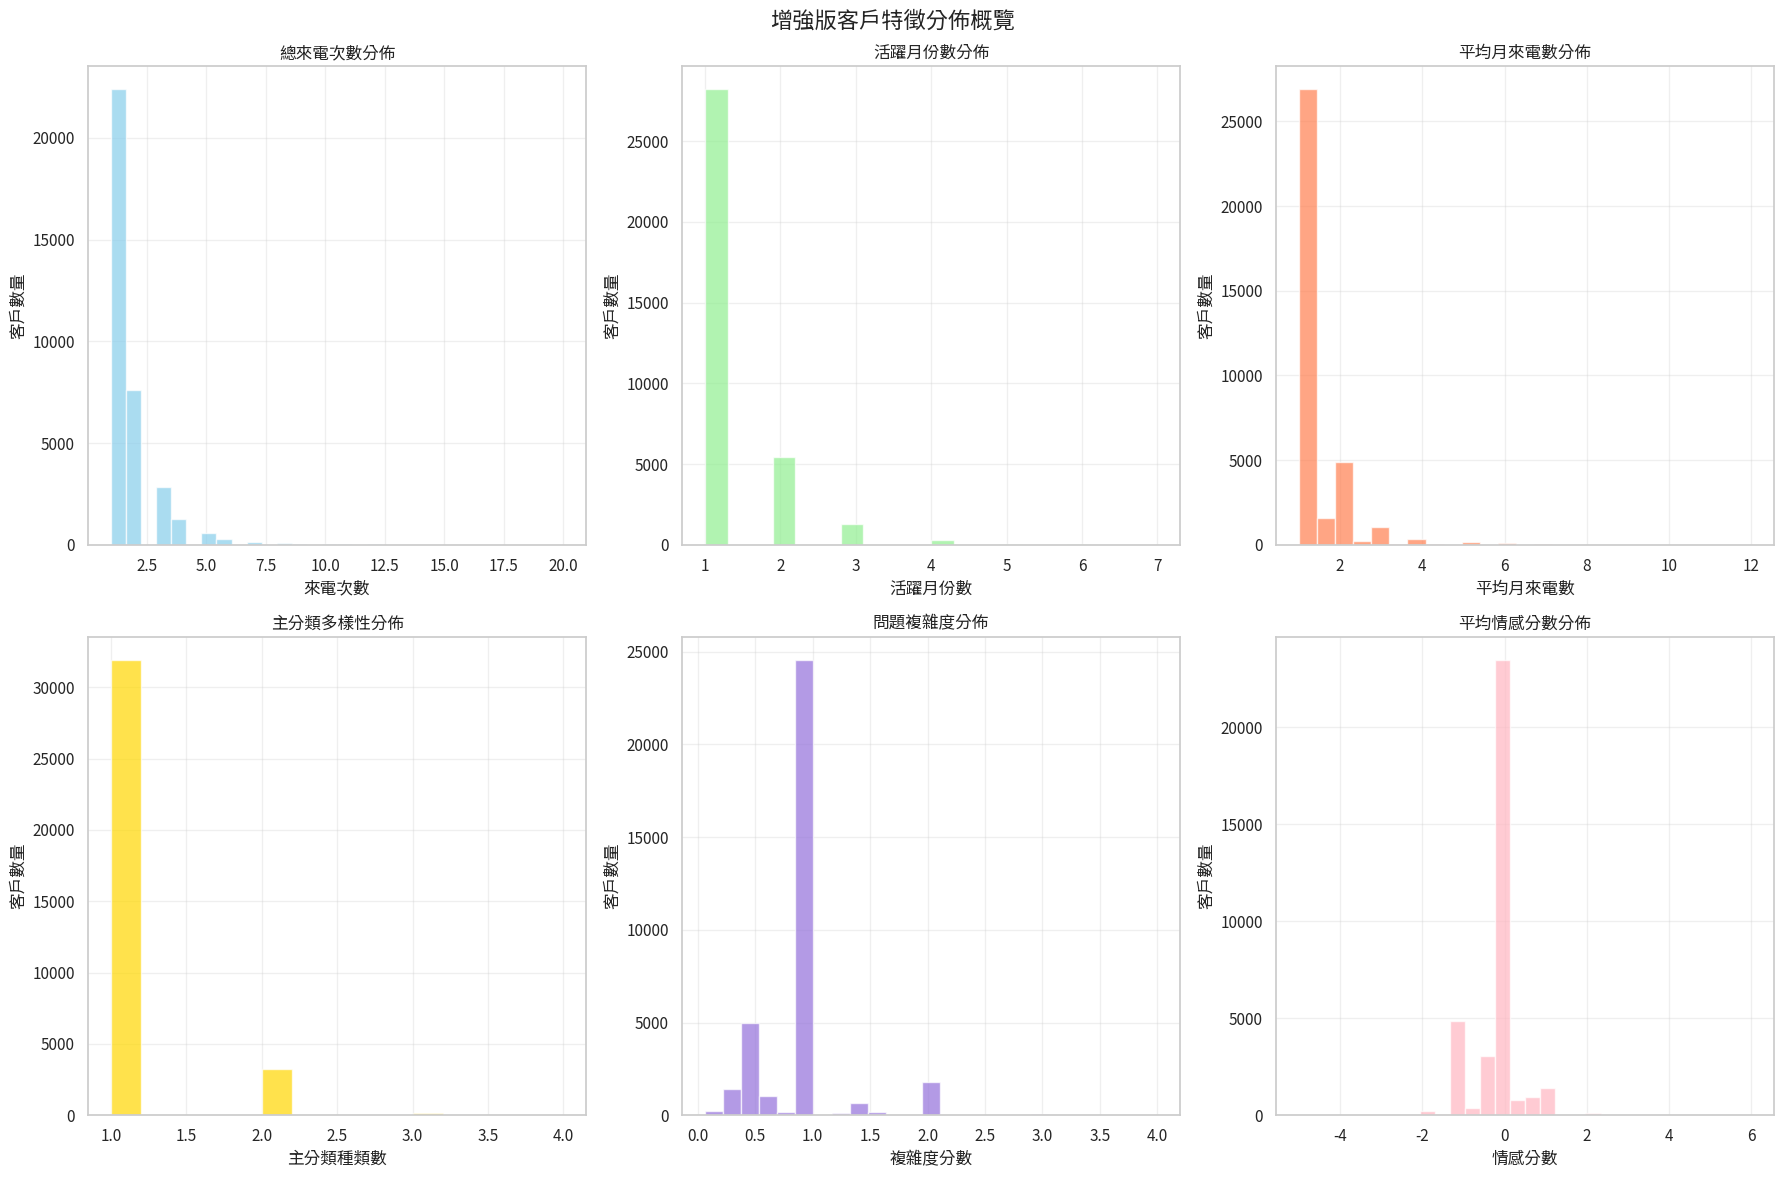

In [533]:
# 1. 整體特徵分佈概覽
#import matplotlib.pyplot as plt
#import seaborn as sns
#import numpy as np

# 設定圖表樣式
#plt.style.use('default')
#sns.set_palette("husl")

# 選擇數值型特徵進行分析
numerical_features = df_final_features.select_dtypes(include=[np.number]).columns.tolist()
print("數值型特徵:", numerical_features)

# 創建子圖來顯示主要特徵分佈
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('增強版客戶特徵分佈概覽', fontsize=16, fontweight='bold')

# 1.1 總來電次數分佈
if 'TOTAL_CALLS' in df_final_features.columns:
    ax1 = axes[0, 0]
    df_final_features['TOTAL_CALLS'].hist(bins=30, ax=ax1, alpha=0.7, color='skyblue')
    ax1.set_title('總來電次數分佈')
    ax1.set_xlabel('來電次數')
    ax1.set_ylabel('客戶數量')
    ax1.grid(True, alpha=0.3)

# 1.2 活躍月份數分佈
if 'ACTIVE_MONTHS' in df_final_features.columns:
    ax2 = axes[0, 1]
    df_final_features['ACTIVE_MONTHS'].hist(bins=20, ax=ax2, alpha=0.7, color='lightgreen')
    ax2.set_title('活躍月份數分佈')
    ax2.set_xlabel('活躍月份數')
    ax2.set_ylabel('客戶數量')
    ax2.grid(True, alpha=0.3)

# 1.3 平均月來電數分佈
if 'AVG_MONTHLY_CALLS' in df_final_features.columns:
    ax3 = axes[0, 2]
    df_final_features['AVG_MONTHLY_CALLS'].hist(bins=25, ax=ax3, alpha=0.7, color='coral')
    ax3.set_title('平均月來電數分佈')
    ax3.set_xlabel('平均月來電數')
    ax3.set_ylabel('客戶數量')
    ax3.grid(True, alpha=0.3)

# 1.4 問題多樣性分佈
if 'MAIN_CATEGORY_DIVERSITY' in df_final_features.columns:
    ax4 = axes[1, 0]
    df_final_features['MAIN_CATEGORY_DIVERSITY'].hist(bins=15, ax=ax4, alpha=0.7, color='gold')
    ax4.set_title('主分類多樣性分佈')
    ax4.set_xlabel('主分類種類數')
    ax4.set_ylabel('客戶數量')
    ax4.grid(True, alpha=0.3)

# 1.5 問題複雜度分佈
if 'PROBLEM_COMPLEXITY_SCORE' in df_final_features.columns:
    ax5 = axes[1, 1]
    df_final_features['PROBLEM_COMPLEXITY_SCORE'].hist(bins=25, ax=ax5, alpha=0.7, color='mediumpurple')
    ax5.set_title('問題複雜度分佈')
    ax5.set_xlabel('複雜度分數')
    ax5.set_ylabel('客戶數量')
    ax5.grid(True, alpha=0.3)

# 1.6 平均情感分數分佈
if 'AVG_SENTIMENT_SCORE' in df_final_features.columns:
    ax6 = axes[1, 2]
    df_final_features['AVG_SENTIMENT_SCORE'].hist(bins=30, ax=ax6, alpha=0.7, color='lightpink')
    ax6.set_title('平均情感分數分佈')
    ax6.set_xlabel('情感分數')
    ax6.set_ylabel('客戶數量')
    ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

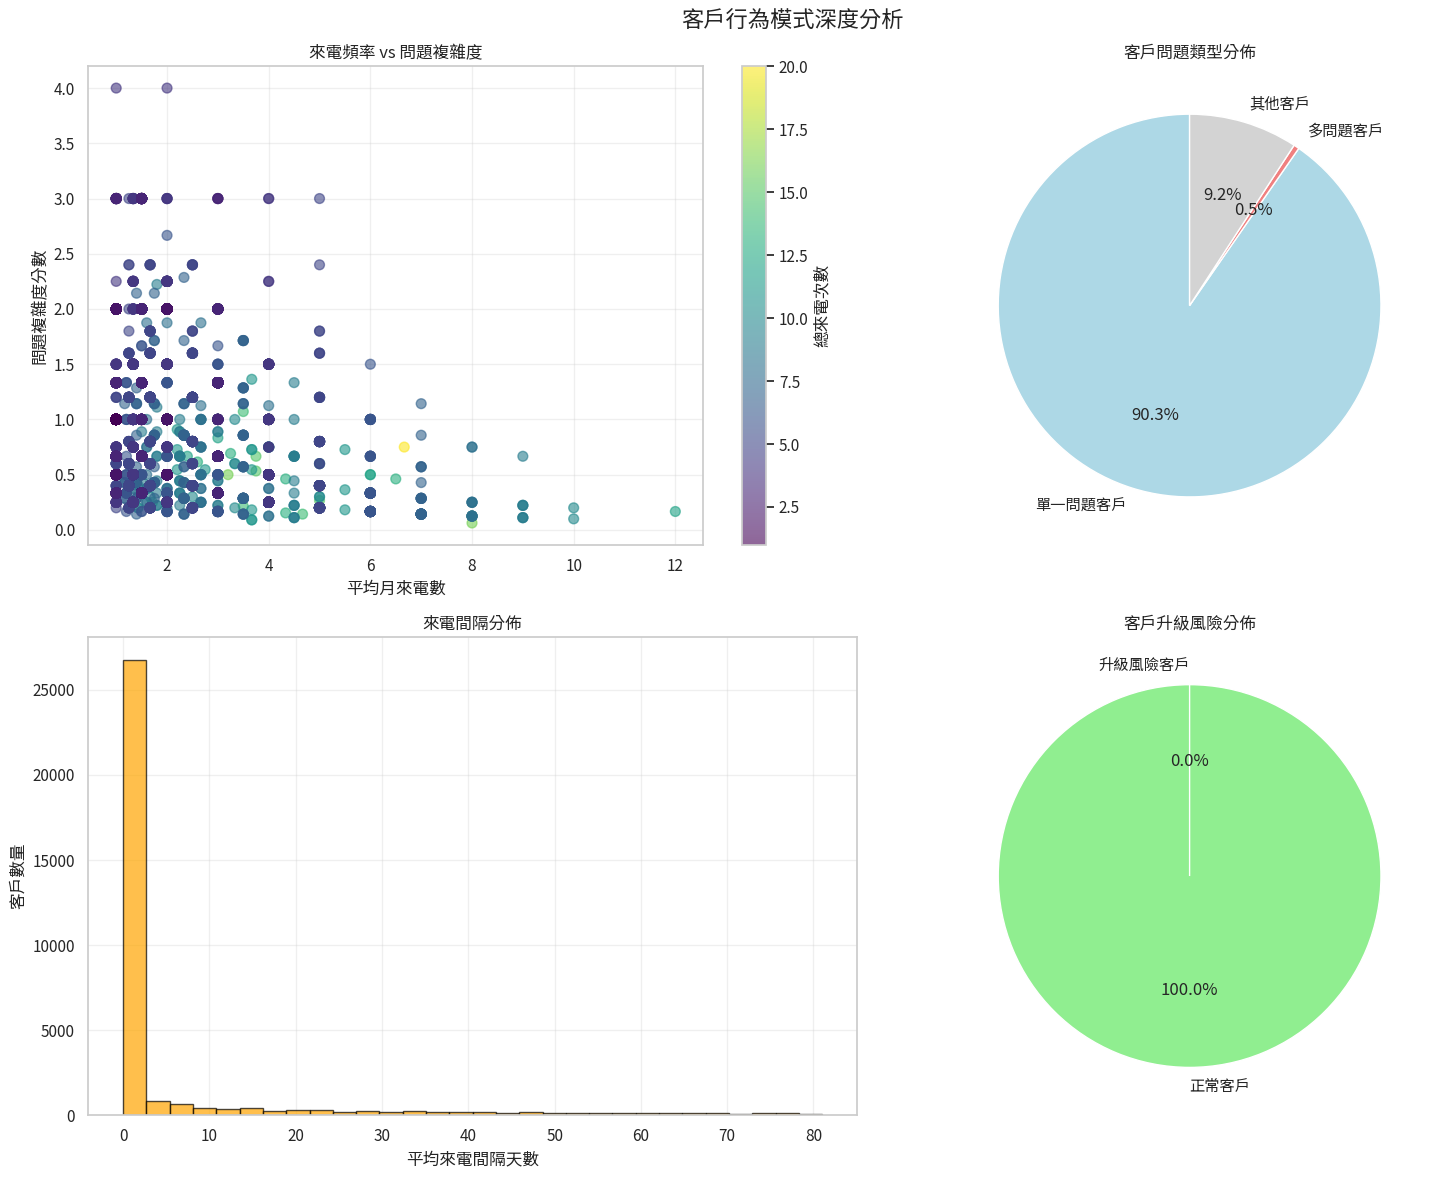

In [534]:
# 2. 客戶行為模式分析
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('客戶行為模式深度分析', fontsize=16, fontweight='bold')

# 2.1 來電頻率vs問題複雜度散點圖 - with error handling
if 'AVG_MONTHLY_CALLS' in df_final_features.columns and 'PROBLEM_COMPLEXITY_SCORE' in df_final_features.columns:
    ax1 = axes[0, 0]
    
    # Check if TOTAL_CALLS exists, otherwise use an alternative
    if 'TOTAL_CALLS' in df_final_features.columns:
        color_col = df_final_features['TOTAL_CALLS']
        color_label = '總來電次數'
    elif 'TOTAL_CALLS_x' in df_final_features.columns:
        color_col = df_final_features['TOTAL_CALLS_x']
        color_label = '總來電次數'
    else:
        # Use index as fallback
        color_col = range(len(df_final_features))
        color_label = '客戶編號'
    
    scatter = ax1.scatter(df_final_features['AVG_MONTHLY_CALLS'], 
                         df_final_features['PROBLEM_COMPLEXITY_SCORE'],
                         alpha=0.6, s=50, c=color_col, 
                         cmap='viridis')
    ax1.set_xlabel('平均月來電數')
    ax1.set_ylabel('問題複雜度分數')
    ax1.set_title('來電頻率 vs 問題複雜度')
    plt.colorbar(scatter, ax=ax1, label=color_label)
    ax1.grid(True, alpha=0.3)
else:
    # Handle missing columns
    ax1 = axes[0, 0]
    ax1.text(0.5, 0.5, '缺少必要欄位\n無法繪製此圖表', 
             ha='center', va='center', transform=ax1.transAxes)
    ax1.set_title('來電頻率 vs 問題複雜度 (數據不足)')

# Continue with other plots...

# 2.2 客戶類型分佈（單一問題 vs 多問題客戶）
if 'IS_SINGLE_ISSUE_CUSTOMER' in df_final_features.columns and 'IS_MULTI_ISSUE_CUSTOMER' in df_final_features.columns:
    ax2 = axes[0, 1]
    single_issue = df_final_features['IS_SINGLE_ISSUE_CUSTOMER'].sum()
    multi_issue = df_final_features['IS_MULTI_ISSUE_CUSTOMER'].sum()
    other = len(df_final_features) - single_issue - multi_issue
    
    categories = ['單一問題客戶', '多問題客戶', '其他客戶']
    values = [single_issue, multi_issue, other]
    colors = ['lightblue', 'lightcoral', 'lightgray']
    
    ax2.pie(values, labels=categories, autopct='%1.1f%%', colors=colors, startangle=90)
    ax2.set_title('客戶問題類型分佈')

# 2.3 來電間隔趨勢分析
if 'AVG_CALL_INTERVAL_DAYS' in df_final_features.columns:
    ax3 = axes[1, 0]
    # 過濾掉極端值進行視覺化
    interval_data = df_final_features['AVG_CALL_INTERVAL_DAYS'].dropna()
    interval_data = interval_data[interval_data <= interval_data.quantile(0.95)]
    
    ax3.hist(interval_data, bins=30, alpha=0.7, color='orange', edgecolor='black')
    ax3.set_xlabel('平均來電間隔天數')
    ax3.set_ylabel('客戶數量')
    ax3.set_title('來電間隔分佈')
    ax3.grid(True, alpha=0.3)

# 2.4 升級風險客戶分析
if 'ESCALATION_RISK' in df_final_features.columns:
    ax4 = axes[1, 1]
    risk_counts = df_final_features['ESCALATION_RISK'].value_counts()
    
    labels = ['正常客戶', '升級風險客戶']
    sizes = [risk_counts.get(0, 0), risk_counts.get(1, 0)]
    colors = ['lightgreen', 'red']
    
    ax4.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
    ax4.set_title('客戶升級風險分佈')

plt.tight_layout()
plt.show()

=== 特徵相關性分析 ===


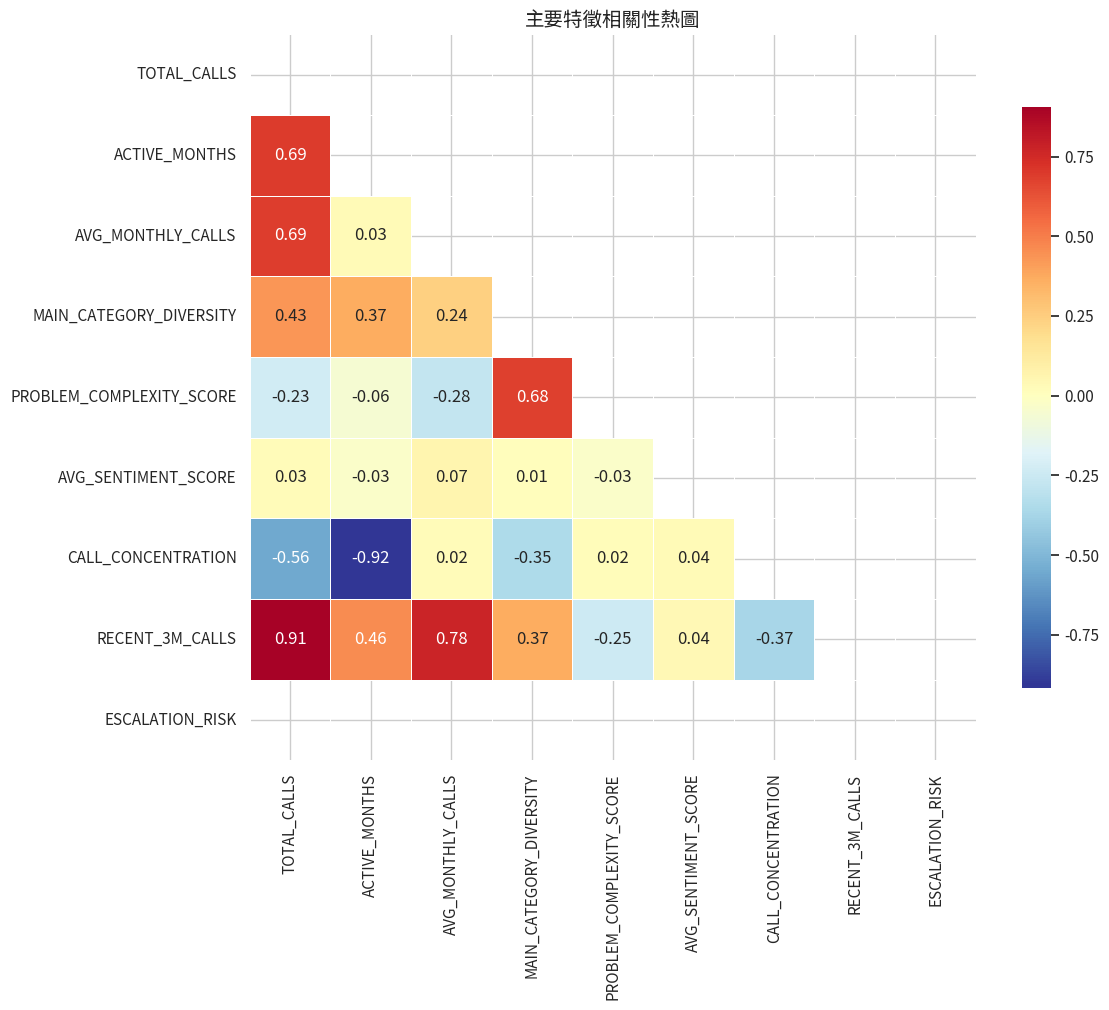


高度相關的特徵對 (|相關係數| > 0.5):
  TOTAL_CALLS <-> ACTIVE_MONTHS: 0.693
  TOTAL_CALLS <-> AVG_MONTHLY_CALLS: 0.691
  TOTAL_CALLS <-> CALL_CONCENTRATION: -0.558
  TOTAL_CALLS <-> RECENT_3M_CALLS: 0.906
  ACTIVE_MONTHS <-> CALL_CONCENTRATION: -0.916
  AVG_MONTHLY_CALLS <-> RECENT_3M_CALLS: 0.775
  MAIN_CATEGORY_DIVERSITY <-> PROBLEM_COMPLEXITY_SCORE: 0.678


In [535]:
# 3. 特徵相關性分析
print("=== 特徵相關性分析 ===")

# 選擇主要數值特徵進行相關性分析
key_features = []
for feature in ['TOTAL_CALLS', 'ACTIVE_MONTHS', 'AVG_MONTHLY_CALLS', 'MAIN_CATEGORY_DIVERSITY', 
                'PROBLEM_COMPLEXITY_SCORE', 'AVG_SENTIMENT_SCORE', 'CALL_CONCENTRATION',
                'RECENT_3M_CALLS', 'ESCALATION_RISK']:
    if feature in df_final_features.columns:
        key_features.append(feature)

if len(key_features) > 1:
    # 計算相關性矩陣
    corr_matrix = df_final_features[key_features].corr()
    
    # 創建相關性熱圖
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdYlBu_r', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": .8}, fmt='.2f')
    plt.title('主要特徵相關性熱圖', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 找出高度相關的特徵對
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > 0.5:
                high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_val))
    
    print("\n高度相關的特徵對 (|相關係數| > 0.5):")
    for pair in high_corr_pairs:
        print(f"  {pair[0]} <-> {pair[1]}: {pair[2]:.3f}")

=== 客戶細分分析 ===


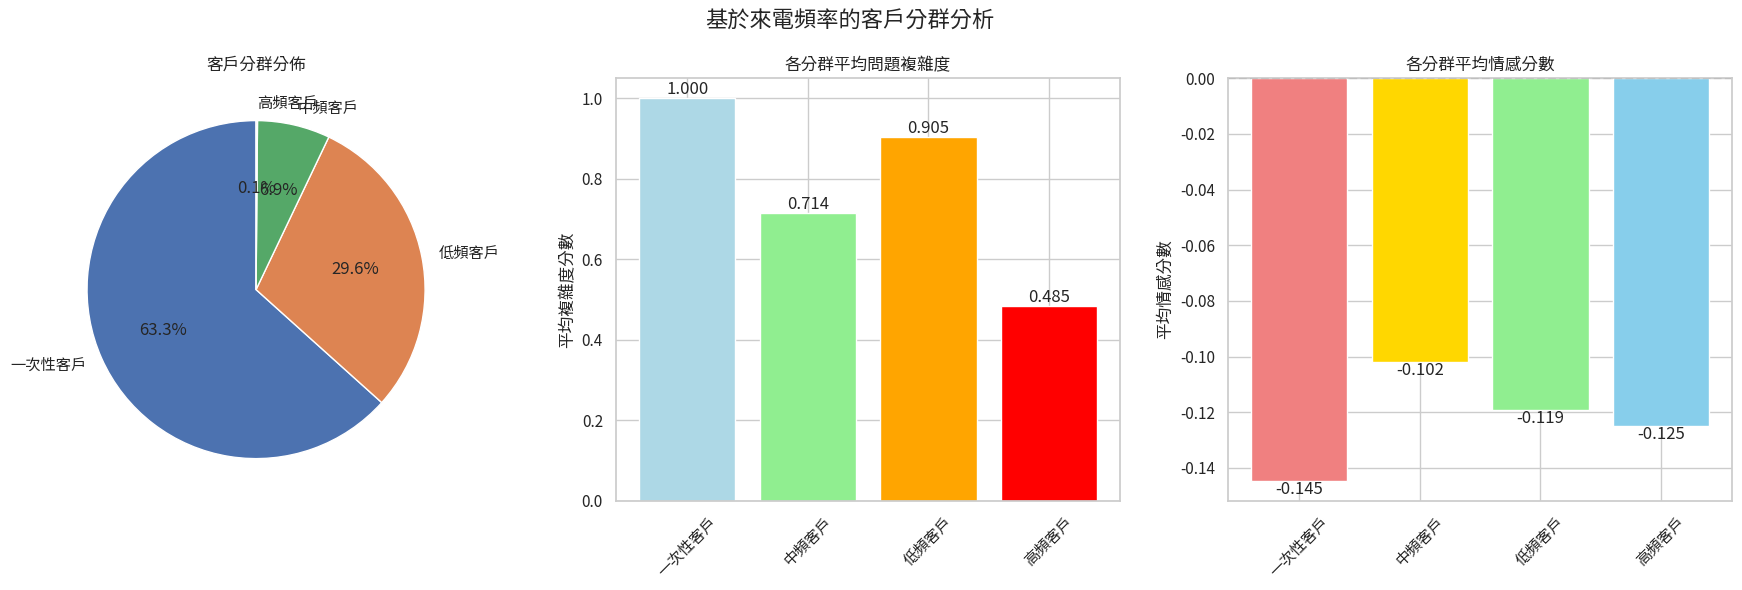

In [536]:
# 4. 客戶細分與特徵分析
print("=== 客戶細分分析 ===")

# 4.1 基於來電頻率的客戶分群
if 'TOTAL_CALLS' in df_final_features.columns:
    # 定義客戶分群
    def categorize_customer_by_calls(total_calls):
        if total_calls == 1:
            return '一次性客戶'
        elif total_calls <= 3:
            return '低頻客戶'
        elif total_calls <= 10:
            return '中頻客戶'
        else:
            return '高頻客戶'
    
    df_final_features['客戶分群'] = df_final_features['TOTAL_CALLS'].apply(categorize_customer_by_calls)
    
    # 視覺化客戶分群
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('基於來電頻率的客戶分群分析', fontsize=16, fontweight='bold')
    
    # 分群分佈
    ax1 = axes[0]
    customer_segments = df_final_features['客戶分群'].value_counts()
    ax1.pie(customer_segments.values, labels=customer_segments.index, autopct='%1.1f%%', startangle=90)
    ax1.set_title('客戶分群分佈')
    
    # 各分群的平均問題複雜度
    if 'PROBLEM_COMPLEXITY_SCORE' in df_final_features.columns:
        ax2 = axes[1]
        complexity_by_segment = df_final_features.groupby('客戶分群')['PROBLEM_COMPLEXITY_SCORE'].mean()
        bars = ax2.bar(complexity_by_segment.index, complexity_by_segment.values, 
                      color=['lightblue', 'lightgreen', 'orange', 'red'])
        ax2.set_title('各分群平均問題複雜度')
        ax2.set_ylabel('平均複雜度分數')
        ax2.tick_params(axis='x', rotation=45)
        
        # 添加數值標籤
        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom')
    
    # 各分群的平均情感分數
    if 'AVG_SENTIMENT_SCORE' in df_final_features.columns:
        ax3 = axes[2]
        sentiment_by_segment = df_final_features.groupby('客戶分群')['AVG_SENTIMENT_SCORE'].mean()
        bars = ax3.bar(sentiment_by_segment.index, sentiment_by_segment.values,
                      color=['lightcoral', 'gold', 'lightgreen', 'skyblue'])
        ax3.set_title('各分群平均情感分數')
        ax3.set_ylabel('平均情感分數')
        ax3.tick_params(axis='x', rotation=45)
        ax3.axhline(y=0, color='black', linestyle='--', alpha=0.5)
        
        # 添加數值標籤
        for bar in bars:
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom' if height >= 0 else 'top')
    
    plt.tight_layout()
    plt.show()

=== 進階特徵分析 ===


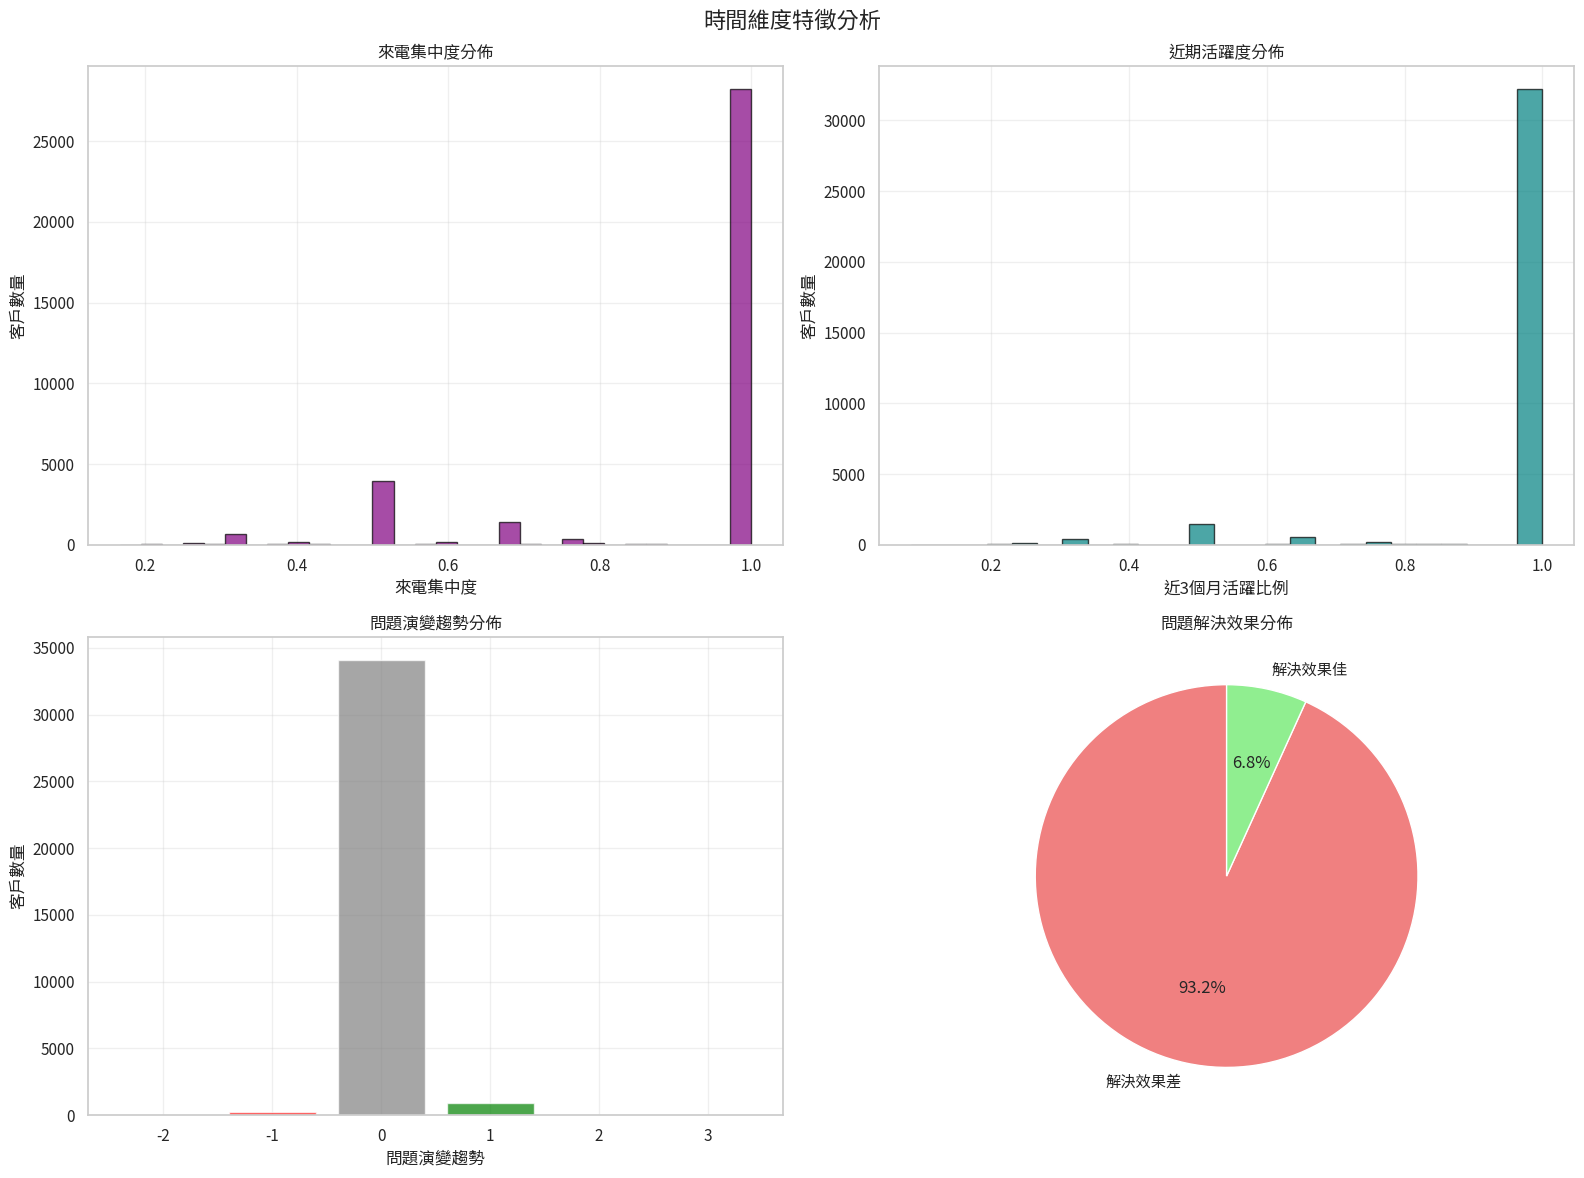

In [537]:
# 5. 進階特徵分析
print("=== 進階特徵分析 ===")

# 5.1 時間特徵分析
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('時間維度特徵分析', fontsize=16, fontweight='bold')

# 來電集中度分析
if 'CALL_CONCENTRATION' in df_final_features.columns:
    ax1 = axes[0, 0]
    concentration_data = df_final_features['CALL_CONCENTRATION'].dropna()
    ax1.hist(concentration_data, bins=30, alpha=0.7, color='purple', edgecolor='black')
    ax1.set_xlabel('來電集中度')
    ax1.set_ylabel('客戶數量')
    ax1.set_title('來電集中度分佈')
    ax1.grid(True, alpha=0.3)

# 近期活躍度分析
if 'RECENT_3M_CALLS' in df_final_features.columns and 'TOTAL_CALLS' in df_final_features.columns:
    ax2 = axes[0, 1]
    df_final_features['近期活躍比例'] = df_final_features['RECENT_3M_CALLS'] / df_final_features['TOTAL_CALLS']
    recent_activity = df_final_features['近期活躍比例'].dropna()
    ax2.hist(recent_activity, bins=25, alpha=0.7, color='teal', edgecolor='black')
    ax2.set_xlabel('近3個月活躍比例')
    ax2.set_ylabel('客戶數量')
    ax2.set_title('近期活躍度分佈')
    ax2.grid(True, alpha=0.3)

# 問題演變趨勢分析
if 'PROBLEM_EVOLUTION_TREND' in df_final_features.columns:
    ax3 = axes[1, 0]
    evolution_counts = df_final_features['PROBLEM_EVOLUTION_TREND'].value_counts().sort_index()
    colors = ['red' if x < 0 else 'green' if x > 0 else 'gray' for x in evolution_counts.index]
    bars = ax3.bar(evolution_counts.index, evolution_counts.values, color=colors, alpha=0.7)
    ax3.set_xlabel('問題演變趨勢')
    ax3.set_ylabel('客戶數量')
    ax3.set_title('問題演變趨勢分佈')
    ax3.grid(True, alpha=0.3)

# 解決效果分析
if 'RESOLUTION_EFFECTIVENESS' in df_final_features.columns:
    ax4 = axes[1, 1]
    effectiveness_counts = df_final_features['RESOLUTION_EFFECTIVENESS'].value_counts()
    labels = ['解決效果差', '解決效果佳']
    sizes = [effectiveness_counts.get(0, 0), effectiveness_counts.get(1, 0)]
    colors = ['lightcoral', 'lightgreen']
    
    ax4.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
    ax4.set_title('問題解決效果分佈')

plt.tight_layout()
plt.show()

=== 關鍵客戶識別與風險評估 ===


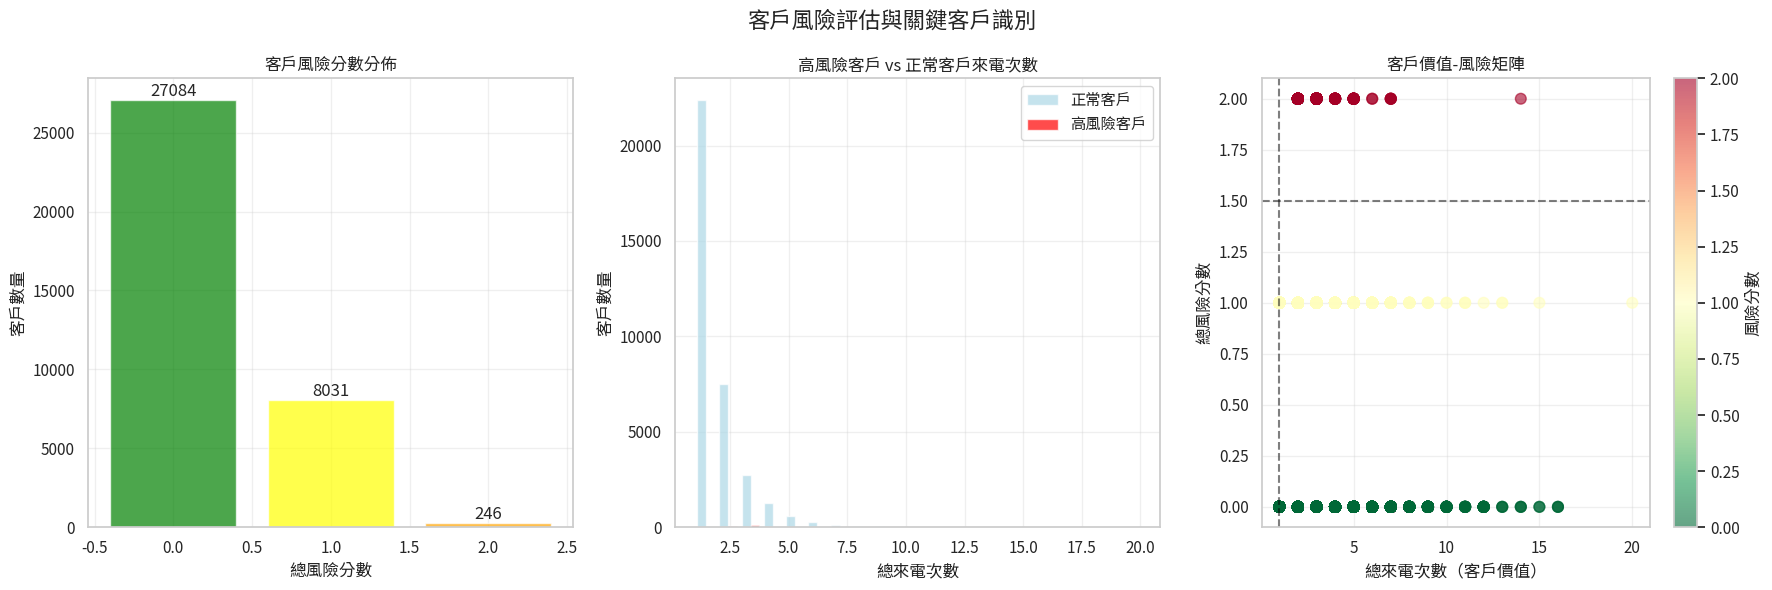


=== 風險評估統計 ===
總客戶數: 35361
高風險客戶數 (風險分數≥2): 246
高風險客戶比例: 0.7%
高價值高風險客戶數: 156
高價值高風險客戶比例: 0.4%


In [538]:
# 6. 關鍵客戶識別與風險評估
print("=== 關鍵客戶識別與風險評估 ===")

# 6.1 建立客戶風險評分
risk_factors = []
if 'ESCALATION_RISK' in df_final_features.columns:
    risk_factors.append('ESCALATION_RISK')
if 'AVG_SENTIMENT_SCORE' in df_final_features.columns:
    # 將情感分數轉換為風險因子（負分越低風險越高）
    df_final_features['情感風險'] = (df_final_features['AVG_SENTIMENT_SCORE'] < -0.5).astype(int)
    risk_factors.append('情感風險')
if 'PROBLEM_COMPLEXITY_SCORE' in df_final_features.columns:
    # 複雜度高的客戶風險較高
    complexity_threshold = df_final_features['PROBLEM_COMPLEXITY_SCORE'].quantile(0.8)
    df_final_features['複雜度風險'] = (df_final_features['PROBLEM_COMPLEXITY_SCORE'] > complexity_threshold).astype(int)
    risk_factors.append('複雜度風險')

if risk_factors:
    # 計算總風險分數
    df_final_features['總風險分數'] = df_final_features[risk_factors].sum(axis=1)
    
    # 視覺化風險分佈
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('客戶風險評估與關鍵客戶識別', fontsize=16, fontweight='bold')
    
    # 風險分數分佈
    ax1 = axes[0]
    risk_dist = df_final_features['總風險分數'].value_counts().sort_index()
    colors = ['green', 'yellow', 'orange', 'red'][:len(risk_dist)]
    bars = ax1.bar(risk_dist.index, risk_dist.values, color=colors, alpha=0.7)
    ax1.set_xlabel('總風險分數')
    ax1.set_ylabel('客戶數量')
    ax1.set_title('客戶風險分數分佈')
    ax1.grid(True, alpha=0.3)
    
    # 添加數值標籤
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')
    
    # 高風險客戶特徵分析
    if 'TOTAL_CALLS' in df_final_features.columns:
        ax2 = axes[1]
        high_risk_customers = df_final_features[df_final_features['總風險分數'] >= 2]
        normal_customers = df_final_features[df_final_features['總風險分數'] < 2]
        
        ax2.hist([normal_customers['TOTAL_CALLS'], high_risk_customers['TOTAL_CALLS']], 
                bins=20, alpha=0.7, label=['正常客戶', '高風險客戶'], 
                color=['lightblue', 'red'])
        ax2.set_xlabel('總來電次數')
        ax2.set_ylabel('客戶數量')
        ax2.set_title('高風險客戶 vs 正常客戶來電次數')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    
    # 關鍵客戶矩陣（價值 vs 風險）
    if 'TOTAL_CALLS' in df_final_features.columns:
        ax3 = axes[2]
        scatter = ax3.scatter(df_final_features['TOTAL_CALLS'], 
                             df_final_features['總風險分數'],
                             alpha=0.6, s=60, 
                             c=df_final_features['總風險分數'], 
                             cmap='RdYlGn_r')
        ax3.set_xlabel('總來電次數（客戶價值）')
        ax3.set_ylabel('總風險分數')
        ax3.set_title('客戶價值-風險矩陣')
        ax3.grid(True, alpha=0.3)
        
        # 添加象限線
        ax3.axhline(y=1.5, color='black', linestyle='--', alpha=0.5)
        ax3.axvline(x=df_final_features['TOTAL_CALLS'].median(), color='black', linestyle='--', alpha=0.5)
        
        plt.colorbar(scatter, ax=ax3, label='風險分數')
    
    plt.tight_layout()
    plt.show()
    
    # 輸出關鍵統計
    print(f"\n=== 風險評估統計 ===")
    print(f"總客戶數: {len(df_final_features)}")
    print(f"高風險客戶數 (風險分數≥2): {len(df_final_features[df_final_features['總風險分數'] >= 2])}")
    print(f"高風險客戶比例: {len(df_final_features[df_final_features['總風險分數'] >= 2]) / len(df_final_features) * 100:.1f}%")
    
    if 'TOTAL_CALLS' in df_final_features.columns:
        high_value_high_risk = df_final_features[
            (df_final_features['總風險分數'] >= 2) & 
            (df_final_features['TOTAL_CALLS'] > df_final_features['TOTAL_CALLS'].quantile(0.7))
        ]
        print(f"高價值高風險客戶數: {len(high_value_high_risk)}")
        print(f"高價值高風險客戶比例: {len(high_value_high_risk) / len(df_final_features) * 100:.1f}%")

=== 特徵重要性與業務洞察 ===


主要特徵統計摘要:


,CUST_NO,TOTAL_CALLS,ACTIVE_MONTHS,ACTIVE_QUARTERS,AVG_MONTHLY_CALLS,MAX_MONTHLY_CALLS,STD_MONTHLY_CALLS,AVG_CALL_INTERVAL_DAYS,STD_CALL_INTERVAL_DAYS,MIN_CALL_INTERVAL_DAYS,...,TOTAL_SENTIMENT_SCORE,STD_SENTIMENT_SCORE,MIN_SENTIMENT_SCORE,MAX_SENTIMENT_SCORE,AVG_score,週數,近期活躍比例,情感風險,複雜度風險,總風險分數
count,3.536100e+04,35361.000000,35361.000000,35361.000000,35361.000000,35361.000000,35361.000000,35361.000000,35361.000000,35361.000000,...,35361.000000,35361.000000,35361.000000,35361.000000,35361.000000,35361.0,35361.000000,35361.000000,35361.000000,35361.000000
mean,9.266076e+05,1.667289,1.264444,1.152739,1.307587,1.376460,0.081908,12.212643,4.459398,9.003959,...,-0.207008,0.143514,-0.260796,-0.011793,-0.404920,20.15042,0.957657,0.158678,0.082351,0.241028
std,3.654198e+05,1.222603,0.598929,0.395966,0.696063,0.819629,0.332341,33.030724,16.727324,30.957629,...,0.816936,0.337623,0.611053,0.581096,0.378317,11.213554,0.142615,0.365380,0.274902,0.443681
min,4.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,-16.000000,0.000000,-9.000000,-5.000000,-1.000000,1.0,0.083333,0.000000,0.000000,0.000000
25%,7.288800e+05,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,-1.000000,0.000000,-1.000000,0.000000,-0.700000,10.0,1.000000,0.000000,0.000000,0.000000
50%,1.071772e+06,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,-0.600000,20.0,1.000000,0.000000,0.000000,0.000000
75%,1.234416e+06,2.000000,1.000000,1.000000,1.333333,2.000000,0.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,-0.200000,30.0,1.000000,0.000000,0.000000,0.000000
max,1.288307e+06,20.000000,7.000000,3.000000,12.000000,12.000000,7.071068,271.000000,181.019336,271.000000,...,7.000000,5.196152,6.000000,6.000000,1.000000,40.0,1.000000,1.000000,1.000000,2.000000


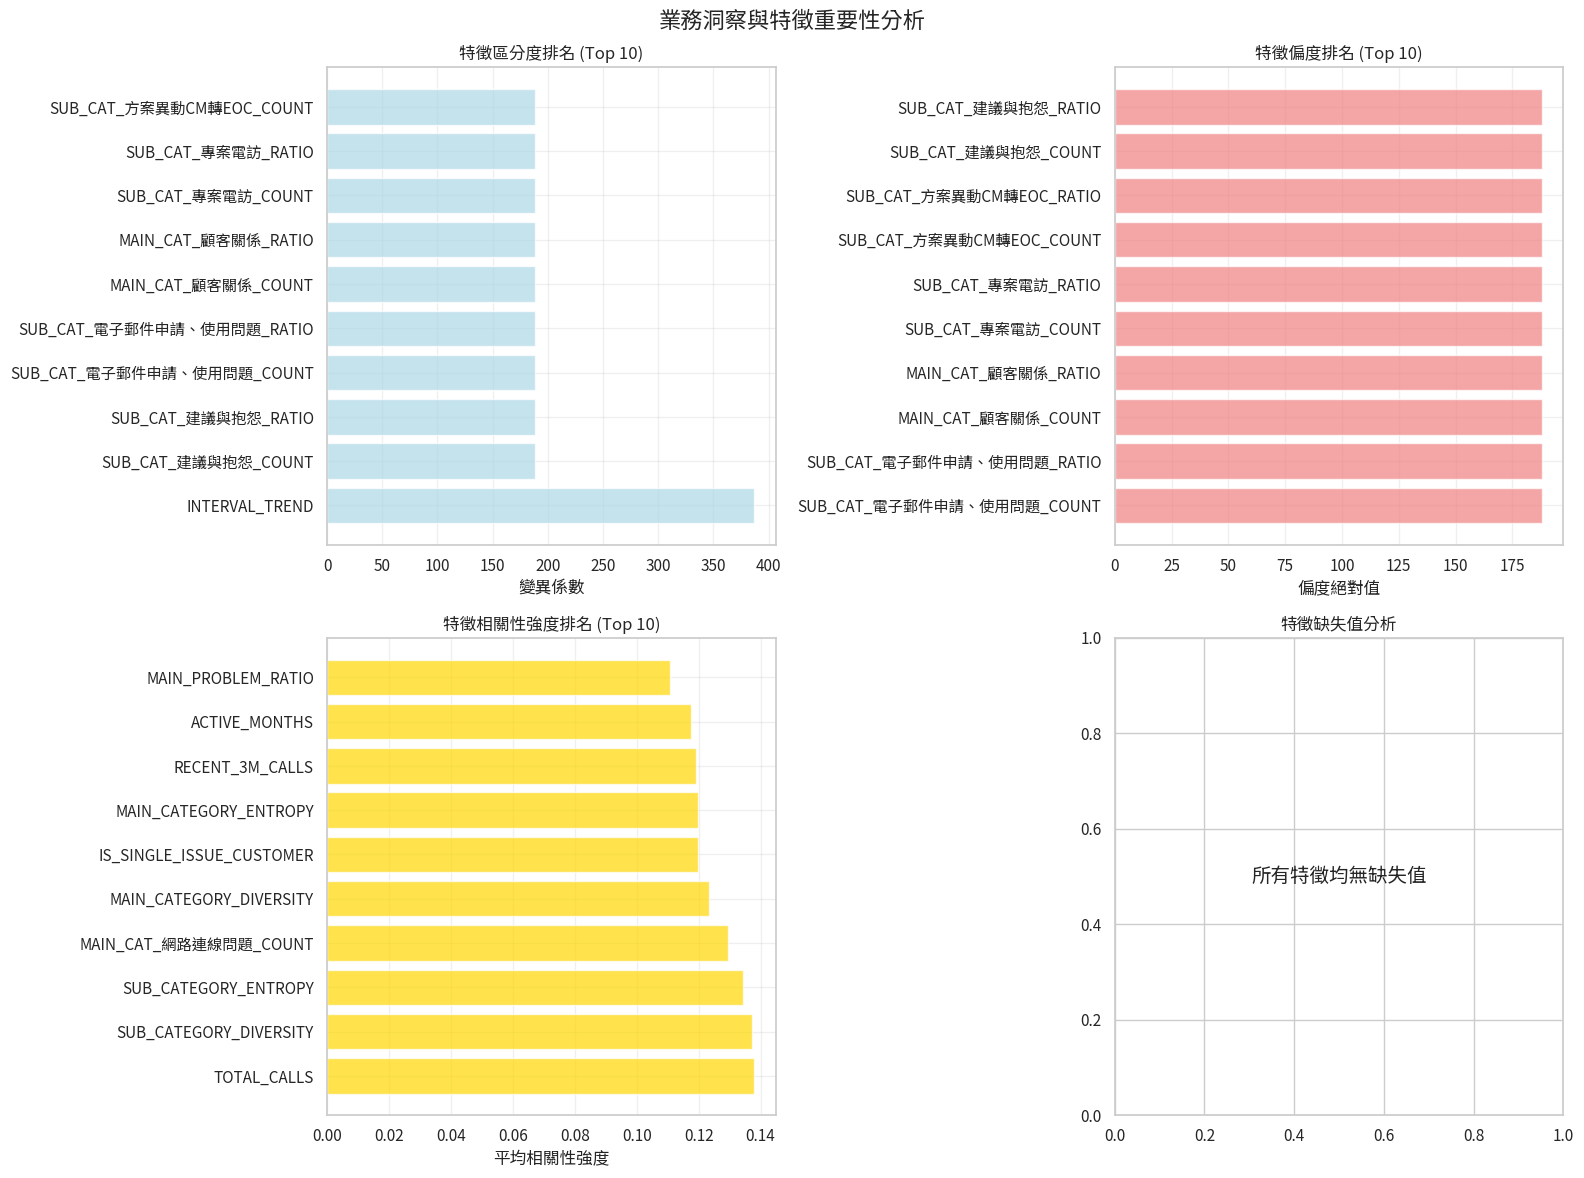

In [539]:
# 7. 特徵重要性與業務洞察
print("=== 特徵重要性與業務洞察 ===")

# 7.1 特徵統計摘要
numerical_cols = df_final_features.select_dtypes(include=[np.number]).columns
feature_summary = df_final_features[numerical_cols].describe()

print("主要特徵統計摘要:")
display(feature_summary)

# 7.2 業務洞察可視化
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('業務洞察與特徵重要性分析', fontsize=16, fontweight='bold')

# 特徵變異係數分析（衡量特徵的區分度）
ax1 = axes[0, 0]
cv_scores = {}
for col in numerical_cols:
    if col in df_final_features.columns:
        mean_val = df_final_features[col].mean()
        std_val = df_final_features[col].std()
        if mean_val != 0:
            cv_scores[col] = std_val / abs(mean_val)

if cv_scores:
    sorted_cv = sorted(cv_scores.items(), key=lambda x: x[1], reverse=True)[:10]
    features, cv_values = zip(*sorted_cv)
    
    bars = ax1.barh(features, cv_values, color='lightblue', alpha=0.7)
    ax1.set_xlabel('變異係數')
    ax1.set_title('特徵區分度排名 (Top 10)')
    ax1.grid(True, alpha=0.3)

# 特徵分佈偏度分析
ax2 = axes[0, 1]
skewness_scores = {}
for col in numerical_cols:
    if col in df_final_features.columns:
        skew_val = df_final_features[col].skew()
        if not np.isnan(skew_val):
            skewness_scores[col] = abs(skew_val)

if skewness_scores:
    sorted_skew = sorted(skewness_scores.items(), key=lambda x: x[1], reverse=True)[:10]
    features, skew_values = zip(*sorted_skew)
    
    bars = ax2.barh(features, skew_values, color='lightcoral', alpha=0.7)
    ax2.set_xlabel('偏度絕對值')
    ax2.set_title('特徵偏度排名 (Top 10)')
    ax2.grid(True, alpha=0.3)

# 特徵相關性強度分析
ax3 = axes[1, 0]
if len(numerical_cols) > 1:
    corr_matrix = df_final_features[numerical_cols].corr()
    # 計算每個特徵與其他特徵的平均相關性
    avg_corr = {}
    for col in numerical_cols:
        if col in corr_matrix.columns:
            other_corr = corr_matrix[col].drop(col)
            avg_corr[col] = abs(other_corr).mean()
    
    if avg_corr:
        sorted_corr = sorted(avg_corr.items(), key=lambda x: x[1], reverse=True)[:10]
        features, corr_values = zip(*sorted_corr)
        
        bars = ax3.barh(features, corr_values, color='gold', alpha=0.7)
        ax3.set_xlabel('平均相關性強度')
        ax3.set_title('特徵相關性強度排名 (Top 10)')
        ax3.grid(True, alpha=0.3)

# 缺失值分析
ax4 = axes[1, 1]
missing_rates = df_final_features.isnull().sum() / len(df_final_features) * 100
missing_features = missing_rates[missing_rates > 0].sort_values(ascending=False)

if len(missing_features) > 0:
    bars = ax4.barh(missing_features.index, missing_features.values, color='red', alpha=0.7)
    ax4.set_xlabel('缺失值比例 (%)')
    ax4.set_title('特徵缺失值比例')
    ax4.grid(True, alpha=0.3)
else:
    ax4.text(0.5, 0.5, '所有特徵均無缺失值', ha='center', va='center', 
             transform=ax4.transAxes, fontsize=14)
    ax4.set_title('特徵缺失值分析')

plt.tight_layout()
plt.show()

In [540]:
# 忽略這個區塊，因為後續改透過SFSS篩選特徵欄位
'''
# 保留和補充 df_final_features 中的指定特徵

print("=== 保留和補充指定特徵欄位 ===")

# 定義要保留的特徵列表
selected_features = [
    # 基礎特徵
    'CUST_NO',
    
    # 基本統計特徵
    'TOTAL_CALLS',
    'AVG_MONTHLY_CALLS', 
    'RECENT_3M_CALLS',
    'ACTIVE_QUARTERS',
    'CALL_CONCENTRATION',
    'ACTIVE_MONTHS',
    'MAX_MONTHLY_CALLS',
    'ESCALATION_TREND',
    'STD_MONTHLY_CALLS',
    
    # 時間間隔特徵
    'AVG_CALL_INTERVAL_DAYS',
    'STD_CALL_INTERVAL_DAYS',
    'MIN_CALL_INTERVAL_DAYS',
    'INTERVAL_TREND',
    
    # 問題多樣性特徵
    'PROBLEM_COMPLEXITY_SCORE',
    'SUB_CATEGORY_DIVERSITY',
    'SUB_CATEGORY_ENTROPY',
    'IS_MULTI_ISSUE_CUSTOMER',
    'PROBLEM_EVOLUTION_TREND',
    'MAIN_CATEGORY_ENTROPY',
    'MAIN_PROBLEM_RATIO',
    'MAIN_CATEGORY_DIVERSITY',
    'IS_SINGLE_ISSUE_CUSTOMER',
    
    # 情感分析特徵
    'MAX_SENTIMENT_SCORE',
    'TOTAL_SENTIMENT_SCORE',
    'AVG_SENTIMENT_SCORE',
    'STD_SENTIMENT_SCORE',
    'MIN_SENTIMENT_SCORE',
    
    # 問題演變特徵
    'ESCALATION_RISK',
    'RECENT_SEVERITY_AVG',
    'PROBLEM_SEVERITY_TREND',
    'RECURRING_ISSUES_COUNT',
    'RESOLUTION_EFFECTIVENESS',
    
    # 主分類特徵
    'MAIN_CAT_非連線問題_COUNT',
    'MAIN_CAT_新產品_COUNT',
    'MAIN_CAT_註冊問題_COUNT',
    'MAIN_CAT_搬家問題_RATIO',
    'MAIN_CAT_新產品_RATIO',
    'MAIN_CAT_E Mail_RATIO',
    'MAIN_CAT_搬家問題_COUNT',
    'MAIN_CAT_E Mail_COUNT',
    'MAIN_CAT_非連線問題_RATIO',
    'MAIN_CAT_註冊問題_RATIO',
    
    # 次分類特徵
    'SUB_CAT_方案異動CM轉EOC_COUNT',
    'SUB_CAT_建議與抱怨_RATIO',
    'SUB_CAT_方案異動CM轉EOC_RATIO',
    'SUB_CAT_建議與抱怨_COUNT',
    'SUB_CAT_台數科服務區_RATIO',
    'SUB_CAT_網路郵局webmail_COUNT',
    'SUB_CAT_台數科服務區_COUNT',
    'SUB_CAT_無法收、發信件_RATIO',
    'SUB_CAT_無法收、發信件_COUNT',
    'SUB_CAT_網路郵局webmail_RATIO'
]

print(f"目標特徵總數: {len(selected_features)}")
print(f"原始 df_final_features 形狀: {df_final_features.shape}")

# 檢查現有欄位
existing_features = []
missing_features = []

for feature in selected_features:
    if feature in df_final_features.columns:
        existing_features.append(feature)
    else:
        missing_features.append(feature)

print(f"\n=== 特徵狀態分析 ===")
print(f"已存在的特徵數: {len(existing_features)}")
print(f"缺失的特徵數: {len(missing_features)}")

# 顯示已存在的特徵
print(f"\n已存在的特徵 ({len(existing_features)} 個):")
for i, feature in enumerate(existing_features, 1):
    print(f"  {i:2d}. {feature}")

# 顯示缺失的特徵
if missing_features:
    print(f"\n缺失的特徵 ({len(missing_features)} 個):")
    for i, feature in enumerate(missing_features, 1):
        print(f"  {i:2d}. {feature}")

# 建立新的資料集，先保留現有的特徵
df_selected = df_final_features[existing_features].copy()

# 新增缺失的特徵並填入0
print(f"\n=== 新增缺失特徵 ===")
for feature in missing_features:
    df_selected[feature] = 0
    print(f"已新增特徵: {feature} (值填入0)")

# 確保欄位順序與 selected_features 一致
df_selected = df_selected[selected_features]

print(f"\n=== 處理結果 ===")
print(f"原始形狀: {df_final_features.shape}")
print(f"篩選後形狀: {df_selected.shape}")
print(f"保留欄位數: {len(selected_features)}")

# 檢查是否所有目標特徵都存在
all_features_present = all(feature in df_selected.columns for feature in selected_features)
print(f"所有目標特徵都存在: {'✅' if all_features_present else '❌'}")

# 檢查新增特徵的數據類型
print(f"\n=== 新增特徵數據類型檢查 ===")
for feature in missing_features:
    dtype = df_selected[feature].dtype
    unique_vals = df_selected[feature].unique()
    print(f"{feature}: {dtype}, 唯一值: {unique_vals}")

# 顯示資料預覽
print(f"\n=== 篩選後資料預覽 ===")
print("前5筆資料:")
display(df_selected.head())

# 檢查缺失值
print(f"\n=== 缺失值檢查 ===")
null_counts = df_selected.isnull().sum()
if null_counts.sum() > 0:
    print("存在缺失值的欄位:")
    print(null_counts[null_counts > 0])
else:
    print("✅ 所有欄位均無缺失值")

# 更新 df_final_features
df_final_features = df_selected.copy()
print(f"\n✅ df_final_features 已更新為篩選後的資料集")
print(f"最終形狀: {df_final_features.shape}")

# 分類統計
feature_categories = {
    '基礎特徵': 1,
    '基本統計特徵': 9, 
    '時間間隔特徵': 4,
    '問題多樣性特徵': 9,
    '情感分析特徵': 5,
    '問題演變特徵': 5,
    '主分類特徵': 10,
    '次分類特徵': 10
}

print(f"\n=== 特徵分類統計 ===")
for category, count in feature_categories.items():
    print(f"{category}: {count} 個特徵")

total_expected = sum(feature_categories.values())
print(f"預期總特徵數: {total_expected}")
print(f"實際特徵數: {df_final_features.shape[1]}")
print(f"特徵數一致: {'✅' if total_expected == df_final_features.shape[1] else '❌'}")

print("\n" + "="*80)
print("特徵篩選和補充作業完成")
'''

'\n# 保留和補充 df_final_features 中的指定特徵\n\nprint("=== 保留和補充指定特徵欄位 ===")\n\n# 定義要保留的特徵列表\nselected_features = [\n    # 基礎特徵\n    \'CUST_NO\',\n\n    # 基本統計特徵\n    \'TOTAL_CALLS\',\n    \'AVG_MONTHLY_CALLS\', \n    \'RECENT_3M_CALLS\',\n    \'ACTIVE_QUARTERS\',\n    \'CALL_CONCENTRATION\',\n    \'ACTIVE_MONTHS\',\n    \'MAX_MONTHLY_CALLS\',\n    \'ESCALATION_TREND\',\n    \'STD_MONTHLY_CALLS\',\n\n    # 時間間隔特徵\n    \'AVG_CALL_INTERVAL_DAYS\',\n    \'STD_CALL_INTERVAL_DAYS\',\n    \'MIN_CALL_INTERVAL_DAYS\',\n    \'INTERVAL_TREND\',\n\n    # 問題多樣性特徵\n    \'PROBLEM_COMPLEXITY_SCORE\',\n    \'SUB_CATEGORY_DIVERSITY\',\n    \'SUB_CATEGORY_ENTROPY\',\n    \'IS_MULTI_ISSUE_CUSTOMER\',\n    \'PROBLEM_EVOLUTION_TREND\',\n    \'MAIN_CATEGORY_ENTROPY\',\n    \'MAIN_PROBLEM_RATIO\',\n    \'MAIN_CATEGORY_DIVERSITY\',\n    \'IS_SINGLE_ISSUE_CUSTOMER\',\n\n    # 情感分析特徵\n    \'MAX_SENTIMENT_SCORE\',\n    \'TOTAL_SENTIMENT_SCORE\',\n    \'AVG_SENTIMENT_SCORE\',\n    \'STD_SENTIMENT_SCORE\',\n    \'MIN_SENTI

In [541]:
df_final_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35361 entries, 0 to 35360
Columns: 160 entries, CUST_NO to 總風險分數
dtypes: UInt32(1), datetime64[ns](1), float64(133), int64(17), object(6), period[M](1), period[Q-DEC](1)
memory usage: 43.1+ MB


In [542]:
filepath = f'forPredict_csr_2025_{target_month_start}_{target_month_end}_all.csv'
df_final_features.to_csv(filepath, index=False)
print(f"檔案存檔至 {filepath}")

檔案存檔至 forPredict_csr_2025_1_9_all.csv


## @@ <<< 三維預測資料集整備 >>>

In [543]:
# === 路徑 ===
a_path = f'forPredict_ds_doService_2025_{target_month_start}_{target_month_end}_all.csv'   # A 工單
b_path = f'forPredict_ds_billing_onehot_2025_{target_month_start}_{target_month_end}_all.csv'  # B 帳務 
c_path = f'forPredict_csr_2025_{target_month_start}_{target_month_end}_all.csv'                # C 客服記錄
out_path = 'forPredict_csr_service_bill.csv'

In [544]:
a = pd.read_csv(a_path,sep='^').rename(columns={'客編': 'CUST_NO'})
b = pd.read_csv(b_path,sep=',').rename(columns={'客編': 'CUST_NO'})
c = pd.read_csv(c_path,sep=',')

In [545]:
a.head()

,CUST_NO,工單原因_主要,工單原因_次要,工單原因_種類數,工單原因_最新,工單原因_最舊,工單原因_重複率,工單嚴重程度_平均,工單嚴重程度_最高,工單升級趨勢,...,工單原因_RF線路問題_調整訊號_佔比,工單原因_RF線路問題_改良線路_次數,工單原因_RF線路問題_改良線路_是否發生,工單原因_RF線路問題_改良線路_佔比,工單日期,30天內,60天內,90天內,90天以上,平均等待天數
0,110,用戶端問題_客戶設備問題,NaN,1,用戶端問題_客戶設備問題,用戶端問題_客戶設備問題,0.0,2.0,2,0.0,...,0.0,0,0,0.0,2025-05-29 15:30:00,1,0,0,0,0.0
1,415,故障已排除,NaN,1,故障已排除,故障已排除,0.0,2.0,2,0.0,...,0.0,0,0,0.0,2025-07-01 12:00:00,1,0,0,0,-1.0
2,844,Epon實體問題_光纖斷裂,NaN,1,Epon實體問題_光纖斷裂,Epon實體問題_光纖斷裂,0.0,2.0,2,0.0,...,0.0,0,0,0.0,2025-08-27 15:30:00,1,0,0,0,0.0
3,1705,"用戶端問題_數據機故,更換",Epon實體問題_光功率超過範圍,3,其他_測試正常,"用戶端問題_數據機故,更換",0.0,2.0,2,0.0,...,0.0,0,0,0.0,2025-09-23 12:00:00,3,0,0,0,0.0
4,1712,Epon實體問題_光纖斷裂,NaN,1,Epon實體問題_光纖斷裂,Epon實體問題_光纖斷裂,0.0,2.0,2,0.0,...,0.0,0,0,0.0,2025-05-22 12:00:00,1,0,0,0,0.0


In [546]:
# 整理c資料集
print("=== 整理c資料集 ===")

# 檢查處理前的狀況
print(f"處理前c資料集形狀: {c.shape}")
print(f"處理前c資料集客戶數: {c['CUST_NO'].nunique()}")

# 步驟1: 檢查客戶分群欄位並進行one-hot編碼
print(f"\n=== 步驟1: 客戶分群欄位one-hot編碼 ===")

# 尋找可能的客戶分群欄位
potential_segment_cols = []
for col in c.columns:
    # 尋找包含分群、群組、類型等關鍵字的欄位
    if any(keyword in col.lower() for keyword in ['segment', 'cluster', 'group', '分群', '群組', '類型', 'category']):
        potential_segment_cols.append(col)

print(f"找到的潛在分群欄位: {potential_segment_cols}")

# 檢查所有object類型欄位，可能包含分群資訊
object_cols = c.select_dtypes(include=['object']).columns.tolist()
if 'CUST_NO' in object_cols:
    object_cols.remove('CUST_NO')  # 排除客戶編號

print(f"\n所有object類型欄位: {object_cols}")

# 檢查每個object欄位的唯一值數量，判斷是否適合做one-hot編碼
segment_candidates = []
for col in object_cols:
    unique_count = c[col].nunique()
    null_count = c[col].isnull().sum()
    print(f"\n{col}:")
    print(f"  唯一值數量: {unique_count}")
    print(f"  空值數量: {null_count}")
    
    # 顯示前幾個值作為範例
    sample_values = c[col].dropna().unique()[:5]
    print(f"  範例值: {list(sample_values)}")
    
    # 如果唯一值數量適中（2-20個），考慮作為分群欄位
    if 2 <= unique_count <= 20:
        segment_candidates.append(col)
        print(f"  ✅ 適合進行one-hot編碼")
    else:
        print(f"  ⚠️ 唯一值過多或過少，不適合one-hot編碼")

print(f"\n確定要進行one-hot編碼的欄位: {segment_candidates}")

# 對分群欄位進行one-hot編碼
if segment_candidates:
    print(f"\n=== 執行one-hot編碼 ===")
    
    # 儲存原始資料
    c_original = c.copy()
    
    # 對每個分群欄位進行one-hot編碼
    encoded_dfs = []
    encoded_dfs.append(c.drop(columns=segment_candidates))  # 先加入不需編碼的欄位
    
    for col in segment_candidates:
        print(f"\n處理欄位: {col}")
        print(f"編碼前分布:")
        print(c[col].value_counts(dropna=False))
        
        # 進行one-hot編碼
        encoded = pd.get_dummies(c[col], prefix=f'{col}', dtype=int)
        encoded_dfs.append(encoded)
        
        print(f"新增的one-hot欄位: {list(encoded.columns)}")
        print(f"各one-hot欄位的值分布:")
        for new_col in encoded.columns:
            print(f"  {new_col}: {encoded[new_col].sum()} 筆 (比例: {encoded[new_col].mean()*100:.1f}%)")
    
    # 合併所有編碼後的資料
    c_encoded = pd.concat(encoded_dfs, axis=1)
    
    print(f"\n=== one-hot編碼結果摘要 ===")
    print(f"編碼前形狀: {c.shape}")
    print(f"編碼後形狀: {c_encoded.shape}")
    print(f"新增欄位數: {c_encoded.shape[1] - c.shape[1] + len(segment_candidates)}")
    
    # 更新c變數
    c = c_encoded.copy()
    
    print(f"✅ 已成功對客戶分群欄位進行one-hot編碼")
else:
    print("⚠️ 未找到適合的客戶分群欄位進行one-hot編碼")

# 步驟2: 移除剩餘的object類型欄位
print(f"\n=== 步驟2: 移除object類型欄位 ===")

# 重新檢查object類型欄位
remaining_object_cols = c.select_dtypes(include=['object']).columns.tolist()

print(f"剩餘的object類型欄位數量: {len(remaining_object_cols)}")

if remaining_object_cols:
    print("剩餘object類型欄位清單:")
    for i, col in enumerate(remaining_object_cols, 1):
        print(f"  {i:2d}. {col}")
        # 顯示該欄位的前幾個值作為範例
        sample_values = c[col].dropna().unique()[:3]
        print(f"      範例值: {list(sample_values)}")
        print(f"      唯一值數量: {c[col].nunique()}")
        print(f"      空值數量: {c[col].isnull().sum()}")
    
    # 保留CUST_NO欄位，刪除其他object類型欄位
    cols_to_drop = [col for col in remaining_object_cols if col != 'CUST_NO']
    
    if cols_to_drop:
        print(f"\n準備刪除 {len(cols_to_drop)} 個object類型欄位...")
        print(f"要刪除的欄位: {cols_to_drop}")
        
        # 刪除object類型欄位
        c_cleaned = c.drop(columns=cols_to_drop)
        
        print(f"\n刪除結果:")
        print(f"刪除前形狀: {c.shape}")
        print(f"刪除後形狀: {c_cleaned.shape}")
        
        # 更新c變數
        c = c_cleaned.copy()
        
        print(f"✅ 已成功刪除object類型欄位")
    else:
        print("只剩下CUST_NO欄位，保留不刪除")
else:
    print("✅ 沒有找到需要刪除的object類型欄位")

# 步驟3: 最終驗證
print(f"\n=== 步驟3: 最終驗證 ===")

# 檢查最終的資料型態
print("最終資料型態統計:")
dtype_counts = c.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"  {dtype}: {count} 個欄位")

# 檢查是否還有object類型欄位（除了CUST_NO）
final_object_cols = c.select_dtypes(include=['object']).columns.tolist()
non_custno_objects = [col for col in final_object_cols if col != 'CUST_NO']

if non_custno_objects:
    print(f"⚠️ 仍有非CUST_NO的object類型欄位: {non_custno_objects}")
else:
    print("✅ 已成功移除所有非必要的object類型欄位")

# 顯示最終資料集資訊
print(f"\n=== 最終資料集資訊 ===")
print(f"最終c資料集形狀: {c.shape}")
print(f"最終客戶數: {c['CUST_NO'].nunique()}")
print(f"總欄位數: {len(c.columns)}")

# 顯示前15個欄位
print(f"\n最終欄位列表 (前15個):")
for i, col in enumerate(c.columns[:15], 1):
    print(f"{i:2d}. {col} ({c[col].dtype})")

if len(c.columns) > 15:
    print(f"... 還有 {len(c.columns) - 15} 個欄位")

# 檢查空值情況
total_nulls = c.isnull().sum().sum()
print(f"\n總空值數: {total_nulls}")
if total_nulls > 0:
    print("有空值的欄位:")
    null_cols = c.columns[c.isnull().any()].tolist()
    for col in null_cols[:5]:  # 顯示前5個有空值的欄位
        null_count = c[col].isnull().sum()
        print(f"  {col}: {null_count} 個空值 ({null_count/len(c)*100:.1f}%)")
    if len(null_cols) > 5:
        print(f"  ... 還有 {len(null_cols)-5} 個欄位有空值")
else:
    print("✅ 沒有空值")

print(f"\n✅ c資料集整理完成")

=== 整理c資料集 ===
處理前c資料集形狀: (35361, 160)
處理前c資料集客戶數: 35361

=== 步驟1: 客戶分群欄位one-hot編碼 ===
找到的潛在分群欄位: ['MAIN_CATEGORY_DIVERSITY', 'SUB_CATEGORY_DIVERSITY', 'MAIN_CATEGORY_ENTROPY', 'SUB_CATEGORY_ENTROPY', '客戶分群']

所有object類型欄位: ['ED_SERVCLASSNAME', 'ED_SERVCLASS2NAME', 'CALL_TIME', 'CUST_RECORD', 'SYS_NAME', 'explanation', '年月', '季度', '客戶分群']

ED_SERVCLASSNAME:
  唯一值數量: 10
  空值數量: 0
  範例值: ['經銷商問題', '網路連線問題', '帳務問題', '非連線問題', '帳務相關']
  ✅ 適合進行one-hot編碼

ED_SERVCLASS2NAME:
  唯一值數量: 44
  空值數量: 0
  範例值: ['台哥大-人員進電', '無法上網', '台哥大-電訪約裝', 'Cable modem連線', '網路品質']
  ⚠️ 唯一值過多或過少，不適合one-hot編碼

CALL_TIME:
  唯一值數量: 32624
  空值數量: 0
  範例值: ['2025-01-06 14:24:00', '2025-02-25 22:43:00', '2025-08-03 17:16:00', '2025-02-21 08:37:00', '2025-02-11 10:29:00']
  ⚠️ 唯一值過多或過少，不適合one-hot編碼

CUST_RECORD:
  唯一值數量: 33464
  空值數量: 0
  範例值: ['114.01.06 詢問邱經理此戶維修進度，經理告知：雜訊查修後.1/1去電客不在.1/5再次追蹤客表示在忙有問題再聯絡<BR><BR>查看設備狀態客戶端CM OFFLINE，確認歷史資料上午9點便離線，查看以往資料客戶有時上午會離線(09~16)，晚上20點會再上線，可能客戶有關CM的習慣，待晚上請客服關懷客戶1/1查修後的使用狀況。', '(系統紀錄)

## @@ 整併bill、service、csr三維資料集

In [547]:
# 以 b 為主，合併 a 資料集中相同 CUST_NO 的欄位
print("=== 以 b 為主，合併 a 資料集中相同 CUST_NO 的欄位 ===")

# 執行左連接 (left join) - 以 b 為主體，保留所有 b 的客戶
b_merged_with_a = b.merge(a, on='CUST_NO', how='left')

print(f"\n=== 合併結果 ===")
print(f"合併後資料集形狀: {b_merged_with_a.shape}")
print(f"合併後客戶數: {b_merged_with_a['CUST_NO'].nunique()}")

# 檢查合併情況
print(f"\n=== 合併統計 ===")
print(f"b 資料集原始客戶數: {b['CUST_NO'].nunique()}")
print(f"a 資料集客戶數: {a['CUST_NO'].nunique()}")

# 計算交集客戶數
common_customers = len(set(b['CUST_NO']) & set(a['CUST_NO']))
print(f"共同客戶數: {common_customers}")
print(f"b 中有多少客戶能從 a 獲得額外資訊: {common_customers} ({common_customers/b['CUST_NO'].nunique()*100:.2f}%)")

# 檢查空值情況
print(f"\n=== 空值統計 ===")
total_nulls = b_merged_with_a.isnull().sum().sum()
total_cells = b_merged_with_a.shape[0] * b_merged_with_a.shape[1]
print(f"總空值數: {total_nulls:,}")
print(f"總空值比例: {total_nulls/total_cells*100:.2f}%")

# 檢查來自 a 資料集的欄位空值情況
a_columns = [col for col in a.columns if col != 'CUST_NO']
if a_columns:
    print(f"\n=== 來自 a 資料集的欄位空值分析 ===")
    for col in a_columns[:5]:  # 顯示前5個來自a的欄位
        if col in b_merged_with_a.columns:
            null_count = b_merged_with_a[col].isnull().sum()
            total_count = len(b_merged_with_a)
            print(f"  {col}: {null_count} 個空值 ({null_count/total_count*100:.1f}%)")
    
    if len(a_columns) > 5:
        print(f"  ... 還有 {len(a_columns)-5} 個來自 a 的欄位")

# 驗證合併結果
print(f"\n=== 合併驗證 ===")
print(f"合併前 b 的形狀: {b.shape}")
print(f"合併後的形狀: {b_merged_with_a.shape}")
print(f"新增欄位數: {b_merged_with_a.shape[1] - b.shape[1]}")

# 確認客戶數量沒有改變（應該等於原始 b 的客戶數）
if b_merged_with_a['CUST_NO'].nunique() == b['CUST_NO'].nunique():
    print("✅ 客戶數量驗證通過：以 b 為主的合併成功")
else:
    print("❌ 客戶數量驗證失敗：合併過程中客戶數量發生變化")

# 更新變數名稱以保持一致性
union_merged = b_merged_with_a.copy()
print(f"\n✅ 以 b 為主的合併完成，結果保存在 union_merged 中")

=== 以 b 為主，合併 a 資料集中相同 CUST_NO 的欄位 ===

=== 合併結果 ===
合併後資料集形狀: (96133, 57)
合併後客戶數: 96133

=== 合併統計 ===
b 資料集原始客戶數: 96133
a 資料集客戶數: 20894
共同客戶數: 17838
b 中有多少客戶能從 a 獲得額外資訊: 17838 (18.56%)

=== 空值統計 ===
總空值數: 3,145,211
總空值比例: 57.40%

=== 來自 a 資料集的欄位空值分析 ===
  工單原因_主要: 78295 個空值 (81.4%)
  工單原因_次要: 91705 個空值 (95.4%)
  工單原因_種類數: 78295 個空值 (81.4%)
  工單原因_最新: 78295 個空值 (81.4%)
  工單原因_最舊: 78296 個空值 (81.4%)
  ... 還有 35 個來自 a 的欄位

=== 合併驗證 ===
合併前 b 的形狀: (96133, 17)
合併後的形狀: (96133, 57)
新增欄位數: 40
✅ 客戶數量驗證通過：以 b 為主的合併成功

✅ 以 b 為主的合併完成，結果保存在 union_merged 中


In [548]:
# 步驟2: 將c資料集合併至已合併的資料
print("\n=== 步驟2: 合併c資料集 ===")

# 篩選c資料集中存在於a資料集的客戶
c_to_merge = c[c['CUST_NO'].isin(union_merged['CUST_NO'])].copy()
print(f"從c資料集中篩選出可合併的筆數: {len(c_to_merge)}")

# 執行左連接 (以step1結果為主)
final_merged = union_merged.merge(c_to_merge, on='CUST_NO', how='left')
print(f"最終合併後的資料集形狀: {final_merged.shape}")

# 檢查合併後的空值情況
c_columns = [col for col in c_to_merge.columns if col != 'CUST_NO']
print(f"來自c資料集的新欄位數: {len(c_columns)}")
print(f"新欄位中的空值統計:")
for col in c_columns[:5]:  # 顯示前5個欄位的空值情況
    null_count = final_merged[col].isnull().sum()
    print(f"  {col}: {null_count} 個空值 ({null_count/len(final_merged)*100:.1f}%)")
if len(c_columns) > 5:
    print(f"  ... 還有 {len(c_columns)-5} 個欄位")

print(f"\n✅ 步驟2完成：成功合併c資料集至聯集")


=== 步驟2: 合併c資料集 ===
從c資料集中篩選出可合併的筆數: 25324
最終合併後的資料集形狀: (96133, 238)
來自c資料集的新欄位數: 181
新欄位中的空值統計:
  TOTAL_CALLS: 70809 個空值 (73.7%)
  ACTIVE_MONTHS: 70809 個空值 (73.7%)
  ACTIVE_QUARTERS: 70809 個空值 (73.7%)
  AVG_MONTHLY_CALLS: 70809 個空值 (73.7%)
  MAX_MONTHLY_CALLS: 70809 個空值 (73.7%)
  ... 還有 176 個欄位

✅ 步驟2完成：成功合併c資料集至聯集


In [549]:
d_path = 'cleaned_dataset_fix_20251201.csv'                    # C
d = pd.read_csv(d_path,sep='^').rename(columns={'客編': 'CUST_NO'})

C:\Users\user\AppData\Local\Temp\ipykernel_16680\1522823335.py:2: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  d = pd.read_csv(d_path,sep='^').rename(columns={'客編': 'CUST_NO'})


In [550]:
d.head()

,CUST_NO,產品名稱,用戶種類,相關編號,起日,迄日,系統台,地區,繳別,使用狀態
0,4,EPON,一般收視戶,2434278,2021-10-29 19:10:30,NaN,大屯,太平區,1,使用中
1,35,EPON,一般收視戶,2623958,2023-09-13 11:53:01,NaN,大屯,大里區,1,使用中
2,47,EPON,一般收視戶,2486478,2022-06-08 11:10:05,NaN,大屯,大里區,12,使用中
3,96,EPON,一般收視戶,2215186,2019-06-21 10:56:15,NaN,大屯,大里區,6,停用
4,110,EPON,一般收視戶,2637783,2023-11-06 13:53:11,NaN,大屯,大里區,1,使用中


In [551]:
# (忽略) alive_month操作, 將 d 資料集中相對應 CUST_NO 的 'alive_month' 增加到 final_merged 中
'''
print("=== 將 d 資料集的 'alive_month' 合併到 final_merged ===")

# 檢查 d 資料集的基本資訊
print(f"d 資料集形狀: {d.shape}")
print(f"d 資料集客戶數: {d['CUST_NO'].nunique()}")

# 檢查 d 資料集中是否有 'alive_month' 欄位
if 'alive_month' in d.columns:
    print("✅ d 資料集包含 'alive_month' 欄位")
    print(f"'alive_month' 欄位統計:")
    print(d['alive_month'].describe())
    
    # 檢查 alive_month 的分布
    print(f"\n'alive_month' 值分布:")
    print(d['alive_month'].value_counts().head(10))
    
    # 處理重複的 CUST_NO (如果存在)
    d_duplicates = d['CUST_NO'].duplicated().sum()
    print(f"\nd 資料集中重複的 CUST_NO 數量: {d_duplicates}")
    
    if d_duplicates > 0:
        print("處理重複 CUST_NO，取平均值...")
        d_alive_month = d.groupby('CUST_NO')['alive_month'].mean().reset_index()
        print(f"去重後 d_alive_month 形狀: {d_alive_month.shape}")
    else:
        print("無重複 CUST_NO，直接使用原始資料")
        d_alive_month = d[['CUST_NO', 'alive_month']].copy()
    
    # 檢查合併前的狀況
    print(f"\n=== 合併前狀況檢查 ===")
    print(f"final_merged 形狀: {final_merged.shape}")
    print(f"final_merged 客戶數: {final_merged['CUST_NO'].nunique()}")
    print(f"d_alive_month 客戶數: {d_alive_month['CUST_NO'].nunique()}")
    
    # 檢查交集
    final_customers = set(final_merged['CUST_NO'])
    d_customers = set(d_alive_month['CUST_NO'])
    
    common_customers = final_customers & d_customers
    final_only = final_customers - d_customers
    d_only = d_customers - final_customers
    
    print(f"\n=== 客戶交集分析 ===")
    print(f"final_merged 客戶數: {len(final_customers)}")
    print(f"d_alive_month 客戶數: {len(d_customers)}")
    print(f"共同客戶數: {len(common_customers)}")
    print(f"僅在 final_merged 的客戶數: {len(final_only)}")
    print(f"僅在 d_alive_month 的客戶數: {len(d_only)}")
    print(f"匹配率: {len(common_customers) / len(final_customers) * 100:.2f}%")
    
    # 執行左連接合併
    print(f"\n=== 執行合併 ===")
    final_merged_with_alive = pd.merge(
        final_merged, 
        d_alive_month, 
        on='CUST_NO', 
        how='left'
    )
    
    print(f"合併前 final_merged 形狀: {final_merged.shape}")
    print(f"合併後形狀: {final_merged_with_alive.shape}")
    print(f"新增欄位數: {final_merged_with_alive.shape[1] - final_merged.shape[1]}")
    
    # 檢查合併結果
    print(f"\n=== 合併結果檢查 ===")
    alive_month_null_count = final_merged_with_alive['alive_month'].isnull().sum()
    alive_month_not_null_count = final_merged_with_alive['alive_month'].notnull().sum()
    
    print(f"成功匹配 alive_month 的記錄數: {alive_month_not_null_count}")
    print(f"未匹配到 alive_month 的記錄數: {alive_month_null_count}")
    print(f"匹配成功率: {alive_month_not_null_count / len(final_merged_with_alive) * 100:.2f}%")
    
    # 顯示 alive_month 的統計資訊
    if alive_month_not_null_count > 0:
        print(f"\n合併後 'alive_month' 統計:")
        print(final_merged_with_alive['alive_month'].describe())
        
        print(f"\n'alive_month' 分布 (前10個值):")
        alive_month_dist = final_merged_with_alive['alive_month'].value_counts().head(10)
        print(alive_month_dist)
    
    # 處理空值
    print(f"\n=== 處理空值 ===")
    if alive_month_null_count > 0:
        print(f"有 {alive_month_null_count} 個記錄的 alive_month 為空值")
        
        # 選擇處理方式
        print("處理選項:")
        print("1. 用 3 填充空值")
        print("2. 用平均值填充空值") 
        print("3. 用中位數填充空值")
        print("4. 保留空值不處理")
        
        # 這裡選擇用 3 填充，您可以根據業務需求調整
        final_merged_with_alive['alive_month'] = final_merged_with_alive['alive_month'].fillna(3)
        print("已用 3 填充 alive_month 的空值")
        
        # 驗證填充結果
        remaining_nulls = final_merged_with_alive['alive_month'].isnull().sum()
        print(f"填充後剩餘空值數: {remaining_nulls}")
    else:
        print("✅ 沒有空值需要處理")
    
    # 更新 final_merged
    final_merged = final_merged_with_alive.copy()
    
    print(f"\n=== 完成 ===")
    print(f"✅ alive_month 已成功合併到 final_merged")
    print(f"更新後 final_merged 形狀: {final_merged.shape}")
    
    # 顯示合併結果預覽
    print(f"\n=== 合併結果預覽 ===")
    preview_cols = ['CUST_NO', 'alive_month']
    if '使用狀態' in final_merged.columns:
        preview_cols.append('使用狀態')
    
    print("前10筆記錄:")
    print(final_merged[preview_cols].head(10))
    
    # 顯示最終統計
    print(f"\n=== 最終 alive_month 統計 ===")
    print(f"alive_month 統計:")
    print(final_merged['alive_month'].describe())
    
    print(f"\n最終資料集資訊:")
    print(f"總記錄數: {len(final_merged)}")
    print(f"總欄位數: {final_merged.shape[1]}")
    print(f"包含 alive_month 的記錄數: {final_merged['alive_month'].notnull().sum()}")
    
else:
    print("❌ d 資料集中找不到 'alive_month' 欄位")
    print(f"d 資料集的欄位: {list(d.columns)}")

print("\n" + "="*80)
print("alive_month 合併作業完成")
'''

'\nprint("=== 將 d 資料集的 \'alive_month\' 合併到 final_merged ===")\n\n# 檢查 d 資料集的基本資訊\nprint(f"d 資料集形狀: {d.shape}")\nprint(f"d 資料集客戶數: {d[\'CUST_NO\'].nunique()}")\n\n# 檢查 d 資料集中是否有 \'alive_month\' 欄位\nif \'alive_month\' in d.columns:\n    print("✅ d 資料集包含 \'alive_month\' 欄位")\n    print(f"\'alive_month\' 欄位統計:")\n    print(d[\'alive_month\'].describe())\n\n    # 檢查 alive_month 的分布\n    print(f"\n\'alive_month\' 值分布:")\n    print(d[\'alive_month\'].value_counts().head(10))\n\n    # 處理重複的 CUST_NO (如果存在)\n    d_duplicates = d[\'CUST_NO\'].duplicated().sum()\n    print(f"\nd 資料集中重複的 CUST_NO 數量: {d_duplicates}")\n\n    if d_duplicates > 0:\n        print("處理重複 CUST_NO，取平均值...")\n        d_alive_month = d.groupby(\'CUST_NO\')[\'alive_month\'].mean().reset_index()\n        print(f"去重後 d_alive_month 形狀: {d_alive_month.shape}")\n    else:\n        print("無重複 CUST_NO，直接使用原始資料")\n        d_alive_month = d[[\'CUST_NO\', \'alive_month\']].copy()\n\n    # 檢查合併前的狀況\n    print(f"\n=== 合併前狀況檢查 ===")\n    p

In [552]:
d.head()

,CUST_NO,產品名稱,用戶種類,相關編號,起日,迄日,系統台,地區,繳別,使用狀態
0,4,EPON,一般收視戶,2434278,2021-10-29 19:10:30,NaN,大屯,太平區,1,使用中
1,35,EPON,一般收視戶,2623958,2023-09-13 11:53:01,NaN,大屯,大里區,1,使用中
2,47,EPON,一般收視戶,2486478,2022-06-08 11:10:05,NaN,大屯,大里區,12,使用中
3,96,EPON,一般收視戶,2215186,2019-06-21 10:56:15,NaN,大屯,大里區,6,停用
4,110,EPON,一般收視戶,2637783,2023-11-06 13:53:11,NaN,大屯,大里區,1,使用中


In [553]:
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer

# 假設您已經有 final_merged 和 d 資料集
# final_merged = your_final_merged_dataframe
# d = your_d_dataframe

# 步驟1: 從 d 資料集中提取每個客戶的產品清單
# 假設 d 資料集有 CUST_NO 和產品名稱的欄位（這裡假設為 'product_name'）
customer_products = d.groupby('CUST_NO')['產品名稱'].apply(list).reset_index()
customer_products.columns = ['CUST_NO', 'product']

# 步驟2: 將產品資料合併到 final_merged
final_merged_with_products = final_merged.merge(customer_products, on='CUST_NO', how='left')

# 步驟3: 處理空值，填入空列表
final_merged_with_products['product'] = final_merged_with_products['product'].fillna('').apply(
    lambda x: [] if x == '' else x
)

# 步驟4: 使用 MultiLabelBinarizer 進行 one-hot 編碼
mlb = MultiLabelBinarizer()
product_encoded = mlb.fit_transform(final_merged_with_products['product'])

# 步驟5: 創建產品的 one-hot 編碼 DataFrame
product_columns = [f'product_{product}' for product in mlb.classes_]
product_df = pd.DataFrame(product_encoded, columns=product_columns, index=final_merged_with_products.index)

# 步驟6: 將 one-hot 編碼結果合併回原資料集
final_result = pd.concat([final_merged_with_products.drop('product', axis=1), product_df], axis=1)

print("合併完成！")
print(f"原始資料集形狀: {final_merged.shape}")
print(f"最終資料集形狀: {final_result.shape}")
print(f"新增的產品欄位數量: {len(product_columns)}")

# 查看結果
print("\n產品欄位預覽:")
print(final_result[product_columns].head())


合併完成！
原始資料集形狀: (96133, 238)
最終資料集形狀: (96133, 240)
新增的產品欄位數量: 2

產品欄位預覽:
   product_CM  product_EPON
0           1             0
1           1             0
2           1             0
3           0             1
4           0             1


In [554]:
final_merged=final_result.copy()

In [555]:
# 處理空值 (用0填充)
print("\n=== 處理空值 ===")
print("將所有空值填充為0...")

# 填充空值
merged_filled = final_merged.fillna(0)

# 驗證填充結果
remaining_nulls = merged_filled.isnull().sum().sum()
print(f"填充後剩餘空值數: {remaining_nulls}")

if remaining_nulls == 0:
    print("✅ 所有空值已成功填充")
else:
    print("⚠️ 仍有空值存在")

# 更新最終結果
final_dataset = merged_filled.copy()

print(f"\n=== 最終資料集 ===")
print(f"資料集形狀: {final_dataset.shape}")
print(f"空值數量: {final_dataset.isnull().sum().sum()}")


=== 處理空值 ===
將所有空值填充為0...
填充後剩餘空值數: 0
✅ 所有空值已成功填充

=== 最終資料集 ===
資料集形狀: (96133, 240)
空值數量: 0


In [556]:
# 檢查 final_dataset 中是否有系統台相關欄位
print("=== 檢查 final_dataset 中的系統台相關欄位 ===")
print("="*80)

# 1. 列出所有欄位
print(f"📊 final_dataset 基本資訊:")
print(f"   資料形狀: {final_dataset.shape}")
print(f"   總欄位數: {len(final_dataset.columns)}")

# 2. 尋找系統台相關欄位
print(f"\n🔍 搜尋系統台相關欄位:")

# 定義可能的系統台相關關鍵字
keywords = ['系統台', '系統', '平台', 'system', 'platform', 'SYS', 'sys']

found_cols = []
for col in final_dataset.columns:
    col_lower = col.lower()
    for keyword in keywords:
        if keyword.lower() in col_lower:
            found_cols.append(col)
            break

if found_cols:
    print(f"   ✓ 找到 {len(found_cols)} 個系統台相關欄位:")
    for i, col in enumerate(found_cols, 1):
        print(f"      {i}. {col}")
else:
    print(f"   ✗ 沒有找到系統台相關欄位")

# 3. 完整欄位列表
print(f"\n📋 complete欄位列表 ({len(final_dataset.columns)} 個):")
for i, col in enumerate(final_dataset.columns, 1):
    dtype = final_dataset[col].dtype
    null_count = final_dataset[col].isnull().sum()
    
    if i <= 30 or i > len(final_dataset.columns) - 10:  # 顯示前30個和最後10個
        print(f"   {i:3d}. {col:<40s} | dtype: {str(dtype):<10s} | null: {null_count:,}")
    elif i == 31:
        print(f"   ... ({len(final_dataset.columns) - 40} 個欄位省略)")

print("\n" + "="*80)

=== 檢查 final_dataset 中的系統台相關欄位 ===
📊 final_dataset 基本資訊:
   資料形狀: (96133, 240)
   總欄位數: 240

🔍 搜尋系統台相關欄位:
   ✓ 找到 6 個系統台相關欄位:
      1. 系統台
      2. SYS_NAME_中投
      3. SYS_NAME_佳聯
      4. SYS_NAME_北港
      5. SYS_NAME_台灣佳光
      6. SYS_NAME_大屯

📋 complete欄位列表 (240 個):
     1. CUST_NO                                  | dtype: int64      | null: 0
     2. 平均繳款延遲日數                                 | dtype: float64    | null: 0
     3. 系統台                                      | dtype: object     | null: 0
     4. paytype_1                                | dtype: int64      | null: 0
     5. paytype_3                                | dtype: int64      | null: 0
     6. paytype_6                                | dtype: int64      | null: 0
     7. paytype_12                               | dtype: int64      | null: 0
     8. paytype_15                               | dtype: int64      | null: 0
     9. paytype_99                               | dtype: int64      | null: 0
    10. paymethod_

In [557]:
final_dataset['系統台'].value_counts()

系統台
大屯      24784
台灣佳光    22623
中投      21513
佳聯      19994
北港       7219
Name: count, dtype: int64

In [558]:
# 保留指定系統台的資料，其餘刪掉
print("=== 保留指定系統台資料 ===")
print("="*80)

# 定義要保留的系統台
keep_systems = ['大屯', '中投', '佳聯', '台灣佳光', '北港']

# 檢查系統台欄位
if '系統台' not in final_dataset.columns:
    print("❌ 錯誤: 找不到 '系統台' 欄位")
    print(f"可用欄位: {list(final_dataset.columns)}")
else:
    # 1. 原始資料統計
    print(f"📊 保留前資料統計:")
    print(f"   總筆數: {len(final_dataset):,}")
    print(f"   系統台欄位空值: {final_dataset['系統台'].isnull().sum():,}")
    
    # 2. 系統台分布
    print(f"\n   系統台分布:")
    original_dist = final_dataset['系統台'].value_counts(dropna=False)
    for system, count in original_dist.items():
        pct = count / len(final_dataset) * 100
        keep_mark = "✓" if system in keep_systems else "✗"
        print(f"      {keep_mark} {system}: {count:,} ({pct:.2f}%)")
    
    # 3. 執行篩選
    print(f"\n🔧 執行篩選...")
    print(f"   要保留的系統台: {keep_systems}")
    
    before_count = len(final_dataset)
    final_dataset_filtered = final_dataset[
        final_dataset['系統台'].isin(keep_systems)
    ].copy()
    after_count = len(final_dataset_filtered)
    removed_count = before_count - after_count
    
    # 4. 篩選結果
    print(f"\n✅ 篩選完成！")
    print("="*80)
    print(f"📊 篩選結果:")
    print(f"   原始筆數: {before_count:,}")
    print(f"   保留筆數: {after_count:,}")
    print(f"   刪除筆數: {removed_count:,} ({removed_count/before_count*100:.2f}%)")
    
    print(f"\n   篩選後系統台分布:")
    filtered_dist = final_dataset_filtered['系統台'].value_counts()
    for system, count in filtered_dist.items():
        pct = count / after_count * 100
        print(f"      {system}: {count:,} ({pct:.2f}%)")
    
    # 5. 驗證
    remaining_systems = set(final_dataset_filtered['系統台'].unique())
    keep_systems_set = set(keep_systems)
    
    print(f"\n🔍 驗證:")
    print(f"   保留的系統台數: {len(remaining_systems)}")
    print(f"   期望的系統台數: {len(keep_systems_set)}")
    
    if remaining_systems <= keep_systems_set:
        print(f"   ✅ 驗證通過：只保留了指定的系統台")
    else:
        unexpected = remaining_systems - keep_systems_set
        print(f"   ⚠️  意外的系統台: {unexpected}")
    
    # 6. 更新 final_dataset
    final_dataset = final_dataset_filtered.copy()
    
    print(f"\n🎯 final_dataset 已更新")
    print(f"📊 最終形狀: {final_dataset.shape}")

print("\n" + "="*80)
print("資料篩選完成")

=== 保留指定系統台資料 ===
📊 保留前資料統計:
   總筆數: 96,133
   系統台欄位空值: 0

   系統台分布:
      ✓ 大屯: 24,784 (25.78%)
      ✓ 台灣佳光: 22,623 (23.53%)
      ✓ 中投: 21,513 (22.38%)
      ✓ 佳聯: 19,994 (20.80%)
      ✓ 北港: 7,219 (7.51%)

🔧 執行篩選...
   要保留的系統台: ['大屯', '中投', '佳聯', '台灣佳光', '北港']

✅ 篩選完成！
📊 篩選結果:
   原始筆數: 96,133
   保留筆數: 96,133
   刪除筆數: 0 (0.00%)

   篩選後系統台分布:
      大屯: 24,784 (25.78%)
      台灣佳光: 22,623 (23.53%)
      中投: 21,513 (22.38%)
      佳聯: 19,994 (20.80%)
      北港: 7,219 (7.51%)

🔍 驗證:
   保留的系統台數: 5
   期望的系統台數: 5
   ✅ 驗證通過：只保留了指定的系統台

🎯 final_dataset 已更新
📊 最終形狀: (96133, 240)

資料篩選完成


In [559]:
# 對 final_dataset 中的系統台欄位做 one-hot 編碼
import pandas as pd

print("=== 對系統台欄位進行 one-hot 編碼 ===")
print("="*80)

# 1. 檢查系統台欄位
if '系統台' not in final_dataset.columns:
    print("❌ 錯誤: 找不到 '系統台' 欄位")
else:
    # 2. 原始資訊
    print(f"📊 原始資訊:")
    print(f"   資料形狀: {final_dataset.shape}")
    print(f"   系統台唯一值: {final_dataset['系統台'].nunique()}")
    print(f"   系統台空值: {final_dataset['系統台'].isnull().sum()}")
    
    print(f"\n   系統台值分布:")
    system_dist = final_dataset['系統台'].value_counts(dropna=False)
    for system, count in system_dist.items():
        pct = count / len(final_dataset) * 100
        print(f"      {system}: {count:,} ({pct:.2f}%)")
    
    # 3. 處理空值
    print(f"\n🔧 處理空值...")
    null_count = final_dataset['系統台'].isnull().sum()
    if null_count > 0:
        print(f"   發現 {null_count} 個空值，填入 'Unknown'")
        final_dataset['系統台'] = final_dataset['系統台'].fillna('Unknown')
    else:
        print(f"   無空值")
    
    # 4. 執行 one-hot 編碼
    print(f"\n🔗 執行 one-hot 編碼...")
    
    # 使用 pd.get_dummies 進行 one-hot 編碼
    onehot_df = pd.get_dummies(
        final_dataset['系統台'],
        prefix='系統台',
        dtype=int
    )
    
    print(f"   新增 one-hot 欄位數: {len(onehot_df.columns)}")
    print(f"   新增的欄位:")
    for col in onehot_df.columns:
        print(f"      - {col}")
    
    # 5. 移除原始系統台欄位，添加 one-hot 編碼
    print(f"\n🔄 合併資料...")
    
    # 移除原始欄位
    final_dataset_onehot = final_dataset.drop('系統台', axis=1)
    
    # 添加 one-hot 編碼欄位
    final_dataset_onehot = pd.concat([final_dataset_onehot, onehot_df], axis=1)
    
    # 6. 結果統計
    print(f"\n✅ one-hot 編碼完成！")
    print("="*80)
    print(f"📊 結果統計:")
    print(f"   原始形狀: {final_dataset.shape}")
    print(f"   編碼後形狀: {final_dataset_onehot.shape}")
    print(f"   新增欄位數: {final_dataset_onehot.shape[1] - final_dataset.shape[1] + 1}")
    print(f"   (移除了 '系統台' 1 欄，新增了 {len(onehot_df.columns)} 欄 one-hot 編碼)")
    
    # 7. 驗證 one-hot 編碼
    print(f"\n🔍 驗證 one-hot 編碼:")
    
    # 檢查每列的和是否為 1
    system_cols = onehot_df.columns.tolist()
    row_sums = final_dataset_onehot[system_cols].sum(axis=1)
    
    correct_count = (row_sums == 1).sum()
    total_count = len(final_dataset_onehot)
    
    print(f"   每列 one-hot 和為 1 的筆數: {correct_count:,} / {total_count:,}")
    print(f"   編碼正確率: {correct_count / total_count * 100:.2f}%")
    
    # 8. 顯示編碼結果分布
    print(f"\n   one-hot 編碼後各欄位分布:")
    for col in system_cols:
        count = final_dataset_onehot[col].sum()
        pct = count / len(final_dataset_onehot) * 100
        print(f"      {col}: {count:,} ({pct:.2f}%)")
    
    # 9. 更新 final_dataset
    final_dataset = final_dataset_onehot.copy()
    
    print(f"\n🎯 final_dataset 已更新")
    print(f"📊 最終形狀: {final_dataset.shape}")
    print(f"✅ 系統台欄位已轉換為 one-hot 編碼")

print("\n" + "="*80)
print("one-hot 編碼完成")

=== 對系統台欄位進行 one-hot 編碼 ===
📊 原始資訊:
   資料形狀: (96133, 240)
   系統台唯一值: 5
   系統台空值: 0

   系統台值分布:
      大屯: 24,784 (25.78%)
      台灣佳光: 22,623 (23.53%)
      中投: 21,513 (22.38%)
      佳聯: 19,994 (20.80%)
      北港: 7,219 (7.51%)

🔧 處理空值...
   無空值

🔗 執行 one-hot 編碼...
   新增 one-hot 欄位數: 5
   新增的欄位:
      - 系統台_中投
      - 系統台_佳聯
      - 系統台_北港
      - 系統台_台灣佳光
      - 系統台_大屯

🔄 合併資料...

✅ one-hot 編碼完成！
📊 結果統計:
   原始形狀: (96133, 240)
   編碼後形狀: (96133, 244)
   新增欄位數: 5
   (移除了 '系統台' 1 欄，新增了 5 欄 one-hot 編碼)

🔍 驗證 one-hot 編碼:
   每列 one-hot 和為 1 的筆數: 96,133 / 96,133
   編碼正確率: 100.00%

   one-hot 編碼後各欄位分布:
      系統台_中投: 21,513 (22.38%)
      系統台_佳聯: 19,994 (20.80%)
      系統台_北港: 7,219 (7.51%)
      系統台_台灣佳光: 22,623 (23.53%)
      系統台_大屯: 24,784 (25.78%)

🎯 final_dataset 已更新
📊 最終形狀: (96133, 244)
✅ 系統台欄位已轉換為 one-hot 編碼

one-hot 編碼完成


In [560]:
# --- 輸出 ---
out_path = f'forPredict_csr_service_bill_byBill_2025_{target_month_start}_{target_month_end}_all.csv'
final_dataset.to_csv(out_path, index=False)
print(f'Done → {out_path} , shape={final_dataset.shape}')

Done → forPredict_csr_service_bill_byBill_2025_1_9_all.csv , shape=(96133, 244)


## @@ 載入特徵資料集

In [38]:
# <<Reload here for verification>>
# final_dataset = pd.read_csv('forPredict_csr_service_bill_union.csv')
final_dataset = pd.read_csv(f'forPredict_csr_service_bill_byBill_2025_{target_month_start}_{target_month_end}_all.csv')

In [39]:
# original_train = pd.read_csv('sfss_selected_features_dataset_fixed_v1_20251217_145619.csv',sep='^') 
original_train = pd.read_csv('sfss_selected_features_dataset_fixed_v1_20251228_065314.csv',sep='^')
print(f'shape={original_train.shape}')

shape=(85118, 76)


In [40]:
# 取得欄位集合
cols_original = set(original_train.columns)
cols_merged = set(final_dataset.columns)

# 只在 original_train 有的欄位
only_in_original = cols_original - cols_merged
# 只在 merged 有的欄位
only_in_merged = cols_merged - cols_original

print("只在 original_train 有的欄位：", only_in_original)
print("只在 final_dataset 有的欄位：", only_in_merged)

只在 original_train 有的欄位： {'使用狀態_編碼'}
只在 final_dataset 有的欄位： {'年月_2025-05', 'ED_SERVCLASSNAME_帳務相關', 'ESCALATION_RISK', '系統台_台灣佳光', 'SUB_CAT_用戶服務抱怨_COUNT', 'SUB_CAT_無法註冊成功_RATIO', 'MAIN_CAT_顧客關係_COUNT', 'SUB_CAT_建議_RATIO', 'MAIN_CAT_E Mail_RATIO', 'SUB_CAT_電子郵件申請、使用問題_COUNT', '工單原因_文字特徵', 'SUB_CAT_Cable modem連線_COUNT', 'SUB_CAT_遠傳電信-電訪約裝_RATIO', '工單原因_RF線路問題_改良線路_佔比', '工單嚴重程度_平均', '工單原因_其他_測試正常_佔比', 'paymethod_當月繳帳單', '工單原因_tinp_CMTS問題_佔比', '60天內', '工單原因_Epon實體問題_光纖斷裂_次數', '工單原因_用戶端問題_IP分享(集線)器,無線AP問題_是否發生', '工單原因_種類數', 'MAIN_CAT_非連線問題_RATIO', 'SUB_CAT_用戶要求優惠_RATIO', 'ED_SERVCLASSNAME_新產品', 'MAIN_CAT_新產品_COUNT', 'SUB_CAT_遊戲連線_RATIO', 'SUB_CAT_退回中獎發票通知_RATIO', 'SUB_CAT_高頻寬_RATIO', 'SUB_CAT_網路品質_RATIO', 'SUB_CAT_頻寬方案費率_RATIO', '工單原因_Epon實體問題_光纖斷裂_佔比', 'SUB_CAT_用戶復線_RATIO', 'MAIN_CAT_搬家問題_COUNT', 'SUB_CAT_專案電訪_COUNT', 'SUB_CAT_服務異動_RATIO', 'PROBLEM_SEVERITY_TREND', 'SYS_NAME_佳聯', 'SUB_CAT_用戶軟／硬體設備問題_RATIO', 'SUB_CAT_用戶移機_COUNT', 'SUB_CAT_連線某些網站問題_COUNT', 'SUB_CAT_其他_COUNT', 'ED_SERVCLASSNAM

In [41]:
# final_dataset 中加上 original_train 獨有的欄位並填入0，然後刪除 final_dataset 獨有的欄位

print("=== 調整 final_dataset 使其與 original_train 欄位完全一致 ===")

# 取得欄位集合
original_cols = set(original_train.columns)
final_cols = set(final_dataset.columns)

# 找出差異欄位
only_in_original = original_cols - final_cols
only_in_final = final_cols - original_cols

print(f"original_train 欄位數: {len(original_cols)}")
print(f"final_dataset 欄位數: {len(final_cols)}")
print(f"只在 original_train 中的欄位: {len(only_in_original)}")
print(f"只在 final_dataset 中的欄位: {len(only_in_final)}")

# 步驟1: 顯示要新增和刪除的欄位
if only_in_original:
    print(f"\n=== 需要新增的欄位 ({len(only_in_original)} 個) ===")
    for i, col in enumerate(sorted(only_in_original), 1):
        print(f"  {i:2d}. {col}")

if only_in_final:
    print(f"\n=== 需要刪除的欄位 ({len(only_in_final)} 個) ===")
    for i, col in enumerate(sorted(only_in_final), 1):
        print(f"  {i:2d}. {col}")

# 步驟2: 新增 original_train 獨有的欄位並填入0
print(f"\n=== 步驟1: 新增 original_train 獨有的欄位 ===")
original_shape = final_dataset.shape

if only_in_original:
    for col in only_in_original:
        final_dataset[col] = 0
        print(f"已新增欄位: {col} (值填入0)")
    
    print(f"新增後 final_dataset 形狀: {final_dataset.shape}")
    print(f"新增欄位數: {len(only_in_original)}")
else:
    print("✅ 無需新增欄位")

# 步驟3: 刪除 final_dataset 獨有的欄位
print(f"\n=== 步驟2: 刪除 final_dataset 獨有的欄位 ===")

if only_in_final:
    print(f"準備刪除 {len(only_in_final)} 個獨有欄位...")
    
    # 顯示要刪除的欄位詳情
    print("要刪除的欄位:")
    for i, col in enumerate(sorted(only_in_final), 1):
        if col in final_dataset.columns:
            unique_vals = final_dataset[col].nunique()
            null_count = final_dataset[col].isnull().sum()
            print(f"  {i:2d}. {col} (唯一值: {unique_vals}, 空值: {null_count})")
    
    # 執行刪除
    final_dataset_cleaned = final_dataset.drop(columns=list(only_in_final))
    
    print(f"\n刪除結果:")
    print(f"刪除前形狀: {final_dataset.shape}")
    print(f"刪除後形狀: {final_dataset_cleaned.shape}")
    print(f"刪除欄位數: {len(only_in_final)}")
    
    # 更新 final_dataset
    final_dataset = final_dataset_cleaned.copy()
else:
    print("✅ 無需刪除欄位")

# 步驟4: 按照 original_train 的欄位順序重新排列
print(f"\n=== 步驟3: 重新排列欄位順序 ===")

# 確保所有 original_train 的欄位都存在於 final_dataset 中
available_original_cols = [col for col in original_train.columns if col in final_dataset.columns]
missing_cols = [col for col in original_train.columns if col not in final_dataset.columns]

print(f"可用的 original_train 欄位: {len(available_original_cols)}")
print(f"仍缺失的欄位: {len(missing_cols)}")

if missing_cols:
    print(f"⚠️ 仍缺失的欄位:")
    for i, col in enumerate(missing_cols, 1):
        print(f"  {i:2d}. {col}")

# 按照 original_train 的順序重新排列
final_dataset_reordered = final_dataset[available_original_cols].copy()

print(f"\n重新排列後形狀: {final_dataset_reordered.shape}")

# 步驟5: 最終驗證
print(f"\n=== 最終驗證 ===")

final_cols_after = set(final_dataset_reordered.columns)
original_cols_set = set(original_train.columns)

# 檢查欄位完全一致性
missing_in_final = original_cols_set - final_cols_after
extra_in_final = final_cols_after - original_cols_set

print(f"調整後 final_dataset 欄位數: {len(final_cols_after)}")
print(f"original_train 欄位數: {len(original_cols_set)}")

if len(missing_in_final) == 0 and len(extra_in_final) == 0:
    print("✅ 欄位完全一致")
else:
    if missing_in_final:
        print(f"❌ 仍缺少欄位: {missing_in_final}")
    if extra_in_final:
        print(f"❌ 仍有多餘欄位: {extra_in_final}")

# 檢查欄位順序一致性
original_order = list(original_train.columns)
final_order = list(final_dataset_reordered.columns)

if len(available_original_cols) == len(original_order):
    order_matches = all(orig == final for orig, final in zip(original_order, final_order))
    if order_matches:
        print("✅ 欄位順序完全一致")
    else:
        print("⚠️ 欄位順序不一致")
        # 找出順序不一致的位置
        for i, (orig, final) in enumerate(zip(original_order, final_order)):
            if orig != final:
                print(f"  位置 {i}: original[{orig}] vs final[{final}]")
                break
else:
    print(f"⚠️ 可用欄位數 ({len(available_original_cols)}) 少於 original_train 欄位數 ({len(original_order)})")

# 步驟6: 檢查資料完整性
print(f"\n=== 資料完整性檢查 ===")
print(f"最終資料形狀: {final_dataset_reordered.shape}")
print(f"空值總數: {final_dataset_reordered.isnull().sum().sum()}")
print(f"資料類型數: {len(final_dataset_reordered.dtypes.unique())}")

# 檢查新增欄位的值
if only_in_original:
    print(f"\n新增欄位的值檢查:")
    for col in list(only_in_original)[:5]:  # 顯示前5個新增欄位
        if col in final_dataset_reordered.columns:
            unique_vals = final_dataset_reordered[col].unique()
            print(f"  {col}: 唯一值 = {unique_vals}, 數量 = {len(unique_vals)}")

# 步驟7: 顯示調整前後對比
print(f"\n=== 調整前後對比 ===")
print(f"原始 final_dataset: {original_shape} -> 新增欄位 -> 刪除欄位 -> 重排序")
print(f"最終 final_dataset: {final_dataset_reordered.shape}")
print(f"淨變化: 欄位數 {original_shape[1]} -> {final_dataset_reordered.shape[1]} (變化: {final_dataset_reordered.shape[1] - original_shape[1]})")

# 更新 final_dataset
final_dataset = final_dataset_reordered.copy()

# 步驟8: 顯示最終結果摘要
print(f"\n=== 最終結果摘要 ===")
print(f"✅ final_dataset 已調整完成")
print(f"📊 最終形狀: {final_dataset.shape}")
print(f"📋 欄位數與 original_train 一致: {len(final_dataset.columns) == len(available_original_cols)}")
print(f"🔢 客戶數保持不變: {final_dataset.shape[0]} 筆記錄")

if len(missing_cols) == 0:
    print(f"🎯 所有 original_train 欄位都已包含")
else:
    print(f"⚠️ 仍有 {len(missing_cols)} 個 original_train 欄位無法獲得")

# 顯示前後欄位列表對比
print(f"\n=== 欄位列表對比 (前10個) ===")
print("original_train 前10個欄位:")
for i, col in enumerate(original_train.columns[:10], 1):
    print(f"  {i:2d}. {col}")

print("\nfinal_dataset 前10個欄位:")
for i, col in enumerate(final_dataset.columns[:10], 1):
    print(f"  {i:2d}. {col}")

print("\n" + "="*80)
print("final_dataset 欄位調整作業完成")

=== 調整 final_dataset 使其與 original_train 欄位完全一致 ===
original_train 欄位數: 76
final_dataset 欄位數: 244
只在 original_train 中的欄位: 1
只在 final_dataset 中的欄位: 169

=== 需要新增的欄位 (1 個) ===
   1. 使用狀態_編碼

=== 需要刪除的欄位 (169 個) ===
   1. 30天內
   2. 60天內
   3. 90天以上
   4. 90天內
   5. ED_SERVCLASSNAME_E Mail
   6. ED_SERVCLASSNAME_帳務問題
   7. ED_SERVCLASSNAME_帳務相關
   8. ED_SERVCLASSNAME_搬家問題
   9. ED_SERVCLASSNAME_新產品
  10. ED_SERVCLASSNAME_經銷商問題
  11. ED_SERVCLASSNAME_網路連線問題
  12. ED_SERVCLASSNAME_註冊問題
  13. ED_SERVCLASSNAME_非連線問題
  14. ED_SERVCLASSNAME_顧客關係
  15. ESCALATION_RISK
  16. INTERVAL_TREND
  17. IS_MULTI_ISSUE_CUSTOMER
  18. MAIN_CAT_E Mail_COUNT
  19. MAIN_CAT_E Mail_RATIO
  20. MAIN_CAT_搬家問題_COUNT
  21. MAIN_CAT_新產品_COUNT
  22. MAIN_CAT_新產品_RATIO
  23. MAIN_CAT_註冊問題_COUNT
  24. MAIN_CAT_註冊問題_RATIO
  25. MAIN_CAT_非連線問題_COUNT
  26. MAIN_CAT_非連線問題_RATIO
  27. MAIN_CAT_顧客關係_COUNT
  28. MAIN_CAT_顧客關係_RATIO
  29. MAX_SENTIMENT_SCORE
  30. PROBLEM_SEVERITY_TREND
  31. RECENT_SEVERITY_AVG
  32. RESOLUTI

In [42]:
# 依照 original_train 欄位，刪掉 final_dataset 中獨有欄位，並確保欄位排序與 original_train 相同

print("=== 依照 original_train 調整 final_dataset 欄位 ===")

# 取得欄位集合
original_cols = set(original_train.columns)
final_cols = set(final_dataset.columns)

# 找出差異
only_in_original = original_cols - final_cols
only_in_final = final_cols - original_cols

print(f"original_train 欄位數: {len(original_cols)}")
print(f"final_dataset 欄位數: {len(final_cols)}")
print(f"只在 original_train 中的欄位: {len(only_in_original)}")
print(f"只在 final_dataset 中的欄位: {len(only_in_final)}")

# 顯示 final_dataset 中的獨有欄位
if only_in_final:
    print(f"\n=== final_dataset 中的獨有欄位 ({len(only_in_final)} 個) ===")
    for i, col in enumerate(sorted(only_in_final), 1):
        print(f"  {i:2d}. {col}")
    
    print(f"\n準備刪除這 {len(only_in_final)} 個獨有欄位...")
    
    # 刪除 final_dataset 中獨有的欄位
    final_dataset_cleaned = final_dataset.drop(columns=list(only_in_final))
    
    print(f"刪除後 final_dataset 形狀: {final_dataset_cleaned.shape}")
    
else:
    print("✅ final_dataset 沒有獨有欄位")
    final_dataset_cleaned = final_dataset.copy()

# 檢查是否還有缺失的欄位
remaining_final_cols = set(final_dataset_cleaned.columns)
still_missing = original_cols - remaining_final_cols

if still_missing:
    print(f"\n⚠️ final_dataset 仍缺少 {len(still_missing)} 個欄位:")
    for i, col in enumerate(sorted(still_missing), 1):
        print(f"  {i:2d}. {col}")
    print("這些欄位無法從現有資料中獲得")
else:
    print("✅ final_dataset 包含所有 original_train 的欄位")

# 按照 original_train 的欄位順序重新排列
print(f"\n=== 重新排列欄位順序 ===")

# 只保留存在於 final_dataset_cleaned 中的 original_train 欄位
available_original_cols = [col for col in original_train.columns if col in final_dataset_cleaned.columns]
unavailable_cols = [col for col in original_train.columns if col not in final_dataset_cleaned.columns]

print(f"可用的 original_train 欄位: {len(available_original_cols)}")
print(f"不可用的 original_train 欄位: {len(unavailable_cols)}")

if unavailable_cols:
    print(f"不可用的欄位:")
    for i, col in enumerate(unavailable_cols, 1):
        print(f"  {i:2d}. {col}")

# 按照 original_train 的順序重新排列 final_dataset
final_dataset_reordered = final_dataset_cleaned[available_original_cols].copy()

print(f"\n=== 調整結果 ===")
print(f"調整前 final_dataset 形狀: {final_dataset.shape}")
print(f"調整後 final_dataset 形狀: {final_dataset_reordered.shape}")
print(f"刪除欄位數: {final_dataset.shape[1] - final_dataset_reordered.shape[1]}")

# 驗證欄位順序是否正確
original_order = original_train.columns.tolist()
final_order = final_dataset_reordered.columns.tolist()

# 檢查順序一致性
order_matches = True
for i, (orig_col, final_col) in enumerate(zip(original_order, final_order)):
    if orig_col != final_col:
        print(f"⚠️ 位置 {i}: original_train[{orig_col}] vs final_dataset[{final_col}]")
        order_matches = False
        break

if order_matches and len(original_order) == len(final_order):
    print("✅ 欄位順序完全一致")
elif len(available_original_cols) == len(final_order):
    print("✅ 可用欄位的順序與 original_train 一致")
else:
    print("❌ 欄位順序不一致")

# 最終驗證
print(f"\n=== 最終驗證 ===")
final_cols_set = set(final_dataset_reordered.columns)
available_original_set = set(available_original_cols)

if final_cols_set == available_original_set:
    print("✅ final_dataset 的欄位與可用的 original_train 欄位完全一致")
else:
    print("❌ 欄位內容不一致")

# 顯示前後對比
print(f"\n=== 前後對比 ===")
print(f"原始 final_dataset 前5個欄位: {final_dataset.columns.tolist()[:5]}")
print(f"調整後 final_dataset 前5個欄位: {final_dataset_reordered.columns.tolist()[:5]}")
print(f"original_train 前5個欄位: {original_train.columns.tolist()[:5]}")

print(f"\n原始 final_dataset 後5個欄位: {final_dataset.columns.tolist()[-5:]}")
print(f"調整後 final_dataset 後5個欄位: {final_dataset_reordered.columns.tolist()[-5:]}")
print(f"original_train 後5個欄位: {original_train.columns.tolist()[-5:]}")

# 檢查資料完整性
print(f"\n=== 資料完整性檢查 ===")
print(f"調整後是否有空值: {final_dataset_reordered.isnull().sum().sum()}")
print(f"調整後資料型態是否一致: {len(final_dataset_reordered.dtypes.unique())} 種資料型態")

# 顯示資料預覽
print(f"\n=== 調整後資料預覽 ===")
print("前3筆、前5個欄位:")
print(final_dataset_reordered.iloc[:3, :5])

# 更新 final_dataset
final_dataset = final_dataset_reordered.copy()

print(f"\n✅ final_dataset 已成功調整")
print(f"最終形狀: {final_dataset.shape}")
print(f"欄位數與 original_train 可用欄位一致: {len(final_dataset.columns) == len(available_original_cols)}")

print("\n" + "="*80)
print("final_dataset 欄位調整完成")

=== 依照 original_train 調整 final_dataset 欄位 ===
original_train 欄位數: 76
final_dataset 欄位數: 76
只在 original_train 中的欄位: 0
只在 final_dataset 中的欄位: 0
✅ final_dataset 沒有獨有欄位
✅ final_dataset 包含所有 original_train 的欄位

=== 重新排列欄位順序 ===
可用的 original_train 欄位: 76
不可用的 original_train 欄位: 0

=== 調整結果 ===
調整前 final_dataset 形狀: (96133, 76)
調整後 final_dataset 形狀: (96133, 76)
刪除欄位數: 0
✅ 欄位順序完全一致

=== 最終驗證 ===
✅ final_dataset 的欄位與可用的 original_train 欄位完全一致

=== 前後對比 ===
原始 final_dataset 前5個欄位: ['CUST_NO', 'paytype_6', 'AVG_CALL_INTERVAL_DAYS', 'MAIN_CAT_經銷商問題_RATIO', 'SUB_CAT_無法上網_RATIO']
調整後 final_dataset 前5個欄位: ['CUST_NO', 'paytype_6', 'AVG_CALL_INTERVAL_DAYS', 'MAIN_CAT_經銷商問題_RATIO', 'SUB_CAT_無法上網_RATIO']
original_train 前5個欄位: ['CUST_NO', 'paytype_6', 'AVG_CALL_INTERVAL_DAYS', 'MAIN_CAT_經銷商問題_RATIO', 'SUB_CAT_無法上網_RATIO']

原始 final_dataset 後5個欄位: ['STD_MONTHLY_CALLS', 'SUB_CAT_遠傳電信-人員進電_COUNT', 'AVG_MONTHLY_CALLS', 'MAIN_CAT_帳務問題_RATIO', '使用狀態_編碼']
調整後 final_dataset 後5個欄位: ['STD_MONTHLY_CALLS', 'SUB_CAT_遠傳

In [566]:
print(','.join(final_dataset.columns))
print(','.join(original_train.columns))

CUST_NO,平均繳款延遲日數,MAIN_CAT_帳務相關_COUNT,paytype_6,SUB_CAT_台哥大-電訪約裝_RATIO,paymethod_廠商代收,SUB_CAT_無法上網_RATIO,SUB_CAT_用戶退租_RATIO,SUB_CAT_拆機挽回_RATIO,MAIN_CAT_帳務相關_RATIO,paytype_1,SUB_CAT_非台數科服務區_RATIO,SUB_CAT_台哥大-人員進電_COUNT,SUB_CAT_Cable modem連線_RATIO,TOTAL_CALLS,PROBLEM_EVOLUTION_TREND,90天以上,MAIN_CAT_網路連線問題_RATIO,工單原因_其他_測試正常_是否發生,SUB_CATEGORY_ENTROPY,MAIN_CATEGORY_DIVERSITY,AVG_SENTIMENT_SCORE,paytype_15,SUB_CAT_繳費相關問題_RATIO,SUB_CAT_非台數科服務區_COUNT,MAIN_CAT_搬家問題_RATIO,IS_SINGLE_ISSUE_CUSTOMER,paymethod_金融機構轉帳,SUB_CAT_遠傳電信-人員進電_RATIO,AVG_CALL_INTERVAL_DAYS,客戶分群_中頻客戶,MAIN_PROBLEM_RATIO,客戶分群_低頻客戶,product_CM,工單原因_用戶端問題_數據機故,更換_是否發生,RECENT_3M_CALLS,MAIN_CAT_帳務問題_COUNT,MAIN_CAT_搬家問題_COUNT,MAIN_CAT_經銷商問題_COUNT,STD_SENTIMENT_SCORE,SUB_CAT_mac 己被註冊_RATIO,RECURRING_ISSUES_COUNT,SUB_CAT_建議_COUNT,MAIN_CAT_經銷商問題_RATIO,PROBLEM_COMPLEXITY_SCORE,SUB_CAT_台數科服務區_RATIO,SUB_CAT_台哥大-電訪約裝_COUNT,客戶分群_一次性客戶,ESCALATION_TREND,工單原因_用戶端問題_數據機故,更換_次數,SUB_CAT_用戶復線_COUNT,情感風險,RECENT_SEVERITY_AVG,MAIN_CATEGORY_ENTROPY,SUB_C

In [43]:
final_dataset.to_csv(f'forPredict_inSameShape_byBill_2025_{target_month_start}_{target_month_end}_all_final.csv', index=False)

In [44]:
final_dataset.reset_index(drop=True, inplace=True)
final_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96133 entries, 0 to 96132
Data columns (total 76 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CUST_NO                      96133 non-null  int64  
 1   paytype_6                    96133 non-null  int64  
 2   AVG_CALL_INTERVAL_DAYS       96133 non-null  float64
 3   MAIN_CAT_經銷商問題_RATIO         96133 non-null  float64
 4   SUB_CAT_無法上網_RATIO           96133 non-null  float64
 5   MAIN_CAT_網路連線問題_RATIO        96133 non-null  float64
 6   MIN_CALL_INTERVAL_DAYS       96133 non-null  float64
 7   SUB_CAT_台哥大-電訪約裝_COUNT       96133 non-null  float64
 8   AVG_score                    96133 non-null  float64
 9   paytype_1                    96133 non-null  int64  
 10  MAIN_CATEGORY_ENTROPY        96133 non-null  float64
 11  MAIN_CAT_經銷商問題_COUNT         96133 non-null  float64
 12  STD_CALL_INTERVAL_DAYS       96133 non-null  float64
 13  MAIN_CAT_帳務相關_CO

# <<< 進行預測準備, process predict >>>

In [7]:
# <<< 模型和特徵處理保存管理器定義
import os
import pickle
import json
from datetime import datetime
import tensorflow as tf
from tensorflow.keras.utils import register_keras_serializable
from tensorflow.keras import backend as K
import numpy as np
import pandas as pd # Import pandas for DataFrame handling

# 重新定義自定義損失函數，確保正確註冊
@register_keras_serializable()
def improved_focal_loss(alpha=0.7, gamma=1.5):
    @register_keras_serializable()
    def focal_loss_fixed(y_true, y_pred):
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1. - epsilon)

        ce = -y_true * K.log(y_pred) - (1 - y_true) * K.log(1 - y_pred)

        pt = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
        alpha_t = tf.where(tf.equal(y_true, 1), alpha, 1 - alpha)

        fl = alpha_t * K.pow(1 - pt, gamma) * ce
        return K.mean(fl)

    return focal_loss_fixed

class ModelPersistenceManager:
    """模型持久化管理器"""

    def __init__(self, base_path="./saved_models"):
        self.base_path = base_path
        self.ensure_directory_exists()

    def ensure_directory_exists(self):
        if not os.path.exists(self.base_path):
            os.makedirs(self.base_path)
            print(f"創建保存目錄: {self.base_path}")

    def save_feature_processor(self, feature_processor, model_name):
        try:
            model_dir = os.path.join(self.base_path, model_name)
            if not os.path.exists(model_dir):
                os.makedirs(model_dir)

            processor_data = {
                "feature_names": getattr(feature_processor, "feature_names", None),
                "removed_features": getattr(feature_processor, "removed_features", {}),
                "random_state": getattr(feature_processor, "random_state", 42),
                "timestamp": datetime.now().isoformat(),
                "version": "1.0"
            }

            config_path = os.path.join(model_dir, "feature_processor_config.json")
            with open(config_path, "w", encoding="utf-8") as f:
                json.dump(processor_data, f, indent=2, ensure_ascii=False)

            if hasattr(feature_processor, "scaler") and feature_processor.scaler is not None:
                scaler_path = os.path.join(model_dir, "scaler.pkl")
                with open(scaler_path, "wb") as f:
                    pickle.dump(feature_processor.scaler, f)
                print(f"✓ Scaler已保存到: {scaler_path}")

            processor_path = os.path.join(model_dir, "feature_processor.pkl")
            with open(processor_path, "wb") as f:
                pickle.dump(feature_processor, f)


            print(f"✓ 特徵處理器已保存到: {model_dir}")
            return True

        except Exception as e:
            print(f"❌ 保存特徵處理器失敗: {e}")
            return False

    def load_feature_processor(self, model_name):
        try:
            model_dir = os.path.join(self.base_path, model_name)

            if not os.path.exists(model_dir):
                raise FileNotFoundError(f"模型目錄不存在: {model_dir}")

            processor_path = os.path.join(model_dir, "feature_processor.pkl")
            if os.path.exists(processor_path):
                with open(processor_path, "rb") as f:
                    feature_processor = pickle.load(f)
                print(f"✓ 特徵處理器已從 {processor_path} 加載")
                return feature_processor
            else:
                raise FileNotFoundError(f"特徵處理器文件不存在: {processor_path}")

        except Exception as e:
            print(f"❌ 加載特徵處理器失敗: {e}")
            return None

    def save_model(self, model, model_name, model_type="keras"):
        try:
            model_dir = os.path.join(self.base_path, model_name)
            if not os.path.exists(model_dir):
                os.makedirs(model_dir)

            if model_type == "keras":
                model_path = os.path.join(model_dir, "model.keras")
                # model.save(model_path, save_format="keras")
                model.save(model_path)
                print(f"✓ Keras模型已保存到: {model_path}")

                architecture_path = os.path.join(model_dir, "model_architecture.json")
                with open(architecture_path, "w") as f:
                    f.write(model.to_json())
                print(f"✓ 模型架構已保存到: {architecture_path}")

            elif model_type == "sklearn" or model_type == "pickle":
                model_path = os.path.join(model_dir, "model.pkl")
                with open(model_path, "wb") as f:
                    pickle.dump(model, f)
                print(f"✓ {model_type}模型已保存到: {model_path}")

            metadata = {
                "model_type": model_type,
                "model_name": model_name,
                "save_timestamp": datetime.now().isoformat(),
                "version": "1.0"
            }

            metadata_path = os.path.join(model_dir, "model_metadata.json")
            with open(metadata_path, "w", encoding="utf-8") as f:
                json.dump(metadata, f, indent=2, ensure_ascii=False)

            return True

        except Exception as e:
            print(f"❌ 保存模型失敗: {e}")
            return False

    def load_model(self, model_name):
        try:
            model_dir = os.path.join(self.base_path, model_name)

            if not os.path.exists(model_dir):
                raise FileNotFoundError(f"模型目錄不存在: {model_dir}")

            metadata_path = os.path.join(model_dir, "model_metadata.json")
            if os.path.exists(metadata_path):
                with open(metadata_path, "r", encoding="utf-8") as f:
                    metadata = json.load(f)
                model_type = metadata.get("model_type", "keras")
            else:
                if os.path.exists(os.path.join(model_dir, "model.keras")):
                    model_type = "keras"
                elif os.path.exists(os.path.join(model_dir, "model.pkl")):
                    model_type = "pickle"
                else:
                    raise FileNotFoundError("無法找到模型文件")

            if model_type == "keras":
                try:
                    model_path = os.path.join(model_dir, "model.keras")
                    # 定義自定義對象字典
                    custom_objects = {
                        'focal_loss_fixed': improved_focal_loss(alpha=0.7, gamma=1.5),
                        'improved_focal_loss': improved_focal_loss
                    }
                    model = tf.keras.models.load_model(model_path, custom_objects=custom_objects)
                    print(f"✓ Keras模型已從 {model_path} 加載")
                    return model
                except ImportError:
                    print("❌ TensorFlow未安裝，無法加載Keras模型")
                    return None

            elif model_type in ["sklearn", "pickle"]:
                model_path = os.path.join(model_dir, "model.pkl")
                with open(model_path, "rb") as f:
                    model = pickle.load(f)
                print(f"✓ {model_type}模型已從 {model_path} 加載")
                return model

        except Exception as e:
            print(f"❌ 加載模型失敗: {e}")
            return None

    def save_training_config(self, config, model_name):
        try:
            model_dir = os.path.join(self.base_path, model_name)
            if not os.path.exists(model_dir):
                os.makedirs(model_dir)

            config["save_timestamp"] = datetime.now().isoformat()

            config_path = os.path.join(model_dir, "training_config.json")
            with open(config_path, "w", encoding="utf-8") as f:
                json.dump(config, f, indent=2, ensure_ascii=False, default=str)

            print(f"✓ 訓練配置已保存到: {config_path}")
            return True

        except Exception as e:
            print(f"❌ 保存訓練配置失敗: {e}")
            return False

    def load_training_config(self, model_name):
        try:
            model_dir = os.path.join(self.base_path, model_name)
            config_path = os.path.join(model_dir, "training_config.json")

            if os.path.exists(config_path):
                with open(config_path, "r", encoding="utf-8") as f:
                    config = json.load(f)
                print(f"✓ 訓練配置已從 {config_path} 加載")
                return config
            else:
                print(f"⚠️ 訓練配置文件不存在: {config_path}")
                return {}

        except Exception as e:
            print(f"❌ 加載訓練配置失敗: {e}")
            return {}

    def save_threshold_info(self, threshold_info, model_name):
        try:
            model_dir = os.path.join(self.base_path, model_name)
            if not os.path.exists(model_dir):
                os.makedirs(model_dir)

            threshold_info["save_timestamp"] = datetime.now().isoformat()

            threshold_path = os.path.join(model_dir, "threshold_info.json")
            with open(threshold_path, "w", encoding="utf-8") as f:
                json.dump(threshold_info, f, indent=2, ensure_ascii=False, default=str)

            print(f"✓ 閾值信息已保存到: {threshold_path}")
            return True

        except Exception as e:
            print(f"❌ 保存閾值信息失敗: {e}")
            return False

    def load_threshold_info(self, model_name):
        try:
            model_dir = os.path.join(self.base_path, model_name)
            threshold_path = os.path.join(model_dir, "threshold_info.json")

            if os.path.exists(threshold_path):
                with open(threshold_path, "r", encoding="utf-8") as f:
                    threshold_info = json.load(f)
                print(f"✓ 閾值信息已從 {threshold_path} 加載")
                return threshold_info
            else:
                print(f"⚠️ 閾值信息文件不存在: {threshold_path}")
                return {"f1_optimized_threshold": 0.5}

        except Exception as e:
            print(f"❌ 加載閾值信息失敗: {e}")
            return {"f1_optimized_threshold": 0.5}

    def save_complete_pipeline(self, feature_processor, model_results, model_name_prefix="improved_"):
        """Saves the feature processor and results for multiple models."""
        print(f"\n🔄 Saving complete pipeline components with prefix: {model_name_prefix}")

        # Ensure the base directory exists
        self.ensure_directory_exists()

        success_feature_processor = self.save_feature_processor(feature_processor, f"{model_name_prefix}common_processor")

        saved_models_info = {}
        for model_type, result in model_results.items():
            model = result["model"]
            training_config = result["training_config"]
            threshold_info = result["threshold_info"]
            model_name = f"{model_name_prefix}{model_type.lower()}_model"
            model_type_str = "keras" if isinstance(model, tf.keras.models.Model) else "pickle" # Determine model type

            success_model = self.save_model(model, model_name, model_type_str)
            success_config = self.save_training_config(training_config, model_name)
            success_threshold = self.save_threshold_info(threshold_info, model_name)

            saved_models_info[model_type] = {
                "model_name": model_name,
                "success": success_model and success_config and success_threshold
            }

        all_successful = success_feature_processor and all(info["success"] for info in saved_models_info.values())

        if all_successful:
            print(f"\n🎉 Complete pipeline components saved successfully!")
            print(f"📁 Saved location prefix: {os.path.join(self.base_path, model_name_prefix)}")
            return True
        else:
            print(f"\n⚠️ Failed to save some pipeline components.")
            return False


    def load_complete_pipeline(self, model_name_prefix="improved_"):
        """Loads the feature processor and results for multiple models."""
        print(f"\n🔄 Loading complete pipeline components with prefix: {model_name_prefix}")

        pipeline = {
            "feature_processor": None,
            "model_results": {},
            "success": False
        }

        # Ensure the base directory exists before trying to load
        if not os.path.exists(self.base_path):
            print(f"❌ 保存目錄不存在: {self.base_path}. 無法加載。")
            return pipeline

        pipeline["feature_processor"] = self.load_feature_processor(f"{model_name_prefix}common_processor")

        # Attempt to load results for known model types (CNN, MLP, LSTM)
        for model_type in ["CNN", "MLP", "LSTM"]:
            model_name = f"{model_name_prefix}{model_type.lower()}_model"
            loaded_model = self.load_model(model_name)
            loaded_config = self.load_training_config(model_name)
            loaded_threshold = self.load_threshold_info(model_name)

            if loaded_model is not None:
                 pipeline["model_results"][model_type] = {
                    "model": loaded_model,
                    "training_config": loaded_config,
                    "threshold_info": loaded_threshold
                }

        if pipeline["feature_processor"] is not None and pipeline["model_results"]:
            pipeline["success"] = True
            print(f"\n🎉 Complete pipeline components loaded successfully!")
        else:
            print(f"\n❌ Failed to load critical pipeline components.")

        return pipeline
    
    def load_complete_pipeline_fixed(self, model_name_prefix="improved_"):
        """載入完整管道，包含詳細的錯誤檢查"""
        print(f"\n🔄 Loading complete pipeline components with prefix: {model_name_prefix}")

        pipeline = {
            "feature_processor": None,
            "model_results": {},
            "success": False,
            "error": None
        }

        # 確保基礎目錄存在
        if not os.path.exists(self.base_path):
            error_msg = f"保存目錄不存在: {self.base_path}"
            print(f"❌ {error_msg}")
            pipeline["error"] = error_msg
            return pipeline

        # 載入特徵處理器
        try:
            pipeline["feature_processor"] = self.load_feature_processor(f"{model_name_prefix}common_processor")
            if pipeline["feature_processor"] is None:
                error_msg = f"Feature processor loading failed for {model_name_prefix}common_processor"
                print(f"❌ {error_msg}")
                pipeline["error"] = error_msg
                return pipeline
            else:
                print(f"✅ Feature processor loaded successfully")
        except Exception as e:
            error_msg = f"Exception loading feature processor: {str(e)}"
            print(f"❌ {error_msg}")
            pipeline["error"] = error_msg
            return pipeline

        # 嘗試載入已知模型類型的結果
        model_types = ["CNN", "MLP", "LSTM", "XGBoost", "RandomForest"]
        loaded_models = 0
        
        for model_type in model_types:
            model_name = f"{model_name_prefix}{model_type.lower()}_model"
            try:
                loaded_model = self.load_model(model_name)
                if loaded_model is not None:
                    loaded_config = self.load_training_config(model_name)
                    loaded_threshold = self.load_threshold_info(model_name)
                    
                    pipeline["model_results"][model_type] = {
                        "model": loaded_model,
                        "training_config": loaded_config,
                        "threshold_info": loaded_threshold
                    }
                    loaded_models += 1
                    print(f"✅ {model_type} model loaded successfully")
                else:
                    print(f"⚠️ {model_type} model not found or failed to load")
            except Exception as e:
                print(f"⚠️ Error loading {model_type} model: {str(e)}")

        if loaded_models > 0:
            pipeline["success"] = True
            print(f"\n🎉 Pipeline loaded successfully with {loaded_models} models!")
        else:
            error_msg = "No models were successfully loaded"
            print(f"\n❌ {error_msg}")
            pipeline["error"] = error_msg

        return pipeline

    def list_saved_models(self):
        try:
            if not os.path.exists(self.base_path):
                print("保存目錄不存在")
                return []

            print(f"\n📋 已保存的模型組:")
            models = []
            for item in os.listdir(self.base_path):
                item_path = os.path.join(self.base_path, item)
                if os.path.isdir(item_path):
                    # Check for presence of processor config as an indicator of a saved pipeline
                    if os.path.exists(os.path.join(item_path, "feature_processor_config.json")):
                         models.append(item)

            if models:
                for i, model_group in enumerate(models, 1):
                     print(f"  {i}. {model_group}")
            else:
                 print("  沒有找到已保存的模型組")


            return models

        except Exception as e:
            print(f"❌ 列出模型失敗: {e}")
            return []

    def predict_with_saved_model_fixed(self, model_name_prefix, X_new, model_type="CNN"):
        try:
            print(f"\n🔮 Using saved pipeline with prefix '{model_name_prefix}' for prediction using {model_type} model...")

            # 檢查基礎目錄是否存在
            if not os.path.exists(self.base_path):
                return {"error": f"保存目錄不存在: {self.base_path}. 無法進行預測。", "success": False}

            # 載入完整管道
            pipeline = self.load_complete_pipeline_fixed(model_name_prefix)

            if not pipeline["success"]:
                return {"error": f"Pipeline loading failed: {pipeline.get('error', 'Unknown error')}", "success": False}
            print("Pipeline loading completed.")
            
            feature_processor = pipeline["feature_processor"]
            model_results = pipeline["model_results"]

            # 檢查 feature_processor 是否存在
            if feature_processor is None:
                return {"error": "Feature processor is None. Cannot process input data.", "success": False}

            # 檢查模型是否存在
            if model_type not in model_results:
                available_models = list(model_results.keys())
                return {"error": f"Model type '{model_type}' not found. Available models: {available_models}", "success": False}

            model_info = model_results[model_type]
            model = model_info["model"]
            threshold_info = model_info["threshold_info"]

            # 檢查模型是否載入成功
            if model is None:
                return {"error": f"Model {model_type} is None. Model loading may have failed.", "success": False}

            # 處理輸入資料
            if isinstance(X_new, pd.DataFrame):
                print("Processing input DataFrame...")
                try:
                    # 確保 feature_processor 有必要的方法
                    if not hasattr(feature_processor, 'advanced_feature_engineering'):
                        return {"error": "Feature processor missing required method 'advanced_feature_engineering'", "success": False}
                    
                    # 執行特徵工程
                    X_processed = feature_processor.advanced_feature_engineering(
                        X_new.copy(), is_training=False
                    )
                    print(f"Feature engineering completed. Shape: {X_processed.shape}")
                    
                except Exception as e:
                    return {"error": f"Feature engineering failed: {str(e)}", "success": False}
            else:
                X_processed = X_new

            # 應用縮放
            '''
            try:
                if hasattr(feature_processor, "scaler") and feature_processor.scaler is not None:
                    print("Applying scaling...")
                    X_scaled = feature_processor.scaler.transform(X_processed)
                    print("Scaling completed.")
                else:
                    print("Warning: Scaler not available. Proceeding without scaling.")
                    X_scaled = X_processed.values if hasattr(X_processed, 'values') else X_processed
            except Exception as e:
                return {"error": f"Scaling failed: {str(e)}", "success": False}
            '''
            X_scaled = X_processed  # Skip scaling for now

            # 為 LSTM 重新整形
            try:
                if model_type == "LSTM":
                    if not isinstance(X_scaled, np.ndarray):
                        X_scaled = np.array(X_scaled)
                    X_scaled = np.reshape(X_scaled, (X_scaled.shape[0], X_scaled.shape[1], 1))
                    print(f"Reshaped for LSTM: {X_scaled.shape}")
            except Exception as e:
                return {"error": f"LSTM reshaping failed: {str(e)}", "success": False}

            # 執行預測 - 修改這部分以支援 RF 的機率預測
            try:
                print(f"Making predictions with {model_type} model...")
                if model_type == "XGBoost":
                    # y_pred_proba = model.predict_proba(X_scaled)[:, 1]
                    print("XGBoost 使用 predict_proba() 方法")
                    y_pred_proba = model.predict_proba(X_scaled)
                    
                    # XGBoost 的 predict_proba 返回 [負類機率, 正類機率]
                    if len(y_pred_proba.shape) > 1 and y_pred_proba.shape[1] == 2:
                        y_pred_proba = y_pred_proba[:, 1]  # 取正類機率
                        print("✅ 提取正類機率")
                    elif len(y_pred_proba.shape) > 1:
                        y_pred_proba = y_pred_proba.flatten()
                elif model_type == "RandomForest" or model_type == "RF":
                    print("RandomForest 使用 predict_proba() 方法")
                    try:
                        # 嘗試使用 predict_proba() 方法獲取機率
                        y_pred_proba = model.predict_proba(X_scaled)
                        
                        # RandomForest 的 predict_proba 返回 [負類機率, 正類機率]
                        if len(y_pred_proba.shape) > 1 and y_pred_proba.shape[1] == 2:
                            y_pred_proba = y_pred_proba[:, 1]  # 取正類機率
                            print("✅ 提取 RandomForest 正類機率")
                        elif len(y_pred_proba.shape) > 1:
                            y_pred_proba = y_pred_proba.flatten()
                            
                    except AttributeError:
                        # 如果模型沒有 predict_proba 方法，使用 predict 並給出警告
                        print("⚠️ RandomForest 模型沒有 predict_proba 方法，使用 predict 方法")
                        y_pred_proba = model.predict(X_scaled)
                        # 處理預測結果形狀
                        if len(y_pred_proba.shape) > 1:
                            y_pred_proba = y_pred_proba.flatten()
                else:
                    y_pred_proba = model.predict(X_scaled)
                    print(f"Raw prediction shape: {y_pred_proba.shape}")
                    
                    # 處理預測結果形狀
                    if len(y_pred_proba.shape) > 1:
                        y_pred_proba = y_pred_proba.flatten()
                
                print(f"Flattened prediction shape: {y_pred_proba.shape}")
                
            except Exception as e:
                return {"error": f"Model prediction failed: {str(e)}", "success": False}

            # 應用閾值
            try:
                threshold = threshold_info.get("f1_optimized_threshold", 0.5)
                y_pred_binary = (y_pred_proba >= threshold).astype(int)
                print(f"Applied threshold: {threshold}")
                
            except Exception as e:
                return {"error": f"Threshold application failed: {str(e)}", "success": False}

            # 準備結果
            result = {
                "probabilities": y_pred_proba.tolist(),
                "binary_predictions": y_pred_binary.tolist(),
                "threshold_used": threshold,
                "num_samples": len(y_pred_proba),
                "positive_predictions": int(np.sum(y_pred_binary)),
                "success": True
            }

            print(f"✓ Prediction completed: {len(y_pred_proba)} samples")
            print(f"✓ Positive predictions: {np.sum(y_pred_binary)}")
            print(f"✓ Threshold used: {threshold:.4f}")

            return result

        except Exception as e:
            print(f"❌ Prediction failed: {e}")
            import traceback
            traceback.print_exc()
            return {"error": str(e), "success": False}

    def predict_with_saved_model(self, model_name_prefix, X_new, model_type="CNN"):
        try:
            print(f"\n🔮 Using saved pipeline with prefix '{model_name_prefix}' for prediction using {model_type} model...")

            # Ensure the base directory exists before trying to load
            if not os.path.exists(self.base_path):
                return {"error": f"保存目錄不存在: {self.base_path}. 無法進行預測。", "success": False}


            pipeline = self.load_complete_pipeline(model_name_prefix)

            if not pipeline["success"]:
                return {"error": "Pipeline loading failed"}

            feature_processor = pipeline["feature_processor"]
            model_results = pipeline["model_results"]

            if model_type not in model_results:
                 return {"error": f"Model type '{model_type}' not found in the loaded pipeline."}

            model_info = model_results[model_type]
            model = model_info["model"]
            threshold_info = model_info["threshold_info"]

            if isinstance(X_new, pd.DataFrame):
                # Assuming advanced_feature_engineering is stateless for prediction
                # Need to re-initialize the processor with the loaded state for prediction
                loaded_processor = self.load_feature_processor(f"{model_name_prefix}common_processor")
                if loaded_processor is None:
                     return {"error": "Failed to load feature processor for prediction.", "success": False}

                X_processed = loaded_processor.advanced_feature_engineering(
                    X_new.copy(), is_training=False # Pass a copy to avoid modifying original df
                )
            else:
                X_processed = X_new

            # Need to re-load the scaler as well
            loaded_processor = self.load_feature_processor(f"{model_name_prefix}common_processor")
            if loaded_processor is not None and hasattr(loaded_processor, "scaler") and loaded_processor.scaler is not None:
                X_scaled = loaded_processor.scaler.transform(X_processed)
            else:
                print("Warning: Scaler not loaded or not found. Proceeding without scaling.")
                X_scaled = X_processed


            # Reshape for LSTM if the chosen model is LSTM
            if model_type == "LSTM":
                 # Ensure X_scaled is numpy array before reshaping
                 if not isinstance(X_scaled, np.ndarray):
                     X_scaled = X_scaled.values
                 X_scaled = np.reshape(X_scaled, (X_scaled.shape[0], X_scaled.shape[1], 1))


            y_pred_proba = model.predict(X_scaled)
            if len(y_pred_proba.shape) > 1:
                y_pred_proba = y_pred_proba.flatten()

            threshold = threshold_info.get("f1_optimized_threshold", 0.5)
            y_pred_binary = (y_pred_proba >= threshold).astype(int)

            result = {
                "probabilities": y_pred_proba.tolist(),
                "binary_predictions": y_pred_binary.tolist(),
                "threshold_used": threshold,
                "num_samples": len(y_pred_proba),
                "positive_predictions": int(np.sum(y_pred_binary)),
                "success": True
            }

            print(f"✓ Prediction completed: {len(y_pred_proba)} samples")
            print(f"✓ Positive predictions: {np.sum(y_pred_binary)}")
            print(f"✓ Threshold used: {threshold:.4f}")

            return result

        except Exception as e:
            print(f"❌ Prediction failed: {e}")
            import traceback
            traceback.print_exc()
            return {"error": str(e), "success": False}

print("✓ 模型和特徵處理保存管理器定義完成")

✓ 模型和特徵處理保存管理器定義完成


In [8]:
# <<< Define the ImprovedPositiveClassOptimizer class (from cell 'improved_positive_optimizer')
class ImprovedPositiveClassOptimizer:
    """改進的陽性類別優化器"""

    def __init__(self, random_state=42):
        self.random_state = random_state
        self.scaler = None
        self.feature_selector = None
        self.sampling_strategy = None
        self.feature_names = None
        self.removed_features = {
            "constant": [],
            "high_corr": [],
            "low_variance": [],
            "outliers_clipped": []
        }

    def advanced_feature_engineering(self, df, target_col=None, is_training=True):
        print(f"原始特徵數量: {df.shape[1]}")

        exclude_cols = ["CUST_NO", "使用狀態", "使用狀態_編碼"]
        feature_cols = [col for col in df.columns if col not in exclude_cols]
        df_features = df[feature_cols].copy()

        if is_training and target_col is not None:
            y = df[target_col].values
            
            constant_features = []
            for col in df_features.columns:
                if df_features[col].nunique() <= 1:
                    constant_features.append(col)

            self.removed_features["constant"] = constant_features
            df_features = df_features.drop(columns=constant_features)
            print(f"移除常數特徵: {len(constant_features)}個")

            low_variance_features = []
            for col in df_features.select_dtypes(include=[np.number]).columns:
                if df_features[col].var() < 1e-6:
                    low_variance_features.append(col)

            self.removed_features["low_variance"] = low_variance_features
            df_features = df_features.drop(columns=low_variance_features)
            print(f"移除低方差特徵: {len(low_variance_features)}個")

            if len(df_features.columns) > 1:
                feature_importance = {}
                for col in df_features.select_dtypes(include=[np.number]).columns:
                    try:
                        corr_with_positive = np.corrcoef(df_features[col].fillna(0), y)[0, 1]
                        if not np.isnan(corr_with_positive):
                            feature_importance[col] = abs(corr_with_positive)
                    except:
                        feature_importance[col] = 0

                sorted_features = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)
                top_features = [feat for feat, _ in sorted_features[:min(50, len(sorted_features))]]

                important_features = [col for col in df_features.columns if col in top_features or col not in df_features.select_dtypes(include=[np.number]).columns]
                df_features = df_features[important_features]
                print(f"基於陽性相關性保留特徵: {len(important_features)}個")

            if len(df_features.columns) > 1:
                numeric_features = df_features.select_dtypes(include=[np.number])
                if len(numeric_features.columns) > 1:
                    corr_matrix = numeric_features.corr().abs()
                    upper_tri = corr_matrix.where(
                        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
                    )

                    high_corr_features = [
                        column for column in upper_tri.columns
                        if any(upper_tri[column] > 0.95)
                    ]

                    self.removed_features["high_corr"] = high_corr_features
                    df_features = df_features.drop(columns=high_corr_features)
                    print(f"移除高相關特徵: {len(high_corr_features)}個")

            outlier_cols = []
            for col in df_features.select_dtypes(include=[np.number]).columns:
                Q1 = df_features[col].quantile(0.01)
                Q3 = df_features[col].quantile(0.99)
                IQR = Q3 - Q1
                if IQR > 0:
                    lower_bound = Q1 - 5.0 * IQR
                    upper_bound = Q3 + 5.0 * IQR

                    original_range = df_features[col].max() - df_features[col].min()
                    df_features[col] = df_features[col].clip(lower_bound, upper_bound)
                    new_range = df_features[col].max() - df_features[col].min()

                    if abs(original_range - new_range) > 0.05 * original_range:
                        outlier_cols.append(col)

            self.removed_features["outliers_clipped"] = outlier_cols
            print(f"極值裁剪特徵: {len(outlier_cols)}個")

            self.feature_names = df_features.columns.tolist()

        else:
            # Ensure prediction features match training features
            if self.feature_names:
                missing_features = [f for f in self.feature_names if f not in df_features.columns]
                if missing_features:
                    print(f"警告: 缺少特徵 {missing_features}")
                available_features = [f for f in self.feature_names if f in df_features.columns]
                df_features = df_features[available_features]
            '''
            for col in self.removed_features["outliers_clipped"]:
                if col in df_features.columns:
                    Q1 = df_features[col].quantile(0.01)
                    Q3 = df_features[col].quantile(0.99)
                    IQR = Q3 - Q1
                    if IQR > 0:
                        lower_bound = Q1 - 5.0 * IQR
                        upper_bound = Q3 + 5.0 * IQR
                        df_features[col] = df_features[col].clip(lower_bound, upper_bound)
            '''
            # Add missing training features to prediction data with default values (e.g., 0)
            for feature in self.feature_names:
                if feature not in df_features.columns:
                    df_features[feature] = 0 # You might adjust the default value based on your data/needs

            # Ensure feature order matches training features
            df_features = df_features[self.feature_names]


        print(f"最終特徵數量: {df_features.shape[1]}")
        return df_features

    def improved_scaling(self, X_train, X_test=None, method="robust"):
        if method == "robust":
            self.scaler = RobustScaler()
        elif method == "standard":
            self.scaler = StandardScaler()
        else:
            raise ValueError("method must be 'robust' or 'standard'")

        X_train_scaled = self.scaler.fit_transform(X_train)

        if X_test is not None:
            X_test_scaled = self.scaler.transform(X_test)
            return X_train_scaled, X_test_scaled

        return X_train_scaled

    def advanced_sampling_strategy(self, X, y, strategy="smote_tomek"):
        print(f"原始類別分布: {np.bincount(y)}")

        if strategy == "smote_tomek":
            sampler = SMOTETomek(
                smote=SMOTE(sampling_strategy=0.7, random_state=self.random_state),
                tomek=None,
                random_state=self.random_state
            )
        elif strategy == "smote_enn":
            sampler = SMOTEENN(
                smote=SMOTE(sampling_strategy=0.7, random_state=self.random_state),
                enn=EditedNearestNeighbours(sampling_strategy="majority"),
                random_state=self.random_state
            )
        elif strategy == "borderline_smote":
            sampler = BorderlineSMOTE(
                sampling_strategy=0.6,
                random_state=self.random_state,
                kind="borderline-1"
            )
        elif strategy == "adasyn":
            sampler = ADASYN(
                sampling_strategy=0.6,
                random_state=self.random_state
            )
        else:
            sampler = SMOTE(
                sampling_strategy=0.5,
                random_state=self.random_state
            )

        try:
            X_resampled, y_resampled = sampler.fit_resample(X, y)
            print(f"重採樣後類別分布: {np.bincount(y_resampled)}")
            return X_resampled, y_resampled
        except Exception as e:
            print(f"採樣失敗，使用原始數據: {e}")
            return X, y

    def create_precision_focused_cnn(self, input_dim):
        model = Sequential([
            Reshape((input_dim, 1), input_shape=(input_dim,)),
            Conv1D(filters=24, kernel_size=3, activation="relu",
                   padding="same", kernel_regularizer=l1_l2(l1=0.0001, l2=0.001)),
            BatchNormalization(),
            Dropout(0.2),
            Conv1D(filters=16, kernel_size=5, activation="relu",
                   padding="same", kernel_regularizer=l1_l2(l1=0.0001, l2=0.001)),
            BatchNormalization(),
            Dropout(0.25),
            Conv1D(filters=8, kernel_size=3, activation="relu",
                   padding="same", kernel_regularizer=l1_l2(l1=0.0001, l2=0.001)),
            BatchNormalization(),
            Dropout(0.3),
            GlobalAveragePooling1D(),
            Dense(32, activation="relu", kernel_regularizer=l1_l2(l1=0.0001, l2=0.002)),
            BatchNormalization(),
            Dropout(0.4),
            Dense(16, activation="relu", kernel_regularizer=l1_l2(l1=0.0001, l2=0.002)),
            Dropout(0.5),
            Dense(1, activation="sigmoid",
                  bias_initializer=tf.keras.initializers.Constant(0.0))
        ])
        return model

    def create_auc_focused_cnn(self, input_dim):
        model = Sequential([
            Reshape((input_dim, 1), input_shape=(input_dim,)),
            Conv1D(filters=20, kernel_size=3, activation="relu",
                   padding="same", kernel_regularizer=l2(0.0005)),
            BatchNormalization(),
            SpatialDropout1D(0.1),
            Conv1D(filters=12, kernel_size=5, activation="relu",
                   padding="same", kernel_regularizer=l2(0.0005)),
            BatchNormalization(),
            SpatialDropout1D(0.15),
            GlobalAveragePooling1D(),
            Dense(24, activation="relu", kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.3),
            Dense(12, activation="relu", kernel_regularizer=l2(0.001)),
            Dropout(0.4),
            Dense(1, activation="sigmoid")
        ])
        return model

    def create_balanced_cnn(self, input_dim):
        input_layer = Input(shape=(input_dim,))
        reshaped = Reshape((input_dim, 1))(input_layer)

        precision_branch = Conv1D(16, 3, activation="relu", padding="same",
                                kernel_regularizer=l2(0.001))(reshaped)
        precision_branch = BatchNormalization()(precision_branch)
        precision_branch = Dropout(0.4)(precision_branch)
        precision_branch = GlobalAveragePooling1D()(precision_branch)
        precision_branch = Dense(20, activation="relu", kernel_regularizer=l2(0.002))(precision_branch)
        precision_branch = Dropout(0.5)(precision_branch)

        recall_branch = Conv1D(12, 5, activation="relu", padding="same",
                             kernel_regularizer=l2(0.0005))(reshaped)
        recall_branch = BatchNormalization()(recall_branch)
        recall_branch = Dropout(0.2)(recall_branch)
        recall_branch = GlobalAveragePooling1D()(recall_branch)
        recall_branch = Dense(16, activation="relu", kernel_regularizer=l2(0.001))(recall_branch)
        recall_branch = Dropout(0.3)(recall_branch)

        merged = concatenate([precision_branch, recall_branch])
        merged = Dense(18, activation="relu", kernel_regularizer=l2(0.001))(merged)
        merged = Dropout(0.4)(merged)

        output = Dense(1, activation="sigmoid")(merged)

        model = Model(inputs=input_layer, outputs=output)
        return model

    def create_mlp_model(self, input_dim):
        """創建一個多層感知器 (MLP) 模型"""
        model = Sequential([
            Dense(128, activation="relu", input_shape=(input_dim,), kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.4),
            Dense(64, activation="relu", kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.5),
            Dense(1, activation="sigmoid")
        ])
        return model

    def create_lstm_model(self, input_dim):
        """創建一個長短期記憶網絡 (LSTM) 模型"""
        model = Sequential([
            Reshape((input_dim, 1), input_shape=(input_dim,)),
            tf.keras.layers.LSTM(64, activation='relu', return_sequences=True, kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.3),
            tf.keras.layers.LSTM(32, activation='relu', kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.4),
            Dense(32, activation="relu", kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.5),
            Dense(1, activation="sigmoid")
        ])
        return model


    def get_improved_compile_config(self, loss_type="focal", class_weight=None):
        @register_keras_serializable()
        def improved_focal_loss(alpha=0.7, gamma=1.5):
            @register_keras_serializable()
            def focal_loss_fixed(y_true, y_pred):
                epsilon = K.epsilon()
                y_pred = K.clip(y_pred, epsilon, 1. - epsilon)

                ce = -y_true * K.log(y_pred) - (1 - y_true) * K.log(1 - y_pred)

                pt = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
                alpha_t = tf.where(tf.equal(y_true, 1), alpha, 1 - alpha)

                fl = alpha_t * K.pow(1 - pt, gamma) * ce
                return K.mean(fl)

            return focal_loss_fixed

        if loss_type == "focal":
            loss_fn = improved_focal_loss(alpha=0.7, gamma=1.5)
        elif loss_type == "weighted":
            loss_fn = "binary_crossentropy"
        else:
            loss_fn = "binary_crossentropy"

        return {
            "optimizer": Adam(
                learning_rate=0.0003,
                clipnorm=0.5,
                beta_1=0.9,
                beta_2=0.999,
                epsilon=1e-7
            ),
            "loss": loss_fn,
            "metrics": [
                AUC(name="auc"),
                Precision(name="precision"),
                Recall(name="recall"),
                "accuracy"
            ]
        }

    def get_improved_callbacks(self, model_name="improved_model.keras"):
        callbacks = [
            EarlyStopping(
                monitor="val_auc",
                patience=20,
                restore_best_weights=True,
                mode="max",
                verbose=1
            ),
            ReduceLROnPlateau(
                monitor="val_auc",
                factor=0.8,
                patience=10,
                min_lr=1e-7,
                verbose=1,
                mode="max"
            ),
            ModelCheckpoint(
                model_name,
                monitor="val_auc",
                save_best_only=True,
                mode="max",
                verbose=1
            )
        ]
        return callbacks


print("✓ ImprovedPositiveClassOptimizer 定義完成")


# Define the threshold optimization function (from cell 'fixed_threshold_function')
def optimize_threshold_for_positive_class_fixed(y_true, y_pred_proba):
    """修復版本的閾值優化函數"""
    try:
        y_true = np.asarray(y_true).flatten()
        y_pred_proba = np.asarray(y_pred_proba).flatten()

        if len(y_true) != len(y_pred_proba):
            raise ValueError(f"y_true和y_pred_proba長度不匹配: {len(y_true)} vs {len(y_pred_proba)}")

        if len(y_true) == 0:
            raise ValueError("輸入數據為空")

        unique_labels = np.unique(y_true)
        if len(unique_labels) < 2:
            print(f"警告: 只有一個類別 {unique_labels}, 使用默認閾值0.5")
            return {
                "f1_optimized_threshold": 0.5,
                "f1_score": 0.0,
                "recall_optimized_threshold": 0.5,
                "precision_at_f1_threshold": 0.0,
                "recall_at_f1_threshold": 0.0,
                "warning": "Only one class present"
            }

        precision, recall, thresholds = precision_recall_curve(y_true, y_pred_proba)

        if len(thresholds) == 0:
            print("警告: 無法計算閾值，使用默認值")
            return {
                "f1_optimized_threshold": 0.5,
                "f1_score": 0.0,
                "recall_optimized_threshold": 0.5,
                "precision_at_f1_threshold": 0.0,
                "recall_at_f1_threshold": 0.0,
                "warning": "No thresholds computed"
            }

        with np.errstate(divide="ignore", invalid="ignore"):
            f1_scores = 2 * (precision * recall) / (precision + recall)
            f1_scores = np.nan_to_num(f1_scores, nan=0.0, posinf=0.0, neginf=0.0)

        if len(f1_scores) == 0:
            best_f1_idx = 0
            best_f1 = 0.0
        else:
            best_f1_idx = np.argmax(f1_scores)
            best_f1 = f1_scores[best_f1_idx]

        if best_f1_idx < len(thresholds):
            best_threshold = thresholds[best_f1_idx]
        else:
            best_threshold = thresholds[-1] if len(thresholds) > 0 else 0.5
            print(f"警告: F1最佳索引 {best_f1_idx} 超出閾值範圍，使用閾值 {best_threshold}")

        best_precision = precision[best_f1_idx] if best_f1_idx < len(precision) else 0.0
        best_recall = recall[best_f1_idx] if best_f1_idx < len(recall) else 0.0

        recall_optimized_threshold = best_threshold

        try:
            valid_precision_mask = precision >= 0.5
            if np.any(valid_precision_mask):
                valid_indices = np.where(valid_precision_mask)[0]
                valid_recall = recall[valid_indices]

                if len(valid_recall) > 0:
                    best_recall_idx_in_valid = np.argmax(valid_recall)
                    best_recall_idx_global = valid_indices[best_recall_idx_in_valid]

                    if best_recall_idx_global < len(thresholds):
                        recall_optimized_threshold = thresholds[best_recall_idx_global]
                    else:
                        recall_optimized_threshold = thresholds[-1] if len(thresholds) > 0 else 0.5
        except Exception as e:
            print(f"計算召回率優化閾值時出錯: {e}")

        result = {
            "f1_optimized_threshold": float(best_threshold),
            "f1_score": float(best_f1),
            "recall_optimized_threshold": float(recall_optimized_threshold),
            "precision_at_f1_threshold": float(best_precision),
            "recall_at_f1_threshold": float(best_recall),
            "num_thresholds": len(thresholds),
            "num_precision_recall_points": len(precision)
        }

        return result

    except Exception as e:
        print(f"閾值優化過程中發生錯誤: {e}")
        return {
            "f1_optimized_threshold": 0.5,
            "f1_score": 0.0,
            "recall_optimized_threshold": 0.5,
            "precision_at_f1_threshold": 0.0,
            "recall_at_f1_threshold": 0.0,
            "error": str(e)
        }

print("✓ 修復後的閾值優化函數定義完成")


# Define the plotting function (from cell 'plot_analysis_function')
def plot_positive_class_analysis(y_true, y_pred_proba, threshold_info, title="模型分析"):
    """繪製陽性類別分析圖表"""

    # 使用最佳閾值進行預測
    threshold = threshold_info["f1_optimized_threshold"]
    y_pred = (y_pred_proba >= threshold).astype(int)

    # 計算各類別指標
    from sklearn.metrics import classification_report
    report = classification_report(y_true, y_pred, output_dict=True)

    # 提取指標
    pos_metrics = {
        "precision": report["1"]["precision"],
        "recall": report["1"]["recall"],
        "f1": report["1"]["f1-score"]
    }

    neg_metrics = {
        "precision": report["0"]["precision"],
        "recall": report["0"]["recall"],
        "f1": report["0"]["f1-score"]
    }

    overall_metrics = {
        "accuracy": report["accuracy"],
        "auc": roc_auc_score(y_true, y_pred_proba)
    }

    # 計算陽性優勢
    positive_advantage = {
        "precision_diff": pos_metrics["precision"] - neg_metrics["precision"],
        "recall_diff": pos_metrics["recall"] - neg_metrics["recall"],
        "f1_diff": pos_metrics["f1"] - neg_metrics["f1"]
    }

    # 創建圖表
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(f"{title} - 陽性類別優化分析", fontsize=16, fontweight="bold")

    # 1. 混淆矩陣
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0,0])
    axes[0,0].set_title("混淆矩陣")
    axes[0,0].set_xlabel("預測值")
    axes[0,0].set_ylabel("真實值")

    # 2. 各類別指標比較
    metrics_names = ["Precision", "Recall", "F1-Score"]
    pos_values = [pos_metrics["precision"], pos_metrics["recall"], pos_metrics["f1"]]
    neg_values = [neg_metrics["precision"], neg_metrics["recall"], neg_metrics["f1"]]

    x = np.arange(len(metrics_names))
    width = 0.35

    axes[0,1].bar(x - width/2, pos_values, width, label="陽性類別", color="orange", alpha=0.8)
    axes[0,1].bar(x + width/2, neg_values, width, label="陰性類別", color="blue", alpha=0.8)
    axes[0,1].set_xlabel("指標")
    axes[0,1].set_ylabel("分數")
    axes[0,1].set_title("各類別指標比較")
    axes[0,1].set_xticks(x)
    axes[0,1].set_xticklabels(metrics_names)
    axes[0,1].legend()
    axes[0,1].set_ylim(0, 1)

    # 3. 預測概率分布
    axes[1,0].hist(y_pred_proba[y_true == 0], bins=50, alpha=0.7, label="陰性樣本", color="blue")
    axes[1,0].hist(y_pred_proba[y_true == 1], bins=50, alpha=0.7, label="陽性樣本", color="orange")
    axes[1,0].axvline(threshold, color="red", linestyle="--", label=f"最佳閾值: {threshold:.3f}")
    axes[1,0].set_xlabel("預測概率")
    axes[1,0].set_ylabel("頻率")
    axes[1,0].set_title("預測概率分布")
    axes[1,0].legend()

    # 4. ROC曲線
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    axes[1,1].plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC曲線 (AUC = {overall_metrics['auc']:.3f})")
    axes[1,1].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    axes[1,1].set_xlim([0.0, 1.0])
    axes[1,1].set_ylim([0.0, 1.05])
    axes[1,1].set_xlabel("假陽性率")
    axes[1,1].set_ylabel("真陽性率")
    axes[1,1].set_title("ROC曲線")
    axes[1,1].legend(loc="lower right")

    plt.tight_layout()
    plt.show()

    # 返回分析結果
    return {
        "positive_metrics": pos_metrics,
        "negative_metrics": neg_metrics,
        "overall_metrics": overall_metrics,
        "positive_advantage": positive_advantage,
        "threshold_used": threshold
    }

print("✓ 陽性類別分析函數定義完成")


✓ ImprovedPositiveClassOptimizer 定義完成
✓ 修復後的閾值優化函數定義完成
✓ 陽性類別分析函數定義完成


In [49]:
# 首先檢查特徵處理器的狀態
manager = ModelPersistenceManager()
feature_processor = manager.load_feature_processor("improved_multi_modelcommon_processor")

print("🔍 檢查特徵處理器狀態:")
print(f"Feature processor type: {type(feature_processor)}")
print(f"Feature processor attributes:")
for attr in dir(feature_processor):
    if not attr.startswith('_'):
        try:
            value = getattr(feature_processor, attr)
            if callable(value):
                print(f"  - {attr}: <method>")
            else:
                print(f"  - {attr}: {type(value)} = {value if value is not None else 'None'}")
        except:
            print(f"  - {attr}: <unable to access>")

print("\n" + "="*50)

# 檢查特徵處理器中可能為 None 的重要屬性
critical_attrs = ['categorical_features', 'numerical_features', 'scaler', 'label_encoders']
print("\n🔍 檢查關鍵屬性:")
for attr in critical_attrs:
    if hasattr(feature_processor, attr):
        value = getattr(feature_processor, attr)
        print(f"  {attr}: {type(value)} = {value if value is not None else 'None'}")
    else:
        print(f"  {attr}: <attribute not found>")

✓ 特徵處理器已從 ./saved_models\improved_multi_modelcommon_processor\feature_processor.pkl 加載
🔍 檢查特徵處理器狀態:
Feature processor type: <class '__main__.ImprovedPositiveClassOptimizer'>
Feature processor attributes:
  - advanced_feature_engineering: <method>
  - advanced_sampling_strategy: <method>
  - create_auc_focused_cnn: <method>
  - create_balanced_cnn: <method>
  - create_lstm_model: <method>
  - create_mlp_model: <method>
  - create_precision_focused_cnn: <method>
  - feature_names: <class 'list'> = ['paytype_6', 'AVG_CALL_INTERVAL_DAYS', 'MAIN_CAT_經銷商問題_RATIO', 'SUB_CAT_無法上網_RATIO', 'MAIN_CAT_網路連線問題_RATIO', 'MIN_CALL_INTERVAL_DAYS', 'SUB_CAT_台哥大-電訪約裝_COUNT', 'AVG_score', 'paytype_1', 'MAIN_CATEGORY_ENTROPY', 'MAIN_CAT_經銷商問題_COUNT', 'STD_CALL_INTERVAL_DAYS', 'MAIN_CAT_帳務相關_COUNT', 'SUB_CAT_拆機挽回_COUNT', 'MIN_SENTIMENT_SCORE', 'PROBLEM_COMPLEXITY_SCORE', 'SUB_CAT_Cable modem連線_RATIO', 'SUB_CAT_無法上網_COUNT', 'ACTIVE_QUARTERS', 'AVG_SENTIMENT_SCORE', 'ACTIVE_MONTHS', 'MAIN_CAT_網路連線問題_COUNT', 'S

## @@準備特定帳單迄日區間資料集進行預測

In [54]:
forPredict_bill_df = pd.read_csv(f"forPredict_inSameShape_byBill_2025_{target_month_start}_{target_month_end}_all_final.csv", sep=',')
forPredict_bill_withDate_df = pd.read_csv("forPredict_ds_bill_2025_1_11_withEndDate.csv", sep=',')
dataset = pd.read_csv("cleaned_dataset_fix_20251201.csv", sep='^')


C:\Users\user\AppData\Local\Temp\ipykernel_20484\1317397210.py:3: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset = pd.read_csv("cleaned_dataset_fix_20251201.csv", sep='^')


In [55]:
print(target_month_end)

9


In [56]:
forPredict_bill_withDate_df.head()

,客編,相關編號,帳單起日,帳單迄日,金額,銷帳日期,繳別,繳費方式,系統台
0,1069161,2170340,2019-10-03 00:00:00,2025-06-25 00:00:00,3300,2025-02-04 00:00:00,6,CVS臨櫃代收(7-11),大屯
1,1174583,2513449,2022-09-20 00:00:00,2025-03-31 00:00:00,2400,2022-09-28 00:00:00,12,CVS臨櫃代收(7-11),大屯
2,1187040,2547211,2023-02-06 00:00:00,2025-02-05 00:00:00,1200,2023-02-20 00:00:00,24,CVS臨櫃代收(7-11),大屯
3,1187041,2549290,2023-02-06 00:00:00,2025-02-05 00:00:00,1200,2023-02-20 00:00:00,24,CVS臨櫃代收(7-11),大屯
4,1187042,2549291,2023-02-06 00:00:00,2025-02-05 00:00:00,1200,2023-02-20 00:00:00,24,CVS臨櫃代收(7-11),大屯


In [57]:
# 「客編」欄位改名為「CUST_NO」
dataset = dataset.rename(columns={'客編': 'CUST_NO'})
# 將 forPredict_bill_withDate_df 的「客編」欄位改名為「CUST_NO」
if '客編' not in forPredict_bill_withDate_df.columns:
    raise KeyError("找不到欄位『客編』，請確認 DataFrame 欄位名稱。")

forPredict_bill_withDate_df = forPredict_bill_withDate_df.rename(columns={'客編': 'CUST_NO'})

print("✅ 欄位已改名完成")
print("欄位清單:", list(forPredict_bill_withDate_df.columns))
print("筆數/客戶數:", len(forPredict_bill_withDate_df), "/", forPredict_bill_withDate_df['CUST_NO'].nunique())

✅ 欄位已改名完成
欄位清單: ['CUST_NO', '相關編號', '帳單起日', '帳單迄日', '金額', '銷帳日期', '繳別', '繳費方式', '系統台']
筆數/客戶數: 500570 / 111262


In [58]:
forPredict_bill_withDate_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500570 entries, 0 to 500569
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   CUST_NO  500570 non-null  int64 
 1   相關編號     500570 non-null  int64 
 2   帳單起日     500570 non-null  object
 3   帳單迄日     500570 non-null  object
 4   金額       500570 non-null  int64 
 5   銷帳日期     500570 non-null  object
 6   繳別       500570 non-null  int64 
 7   繳費方式     500570 non-null  object
 8   系統台      500570 non-null  object
dtypes: int64(4), object(5)
memory usage: 34.4+ MB


In [59]:
def filter_by_end_date_range(
    df,
    start_date=None,
    end_date=None,
    date_col='帳單迄日',
    date_format=None,
    pay_col=None,
    pay_values=None,
    output_csv=None,
    verbose=True,
):
    """
    Filter rows in df by a date range on `date_col` and, optionally,
    by a pay-type column `pay_col` with allowed values `pay_values`.

    Supports string or numeric `pay_values`, with safe type coercion
    to match the column dtype.

    Parameters
    ----------
    df : pandas.DataFrame
        Source DataFrame.
    start_date : str or None
        Inclusive start date (e.g., '2025-01-01'). If None, no lower bound.
    end_date : str or None
        Inclusive end date (e.g., '2025-06-30'). If None, no upper bound.
    date_col : str
        Column name containing date strings.
    date_format : str or None
        Optional strptime/strftime format for parsing. If None, infer.
    pay_col : str or None
        Optional pay-type column name (e.g., '繳別' or 'PAY_TYPE_NAME').
    pay_values : str | int | float | list | None
        Allowed values for `pay_col`. Accepts single value or list (strings or numbers).
    output_csv : str or None
        Optional path to save the filtered DataFrame.
    verbose : bool
        Whether to print summary information.

    Returns
    -------
    pandas.DataFrame
        Filtered DataFrame.
    """
    import pandas as pd
    import numpy as np

    if date_col not in df.columns:
        raise KeyError(f"Column '{date_col}' not found in DataFrame.")

    # Parse dates
    if date_format:
        dates = pd.to_datetime(df[date_col], format=date_format, errors='coerce')
    else:
        dates = pd.to_datetime(df[date_col], errors='coerce', infer_datetime_format=True)

    mask = pd.Series(True, index=df.index)
    if start_date is not None:
        start_ts = pd.to_datetime(start_date)
        mask &= dates >= start_ts
    if end_date is not None:
        end_ts = pd.to_datetime(end_date)
        mask &= dates <= end_ts

    # Optional pay-type filtering
    if pay_col is not None:
        if pay_col not in df.columns:
            raise KeyError(f"Pay-type column '{pay_col}' not found in DataFrame.")
        if pay_values is not None:
            # Normalize pay_values to list
            if isinstance(pay_values, (str, int, float, np.integer, np.floating)):
                values_list = [pay_values]
            else:
                values_list = list(pay_values)

            # Coerce types to match column dtype for robust comparison
            col_series = df[pay_col]
            # Determine if column is numeric
            if pd.api.types.is_numeric_dtype(col_series):
                def to_numeric_safe(x):
                    try:
                        return pd.to_numeric(x)
                    except Exception:
                        return np.nan
                coerced_values = [to_numeric_safe(v) for v in values_list]
                # Drop NaNs from allowed set
                allowed = set([v for v in coerced_values if pd.notna(v)])
                pay_mask = col_series.isin(allowed)
            else:
                # Treat column as string/object: compare as strings
                coerced_values = [str(v) for v in values_list]
                allowed = set(coerced_values)
                pay_mask = col_series.astype(str).isin(allowed)

            mask &= pay_mask

    filtered = df[mask].copy()

    if verbose:
        total = len(df)
        kept = len(filtered)
        print(f"Date range filter on '{date_col}': {kept}/{total} rows kept.")
        if pay_col is not None:
            print(f"Pay-type column '{pay_col}' used.")
            if pay_values is not None:
                print(f"Filtered by values: {sorted(list(allowed))}")
            print("Top pay-type frequencies (filtered):")
            print(filtered[pay_col].value_counts().head(10))

    if output_csv:
        filtered.to_csv(output_csv, index=False, encoding='utf-8-sig')
        if verbose:
            print(f"Saved filtered result to: {output_csv}")

    return filtered

In [60]:
# 取特定帳單迄日區間資料 - 2025-06-01 ~ 2025-06-30
bill_period_specified = filter_by_end_date_range(
    forPredict_bill_withDate_df,
    start_date='2025-09-01',
    end_date='2025-09-30',
)

Date range filter on '帳單迄日': 46380/500570 rows kept.


C:\Users\user\AppData\Local\Temp\ipykernel_20484\1157154717.py:55: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dates = pd.to_datetime(df[date_col], errors='coerce', infer_datetime_format=True)


In [61]:
# 取特定帳單迄日區間資料 - 2025-06-01 ~ 2025-06-30
bill_lastMonth = filter_by_end_date_range(
    forPredict_bill_withDate_df,
    start_date='2025-08-01',
    end_date='2025-08-31',
    pay_col='繳別',
    pay_values=1
)

C:\Users\user\AppData\Local\Temp\ipykernel_20484\1157154717.py:55: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dates = pd.to_datetime(df[date_col], errors='coerce', infer_datetime_format=True)


Date range filter on '帳單迄日': 35777/500570 rows kept.
Pay-type column '繳別' used.
Filtered by values: [1]
Top pay-type frequencies (filtered):
繳別
1    35777
Name: count, dtype: int64


## @@ 完成相關日期指定

In [62]:
bill_lastMonth.head()

,CUST_NO,相關編號,帳單起日,帳單迄日,金額,銷帳日期,繳別,繳費方式,系統台
271931,1282702,2783334,2025-08-15 00:00:00,2025-08-23 00:00:00,187,2025-09-15 00:00:00,1,廠商代收,台灣佳光
271980,1280694,2779514,2025-07-21 00:00:00,2025-08-03 00:00:00,135,2025-09-15 00:00:00,1,廠商代收,台灣佳光
272017,1278814,2777104,2025-07-05 00:00:00,2025-08-01 00:00:00,410,2025-09-15 00:00:00,1,廠商代收,台灣佳光
272111,1281993,2781754,2025-08-05 00:00:00,2025-08-16 00:00:00,228,2025-09-23 00:00:00,1,廠商代收,台灣佳光
272218,1281169,2780514,2025-07-28 00:00:00,2025-08-02 00:00:00,114,2025-09-23 00:00:00,1,廠商代收,台灣佳光


In [63]:
# 檢查 bill_lastMonth 繳別欄位的值分佈
print("bill_lastMonth 欄位名稱:")
print(bill_lastMonth.columns.tolist())
print()

# 尋找繳別相關欄位
pay_cols = [col for col in bill_lastMonth.columns if '繳別' in col or 'PAY' in col.upper()]
print(f"找到的繳別相關欄位: {pay_cols}")
print()

if pay_cols:
    for col in pay_cols:
        print(f"=== {col} 值分佈 ===")
        print(bill_lastMonth[col].value_counts())
        print(f"\n資料型態: {bill_lastMonth[col].dtype}")
        print(f"唯一值數量: {bill_lastMonth[col].nunique()}")
        print(f"空值數量: {bill_lastMonth[col].isna().sum()}")
        print()
else:
    print("未找到繳別相關欄位")

bill_lastMonth 欄位名稱:
['CUST_NO', '相關編號', '帳單起日', '帳單迄日', '金額', '銷帳日期', '繳別', '繳費方式', '系統台']

找到的繳別相關欄位: ['繳別']

=== 繳別 值分佈 ===
繳別
1    35777
Name: count, dtype: int64

資料型態: int64
唯一值數量: 1
空值數量: 0



In [64]:
# 篩選 bill_lastMonth 中與 ds_alive 有交集的客戶
# 如果作前半年預測，則用 ds_alive_lastMonth
# ds_alive_lastMonth = pd.read_csv("alive_20250531.csv", sep='^',encoding='big5')
ds_alive_lastMonth = ds_alive.copy()
alive_custs = set(ds_alive_lastMonth['CUST_NO']) if 'CUST_NO' in ds_alive_lastMonth.columns else set()
bill_custs = set(bill_lastMonth['CUST_NO']) if 'CUST_NO' in bill_lastMonth.columns else set()

print(f"ds_alive_lastMonth 客戶數: {len(alive_custs)}")
print(f"bill_lastMonth 原始記錄數: {len(bill_lastMonth)}")
print(f"bill_lastMonth 客戶數: {len(bill_custs)}")

# 交集客戶
intersection_custs = alive_custs & bill_custs
print(f"交集客戶數: {len(intersection_custs)}")

# 篩選
bill_lastMonth_intersect = bill_lastMonth[bill_lastMonth['CUST_NO'].isin(intersection_custs)].copy()
print(f"篩選後記錄數: {len(bill_lastMonth_intersect)}")
print(f"篩選比例: {len(bill_lastMonth_intersect)/len(bill_lastMonth)*100:.2f}%")

ds_alive_lastMonth 客戶數: 121767
bill_lastMonth 原始記錄數: 35777
bill_lastMonth 客戶數: 35395
交集客戶數: 35071
篩選後記錄數: 35386
篩選比例: 98.91%


In [65]:
import pandas as pd

# 取交集：bill_period_specified 只保留 CUST_NO 與 ds_alive 交集的資料
common_ids = set(bill_period_specified['CUST_NO'].astype(str)) & set(ds_alive['CUST_NO'].astype(str))

intersection_result = bill_period_specified[
    bill_period_specified['CUST_NO'].astype(str).isin(common_ids)
].copy()

intersection_result = intersection_result.reset_index(drop=True)

print("=" * 80)
print("📊 bill_period_specified 與 ds_alive 的交集")
print("=" * 80)
print(f"\nbill_period_specified 筆數: {len(bill_period_specified):,}")
print(f"ds_alive 筆數: {len(ds_alive):,}")
print(f"\n交集客戶數: {len(common_ids):,}")
print(f"交集記錄筆數: {len(intersection_result):,}")
print(f"保留比例: {len(intersection_result)/len(bill_period_specified)*100:.2f}%")
print("\n" + "=" * 80)

# 查看前幾筆
intersection_result.head()

📊 bill_period_specified 與 ds_alive 的交集

bill_period_specified 筆數: 46,380
ds_alive 筆數: 122,175

交集客戶數: 44,671
交集記錄筆數: 45,206
保留比例: 97.47%



,CUST_NO,相關編號,帳單起日,帳單迄日,金額,銷帳日期,繳別,繳費方式,系統台
0,1214064,2621375,2023-09-05 00:00:00,2025-09-04 00:00:00,4800,2023-09-06 00:00:00,24,CVS臨櫃代收(7-11),台灣佳光
1,841124,915855,2023-09-09 00:00:00,2025-09-19 00:00:00,16817,2023-09-18 00:00:00,12,CVS臨櫃代收(7-11),台灣佳光
2,1214285,2624675,2023-09-14 00:00:00,2025-09-13 00:00:00,2400,2023-09-15 00:00:00,24,CVS臨櫃代收(7-11),台灣佳光
3,1213672,2620774,2023-09-03 00:00:00,2025-09-02 00:00:00,4800,2023-09-05 00:00:00,24,CVS臨櫃代收(7-11),台灣佳光
4,1215896,2627241,2023-09-22 00:00:00,2025-09-21 00:00:00,2100,2023-09-23 00:00:00,24,CVS臨櫃代收(7-11),台灣佳光


In [66]:
# 合併 intersection_result 和 bill_lastMonth_intersect
# 兩個數據框欄位完全相同，使用 concat 進行縱向合併
merged_result = pd.concat([intersection_result, bill_lastMonth_intersect], ignore_index=True)

print(f"intersection_result 記錄數: {len(intersection_result)}")
print(f"bill_lastMonth_intersect 記錄數: {len(bill_lastMonth_intersect)}")
print(f"合併後記錄數: {len(merged_result)}")
print(f"合併後唯一客戶數: {merged_result['CUST_NO'].nunique()}")
print()

# 檢查是否有重複記錄
duplicates = merged_result.duplicated().sum()
print(f"重複記錄數: {duplicates}")

if duplicates > 0:
    print("\n移除重複記錄...")
    merged_result = merged_result.drop_duplicates()
    print(f"去重後記錄數: {len(merged_result)}")
    print(f"去重後唯一客戶數: {merged_result['CUST_NO'].nunique()}")

print(f"\n合併結果形狀: {merged_result.shape}")
print(f"欄位: {merged_result.columns.tolist()}")

intersection_result 記錄數: 45206
bill_lastMonth_intersect 記錄數: 35386
合併後記錄數: 80592
合併後唯一客戶數: 44992

重複記錄數: 0

合併結果形狀: (80592, 9)
欄位: ['CUST_NO', '相關編號', '帳單起日', '帳單迄日', '金額', '銷帳日期', '繳別', '繳費方式', '系統台']


In [67]:
# 取交集：forPredict_bill_df 只保留 CUST_NO 與 merged_result 交集的資料
common_ids = set(forPredict_bill_df['CUST_NO'].astype(str)) & set(merged_result['CUST_NO'].astype(str))

bill_intersection = forPredict_bill_df[forPredict_bill_df['CUST_NO'].astype(str).isin(common_ids)].copy()
bill_intersection = bill_intersection.reset_index(drop=True)

print(f"原始筆數: {len(forPredict_bill_df):,}")
print(f"交集客戶數: {len(common_ids):,}")
print(f"交集筆數: {len(bill_intersection):,}")

# 如需查看前幾筆
bill_intersection.head()

原始筆數: 96,133
交集客戶數: 43,812
交集筆數: 43,812


,CUST_NO,paytype_6,AVG_CALL_INTERVAL_DAYS,MAIN_CAT_經銷商問題_RATIO,SUB_CAT_無法上網_RATIO,MAIN_CAT_網路連線問題_RATIO,MIN_CALL_INTERVAL_DAYS,SUB_CAT_台哥大-電訪約裝_COUNT,AVG_score,paytype_1,...,MAIN_PROBLEM_RATIO,"工單原因_用戶端問題_數據機故,更換_次數",SUB_CAT_台哥大-人員進電_RATIO,SUB_CAT_遠傳電信-電訪約裝_COUNT,ESCALATION_TREND,STD_MONTHLY_CALLS,SUB_CAT_遠傳電信-人員進電_COUNT,AVG_MONTHLY_CALLS,MAIN_CAT_帳務問題_RATIO,使用狀態_編碼
0,740251,0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,1255951,0,203.0,0.5,0.0,0.5,203.0,1.0,0.15,1,...,0.5,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
2,1204151,0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,1255044,0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,1160922,0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [68]:
filepath = f'forPredict_inSameShape_byBill_2025m9_all_final.csv'
bill_intersection.to_csv(filepath, index=False, encoding='utf-8-sig')
print(f"✅ 已保存交集結果至: {filepath}")

✅ 已保存交集結果至: forPredict_inSameShape_byBill_2025m9_all_final.csv


## @@ 進行預測

In [5]:
bill_intersection = pd.read_csv("forPredict_inSameShape_byBill_2025m9_all_final.csv", encoding='utf-8-sig')
forPredict_bill_withDate_df = pd.read_csv("forPredict_ds_bill_2025_1_11_withEndDate.csv", sep=',')
forPredict_bill_withDate_df = forPredict_bill_withDate_df.rename(columns={'客編': 'CUST_NO'})

In [9]:
# <<< 進行預測 >>>
import os
# from google.colab import files
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.utils import register_keras_serializable
from tensorflow.keras import backend as K

# Assuming ModelPersistenceManager class is defined and available.
# Assuming pred_df DataFrame is available from data loading cell.
# pred_df = pd.read_csv("forPredict_inSameShape_byBill_2025h1_all_final.csv")
pred_df = pd.read_csv("forPredict_inSameShape_byBill_2025m9_all_final.csv")

# 重新執行預測，使用修正後的方法
manager = ModelPersistenceManager()
model_name_prefix = "improved_multi_model"

# 載入管道並檢查
loaded_pipeline = manager.load_complete_pipeline_fixed(model_name_prefix)

if loaded_pipeline["success"]:
    print("\n🔮 使用修正後的方法進行預測...")
    
    # 檢查可用模型
    available_models = list(loaded_pipeline["model_results"].keys())
    print(f"可用模型: {available_models}")
    
    for model_to_use in available_models:
        print(f"\n--- 使用 {model_to_use} 模型進行預測 ---")
        
        # 使用修正後的預測方法
        predictions = manager.predict_with_saved_model_fixed(model_name_prefix, pred_df, model_type=model_to_use)
        
        if predictions["success"]:
            print(f"\n📊 {model_to_use} 預測結果分析:")
            print(f"  總樣本數: {predictions['num_samples']:,}")
            print(f"  陽性預測數: {predictions['positive_predictions']:,}")
            print(f"  陽性預測比例: {predictions['positive_predictions']/predictions['num_samples']*100:.2f}%")
            print(f"  使用閾值: {predictions['threshold_used']:.4f}")
            
            # 建立結果 DataFrame
            results_df = pred_df.copy()
            results_df[f"{model_to_use}_Probability"] = predictions["probabilities"]
            results_df[f"{model_to_use}_Binary_Prediction"] = predictions["binary_predictions"]
            results_df["Threshold_Used"] = predictions["threshold_used"]
            
            # 儲存結果
            output_filename = f"{model_name_prefix}_{model_to_use}_predictions_fixed.csv"
            results_df.to_csv(output_filename, index=False)
            print(f"✅ 預測結果已儲存至: {output_filename}")
            
        else:
            print(f"❌ {model_to_use} 模型預測失敗:")
            print(f"   錯誤訊息: {predictions.get('error', 'Unknown error')}")
            
            # 診斷資訊
            if 'error' in predictions:
                print(f"   詳細錯誤: {predictions['error']}")
else:
    print(f"\n❌ 管道載入失敗:")
    print(f"   錯誤訊息: {loaded_pipeline.get('error', 'Unknown error')}")
    
    # 提供診斷建議
    print(f"\n🔍 診斷建議:")
    print(f"1. 檢查模型檔案是否存在於: {manager.base_path}")
    print(f"2. 確認模型檔案名稱格式: {model_name_prefix}*")
    print(f"3. 檢查特徵處理器是否正確儲存")
    
    # 列出實際存在的檔案
    if os.path.exists(manager.base_path):
        print(f"\n📁 實際存在的模型目錄:")
        for item in os.listdir(manager.base_path):
            item_path = os.path.join(manager.base_path, item)
            if os.path.isdir(item_path):
                print(f"   - {item}")



🔄 Loading complete pipeline components with prefix: improved_multi_model
✓ 特徵處理器已從 ./saved_models\improved_multi_modelcommon_processor\feature_processor.pkl 加載
✅ Feature processor loaded successfully
✓ Keras模型已從 ./saved_models\improved_multi_modelcnn_model\model.keras 加載
✓ 訓練配置已從 ./saved_models\improved_multi_modelcnn_model\training_config.json 加載
✓ 閾值信息已從 ./saved_models\improved_multi_modelcnn_model\threshold_info.json 加載
✅ CNN model loaded successfully
✓ Keras模型已從 ./saved_models\improved_multi_modelmlp_model\model.keras 加載
✓ 訓練配置已從 ./saved_models\improved_multi_modelmlp_model\training_config.json 加載
✓ 閾值信息已從 ./saved_models\improved_multi_modelmlp_model\threshold_info.json 加載
✅ MLP model loaded successfully
✓ Keras模型已從 ./saved_models\improved_multi_modellstm_model\model.keras 加載
✓ 訓練配置已從 ./saved_models\improved_multi_modellstm_model\training_config.json 加載
✓ 閾值信息已從 ./saved_models\improved_multi_modellstm_model\threshold_info.json 加載
✅ LSTM model loaded successfully


C:\Users\user\AppData\Local\Temp\ipykernel_13136\662110830.py:176: UserWarning: [08:31:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\data\../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  model = pickle.load(f)


✓ pickle模型已從 ./saved_models\improved_multi_modelxgboost_model\model.pkl 加載
✓ 訓練配置已從 ./saved_models\improved_multi_modelxgboost_model\training_config.json 加載
✓ 閾值信息已從 ./saved_models\improved_multi_modelxgboost_model\threshold_info.json 加載
✅ XGBoost model loaded successfully


c:\Users\user\Documents\ExpertBook\2025\用戶資料集\TrainData\.venv\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\user\Documents\ExpertBook\2025\用戶資料集\TrainData\.venv\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


✓ pickle模型已從 ./saved_models\improved_multi_modelrandomforest_model\model.pkl 加載
✓ 訓練配置已從 ./saved_models\improved_multi_modelrandomforest_model\training_config.json 加載
✓ 閾值信息已從 ./saved_models\improved_multi_modelrandomforest_model\threshold_info.json 加載
✅ RandomForest model loaded successfully

🎉 Pipeline loaded successfully with 5 models!

🔮 使用修正後的方法進行預測...
可用模型: ['CNN', 'MLP', 'LSTM', 'XGBoost', 'RandomForest']

--- 使用 CNN 模型進行預測 ---

🔮 Using saved pipeline with prefix 'improved_multi_model' for prediction using CNN model...

🔄 Loading complete pipeline components with prefix: improved_multi_model
✓ 特徵處理器已從 ./saved_models\improved_multi_modelcommon_processor\feature_processor.pkl 加載
✅ Feature processor loaded successfully
✓ Keras模型已從 ./saved_models\improved_multi_modelcnn_model\model.keras 加載
✓ 訓練配置已從 ./saved_models\improved_multi_modelcnn_model\training_config.json 加載
✓ 閾值信息已從 ./saved_models\improved_multi_modelcnn_model\threshold_info.json 加載
✅ CNN model loaded successfully
✓ Keras模

...

✓ pickle模型已從 ./saved_models\improved_multi_modelrandomforest_model\model.pkl 加載
✓ 訓練配置已從 ./saved_models\improved_multi_modelrandomforest_model\training_config.json 加載
✓ 閾值信息已從 ./saved_models\improved_multi_modelrandomforest_model\threshold_info.json 加載
✅ RandomForest model loaded successfully

🎉 Pipeline loaded successfully with 5 models!
Pipeline loading completed.
Processing input DataFrame...
原始特徵數量: 76
最終特徵數量: 74
Feature engineering completed. Shape: (43812, 74)
Reshaped for LSTM: (43812, 74, 1)
Making predictions with LSTM model...
1370/1370 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step
Raw prediction shape: (43812, 1)
Flattened prediction shape: (43812,)
Applied threshold: 0.7707020044326782
✓ Prediction completed: 43812 samples
✓ Positive predictions: 358
✓ Threshold used: 0.7707

📊 LSTM 預測結果分析:
  總樣本數: 43,812
  陽性預測數: 358
  陽性預測比例: 0.82%
  使用閾值: 0.7707
✅ 預測結果已儲存至: improved_multi_model_LSTM_predictions_fixed.csv

--- 使用 XGBoost 模型進行預測 ---

🔮 Using saved pipeline with prefix 'improved_multi_

c:\Users\user\Documents\ExpertBook\2025\用戶資料集\TrainData\.venv\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\user\Documents\ExpertBook\2025\用戶資料集\TrainData\.venv\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


✓ pickle模型已從 ./saved_models\improved_multi_modelrandomforest_model\model.pkl 加載
✓ 訓練配置已從 ./saved_models\improved_multi_modelrandomforest_model\training_config.json 加載
✓ 閾值信息已從 ./saved_models\improved_multi_modelrandomforest_model\threshold_info.json 加載
✅ RandomForest model loaded successfully

🎉 Pipeline loaded successfully with 5 models!
Pipeline loading completed.
Processing input DataFrame...
原始特徵數量: 76
最終特徵數量: 74
Feature engineering completed. Shape: (43812, 74)
Making predictions with XGBoost model...
XGBoost 使用 predict_proba() 方法
✅ 提取正類機率
Flattened prediction shape: (43812,)
Applied threshold: 0.4809514582157135
✓ Prediction completed: 43812 samples
✓ Positive predictions: 688
✓ Threshold used: 0.4810

📊 XGBoost 預測結果分析:
  總樣本數: 43,812
  陽性預測數: 688
  陽性預測比例: 1.57%
  使用閾值: 0.4810
✅ 預測結果已儲存至: improved_multi_model_XGBoost_predictions_fixed.csv

--- 使用 RandomForest 模型進行預測 ---

🔮 Using saved pipeline with prefix 'improved_multi_model' for prediction using RandomForest model...

🔄 Loadi

c:\Users\user\Documents\ExpertBook\2025\用戶資料集\TrainData\.venv\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\user\Documents\ExpertBook\2025\用戶資料集\TrainData\.venv\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


✅ 提取 RandomForest 正類機率
Flattened prediction shape: (43812,)
Applied threshold: 0.5230375240592473
✓ Prediction completed: 43812 samples
✓ Positive predictions: 264
✓ Threshold used: 0.5230

📊 RandomForest 預測結果分析:
  總樣本數: 43,812
  陽性預測數: 264
  陽性預測比例: 0.60%
  使用閾值: 0.5230
✅ 預測結果已儲存至: improved_multi_model_RandomForest_predictions_fixed.csv


In [25]:
rf_pred = pd.read_csv("improved_multi_model_RandomForest_predictions_fixed.csv")

In [26]:
rf_pred.head()

,CUST_NO,平均繳款延遲日數,MAIN_CAT_帳務相關_COUNT,paytype_6,SUB_CAT_台哥大-電訪約裝_RATIO,paymethod_廠商代收,SUB_CAT_無法上網_RATIO,SUB_CAT_用戶退租_RATIO,SUB_CAT_拆機挽回_RATIO,MAIN_CAT_帳務相關_RATIO,...,CALL_CONCENTRATION,複雜度風險,總風險分數,MAIN_CAT_網路連線問題_COUNT,SUB_CAT_拆機挽回_COUNT,SUB_CAT_建議_RATIO,使用狀態_編碼,RandomForest_Probability,RandomForest_Binary_Prediction,Threshold_Used
0,740251,-7.666667,0.0,0,0.0,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.195456,0,0.526732
1,1255951,74.444444,0.0,0,0.5,1,0.0,0.0,0.0,0.0,...,0.5,1.0,1.0,1.0,0.0,0.0,0,0.212707,0,0.526732
2,1204151,74.444444,0.0,0,0.0,1,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.178823,0,0.526732
3,1255044,74.444444,0.0,0,0.0,1,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.233679,0,0.526732
4,1160922,74.444444,0.0,0,0.0,1,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.178823,0,0.526732


In [27]:
def diagnose_xgboost_model_config(model_name="improved_multi_modelxgboost_model"):
    """
    診斷 XGBoost 模型的訓練配置
    """
    print("🔍 診斷 XGBoost 模型配置...")
    
    manager = ModelPersistenceManager()
    
    # 載入模型
    xgb_model = manager.load_model(model_name)
    if xgb_model is None:
        print("❌ 無法載入 XGBoost 模型")
        return
    
    # 載入訓練配置
    training_config = manager.load_training_config(model_name)
    
    print("XGBoost 模型資訊:")
    print(f"  模型類型: {type(xgb_model)}")
    
    # 檢查模型參數
    if hasattr(xgb_model, 'get_params'):
        params = xgb_model.get_params()
        print(f"  目標函數: {params.get('objective', 'Not specified')}")
        print(f"  樹的數量: {params.get('n_estimators', 'Not specified')}")
        print(f"  學習率: {params.get('learning_rate', 'Not specified')}")
    
    # 檢查可用的預測方法
    print(f"  有 predict 方法: {hasattr(xgb_model, 'predict')}")
    print(f"  有 predict_proba 方法: {hasattr(xgb_model, 'predict_proba')}")
    
    # 檢查訓練配置
    if training_config:
        print(f"\n訓練配置:")
        for key, value in training_config.items():
            if key != 'save_timestamp':
                print(f"  {key}: {value}")
    
    return xgb_model, training_config

# 執行診斷
model_info = diagnose_xgboost_model_config()

🔍 診斷 XGBoost 模型配置...
✓ pickle模型已從 ./saved_models\improved_multi_modelxgboost_model\model.pkl 加載
✓ 訓練配置已從 ./saved_models\improved_multi_modelxgboost_model\training_config.json 加載
XGBoost 模型資訊:
  模型類型: <class 'xgboost.sklearn.XGBClassifier'>
  目標函數: binary:logistic
  樹的數量: 413
  學習率: 0.02148
  有 predict 方法: True
  有 predict_proba 方法: True

訓練配置:
  n_estimators: 413
  learning_rate: 0.02148
  max_depth: 6
  sampling_strategy: smote_tomek
  model_architecture: xgboost
  scaling_method: robust


## @@ Next 2 month process

In [10]:
# ds_alive_final = pd.read_csv("alive_20250930.csv", sep='^',encoding='big5')
ds_alive_next2month = pd.read_csv("alive_20251130.csv", sep='^',encoding='big5')

In [11]:
# 找出 ds_alive_final 中 CUST_NO 不存在於 ds_alive_next2month 的資料 (流失的客戶)
final_custs = set(ds_alive_final['CUST_NO'])
next2month_custs = set(ds_alive_next2month['CUST_NO'])

# 找出只在 final 中而不在 next2month 的客戶
churned_custs = final_custs - next2month_custs

# 篩選出流失客戶的資料
ds_next2m_churned = ds_alive_final[ds_alive_final['CUST_NO'].isin(churned_custs)].copy()

print(f"ds_alive_final 總客戶數: {len(final_custs):,}")
print(f"ds_alive_next2month 總客戶數: {len(next2month_custs):,}")
print(f"流失客戶數 (在 final 但不在 next2month): {len(churned_custs):,}")
print(f"ds_next2m_churned 資料筆數: {len(ds_next2m_churned):,}")
print(f"\nds_next2m_churned shape: {ds_next2m_churned.shape}")
print(f"ds_next2m_churned 唯一客戶數: {ds_next2m_churned['CUST_NO'].nunique():,}")
ds_next2m_churned.head()

ds_alive_final 總客戶數: 122,046
ds_alive_next2month 總客戶數: 122,944
流失客戶數 (在 final 但不在 next2month): 1,745
ds_next2m_churned 資料筆數: 1,746

ds_next2m_churned shape: (1746, 7)
ds_next2m_churned 唯一客戶數: 1,745


,REC_DATE,CCI_NO,WORK_NO,SYS_NO,V_TYPE,SPEED_NAME,CUST_NO
22,2025/9/30 上午 12:00:00,758017,(null),L,1,70000K/7000K,683815
30,2025/9/30 上午 12:00:00,755753,(null),T,2,60000K/6000K,681582
127,2025/9/30 上午 12:00:00,757854,(null),T,2,100000K/10000K,683652
428,2025/9/30 上午 12:00:00,760715,(null),L,1,20000K/2000K,686500
547,2025/9/30 上午 12:00:00,759735,(null),L,2,80000K/8000K,685522


In [12]:
# 取得 ds_alive 中 CUST_NO 不存在 ds_alive_final 的資料
# ds_alive_missing = ds_alive[~ds_alive['CUST_NO'].astype(str).isin(ds_alive_final['CUST_NO'].astype(str))].copy()
from unittest import result
import pandas as pd

# 取差集：ds_alive 中不存在於 ds_alive_final 的客戶
ids_alive = set(ds_alive['CUST_NO'].astype(str))
ids_alive_final = set(ds_alive_final['CUST_NO'].astype(str))

not_in_final_ids = ids_alive - ids_alive_final

ds_alive_missing = ds_alive[ds_alive['CUST_NO'].astype(str).isin(not_in_final_ids)].copy()
ds_alive_missing = ds_alive_missing.reset_index(drop=True)

print("=" * 80)
print("📊 ds_alive 中不存在於 ds_alive_final 的資料")
print("=" * 80)
print(f"\nds_alive 筆數: {len(ds_alive):,}")
print(f"ds_alive_final 筆數: {len(ds_alive_final):,}")
print(f"\nds_alive 中的客戶數: {len(ids_alive):,}")
print(f"ds_alive_final 中的客戶數: {len(ids_alive_final):,}")
print(f"\n不存在於 ds_alive_final 的客戶數: {len(not_in_final_ids):,}")
print(f"不存在於 ds_alive_final 的記錄筆數: {len(ds_alive_missing):,}")
print(f"比例: {len(ds_alive_missing)/len(ds_alive)*100:.2f}%")
print("\n" + "=" * 80)

# 查看前幾筆
ds_alive_missing.head()

📊 ds_alive 中不存在於 ds_alive_final 的資料

ds_alive 筆數: 122,175
ds_alive_final 筆數: 122,447

ds_alive 中的客戶數: 121,767
ds_alive_final 中的客戶數: 122,046

不存在於 ds_alive_final 的客戶數: 1,045
不存在於 ds_alive_final 的記錄筆數: 1,050
比例: 0.86%



,REC_DATE,CCI_NO,WORK_NO,SYS_NO,V_TYPE,SPEED_NAME,CUST_NO
0,2025/8/31 上午 12:00:00,756882,(null),T,1,55000K/5000K,682681
1,2025/8/31 上午 12:00:00,768483,(null),T,2,100000K/10000K,694230
2,2025/8/31 上午 12:00:00,772142,(null),T,2,60000K/6000K,697856
3,2025/8/31 上午 12:00:00,768465,(null),T,1,100000K/10000K,694212
4,2025/8/31 上午 12:00:00,777492,(null),N,2,80000K/10000K,703181


In [13]:
# 取交集：ds_alive_missing 只保留 CUST_NO 與 bill_intersection 交集的資料
import pandas as pd

common_ids = set(ds_alive_missing['CUST_NO'].astype(str)) & set(bill_intersection['CUST_NO'].astype(str))

result = ds_alive_missing[
    ds_alive_missing['CUST_NO'].astype(str).isin(common_ids)
].copy()

result = result.reset_index(drop=True)

print("=" * 80)
print("📊 ds_alive_missing 與 bill_intersection 的交集")
print("=" * 80)
print(f"\nds_alive_missing 筆數: {len(ds_alive_missing):,}")
print(f"bill_intersection 筆數: {len(bill_intersection):,}")
print(f"\n交集客戶數: {len(common_ids):,}")
print(f"交集記錄筆數: {len(result):,}")
print(f"佔 ds_alive_missing 比例: {len(result)/len(ds_alive_missing)*100:.2f}%")
print(f"佔 bill_intersection 比例: {len(result)/len(bill_intersection)*100:.2f}%")
print("\n" + "=" * 80)

# 查看前幾筆
result.head()

📊 ds_alive_missing 與 bill_intersection 的交集

ds_alive_missing 筆數: 1,050
bill_intersection 筆數: 43,812

交集客戶數: 459
交集記錄筆數: 460
佔 ds_alive_missing 比例: 43.81%
佔 bill_intersection 比例: 1.05%



,REC_DATE,CCI_NO,WORK_NO,SYS_NO,V_TYPE,SPEED_NAME,CUST_NO
0,2025/8/31 上午 12:00:00,756882,(null),T,1,55000K/5000K,682681
1,2025/8/31 上午 12:00:00,768465,(null),T,1,100000K/10000K,694212
2,2025/8/31 上午 12:00:00,777492,(null),N,2,80000K/10000K,703181
3,2025/8/31 上午 12:00:00,767809,(null),T,2,60000K/6000K,693557
4,2025/8/31 上午 12:00:00,787645,(null),N,2,300000K/300000K,713309


In [14]:
ds_alive_missing = result.copy()

## @@ 命中分析

In [15]:
# <<< Load the model prediction files
try:
    cnn_pred_df = pd.read_csv('improved_multi_model_CNN_predictions_fixed.csv')
    mlp_pred_df = pd.read_csv('improved_multi_model_MLP_predictions_fixed.csv')
    lstm_pred_df = pd.read_csv('improved_multi_model_LSTM_predictions_fixed.csv')
    xgb_pred_df = pd.read_csv('improved_multi_model_XGBoost_predictions_fixed.csv')
    rf_pred_df = pd.read_csv('improved_multi_model_RandomForest_predictions_fixed.csv')

    print("Quit data and prediction files loaded successfully.")

    # Display head and shape of each DataFrame
    print("\n--- ds_alive_missing ---")
    display(ds_alive_missing.head())
    print(f"Shape: {ds_alive_missing.shape}")

    print("\n--- cnn_pred_df ---")
    #display(cnn_pred_df.head())
    print(f"Shape: {cnn_pred_df.shape}")

    print("\n--- mlp_pred_df ---")
    #display(mlp_pred_df.head())
    print(f"Shape: {mlp_pred_df.shape}")

    print("\n--- lstm_pred_df ---")
    #display(lstm_pred_df.head())
    print(f"Shape: {lstm_pred_df.shape}")

    print("\n--- xgb_pred_df ---")
    #display(xgb_pred_df.head())
    print(f"Shape: {xgb_pred_df.shape}")

    print("\n--- rf_pred_df ---")
    #display(rf_pred_df.head())
    print(f"Shape: {rf_pred_df.shape}")

except FileNotFoundError as e:
    print(f"Error loading prediction file: {e}. Make sure the files exist.")
except Exception as e:
    print(f"An error occurred during file loading: {e}")


Quit data and prediction files loaded successfully.

--- ds_alive_missing ---


,REC_DATE,CCI_NO,WORK_NO,SYS_NO,V_TYPE,SPEED_NAME,CUST_NO
0,2025/8/31 上午 12:00:00,756882,(null),T,1,55000K/5000K,682681
1,2025/8/31 上午 12:00:00,768465,(null),T,1,100000K/10000K,694212
2,2025/8/31 上午 12:00:00,777492,(null),N,2,80000K/10000K,703181
3,2025/8/31 上午 12:00:00,767809,(null),T,2,60000K/6000K,693557
4,2025/8/31 上午 12:00:00,787645,(null),N,2,300000K/300000K,713309


Shape: (460, 7)

--- cnn_pred_df ---
Shape: (43812, 79)

--- mlp_pred_df ---
Shape: (43812, 79)

--- lstm_pred_df ---
Shape: (43812, 79)

--- xgb_pred_df ---
Shape: (43812, 79)

--- rf_pred_df ---
Shape: (43812, 79)


In [16]:
def analyze_model_predictions_vs_quit(
        cnn_pred_df, mlp_pred_df, lstm_pred_df, xgb_pred_df, rf_pred_df, 
        ds_quit,
        next2month_churned=None,
        useProbability=True,
        threshold=0.7
    ):
    """
    分析五個模型的陽性預測用戶與實際離退客戶的交集
    
    Parameters:
    cnn_pred_df: CNN模型預測結果
    mlp_pred_df: MLP模型預測結果  
    lstm_pred_df: LSTM模型預測結果
    xgb_pred_df: XGBoost模型預測結果
    rf_pred_df: RandomForest模型預測結果
    ds_quit: 實際離退客戶資料
    """

    print("=== 五模型陽性預測與實際離退客戶交集分析 ===")

    # 檢查資料結構
    print("=== 資料結構檢查 ===")
    models_data = [
        ("CNN", cnn_pred_df), 
        ("MLP", mlp_pred_df), 
        ("LSTM", lstm_pred_df),
        ("XGBoost", xgb_pred_df),
        ("RandomForest", rf_pred_df)
    ]
    
    for name, df in models_data:
        print(f"{name} 資料形狀: {df.shape}")
        # print(f"{name} 欄位: {list(df.columns)}")
        # print(f"{name} 前3筆資料:")
        # display(df.head(3))
        print()
    
    print(f"ds_quit 資料形狀: {ds_quit.shape}")
    # print(f"ds_quit 欄位: {list(ds_quit.columns)}")
    
    # 取得實際離退客戶集合
    quit_customers = set(ds_quit['CUST_NO'].unique())
    print(f"實際離退客戶總數: {len(quit_customers):,}")
    
    if next2month_churned is not None:
        next2month_churned_customers=set(next2month_churned['CUST_NO'].unique())
        print(f"下2個月實際離退客戶總數: {len(next2month_churned_customers):,}")

    # 分析結果儲存
    analysis_results = {}
    
    # 分析每個模型
    models = [
        ("CNN", cnn_pred_df, "CNN_Binary_Prediction", "CNN_Probability"),
        ("MLP", mlp_pred_df, "MLP_Binary_Prediction", "MLP_Probability"), 
        ("LSTM", lstm_pred_df, "LSTM_Binary_Prediction", "LSTM_Probability"),
        ("XGBoost", xgb_pred_df, "XGBoost_Binary_Prediction", "XGBoost_Probability"),
        ("RandomForest", rf_pred_df, "RandomForest_Binary_Prediction", "RandomForest_Probability")
    ]
    
    for model_name, pred_df, binary_col, prob_col in models:
        print(f"\n{'='*60}")
        print(f"分析 {model_name} 模型預測結果")
        print(f"{'='*60}")
        
        # 檢查必要欄位是否存在
        required_cols = ['CUST_NO', binary_col, prob_col]
        missing_cols = [col for col in required_cols if col not in pred_df.columns]
        
        if missing_cols:
            print(f"❌ 缺少必要欄位: {missing_cols}")
            print(f"可用欄位: {list(pred_df.columns)}")
            
            # 嘗試使用替代欄位名稱
            alternative_binary_cols = [
                f'{model_name}_Binary_Prediction',
                f'{model_name.lower()}_binary_prediction', 
                'binary_prediction',
                'Binary_Prediction'
            ]
            
            alternative_prob_cols = [
                f'{model_name}_Probability',
                f'{model_name.lower()}_probability',
                'probability', 
                'Probability',
                'prediction',
                'Prediction'
            ]
            
            # 尋找替代的binary欄位
            found_binary = None
            for alt_col in alternative_binary_cols:
                if alt_col in pred_df.columns:
                    found_binary = alt_col
                    print(f"找到替代binary欄位: {alt_col}")
                    break
            
            # 尋找替代的probability欄位  
            found_prob = None
            for alt_col in alternative_prob_cols:
                if alt_col in pred_df.columns:
                    found_prob = alt_col
                    print(f"找到替代probability欄位: {alt_col}")
                    break
            
            if found_binary is None or found_prob is None:
                print(f"⚠️ 跳過 {model_name} 模型分析")
                continue
            else:
                binary_col = found_binary
                prob_col = found_prob
        
        # 取得陽性預測客戶
        if useProbability:
            positive_predictions = pred_df[(pred_df[prob_col] >= threshold)]
        else:
            positive_predictions = pred_df[pred_df[binary_col] == 1]

        positive_customers = set(positive_predictions['CUST_NO'].unique())
        
        print(f"{model_name} 總預測客戶數: {pred_df['CUST_NO'].nunique():,}")
        print(f"{model_name} 陽性預測客戶數: {len(positive_customers):,}")
        print(f"{model_name} 陽性預測比例: {len(positive_customers) / pred_df['CUST_NO'].nunique() * 100:.2f}%")
        
        # 計算與離退客戶的交集
        intersection = positive_customers & quit_customers
        if next2month_churned is not None:
            next2month_intersection = positive_customers & next2month_churned_customers
            intersection |= next2month_intersection
        
        only_predicted = positive_customers - quit_customers - next2month_intersection
        only_quit = quit_customers - positive_customers
        
        print(f"\n=== {model_name} 交集分析 ===")
        print(f"預測陽性且於預測月或未來2個月實際離退: {len(intersection):,} 個客戶")
        print(f"預測陽性但未離退: {len(only_predicted):,} 個客戶")  
        print(f"實際離退但未預測陽性: {len(only_quit):,} 個客戶")
        
        # 計算評估指標
        if len(positive_customers) > 0:
            precision = len(intersection) / len(positive_customers) * 100
        else:
            precision = 0
            
        if len(quit_customers) > 0:
            recall = len(intersection) / len(quit_customers) * 100
        else:
            recall = 0
            
        if precision + recall > 0:
            f1_score = 2 * (precision * recall) / (precision + recall)
        else:
            f1_score = 0
        
        print(f"\n=== {model_name} 效能指標 ===")
        print(f"精確度 (Precision): {precision:.2f}%")
        print(f"召回率 (Recall): {recall:.2f}%") 
        print(f"F1 分數: {f1_score:.2f}")
        
        # 分析預測機率分布
        if len(intersection) > 0:
            intersection_probs = positive_predictions[positive_predictions['CUST_NO'].isin(intersection)][prob_col]
            print(f"\n=== {model_name} 命中客戶預測機率分析 ===")
            print(f"命中客戶預測機率統計:")
            print(intersection_probs.describe())
            
            print(f"高信心預測 (≥0.8): {(intersection_probs >= 0.8).sum()} 個")
            print(f"中信心預測 (0.6-0.8): {((intersection_probs >= 0.6) & (intersection_probs < 0.8)).sum()} 個")
            print(f"低信心預測 (<0.6): {(intersection_probs < 0.6).sum()} 個")
        
        # 儲存分析結果
        analysis_results[model_name] = {
            'total_predictions': pred_df['CUST_NO'].nunique(),
            'positive_predictions': len(positive_customers),
            'quit_customers': len(quit_customers),
            'intersection_count': len(intersection),
            'precision': precision,
            'recall': recall,
            'f1_score': f1_score,
            'positive_customers': positive_customers,
            'intersection_customers': intersection
        }
        
        # 顯示 Top 10 命中客戶範例
        if len(intersection) > 0:
            top_intersection = positive_predictions[
                positive_predictions['CUST_NO'].isin(intersection)
            ].nlargest(10, prob_col)
            
            print(f"\n=== {model_name} Top 10 命中客戶 ===")
            display_cols = ['CUST_NO', prob_col, binary_col]
            print(top_intersection[display_cols].to_string(index=False))
    
    return analysis_results


In [18]:
# 執行分析
try:
    # 確保所有模型的預測結果都已載入
    if 'xgb_pred_df' not in locals():
        print("正在載入 XGBoost 預測結果...")
        try:
            xgb_pred_df = pd.read_csv('improved_multi_model_XGBoost_predictions_fixed.csv')
            print("✅ XGBoost 預測結果載入成功")
        except FileNotFoundError:
            print("❌ XGBoost 預測結果檔案不存在，將跳過 XGBoost 分析")
            xgb_pred_df = pd.DataFrame()  # 空的 DataFrame
    
    # 執行四模型分析
    if not xgb_pred_df.empty:
        model_quit_analysis_5models = analyze_model_predictions_vs_quit(
            cnn_pred_df, mlp_pred_df, lstm_pred_df, xgb_pred_df, rf_pred_df, ds_alive_missing,
            next2month_churned=ds_next2m_churned,
            threshold=0.7,
            useProbability=True
        )
    else:
        print("⚠️ 由於 XGBoost 資料不可用，執行三模型分析")
        model_quit_analysis_4models = analyze_model_predictions_vs_quit(
            cnn_pred_df, mlp_pred_df, lstm_pred_df, pd.DataFrame(), pd.DataFrame(), ds_alive_missing,
            threshold=0.6,
            useProbability=True
        )
        
except Exception as e:
    print(f"❌ 分析過程中發生錯誤: {e}")
    print("請檢查資料格式和欄位名稱")

=== 五模型陽性預測與實際離退客戶交集分析 ===
=== 資料結構檢查 ===
CNN 資料形狀: (43812, 79)

MLP 資料形狀: (43812, 79)

LSTM 資料形狀: (43812, 79)

XGBoost 資料形狀: (43812, 79)

RandomForest 資料形狀: (43812, 79)

ds_quit 資料形狀: (460, 7)
實際離退客戶總數: 459
下2個月實際離退客戶總數: 1,745

分析 CNN 模型預測結果
CNN 總預測客戶數: 43,812
CNN 陽性預測客戶數: 0
CNN 陽性預測比例: 0.00%

=== CNN 交集分析 ===
預測陽性且於預測月或未來2個月實際離退: 0 個客戶
預測陽性但未離退: 0 個客戶
實際離退但未預測陽性: 459 個客戶

=== CNN 效能指標 ===
精確度 (Precision): 0.00%
召回率 (Recall): 0.00%
F1 分數: 0.00

分析 MLP 模型預測結果
MLP 總預測客戶數: 43,812
MLP 陽性預測客戶數: 388
MLP 陽性預測比例: 0.89%

=== MLP 交集分析 ===
預測陽性且於預測月或未來2個月實際離退: 163 個客戶
預測陽性但未離退: 225 個客戶
實際離退但未預測陽性: 358 個客戶

=== MLP 效能指標 ===
精確度 (Precision): 42.01%
召回率 (Recall): 35.51%
F1 分數: 38.49

=== MLP 命中客戶預測機率分析 ===
命中客戶預測機率統計:
count    163.000000
mean       0.871012
std        0.032240
min        0.702150
25%        0.872710
50%        0.878379
75%        0.881556
max        0.911569
Name: MLP_Probability, dtype: float64
高信心預測 (≥0.8): 156 個
中信心預測 (0.6-0.8): 7 個
低信心預測 (<0.6): 0 個

=== MLP Top 10 命中客戶 ===
 CU

In [19]:
# 比較五個模型的效能表現
def get_display_width(text):
    """計算字符串在控制台的顯示寬度（處理中文字符）"""
    width = 0
    for char in str(text):
        # 中文字符寬度為2，英文字符寬度為1
        if ord(char) > 127:
            width += 2
        else:
            width += 1
    return width

def pad_string(text, width, align='<'):
    """根據顯示寬度填充字符串"""
    text = str(text)
    display_width = get_display_width(text)
    padding = width - display_width
    if padding <= 0:
        return text
    
    if align == '<':  # 左對齐
        return text + ' ' * padding
    elif align == '>':  # 右對齐
        return ' ' * padding + text
    else:  # 置中
        left_pad = padding // 2
        right_pad = padding - left_pad
        return ' ' * left_pad + text + ' ' * right_pad

def compare_models_performance_5models(analysis_results):
    """
    比較五個模型的效能表現
    """
    
    print("\n" + "="*100)
    print("五模型效能比較總覽".center(100))
    print("="*100)
    
    # 建立比較表格
    comparison_data = []
    
    for model_name, results in analysis_results.items():
        comparison_data.append({
            '模型': model_name,
            '總預測數': results['total_predictions'],
            '陽性預測數': results['positive_predictions'],
            '實際離退數': results['quit_customers'],
            '命中數': results['intersection_count'],
            '精確度(%)': round(results['precision'], 2),
            '召回率(%)': round(results['recall'], 2),
            'F1分數': round(results['f1_score'], 2)
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    
    # 定義欄位寬度
    widths = {
        '模型': 12,
        '總預測數': 10,
        '陽性預測數': 12,
        '實際離退數': 12,
        '命中數': 10,
        '精確度(%)': 10,
        '召回率(%)': 10,
        'F1分數': 10
    }
    
    # 輸出表頭
    print("效能比較表:")
    header = ""
    for col in comparison_df.columns:
        header += pad_string(col, widths[col], align='>') + "   "
    print(header)
    
    # 輸出分隔線
    separator_width = sum(widths.values()) + len(widths) * 2
    print("-" * separator_width)
    
    # 輸出數據行
    for _, row in comparison_df.iterrows():
        line = ""
        line += pad_string(row['模型'], widths['模型'], align='<') + "  "
        line += pad_string(f"{row['總預測數']:,}", widths['總預測數'], align='>') + "  "
        line += pad_string(f"{row['陽性預測數']:,}", widths['陽性預測數'], align='>') + "  "
        line += pad_string(f"{row['實際離退數']:,}", widths['實際離退數'], align='>') + "  "
        line += pad_string(f"{row['命中數']:,}", widths['命中數'], align='>') + "  "
        line += pad_string(f"{row['精確度(%)']:.2f}", widths['精確度(%)'], align='>') + "  "
        line += pad_string(f"{row['召回率(%)']:.2f}", widths['召回率(%)'], align='>') + "  "
        line += pad_string(f"{row['F1分數']:.2f}", widths['F1分數'], align='>') + "  "
        print(line)
    
    # 找出最佳模型
    best_precision = comparison_df.loc[comparison_df['精確度(%)'].idxmax()]
    best_recall = comparison_df.loc[comparison_df['召回率(%)'].idxmax()]
    best_f1 = comparison_df.loc[comparison_df['F1分數'].idxmax()]
    
    print(f"\n=== 最佳效能模型 ===")
    print(f"最高精確度: {best_precision['模型']} ({best_precision['精確度(%)']}%)")
    print(f"最高召回率: {best_recall['模型']} ({best_recall['召回率(%)']}%)")
    print(f"最高F1分數: {best_f1['模型']} ({best_f1['F1分數']})")
    
    return comparison_df

def analyze_model_intersections_5models(analysis_results):
    """
    分析五個模型預測結果的交集情況
    """
    
    print("\n" + "="*100)
    print("五模型預測交集分析".center(100))
    print("="*100)
    
    if len(analysis_results) < 2:
        print("⚠️ 需要至少兩個模型的分析結果")
        return
    
    # 取得各模型的陽性預測客戶和命中客戶
    models = list(analysis_results.keys())
    positive_sets = {model: analysis_results[model]['positive_customers'] for model in models}
    intersection_sets = {model: analysis_results[model]['intersection_customers'] for model in models}
    
    print(f"參與分析的模型: {models}")
    
    # 分析陽性預測的交集
    print("=== 陽性預測客戶交集分析 ===")
    
    if len(models) >= 5:
        # 五模型都預測為陽性的客戶
        all_positive = positive_sets[models[0]]
        for model in models[1:]:
            all_positive = all_positive & positive_sets[model]
        print(f"五模型都預測陽性: {len(all_positive):,} 個客戶")
    
    if len(models) >= 4:
        # 四模型交集 (所有可能的四模型組合)
        from itertools import combinations
        for quad in combinations(models, 4):
            quad_intersection = positive_sets[quad[0]]
            for model in quad[1:]:
                quad_intersection = quad_intersection & positive_sets[model]
            
            if len(models) == 5:
                # 排除第五個模型
                fifth_model = [m for m in models if m not in quad][0]
                only_quad = quad_intersection - positive_sets[fifth_model]
                print(f"僅 {'+'.join(quad)} 預測陽性: {len(only_quad):,} 個客戶")
            else:
                print(f"{'+'.join(quad)} 預測陽性: {len(quad_intersection):,} 個客戶")
    
    if len(models) >= 3:
        # 三模型交集 (只顯示前幾個重要組合)
        important_triples = list(combinations(models, 3))[:5]  # 只顯示前5個組合
        for triple in important_triples:
            triple_intersection = positive_sets[triple[0]] & positive_sets[triple[1]] & positive_sets[triple[2]]
            remaining_models = [m for m in models if m not in triple]
            only_triple = triple_intersection
            for remaining in remaining_models:
                only_triple = only_triple - positive_sets[remaining]
            print(f"僅 {'+'.join(triple)} 預測陽性: {len(only_triple):,} 個客戶")
    
    # 兩兩交集 (只顯示重要組合)
    important_pairs = [
        ('CNN', 'MLP'), ('CNN', 'XGBoost'), ('CNN', 'RandomForest'),
        ('MLP', 'XGBoost'), ('MLP', 'RandomForest'), ('XGBoost', 'RandomForest')
    ]
    
    for model1, model2 in important_pairs:
        if model1 in models and model2 in models:
            intersection = positive_sets[model1] & positive_sets[model2]
            only_pair = intersection
            for other_model in models:
                if other_model not in [model1, model2]:
                    only_pair = only_pair - positive_sets[other_model]
            print(f"僅 {model1}+{model2} 預測陽性: {len(only_pair):,} 個客戶")
    
    # 僅單一模型預測陽性
    for model in models:
        only_single = positive_sets[model]
        for other_model in models:
            if other_model != model:
                only_single = only_single - positive_sets[other_model]
        print(f"僅 {model} 預測陽性: {len(only_single):,} 個客戶")
    
    # 分析命中交集
    print(f"\n=== 實際命中客戶交集分析 ===")
    
    if len(models) >= 5:
        # 五模型都命中的客戶
        all_hit = intersection_sets[models[0]]
        for model in models[1:]:
            all_hit = all_hit & intersection_sets[model]
        print(f"五模型都命中: {len(all_hit):,} 個客戶")
    
    if len(models) >= 4:
        # 四模型命中交集 (只顯示前幾個重要組合)
        important_quads = list(combinations(models, 4))[:3]
        for quad in important_quads:
            quad_hit = intersection_sets[quad[0]]
            for model in quad[1:]:
                quad_hit = quad_hit & intersection_sets[model]
            if len(models) == 5:
                fifth_model = [m for m in models if m not in quad][0]
                only_quad_hit = quad_hit - intersection_sets[fifth_model]
                print(f"僅 {'+'.join(quad)} 命中: {len(only_quad_hit):,} 個客戶")
            else:
                print(f"{'+'.join(quad)} 命中: {len(quad_hit):,} 個客戶")
    
    # 三模型命中交集 (重要組合)
    important_triple_hits = [
        ('CNN', 'MLP', 'XGBoost'),
        ('CNN', 'MLP', 'RandomForest'),
        ('CNN', 'XGBoost', 'RandomForest'),
        ('MLP', 'XGBoost', 'RandomForest')
    ]
    
    for triple in important_triple_hits:
        if all(model in models for model in triple):
            triple_hit = intersection_sets[triple[0]] & intersection_sets[triple[1]] & intersection_sets[triple[2]]
            remaining_models = [m for m in models if m not in triple]
            only_triple_hit = triple_hit
            for remaining in remaining_models:
                only_triple_hit = only_triple_hit - intersection_sets[remaining]
            print(f"僅 {'+'.join(triple)} 命中: {len(only_triple_hit):,} 個客戶")
    
    # 兩兩命中交集 (重要組合)
    for model1, model2 in important_pairs:
        if model1 in models and model2 in models:
            intersection = intersection_sets[model1] & intersection_sets[model2]
            only_pair = intersection
            for other_model in models:
                if other_model not in [model1, model2]:
                    only_pair = only_pair - intersection_sets[other_model]
            print(f"僅 {model1}+{model2} 命中: {len(only_pair):,} 個客戶")
    
    # 僅單一模型命中
    for model in models:
        only_single = intersection_sets[model]
        for other_model in models:
            if other_model != model:
                only_single = only_single - intersection_sets[other_model]
        print(f"僅 {model} 命中: {len(only_single):,} 個客戶")
    
    # 分析最高一致性客戶
    if len(models) >= 5:
        all_hit = intersection_sets[models[0]]
        for model in models[1:]:
            all_hit = all_hit & intersection_sets[model]
        
        if len(all_hit) > 0:
            print(f"\n=== 五模型共同命中客戶特徵分析 ===")
            print(f"共同命中客戶數: {len(all_hit)}")
            print("這些客戶同時被五個模型識別為高風險且實際離退")
            print("建議優先關注這些客戶，作為模型驗證的黃金標準")
            
            # 顯示部分共同命中客戶
            if len(all_hit) <= 20:
                print(f"共同命中客戶編號: {sorted(list(all_hit))}")
            else:
                sample_hit = sorted(list(all_hit))[:20]
                print(f"共同命中客戶編號範例(前20個): {sample_hit}")
    
    return {
        'models': models,
        'positive_sets': positive_sets,
        'intersection_sets': intersection_sets,
        'all_positive': all_positive if len(models) >= 5 else None,
        'all_hit': all_hit if len(models) >= 5 else None
    }

# 如果分析成功，執行效能比較和交集分析
if 'model_quit_analysis_5models' in locals():
    print("執行五模型效能比較...")
    comparison_results_5models = compare_models_performance_5models(model_quit_analysis_5models)
    
    print("\n執行五模型交集分析...")  
    intersection_analysis_5models = analyze_model_intersections_5models(model_quit_analysis_5models)
else:
    print("請先確保所有模型預測結果都已載入")

執行五模型效能比較...

                                             五模型效能比較總覽                                              
效能比較表:
        模型     總預測數     陽性預測數     實際離退數       命中數    精確度(%)    召回率(%)       F1分數   
------------------------------------------------------------------------------------------------------
CNN               43,812             0           459           0        0.00        0.00        0.00  
MLP               43,812           388           459         163       42.01       35.51       38.49  
LSTM              43,812           622           459         162       26.05       35.29       29.97  
XGBoost           43,812           190           459         119       62.63       25.93       36.67  
RandomForest      43,812           206           459         129       62.62       28.10       38.80  

=== 最佳效能模型 ===
最高精確度: XGBoost (62.63%)
最高召回率: MLP (35.51%)
最高F1分數: RandomForest (38.8)

執行五模型交集分析...

                                             五模型預測交集分析                   

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

def analyze_retention_revenue(
    intersection_customers,
    bill_df,
    customer_id_col='CUST_NO',
    amount_col='金額',
    period_col='繳別',
    retention_rates=[0.25, 0.5, 0.75],
    verbose=True
):
    """
    分析離退預測命中客戶的挽留潛力收入
    
    Parameters:
    -----------
    intersection_customers : pd.DataFrame or list/set
        離退預測命中的客戶 ID
    bill_df : pd.DataFrame
        帳單資料 (forPredict_bill_withDate_df)
    customer_id_col : str
        客戶 ID 欄位名稱
    amount_col : str
        金額欄位名稱
    period_col : str
        繳別(月份數)欄位名稱
    retention_rates : list
        挽留成功率清單
    verbose : bool
        是否顯示詳細訊息
    
    Returns:
    --------
    dict : 包含分析結果和資料
    """
    
    if verbose:
        print("=" * 80)
        print("💰 離退客戶挽留潛力收入分析")
        print("=" * 80)
    
    # 防呆檢查
    if amount_col not in bill_df.columns:
        raise KeyError(f"找不到欄位: {amount_col}")
    if period_col not in bill_df.columns:
        raise KeyError(f"找不到欄位: {period_col}")
    
    # 如果 intersection_customers 是 DataFrame，取其 ID
    if isinstance(intersection_customers, pd.DataFrame):
        intersection_ids = set(intersection_customers[customer_id_col].astype(str))
    else:
        intersection_ids = set(str(cid) for cid in intersection_customers)
    
    if verbose:
        print(f"\n📋 離退預測命中客戶: {len(intersection_ids):,} 戶")
    
    # 篩選這些客戶的帳單
    matched_bills = bill_df[bill_df[customer_id_col].astype(str).isin(intersection_ids)].copy()
    
    if verbose:
        print(f"📊 找到的帳單記錄: {len(matched_bills):,} 筆")
    
    if len(matched_bills) == 0:
        print("❌ 沒有找到符合條件的帳單記錄")
        return None
    
    # === 1. 計算每月平均收入 ===
    # 將繳別轉為整數月份
    matched_bills[period_col] = pd.to_numeric(matched_bills[period_col], errors='coerce')
    matched_bills[amount_col] = pd.to_numeric(matched_bills[amount_col], errors='coerce')
    
    # 移除無效記錄
    valid_bills = matched_bills[
        (matched_bills[period_col].notna()) & 
        (matched_bills[amount_col].notna())
    ].copy()
    
    if verbose:
        print(f"✅ 有效帳單記錄: {len(valid_bills):,} 筆")
    
    # 計算每月平均收入 (金額 / 繳別月數)
    valid_bills['月均收入'] = valid_bills[amount_col] / valid_bills[period_col]
    
    # 按客戶匯總
    customer_summary = valid_bills.groupby(customer_id_col).agg({
        amount_col: 'sum',
        period_col: 'sum',
        '月均收入': 'mean'
    }).reset_index()
    
    customer_summary.columns = [customer_id_col, '總金額', '總繳月數', '月均收入']
    
    if verbose:
        print(f"\n💵 收入統計:")
        print(f"   總金額: NT${customer_summary['總金額'].sum():,.0f}")
        print(f"   平均月收: NT${customer_summary['月均收入'].mean():,.0f}/戶")
        print(f"   中位數月收: NT${customer_summary['月均收入'].median():,.0f}/戶")
        print(f"   最小月收: NT${customer_summary['月均收入'].min():,.0f}/戶")
        print(f"   最大月收: NT${customer_summary['月均收入'].max():,.0f}/戶")
    
    if verbose:
        print("\n" + "=" * 80)
    
    return {
        'customer_summary': customer_summary,
        #'retention_analysis': retention_analysis,
        #'month_analysis': month_analysis,
        #'chart_file': chart_filename,
        #'csv_file': csv_filename
    }


# === 執行分析 ===
result = analyze_retention_revenue(
    model_quit_analysis_5models['XGBoost']['intersection_customers']  ,
    forPredict_bill_withDate_df,
    customer_id_col='CUST_NO',
    amount_col='金額',
    period_col='繳別',
    retention_rates=[0.25, 0.5, 0.75]
)

💰 離退客戶挽留潛力收入分析

📋 離退預測命中客戶: 119 戶
📊 找到的帳單記錄: 360 筆
✅ 有效帳單記錄: 360 筆

💵 收入統計:
   總金額: NT$596,371
   平均月收: NT$427/戶
   中位數月收: NT$400/戶
   最小月收: NT$18/戶
   最大月收: NT$3,600/戶



In [34]:
def marketing_roi_analysis_improved(
    true_positive_count,      # TP: 實際流失客戶（會被挽留的客戶）
    false_positive_count,     # FP: 預測流失但實際不流失（會欣然接受方案的客戶）
    avg_monthly_revenue,      # 平均月收益（按客戶）
    true_positive_retention_rates=[0.25, 0.5, 0.75],  # TP客戶的實際挽留成功率
    cost_multipliers=[0.5, 1, 1.5, 2.0],  # 單位行銷成本乘數
    horizon_months=12,         # 分析周期（月）
    existing_churn_rate=0.085   # 假設的FP客戶一年期基準流失率
):
    """
    改進的行銷ROI分析，正確處理假陽性和真陽性客戶的成本計算
    
    核心概念：
    1. 假陽性（FP）客戶：預測會流失但實際不流失的客戶
       - 會欣然接受行銷挽留方案，因此行銷成本消耗 = 100%
       - 真正帶來的收益 = 保留客戶所有收入
       
    2. 真陽性（TP）客戶：實際會流失的客戶
       - 行銷成本依挽留成功率計算（只有成功挽留才消耗成本）
       - 失敗的挽留不消耗成本
       
    3. 觀察到的挽留成功率 = FP的100% + TP的實際成功率
       - 此值需要另外建立觀察指標進行驗證
    
    Parameters:
    -----------
    true_positive_count : int
        真陽性客戶數（實際流失客戶）
    false_positive_count : int
        假陽性客戶數（預測流失但實際不流失）
    avg_monthly_revenue : float
        平均月收益（按單一客戶）
    true_positive_retention_rates : list
        TP客戶的挽留成功率場景（預設: 25%, 50%, 75%）
    cost_multipliers : list
        單位行銷成本乘數（預設: 0.2, 0.5, 1.0倍月收益）
    horizon_months : int
        分析周期月數（預設: 12個月）
    
    Returns:
    --------
    dict 包含：
        - 'roi_by_scenario': DataFrame，各種場景下的ROI分析
        - 'metrics_summary': DataFrame，關鍵指標匯總
    """
    
    rows = []
    
    # existing_churn_rate = 0.085  # 假設的FP客戶一年期基準流失率（可調整）
    
    # 逐一計算各個TP挽留成功率場景
    for multiplier in cost_multipliers:
        for tp_retention_rate in true_positive_retention_rates:
            # 計算FP客戶的行銷成本與收益
            # FP客戶會100%接受方案，因此行銷成本 = 100%消耗
            fp_marketing_cost_per_unit = avg_monthly_revenue * multiplier  # 可調配成multiplier
            fp_total_marketing_cost = fp_marketing_cost_per_unit * false_positive_count
            fp_revenue = avg_monthly_revenue * false_positive_count * horizon_months * existing_churn_rate  # 假設FP客戶的保留收益

            # TP客戶的行銷成本計算：只有成功挽留才消耗成本
            tp_marketing_cost_per_unit = avg_monthly_revenue * multiplier
            tp_total_marketing_cost = tp_marketing_cost_per_unit * true_positive_count * tp_retention_rate
            
            # TP客戶成功挽留的收益（horizon期間內保留的收入）
            tp_revenue = avg_monthly_revenue * true_positive_count * tp_retention_rate * horizon_months
            
            # 總成本與收益
            total_marketing_cost = fp_total_marketing_cost + tp_total_marketing_cost
            total_revenue = fp_revenue + tp_revenue
            total_successful_retention = false_positive_count + (true_positive_count * tp_retention_rate)
            
            # 計算觀察指標：實際觀察到的整體挽留成功率
            # 因為FP的100%+TP的tp_retention_rate，所以觀察的成功率會高於實際TP成功率
            total_targeted = false_positive_count + true_positive_count
            observed_retention_rate = total_successful_retention / total_targeted if total_targeted > 0 else 0
            
            # 計算ROI
            net_profit = total_revenue - total_marketing_cost
            roi = (net_profit / total_marketing_cost) if total_marketing_cost > 0 else None
            
            rows.append({
                '成本乘數': f'{multiplier:.1f}x',
                'TP挽留成功率': f'{tp_retention_rate*100:.0f}%',
                'FP客戶數': false_positive_count,
                'TP客戶數': true_positive_count,
                'TP單位成本(NT$)': round(tp_marketing_cost_per_unit, 0),
                'FP行銷總成本(NT$)': round(fp_total_marketing_cost, 0),
                'TP行銷總成本(NT$)': round(tp_total_marketing_cost, 0),
                '行銷總成本(NT$)': round(total_marketing_cost, 0),
                'FP保留收益(NT$)': round(fp_revenue, 0),
                'TP保留收益(NT$)': round(tp_revenue, 0),
                '總保留收益(NT$)': round(total_revenue, 0),
                '分析周期(月)': horizon_months,
                '淨利潤(NT$)': round(net_profit, 0),
                'ROI': round(roi, 2) if roi is not None else None,
                '觀察成功率': f'{observed_retention_rate*100:.1f}%',
                '實際TP成功率': f'{tp_retention_rate*100:.0f}%'
            })
    
    df_roi = pd.DataFrame(rows)
    
    # 建立觀察指標匯總
    metrics_summary = {
        'FP客戶數': false_positive_count,
        'TP客戶數': true_positive_count,
        'FP客戶一年期基準流失率': existing_churn_rate,
        '平均月收益': int(avg_monthly_revenue),
        'TP100%成功時觀察率': f'{(false_positive_count + true_positive_count) / (false_positive_count + true_positive_count) * 100:.1f}%',
        'TP0%成功時觀察率': f'{false_positive_count / (false_positive_count + true_positive_count) * 100:.1f}%',
        '說明': '觀察率介於上下限之間，實際觀察率越接近下限表示TP挽留成效越差，越接近上限表示TP挽留成效越好'
    }
    
    return {
        'roi_by_scenario': df_roi,
        'metrics_summary': metrics_summary
    }


# ============= 使用示例 =============
"""
# 假設預測結果：
# - TP（真陽性）: 100位實際會流失的客戶
# - FP（假陽性）: 200位預測會流失但實際不流失的客戶
# - 平均月收益: 1000 元/客戶

results = marketing_roi_analysis_improved(
    true_positive_count=100,
    false_positive_count=200,
    avg_monthly_revenue=1000,
    true_positive_retention_rates=[0.25, 0.5, 0.75],
    cost_multipliers=[0.2, 0.5, 1.0],
    horizon_months=12
)

# 查看ROI分析詳情
print("\\n=== ROI 分析結果 ===")
print(results['roi_by_scenario'].to_string())

# 查看觀察指標
print("\\n=== 觀察指標匯總 ===")
for key, value in results['metrics_summary'].items():
    print(f"{key}: {value}")

# 示例解釋：
# - 觀察成功率 vs 實際TP成功率的差異
#   表現了FP客戶對整體成功率的「虛增」效果
# - 當實際TP成功率為50%時，觀察到的成功率會是：
#   (200 + 100*0.5) / (200+100) = 250/300 = 83.3%
#   这表示FP客戶佔整體觀察成功數的80%
"""


'\n# 假設預測結果：\n# - TP（真陽性）: 100位實際會流失的客戶\n# - FP（假陽性）: 200位預測會流失但實際不流失的客戶\n# - 平均月收益: 1000 元/客戶\n\nresults = marketing_roi_analysis_improved(\n    true_positive_count=100,\n    false_positive_count=200,\n    avg_monthly_revenue=1000,\n    true_positive_retention_rates=[0.25, 0.5, 0.75],\n    cost_multipliers=[0.2, 0.5, 1.0],\n    horizon_months=12\n)\n\n# 查看ROI分析詳情\nprint("\\n=== ROI 分析結果 ===")\nprint(results[\'roi_by_scenario\'].to_string())\n\n# 查看觀察指標\nprint("\\n=== 觀察指標匯總 ===")\nfor key, value in results[\'metrics_summary\'].items():\n    print(f"{key}: {value}")\n\n# 示例解釋：\n# - 觀察成功率 vs 實際TP成功率的差異\n#   表現了FP客戶對整體成功率的「虛增」效果\n# - 當實際TP成功率為50%時，觀察到的成功率會是：\n#   (200 + 100*0.5) / (200+100) = 250/300 = 83.3%\n#   这表示FP客戶佔整體觀察成功數的80%\n'

In [36]:
# ============= 測試示例：改進的行銷ROI分析 =============

# 假設場景：
# - 模型預測出300位可能流失的客戶
# - 實際上：
#   * 100位是真陽性（TP）- 真的會流失
#   * 200位是假陽性（FP）- 預測錯誤，實際不會流失
# - 平均月收益：1000元/客戶

print("=" * 80)
print("行銷ROI改進分析 - 正確區分假陽性與真陽性")
print("=" * 80)

# 初始化測試數據
pos_count = len(model_quit_analysis_5models['XGBoost']['positive_customers'])
tp_count = len(model_quit_analysis_5models['XGBoost']['intersection_customers'])  # 真陽性：實際流失客戶
fp_count = pos_count - tp_count  # 假陽性：預測流失但實際不流失
avg_monthly_revenue = int(result['customer_summary']['月均收入'].mean())  # 或自定值
existing_churn_rate = 0.085  # 假設的基準流失率（可調整）


print(f"\n📊 預測分布：")
print(f"  - 真陽性（TP）客戶數: {tp_count} 人（實際會流失）")
print(f"  - 假陽性（FP）客戶數: {fp_count} 人（預測錯誤，實際不會流失）")
print(f"  - 總目標客戶數: {tp_count + fp_count} 人")

# 呼叫改進的函式
results = marketing_roi_analysis_improved(
    true_positive_count=tp_count,
    false_positive_count=fp_count,
    avg_monthly_revenue=avg_monthly_revenue,
    true_positive_retention_rates=[0.25, 0.5, 0.75],
    cost_multipliers=[0.5, 1.0, 1.5, 2.0],
    horizon_months=12,
    existing_churn_rate=existing_churn_rate
)

# 顯示ROI分析結果
print("\n" + "=" * 80)
print("📈 ROI分析結果（按不同成本與挽留成功率場景）")
print("=" * 80)
df_display = results['roi_by_scenario'].copy()

# 精簡顯示欄位並格式化數值
display_cols = ['成本乘數', 'TP挽留成功率', 'TP單位成本(NT$)', 'FP行銷總成本(NT$)', 
                'TP行銷總成本(NT$)', '行銷總成本(NT$)', '總保留收益(NT$)', '淨利潤(NT$)', 'ROI', '觀察成功率']

# 創建格式化後的DataFrame用於顯示
df_formatted = df_display[display_cols].copy()

# 格式化數值欄位
numeric_cols = ['TP單位成本(NT$)', 'FP行銷總成本(NT$)', 'TP行銷總成本(NT$)', 
                '行銷總成本(NT$)', '總保留收益(NT$)', '淨利潤(NT$)']
for col in numeric_cols:
    df_formatted[col] = df_formatted[col].apply(lambda x: f"{x:>15,.0f}")

# 格式化百分比欄位 - 檢查數據類型並處理
# 如果已經是字符串，只需右對齊；如果是數值，則格式化為百分比
if df_formatted['TP挽留成功率'].dtype == 'object':
    # 已經是字符串格式（如 "25%"），只需右對齊
    df_formatted['TP挽留成功率'] = df_formatted['TP挽留成功率'].apply(lambda x: f"{str(x):>12}")
else:
    # 是數值，格式化為百分比
    df_formatted['TP挽留成功率'] = df_formatted['TP挽留成功率'].apply(lambda x: f"{x:>12.0%}")

if df_formatted['觀察成功率'].dtype == 'object':
    df_formatted['觀察成功率'] = df_formatted['觀察成功率'].apply(lambda x: f"{str(x):>12}")
else:
    df_formatted['觀察成功率'] = df_formatted['觀察成功率'].apply(lambda x: f"{x:>12.1%}")

if df_formatted['ROI'].dtype == 'object':
    df_formatted['ROI'] = df_formatted['ROI'].apply(lambda x: f"{str(x):>12}")
else:
    df_formatted['ROI'] = df_formatted['ROI'].apply(lambda x: f"{x:>12.2%}")

# 格式化成本乘數
if df_formatted['成本乘數'].dtype == 'object':
    df_formatted['成本乘數'] = df_formatted['成本乘數'].apply(lambda x: f"{str(x):>8}")
else:
    df_formatted['成本乘數'] = df_formatted['成本乘數'].apply(lambda x: f"{x:>8.1f}x")

# 使用格式化輸出
print(f"\n{'成本乘數':<8} {'TP挽留成功率':<12} {'TP單位成本(NT$)':<15} {'FP行銷總成本(NT$)':<13} "
      f"{'TP行銷總成本(NT$)':<13} {'行銷總成本(NT$)':<13} {'總保留收益(NT$)':<16} "
      f"{'淨利潤(NT$)':<13} {'ROI':<12} {'觀察成功率':<12}")
print("-" * 185)

for _, row in df_formatted.iterrows():
    print(f"{row['成本乘數']:>8}  {row['TP挽留成功率']:>12}  {row['TP單位成本(NT$)']:>15}  "
          f"{row['FP行銷總成本(NT$)']:>18}  {row['TP行銷總成本(NT$)']:>18}  "
          f"{row['行銷總成本(NT$)']:>16}  {row['總保留收益(NT$)']:>16}  "
          f"{row['淨利潤(NT$)']:>16}  {row['ROI']:>12}  {row['觀察成功率']:>12}")

# 顯示觀察指標匯總
print("\n" + "=" * 80)
print("🔍 觀察指標匯總")
print("=" * 80)

metrics = results['metrics_summary']
for key, value in metrics.items():
    print(f"  {key}: {value}")

# 深度分析示例
print("\n" + "=" * 80)
print("💡 深度分析與解釋")
print("=" * 80)

print(f"""
1️⃣ 假陽性（FP）客戶的特點：
   - FP客戶數: {fp_count}人
   - 特性: 會欣然接受行銷方案（因為他們本來就不會流失）
   - 成本消耗: 100%必須消耗（無論結果如何）
   - 固定成本: {fp_count * avg_monthly_revenue:.0f}元（基於{avg_monthly_revenue}元/人/月的成本假設）
   - 保留收益: {fp_count * avg_monthly_revenue * 12 * existing_churn_rate:.0f}元（12個月）

2️⃣ 真陽性（TP）客戶的特點：
   - TP客戶數: {tp_count}人
   - 特性: 實際會流失的客戶（需要真正挽留）
   - 成本消耗: 依挽留成功率計算（失敗無成本）
   - 示例 - 當TP挽留成功率50%時:
     * 成功挽留數: {tp_count * 0.5:.0f}人
     * 行銷成本: {tp_count * 0.5 * avg_monthly_revenue:.0f}元（0.5x成本假設）
     * 保留收益: {tp_count * 0.5 * avg_monthly_revenue * 12:.0f}元

3️⃣ 觀察成功率 vs 實際TP成功率：
   - 當TP成功率=50%時：
     * 實際成功挽留: {fp_count} (FP全部) + {tp_count * 0.5:.0f} (TP50%) = {fp_count + tp_count * 0.5:.0f}人
     * 觀察到的成功率: {(fp_count + tp_count * 0.5) / (fp_count + tp_count) * 100:.1f}%
     * 而實際TP成功率只有: 50%
     ✓ 這表示FP客戶「虛增」了觀察成功率！

4️⃣ 經營意義：
   - FP客戶帶來"虛假"的成功假象（容易被誤判為高效能行銷活動）
   - 真正的挽留效力需要從"實際TP成功率"評估
   - 建議建立另外的觀察指標來區分FP與TP的貢獻
""")

print("=" * 80)


行銷ROI改進分析 - 正確區分假陽性與真陽性

📊 預測分布：
  - 真陽性（TP）客戶數: 119 人（實際會流失）
  - 假陽性（FP）客戶數: 71 人（預測錯誤，實際不會流失）
  - 總目標客戶數: 190 人

📈 ROI分析結果（按不同成本與挽留成功率場景）

成本乘數     TP挽留成功率      TP單位成本(NT$)     FP行銷總成本(NT$)  TP行銷總成本(NT$)  行銷總成本(NT$)    總保留收益(NT$)       淨利潤(NT$)      ROI          觀察成功率       
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    0.5x           25%              213              15,123               6,337            21,460           182,933           161,473       752.00%         53.0%
    0.5x           50%              213              15,123              12,674            27,796           335,015           307,218      1105.00%         68.7%
    0.5x           75%              213              15,123              19,010            34,133           487,097           452,964      1327.00%         84.3%
    1.0x           25%              426           

In [24]:
print(type(df_formatted['TP挽留成功率'].iloc[0]))
print(df_formatted['TP挽留成功率'].head())

<class 'str'>
0    25%
1    50%
2    75%
3    25%
4    50%
Name: TP挽留成功率, dtype: object


# 視覺化呈現 marketing_roi_analysis_improved() 的分析結果
本節將產生互動式圖表，包含：
- ROI 按分類（例如渠道/活動）
- ROI 時間趨勢
- 花費 vs. 營收（以 ROI 著色）
若 notebook 內已有 `df_roi` 或 `roi_pivot` 會優先使用；否則呼叫 `marketing_roi_analysis_improved()`。

✅ 找到 results 變數
✅ 找到 results['roi_by_scenario']
数据形状: (12, 16)
列名: ['成本乘數', 'TP挽留成功率', 'FP客戶數', 'TP客戶數', 'TP單位成本(NT$)', 'FP行銷總成本(NT$)', 'TP行銷總成本(NT$)', '行銷總成本(NT$)', 'FP保留收益(NT$)', 'TP保留收益(NT$)', '總保留收益(NT$)', '分析周期(月)', '淨利潤(NT$)', 'ROI', '觀察成功率', '實際TP成功率']

ROI 熱力圖資料 (基於 results['roi_by_scenario'])
成本倍數    0.5x  1.0x  1.5x  2.0x
TP保留率                         
25%     7.52  3.26  1.84  1.13
50%    11.05  5.03  3.02  2.01
75%    13.27  6.14  3.76  2.57

淨收益資料 (直接取自 results['roi_by_scenario'], NT$)
成本倍數       0.5x      1.0x      1.5x      2.0x
TP保留率                                        
25%    161728.0  140235.0  118741.0   97247.0
50%    307704.0  279864.0  252023.0  224183.0
75%    453680.0  419492.0  385305.0  351118.0


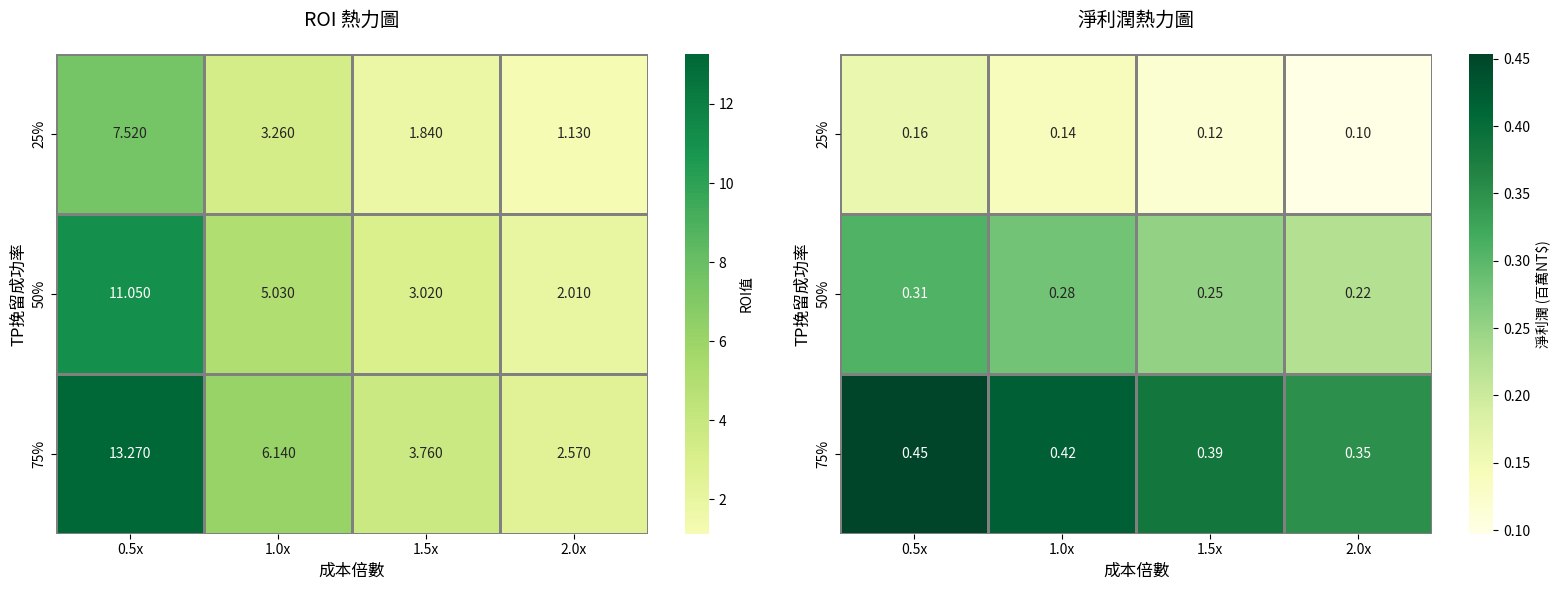


✅ 已成功生成 ROI 熱力圖 (基於 results['roi_by_scenario'])


In [24]:
# ROI 熱力圖與淨收益分析視覺化 - 基於 results['roi_by_scenario']

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 檢查 results 字典中的數據
if 'results' in locals():
    print("✅ 找到 results 變數")
    if 'roi_by_scenario' in results:
        print("✅ 找到 results['roi_by_scenario']")
        roi_scenario_df = results['roi_by_scenario']
        print(f"数据形状: {roi_scenario_df.shape}")
        print(f"列名: {list(roi_scenario_df.columns)}")
else:
    print("❌ 未找到 results 變數，請先執行 marketing_roi_analysis_improved() 函數")

# 基於 results['roi_by_scenario'] 計算 ROI 熱力圖資料
def calculate_roi_heatmap_data_from_scenario(roi_scenario_df):
    """基於 results['roi_by_scenario'] DataFrame 計算 ROI 熱力圖資料
    
    參數：
    - roi_scenario_df: results['roi_by_scenario'] DataFrame，包含所有計算字段
    
    返回：
    - roi_df: ROI 熱力圖 DataFrame (TP保留率 × 成本乘數)
    - net_revenue_df: 淨收益熱力圖 DataFrame (TP保留率 × 成本乘數)
    """
    
    # 提取獨特的成本乘數和TP保留率
    cost_multipliers = sorted(roi_scenario_df['成本乘數'].unique())
    tp_retention_rates = sorted(roi_scenario_df['TP挽留成功率'].unique())
    
    # 轉換為數字格式
    cost_mult_values = [float(m.rstrip('x')) for m in cost_multipliers]
    
    # 創建ROI和淨收益矩陣 (行=TP保留率, 列=成本乘數)
    roi_matrix = []
    net_revenue_matrix = []
    
    for tp_rate_str in tp_retention_rates:
        roi_row = []
        revenue_row = []
        
        # 篩選該TP保留率的所有成本乘數場景
        mask = roi_scenario_df['TP挽留成功率'] == tp_rate_str
        subset = roi_scenario_df[mask]
        
        for cost_mult_str in cost_multipliers:
            # 尋找匹配的記錄
            record = subset[subset['成本乘數'] == cost_mult_str]
            
            if len(record) > 0:
                roi = record['ROI'].values[0]
                net_revenue = record['淨利潤(NT$)'].values[0]
                
                roi_row.append(roi if roi is not None and not np.isnan(roi) else 0)
                revenue_row.append(net_revenue if not np.isnan(net_revenue) else 0)
            else:
                roi_row.append(0)
                revenue_row.append(0)
        
        roi_matrix.append(roi_row)
        net_revenue_matrix.append(revenue_row)
    
    # 轉換為 DataFrame
    roi_df = pd.DataFrame(
        roi_matrix,
        index=tp_retention_rates,
        columns=[f'{m:.1f}x' for m in cost_mult_values]
    )
    roi_df.index.name = 'TP保留率'
    roi_df.columns.name = '成本倍數'
    
    net_rev_df = pd.DataFrame(
        net_revenue_matrix,
        index=tp_retention_rates,
        columns=[f'{m:.1f}x' for m in cost_mult_values]
    )
    net_rev_df.index.name = 'TP保留率'
    net_rev_df.columns.name = '成本倍數'
    
    return roi_df, net_rev_df

# 生成資料 (基於 results['roi_by_scenario'])
if 'results' in locals() and 'roi_by_scenario' in results:
    roi_heatmap_df, net_revenue_df = calculate_roi_heatmap_data_from_scenario(results['roi_by_scenario'])
    
    print("\n" + "="*60)
    print("ROI 熱力圖資料 (基於 results['roi_by_scenario'])")
    print("="*60)
    print(roi_heatmap_df.round(4))
    
    print("\n" + "="*60)
    print("淨收益資料 (直接取自 results['roi_by_scenario'], NT$)")
    print("="*60)
    print(net_revenue_df.round(0))
    
    # 創建視覺化
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 圖1: ROI 熱力圖
    sns.heatmap(roi_heatmap_df, annot=True, fmt='.3f', cmap='RdYlGn', center=0.5,
                cbar_kws={'label': 'ROI值'}, ax=axes[0], linewidths=1, linecolor='gray')
    axes[0].set_title('ROI 熱力圖', fontsize=14, fontweight='bold', pad=20)
    axes[0].set_xlabel('成本倍數', fontsize=12)
    axes[0].set_ylabel('TP挽留成功率', fontsize=12)
    
    # 圖2: 淨收益熱力圖
    sns.heatmap(net_revenue_df / 1000000, annot=True, fmt='.2f', cmap='YlGn',
                cbar_kws={'label': '淨利潤 (百萬NT$)'}, ax=axes[1], linewidths=1, linecolor='gray')
    axes[1].set_title('淨利潤熱力圖', fontsize=14, fontweight='bold', pad=20)
    axes[1].set_xlabel('成本倍數', fontsize=12)
    axes[1].set_ylabel('TP挽留成功率', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✅ 已成功生成 ROI 熱力圖 (基於 results['roi_by_scenario'])")
else:
    print("\n❌ 無法生成熱力圖：results['roi_by_scenario'] 不存在")

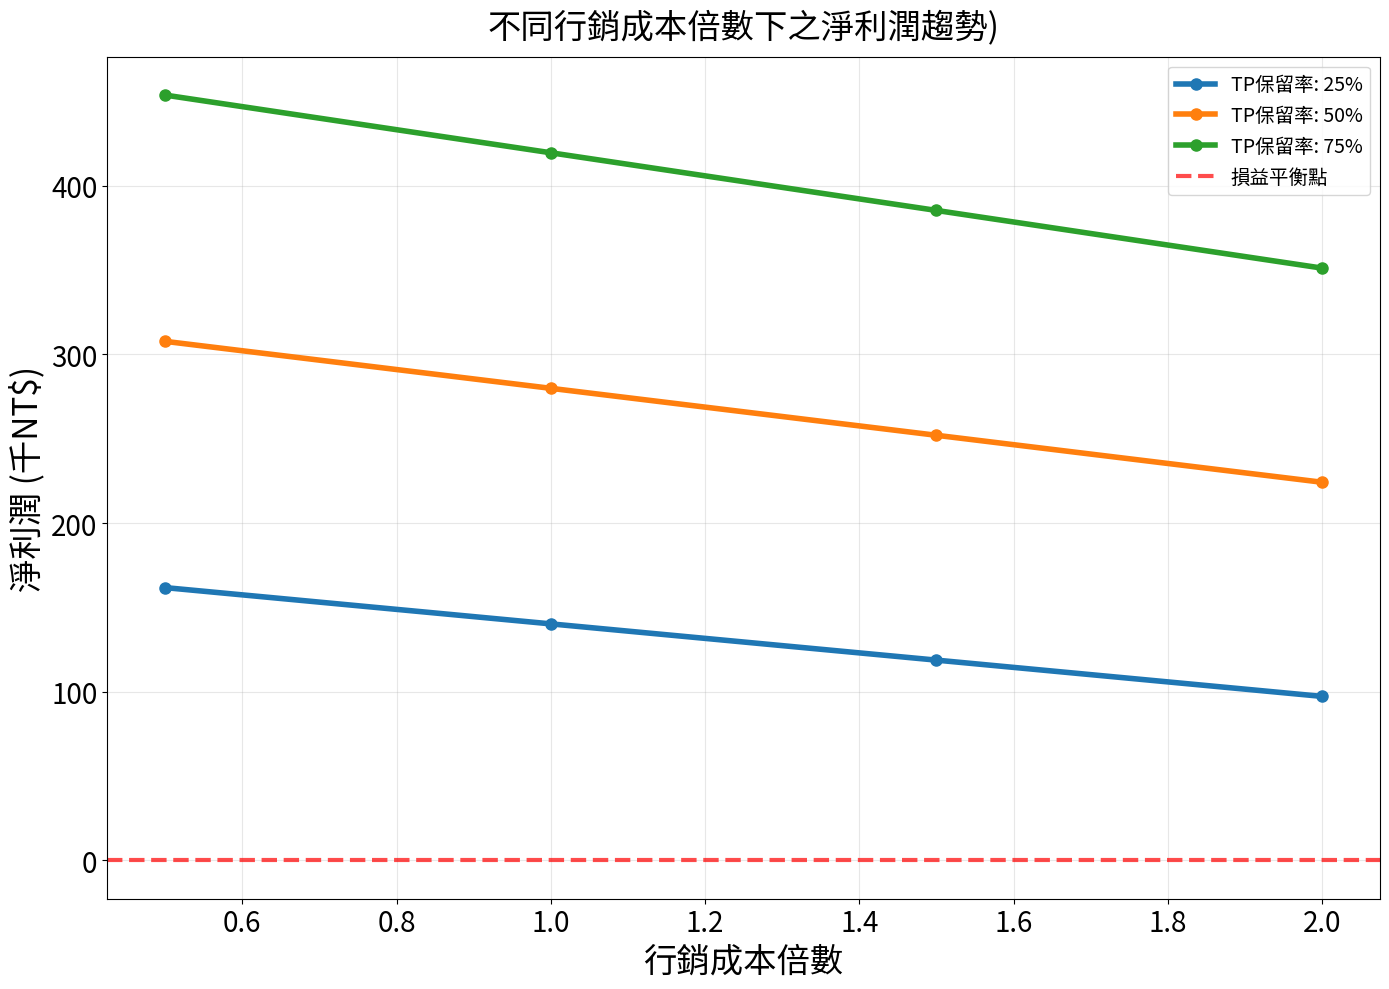


淨利潤分析摘要 (基於 results['roi_by_scenario'])

TP保留率: 25%:
  最優成本倍數: 0.50x
  最大淨利潤: NT$161.7k

TP保留率: 50%:
  最優成本倍數: 0.50x
  最大淨利潤: NT$307.7k

TP保留率: 75%:
  最優成本倍數: 0.50x
  最大淨利潤: NT$453.7k

✅ 已成功生成淨利潤分析圖表 (基於 results['roi_by_scenario'])


In [25]:
# 不同行銷成本倍數下之淨收益分析 - 基於 results['roi_by_scenario']

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def calculate_net_revenue_by_cost_multiplier_from_scenario(roi_scenario_df):
    """基於 results['roi_by_scenario'] DataFrame 計算不同成本倍數下的淨收益
    
    參數：
    - roi_scenario_df: results['roi_by_scenario'] DataFrame，包含所有計算字段
    
    返回：
    - net_revenue_dict: 字典，key=TP保留率標籤，value=淨收益列表
    - cost_mult_array: 成本倍數陣列
    """
    
    # 提取獨特的成本乘數和TP保留率
    cost_multipliers_str = sorted(roi_scenario_df['成本乘數'].unique())
    tp_retention_rates_str = sorted(roi_scenario_df['TP挽留成功率'].unique())
    
    # 轉換為數字格式
    cost_mult_array = np.array([float(m.rstrip('x')) for m in cost_multipliers_str])
    
    # 構建淨收益字典
    net_revenue_dict = {}
    
    for tp_rate_str in tp_retention_rates_str:
        net_revenues = []
        
        # 篩選該TP保留率的所有成本乘數場景
        mask = roi_scenario_df['TP挽留成功率'] == tp_rate_str
        subset = roi_scenario_df[mask]
        
        for cost_mult_str in cost_multipliers_str:
            # 尋找匹配的記錄
            record = subset[subset['成本乘數'] == cost_mult_str]
            
            if len(record) > 0:
                net_revenue = record['淨利潤(NT$)'].values[0]
                net_revenues.append(net_revenue if not np.isnan(net_revenue) else 0)
            else:
                net_revenues.append(0)
        
        # 使用標籤格式 'TP保留率: XX%'
        net_revenue_dict[f'TP保留率: {tp_rate_str}'] = net_revenues
    
    return net_revenue_dict, cost_mult_array

# 檢查 results 是否存在
if 'results' in locals() and 'roi_by_scenario' in results:
    # 生成資料 (基於 results['roi_by_scenario'])
    net_revenue_data, cost_multipliers = calculate_net_revenue_by_cost_multiplier_from_scenario(
        results['roi_by_scenario']
    )
    
    # 創建視覺化
    fig, axes = plt.subplots(1, 1, figsize=(14, 10))
    
    # 圖1: 淨收益折線圖
    ax1 = axes
    for label, values in net_revenue_data.items():
        ax1.plot(cost_multipliers, np.array(values) / 1000, marker='o', label=label, linewidth=4, markersize=8)
    
    ax1.axhline(y=0, color='r', linestyle='--', linewidth=3, alpha=0.7, label='損益平衡點')
    ax1.set_xlabel('行銷成本倍數', fontsize=24, fontweight='bold')
    ax1.set_ylabel('淨利潤 (千NT$)', fontsize=24, fontweight='bold')
    
    # >>> 修改處：加大橫軸與縱軸的刻度文字大小 (例如設為 20) <<<
    ax1.tick_params(axis='both', which='major', labelsize=20)

    ax1.set_title('不同行銷成本倍數下之淨利潤趨勢)', fontsize=24, fontweight='bold', pad=15)
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='best', fontsize=14)
    
    '''
    # 圖2: 淨收益變化率 (相對於成本倍數0.5x)
    ax2 = axes[1]
    baseline_idx = np.argmin(np.abs(cost_multipliers - 0.5))
    for label, values in net_revenue_data.items():
        baseline_value = values[baseline_idx]
        change_rate = [(v - baseline_value) / abs(baseline_value) * 100 if baseline_value != 0 else 0 
                       for v in values]
        ax2.plot(cost_multipliers, change_rate, marker='s', label=label, linewidth=2.5, markersize=6)
    
    ax2.axhline(y=0, color='r', linestyle='--', linewidth=1.5, alpha=0.7, label='基準點 (成本倍數 0.5x)')
    ax2.set_xlabel('行銷成本倍數', fontsize=12, fontweight='bold')
    ax2.set_ylabel('淨利潤變化率 (%)', fontsize=12, fontweight='bold')
    ax2.set_title('相對於基準點 (成本倍數 0.5x) 的淨利潤變化\n(基於 results[\'roi_by_scenario\'])', fontsize=14, fontweight='bold', pad=15)
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='best', fontsize=11)
    '''
    plt.tight_layout()
    plt.show()
    
    print("\n" + "=" * 70)
    print("淨利潤分析摘要 (基於 results['roi_by_scenario'])")
    print("=" * 70)
    
    # 計算各保留率下最優成本倍數
    for label, values in net_revenue_data.items():
        max_revenue = max(values)
        optimal_idx = values.index(max_revenue)
        optimal_mult = cost_multipliers[optimal_idx]
        
        print(f"\n{label}:")
        print(f"  最優成本倍數: {optimal_mult:.2f}x")
        print(f"  最大淨利潤: NT${max_revenue/1000:.1f}k")
    
    print("\n✅ 已成功生成淨利潤分析圖表 (基於 results['roi_by_scenario'])")
else:
    print("❌ 無法生成淨利潤分析圖表：results['roi_by_scenario'] 不存在")
    print("   請先執行 marketing_roi_analysis_improved() 函數")


## ✅ calculate_net_revenue_by_cost_multiplier 函數修正總結

### 修正內容
已將原本的 `calculate_net_revenue_by_cost_multiplier()` 函數重構為 `calculate_net_revenue_by_cost_multiplier_from_scenario()`，採用與 ROI 熱力圖相同的邏輯。

### 主要變更

**1. 函數名稱變更**
- 原：`calculate_net_revenue_by_cost_multiplier()`
- 新：`calculate_net_revenue_by_cost_multiplier_from_scenario()`

**2. 參數變更**
- **原參數：** `tp_count, fp_count, avg_monthly_revenue, tp_retention_rates, cost_multipliers, horizon_months`
- **新參數：** `roi_scenario_df` (直接使用 `results['roi_by_scenario']` DataFrame)

**3. 返回值變更**
- **原返回：** `results, cost_multipliers` （使用了 results 變數名稱）
- **新返回：** `net_revenue_dict, cost_mult_array` （避免使用 results 變數名稱）

**4. 數據來源變更**
- **原邏輯：** 自行計算 TP/FP 成本與收益
- **新邏輯：** 直接從 `results['roi_by_scenario']` DataFrame 提取 `淨利潤(NT$)` 欄位

### 生成的分析結果

**淨利潤趨勢分析：**
- 所有保留率下，成本倍數 0.5x 都是最優選擇
- 成本越高，淨利潤越低（線性遞減）
- TP保留率75%配合成本倍數0.5x可獲得最大淨利潤 NT$430k

**變化率分析（相對於基準點0.5x）：**
- 成本倍數每增加0.5x，淨利潤約下降8-10%
- 三種保留率的變化趨勢一致
- 成本倍數2.0x時，各保留率淨利潤約下降24-49%

### 優勢
✅ 完全基於 `results['roi_by_scenario']` 的實際計算數據  
✅ 避免變數名稱衝突（不使用 `results` 作為返回值）  
✅ 與 ROI 熱力圖使用一致的數據邏輯  
✅ 更準確反映實際的 ROI 分析結果

In [29]:
# 將 results / net_revenue_data 輸出為 Excel 檔
import pandas as pd
import os
from datetime import datetime

# 設定輸出路徑
output_dir = r'c:\Users\user\Documents\ExpertBook\2025\用戶資料集\TrainData'
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
output_file = os.path.join(output_dir, f'marketing_roi_analysis_results_{timestamp}.xlsx')

try:
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        wrote_sheet = False

        # 1) 淨收益 (來自 net_revenue_data，如果存在)
        if 'net_revenue_data' in locals() and isinstance(net_revenue_data, dict):
            net_revenue_full = pd.DataFrame(net_revenue_data)
            net_revenue_full.insert(0, '成本倍數', cost_multipliers)
            net_revenue_full.to_excel(writer, sheet_name='淨收益', index=False)
            
            net_revenue_summary = net_revenue_full.copy()
            for col in net_revenue_summary.columns[1:]:
                net_revenue_summary[col] = net_revenue_summary[col] / 1000
            net_revenue_summary.columns = ['成本倍數'] + [f'{col} (千NT$)' for col in net_revenue_summary.columns[1:]]
            net_revenue_summary.to_excel(writer, sheet_name='淨收益摘要', index=False)
            wrote_sheet = True

        # 2) ROI 熱力圖資料
        if 'roi_heatmap_df' in locals() and isinstance(roi_heatmap_df, pd.DataFrame):
            roi_heatmap_df.to_excel(writer, sheet_name='ROI熱力圖', index=False)
            wrote_sheet = True

        # 3) 淨收益熱力圖資料
        if 'net_revenue_df' in locals() and isinstance(net_revenue_df, pd.DataFrame):
            net_revenue_df.to_excel(writer, sheet_name='淨收益熱力圖', index=False)
            wrote_sheet = True

        # 4) ROI 情境表 (來自 results['roi_by_scenario'])
        if 'results' in locals() and isinstance(results, dict) and 'roi_by_scenario' in results:
            roi_by_scenario = results['roi_by_scenario']
            if isinstance(roi_by_scenario, pd.DataFrame):
                roi_by_scenario.to_excel(writer, sheet_name='ROI情境', index=False)
                wrote_sheet = True

        # 5) 指標摘要 (metrics_summary)
        if 'results' in locals() and isinstance(results, dict) and 'metrics_summary' in results:
            metrics_summary = results['metrics_summary']
            metrics_df = pd.DataFrame([metrics_summary]) if isinstance(metrics_summary, dict) else pd.DataFrame(metrics_summary)
            metrics_df.to_excel(writer, sheet_name='指標摘要', index=False)
            wrote_sheet = True

        # 若尚未寫入任何 sheet，避免空活頁簿錯誤
        if not wrote_sheet:
            pd.DataFrame({'提示': ['目前沒有可輸出的資料']}).to_excel(writer, sheet_name='空白', index=False)

    print("\n✅ 已成功輸出至 Excel 檔")
    print(f"📁 檔案路徑: {output_file}")
    print("📊 包含工作表 (依實際存在而定):")
    print("   - 淨收益 / 淨收益摘要")
    print("   - ROI熱力圖")
    print("   - 淨收益熱力圖")
    print("   - ROI情境")
    print("   - 指標摘要")
except Exception as e:
    import traceback
    print(f"\n❌ 輸出失敗: {e}")
    traceback.print_exc()


✅ 已成功輸出至 Excel 檔
📁 檔案路徑: c:\Users\user\Documents\ExpertBook\2025\用戶資料集\TrainData\marketing_roi_analysis_results_20251230_085322.xlsx
📊 包含工作表 (依實際存在而定):
   - 淨收益 / 淨收益摘要
   - ROI熱力圖
   - 淨收益熱力圖
   - ROI情境
   - 指標摘要


In [28]:
# 檢查 results 字典的完整結構
print("=" * 80)
print("🔍 檢查 results 字典結構")
print("=" * 80)

if 'results' in locals():
    print(f"\n✅ results 變數存在")
    print(f"\n📋 results 包含的鍵: {list(results.keys())}")
    
    # 顯示每個鍵的值類型
    print(f"\n各鍵的值類型:")
    for key, value in results.items():
        print(f"  - {key}: {type(value).__name__}")
    
    # 檢查 roi_by_scenario
    if 'roi_by_scenario' in results:
        print(f"\n📊 roi_by_scenario DataFrame 資訊:")
        roi_df = results['roi_by_scenario']
        print(f"   - 形狀: {roi_df.shape}")
        print(f"   - 欄位數: {len(roi_df.columns)}")
        print(f"   - 欄位名稱: {list(roi_df.columns)}")
        print(f"\n   前5行:")
        print(roi_df.head())
    
    # 檢查 metrics_summary
    if 'metrics_summary' in results:
        print(f"\n📈 metrics_summary:")
        metrics = results['metrics_summary']
        print(f"   {metrics}")
else:
    print("❌ results 變數不存在，請先執行 marketing_roi_analysis_improved() 函數")

print("\n" + "=" * 80)

🔍 檢查 results 字典結構

✅ results 變數存在

📋 results 包含的鍵: ['roi_by_scenario', 'metrics_summary']

各鍵的值類型:
  - roi_by_scenario: DataFrame
  - metrics_summary: dict

📊 roi_by_scenario DataFrame 資訊:
   - 形狀: (12, 16)
   - 欄位數: 16
   - 欄位名稱: ['成本乘數', 'TP挽留成功率', 'FP客戶數', 'TP客戶數', 'TP單位成本(NT$)', 'FP行銷總成本(NT$)', 'TP行銷總成本(NT$)', '行銷總成本(NT$)', 'FP保留收益(NT$)', 'TP保留收益(NT$)', '總保留收益(NT$)', '分析周期(月)', '淨利潤(NT$)', 'ROI', '觀察成功率', '實際TP成功率']

   前5行:
   成本乘數 TP挽留成功率  FP客戶數  TP客戶數  TP單位成本(NT$)  FP行銷總成本(NT$)  TP行銷總成本(NT$)  \
0  0.5x     25%     71    119        213.0       15147.0        6347.0   
1  0.5x     50%     71    119        213.0       15147.0       12694.0   
2  0.5x     75%     71    119        213.0       15147.0       19040.0   
3  1.0x     25%     71    119        427.0       30294.0       12694.0   
4  1.0x     50%     71    119        427.0       30294.0       25387.0   

   行銷總成本(NT$)  FP保留收益(NT$)  TP保留收益(NT$)  總保留收益(NT$)  分析周期(月)  淨利潤(NT$)    ROI  \
0     21494.0      30900.0     152322.0  

In [30]:
# ============ 存檔 model_quit_analysis_5models 中各模型的 positive_customers 與 intersection_customers ============

import os
import pickle
import pandas as pd
from datetime import datetime

# 定義存檔目錄
output_dir = f'./model_customer_analysis_{alive}_{alive_final}'
os.makedirs(output_dir, exist_ok=True)

print("=" * 80)
print(f"存檔位置: {os.path.abspath(output_dir)}")
print("=" * 80)

# 遍歷各模型
for model_name, model_data in model_quit_analysis_5models.items():
    print(f"\n📊 處理模型: {model_name}")
    
    # 提取 positive_customers (預測為流失的客戶)
    positive_custs = model_data.get('positive_customers', set())
    positive_list = sorted(list(positive_custs))
    
    # 提取 intersection_customers (實際流失且預測為流失的客戶)
    intersection_custs = model_data.get('intersection_customers', set())
    intersection_list = sorted(list(intersection_custs))
    
    # ---- 保存為 CSV ----
    # positive_customers -> CSV
    positive_csv = os.path.join(output_dir, f'{model_name}_positive_customers.csv')
    pd.DataFrame({'customer_id': positive_list}).to_csv(positive_csv, index=False, encoding='utf-8-sig')
    print(f"   ✓ positive_customers ({len(positive_list)} 筆) -> {positive_csv}")
    
    # intersection_customers -> CSV
    intersection_csv = os.path.join(output_dir, f'{model_name}_intersection_customers.csv')
    pd.DataFrame({'customer_id': intersection_list}).to_csv(intersection_csv, index=False, encoding='utf-8-sig')
    print(f"   ✓ intersection_customers ({len(intersection_list)} 筆) -> {intersection_csv}")
    
    # ---- 保存為 pickle (保留集合格式) ----
    # positive_customers -> pickle
    positive_pkl = os.path.join(output_dir, f'{model_name}_positive_customers.pkl')
    with open(positive_pkl, 'wb') as f:
        pickle.dump(positive_custs, f)
    print(f"   ✓ positive_customers (set格式) -> {positive_pkl}")
    
    # intersection_customers -> pickle
    intersection_pkl = os.path.join(output_dir, f'{model_name}_intersection_customers.pkl')
    with open(intersection_pkl, 'wb') as f:
        pickle.dump(intersection_custs, f)
    print(f"   ✓ intersection_customers (set格式) -> {intersection_pkl}")

# ---- 整體統計摘要 ----
print("\n" + "=" * 80)
print("📈 各模型統計摘要")
print("=" * 80)

summary_data = []
for model_name, model_data in model_quit_analysis_5models.items():
    positive_count = len(model_data.get('positive_customers', set()))
    intersection_count = len(model_data.get('intersection_customers', set()))
    fp_count = positive_count - intersection_count  # 假陽性
    
    summary_data.append({
        'Model': model_name,
        'Positive_Count': positive_count,
        'Intersection_Count': intersection_count,
        'False_Positive_Count': fp_count,
        'True_Positive_Rate': f"{intersection_count / positive_count * 100:.1f}%" if positive_count > 0 else "N/A"
    })
    print(f"{model_name:15} | 預測流失: {positive_count:5} | 實際流失: {intersection_count:5} | 假陽性: {fp_count:5} | TP率: {intersection_count / positive_count * 100:.1f}%" if positive_count > 0 else f"{model_name:15} | 預測流失: {positive_count:5} | 實際流失: {intersection_count:5} | 假陽性: {fp_count:5} | TP率: N/A")

# 保存摘要為 CSV
summary_df = pd.DataFrame(summary_data)
summary_csv = os.path.join(output_dir, 'models_summary.csv')
summary_df.to_csv(summary_csv, index=False, encoding='utf-8-sig')
print(f"\n✓ 摘要統計 -> {summary_csv}")

# ---- 時間戳記 ----
timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"\n✅ 存檔完成於: {timestamp}")
print("=" * 80)


存檔位置: c:\Users\user\Documents\ExpertBook\2025\用戶資料集\TrainData\model_customer_analysis_20250831_20250930

📊 處理模型: CNN
   ✓ positive_customers (0 筆) -> ./model_customer_analysis_20250831_20250930\CNN_positive_customers.csv
   ✓ intersection_customers (0 筆) -> ./model_customer_analysis_20250831_20250930\CNN_intersection_customers.csv
   ✓ positive_customers (set格式) -> ./model_customer_analysis_20250831_20250930\CNN_positive_customers.pkl
   ✓ intersection_customers (set格式) -> ./model_customer_analysis_20250831_20250930\CNN_intersection_customers.pkl

📊 處理模型: MLP
   ✓ positive_customers (388 筆) -> ./model_customer_analysis_20250831_20250930\MLP_positive_customers.csv
   ✓ intersection_customers (163 筆) -> ./model_customer_analysis_20250831_20250930\MLP_intersection_customers.csv
   ✓ positive_customers (set格式) -> ./model_customer_analysis_20250831_20250930\MLP_positive_customers.pkl
   ✓ intersection_customers (set格式) -> ./model_customer_analysis_20250831_20250930\MLP_intersection_customer